# 📊 Análisis de Parámetros Fisicoquímicos — Monitoreo de Aguas Hidrocasanare
## Extracción, Limpieza y Análisis Exploratorio

**Proyecto:** Propuesta de implementación de un modelo analítico para optimizar el cambio de calderas en Hidrocasanare basado en parámetros fisicoquímicos

**Autor:** Manuel David Niño Mojica | **Asesora:** LINA ROCÍO RIVADENEIRA MUÑOZ
**Programa:** Especialización en Ciencia de Datos y Analítica — UNAD | 2026

---

### ¿Qué hace este notebook?

| # | Sección | Objetivo del proyecto |
|---|---------|----------------------|
| 1 | Configuración del entorno | Preparación |
| 2 | Extracción de datos desde reportes PDF de laboratorio | **OE1** — Consolidar fuentes |
| 3 | Limpieza y estadísticas descriptivas | **OE1** — Depurar y documentar |
| 4 | Análisis exploratorio y visualizaciones | **OE2** — Tendencias y correlaciones |
| 5 | Análisis de excedencias de umbrales | **OE2** — Variables críticas |
| 6 | Construcción de la variable objetivo | **OE2/OE3** — Etiqueta de riesgo |

> **Fuentes de datos:** reportes diarios de laboratorio en formato **PDF**, organizados en carpetas mensuales por año (2023–2026).
> Cada reporte contiene registros de tres bloques: **Entrada** (agua de alimentación), **Purga** (agua interna de caldera) y **D105** (condensado/retorno).

In [58]:
# ── pandas: la herramienta principal para manejar tablas de datos (DataFrames)
# Es el equivalente a Excel pero en Python: filas, columnas, filtros, agrupaciones
import pandas as pd

# ── numpy: librería de cálculo numérico. Nos permite usar NaN (valor nulo),
# hacer operaciones matemáticas rápidas sobre arreglos de números, etc.
import numpy as np

# ── pdfplumber: librería para leer y extraer información de archivos PDF.
# Es la herramienta central de este notebook: permite ubicar texto y tablas
# dentro de cada reporte de laboratorio en PDF y convertirlos en datos
# estructurados (filas y columnas) que luego se analizan con pandas
import pdfplumber

# ── re: módulo estándar de Python para trabajar con expresiones regulares.
# Se usa para "buscar patrones" dentro del texto extraído de cada PDF,
# por ejemplo para encontrar el valor numérico que sigue a la palabra "pH:"
import re

# ── matplotlib: librería de graficación. Con ella creamos todas las figuras
import matplotlib.pyplot as plt
import matplotlib.dates as mdates   # submódulo para formatear fechas en los ejes

# ── seaborn: librería de visualización estadística que mejora los gráficos
# de matplotlib con estilos más limpios y funciones de alto nivel (ej: heatmap)
import seaborn as sns

# ── os: módulo estándar de Python para manejar rutas y archivos del sistema,
# por ejemplo para recorrer carpetas y subcarpetas en busca de los PDFs
import os

# ── pathlib: módulo moderno de Python para trabajar con rutas de archivos
# de forma más legible (se usa, por ejemplo, para obtener la fecha desde
# el nombre del archivo PDF mediante ruta_pdf.stem)
from pathlib import Path

# ── warnings: módulo para suprimir mensajes de advertencia no críticos
import warnings
warnings.filterwarnings('ignore')   # oculta advertencias menores durante la ejecución

# ── Configuración global de gráficas ──────────────────────────────────────────
plt.rcParams['figure.dpi']        = 120    # resolución de las imágenes (puntos por pulgada)
plt.rcParams['font.family']       = 'DejaVu Sans'   # fuente de texto en gráficas
plt.rcParams['axes.spines.top']   = False  # elimina el borde superior de cada gráfica
plt.rcParams['axes.spines.right'] = False  # elimina el borde derecho (más limpio visualmente)

print("✔  Librerías importadas correctamente")

✔  Librerías importadas correctamente


### 1.2 Rutas y nombres de archivos



In [59]:
# ── Librerías necesarias para extracción desde PDF ────────────────────────────
import pdfplumber        # extracción de texto desde PDFs con capa digital
import pandas as pd      # manejo de DataFrames
import numpy as np       # cálculo numérico y representación de NaN
import re                # expresiones regulares para parsear texto del PDF
import os                # manejo de rutas y directorios
from pathlib import Path # manejo moderno de rutas de archivo

# ── Ruta raíz donde están las carpetas de monitoreo ──────────────────────────
# Cada subcarpeta tiene el formato: "MONITOREO AGUAS AAAA"
# Dentro de cada año hay subcarpetas por mes: "1. Enero", "2. Febrero", etc.
# Dentro de cada mes están los PDFs diarios: "Monitoreo de aguas AAAA-MM-DD.pdf"
RUTA_DATOS = Path(r"F:\Cursos\Unad\Posgrado\(2026) PERIODO 16-02\PROYECTO DE GRADO II\Datos")

# ── Años a procesar ───────────────────────────────────────────────────────────
# Agregar 2026 cuando estén disponibles los datos completos del año
AÑOS = [2023, 2024, 2025, 2026]

# ── Nombres de meses en español para navegar las carpetas ────────────────────
# El número coincide con el prefijo de la carpeta (ej: "3. Marzo")
MESES = {
    1: "Enero",    2: "Febrero",   3: "Marzo",     4: "Abril",
    5: "Mayo",     6: "Junio",     7: "Julio",      8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

# ── Verificar que la ruta raíz existe antes de continuar ─────────────────────
if RUTA_DATOS.exists():
    print(f"✔  Ruta raíz encontrada: {RUTA_DATOS}")
    # Listar las carpetas de años disponibles
    for anio in AÑOS:
        carpeta = RUTA_DATOS / f"MONITOREO AGUAS {anio}"
        estado  = "✔  Encontrada" if carpeta.exists() else "✘  NO encontrada"
        print(f"   {anio}: {estado}")
else:
    print(f"✘  Ruta raíz NO encontrada: {RUTA_DATOS}")
    print("   Verifica que RUTA_DATOS apunte a la carpeta correcta")

✔  Ruta raíz encontrada: F:\Cursos\Unad\Posgrado\(2026) PERIODO 16-02\PROYECTO DE GRADO II\Datos
   2023: ✔  Encontrada
   2024: ✔  Encontrada
   2025: ✔  Encontrada
   2026: ✔  Encontrada


---
## 2. Extracción de datos — OE1

### ¿Cómo está organizado cada reporte PDF?

Cada PDF corresponde a **un solo día** de monitoreo y contiene un encabezado fijo
con la **fecha** y la **caldera en funcionamiento** (B801-A o B801-B), seguido de
una tabla con los valores del día para tres bloques:

| Bloque | Significado | Parámetros |
|--------|-------------|-----------|
| **ENTRADA** (agua de alimentación) | Agua antes de ingresar a la caldera | pH, Conductividad, TDS, Dureza Total, Oxígeno Disuelto, Hierro, Cloruros, Alcalinidad, Turbidez, Sílice |
| **PURGA** (agua interna de caldera) | Agua dentro de la caldera en operación | pH, Conductividad, TDS, Hierro, Cloruros, Alcalinidad Total, Alcalinidad P, Alcalinidad OH, Turbidez, Sílice, Fosfatos, Sulfitos |
| **D105** (condensado/retorno) | Agua de retorno de condensado | pH, Hierro, Cloruros — *se extrae como contexto descriptivo, pero no se usa como predictor del modelo* |

Debajo de esta tabla, cada PDF incluye además **gráficas históricas de los últimos
8 días** (series de pH, conductividad, alcalinidad, cloruros, etc.), con sus
propios ejes numéricos. Esta zona de gráficas es la que contaminaba la extracción
en versiones anteriores del código: al leer el texto completo de la página sin
delimitar zonas, el regex podía capturar números de los ejes de las gráficas en
lugar del valor real de la tabla (por ejemplo, el eje de pH recorre de 5 a 14,
y un número de ese eje podía confundirse con el pH del día).

### 2.1 Estrategia de extracción

Para evitar esa contaminación, la extracción se realiza en dos pasos:

1. **Recorte por coordenadas** — `pdfplumber` recorta cada página a la región
   `(0, 60, 420, 380)`, que corresponde únicamente a la tabla de valores del día
   (encabezado + bloques Entrada/Purga/D105), excluyendo por completo la zona
   inferior de gráficas.
2. **Búsqueda por nombre de parámetro (regex)** — dentro de esa zona ya acotada,
   se busca cada parámetro por su nombre (ej. *"Conductividad"*) y se captura el
   valor numérico que le sigue en la tabla.

La combinación de ambos pasos —primero limitar el espacio de búsqueda, luego
extraer por patrón— es lo que permite una extracción confiable sin depender de
la posición exacta de cada celda, que puede variar levemente entre formatos de
PDF.

> **Nota sobre la fecha:** la fecha de cada registro se toma del **nombre del
> archivo PDF** (`ruta_pdf.stem`) y no del encabezado interno del documento.
> Esto se debe a un error de plantilla detectado en los reportes de enero y
> febrero de 2025, donde el encabezado interno conserva el año "2024" por
> copia incorrecta de la plantilla del mes anterior, mientras que el nombre
> del archivo sí refleja la fecha real del reporte.

In [60]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2.1 — FUNCIÓN extraer_datos_pdf() — VERSIÓN FINAL CORREGIDA
# ══════════════════════════════════════════════════════════════════════════════
# RESUMEN DE LA AUDITORÍA DE EXTRACCIÓN (mes por mes, 1.249 PDFs 2023-2026):
# La auditoría detectó que el 65,7 % de los PDFs históricos tenían al menos
# una variable en blanco. Tras investigar caso por caso con PDFs reales, el
# problema bajó a 0,1 % (1 solo día, ver más abajo). Dos tipos de causas:
#
# (A) BUGS DE EXTRACCIÓN CORREGIDOS (el dato sí existía en el PDF):
#   1. y_tolerance por defecto de pdfplumber fusionaba filas verticalmente
#      cercanas (ej. "Dureza Total" a 11pt de "Óxigeno Disuelto"),
#      entrelazando sus caracteres letra por letra. Corregido con
#      y_tolerance=1 en extract_text() sobre la región recortada.
#   2. Con y_tolerance=1, el subíndice numérico de "Fosfatos mg/L PO4" y
#      "Sulfitos mg/L SO3" a veces queda en línea separada. Regex ajustados
#      para tolerar esa separación (compatibles con ambos formatos).
#   3. Cuando la columna D105 tenía guion ("-"), los regex de pH, Hierro y
#      Cloruros (que exigen 3 grupos numéricos: entrada/purga/D105) fallaban
#      la línea COMPLETA, perdiendo entrada y purga aunque sí tuvieran valor
#      real (confirmado con PDF de 2026-04-27). Corregido: el tercer grupo
#      (D105) ahora tolera guiones sin romper la captura de entrada/purga.
#   4. El laboratorio a veces reporta ">200" (saturación del instrumento) en
#      vez de un número. Ahora se extrae el valor límite como cota inferior
#      conservadora (ej. sulfitos_purga ">200" → 200.0).
#
# (B) DATOS REALMENTE AUSENTES (el laboratorio no midió esa variable ese
#     día — el PDF muestra guion "-" en la tabla, confirmado con múltiples
#     PDFs reales por variable, en años y rachas distintas). Estos NO se
#     imputan con 0 (un 0 implicaría una medición real favorable y
#     sesgaría el target/IDC) — se dejan en NaN para imputación posterior
#     por mediana, igual que ya se hacía con sílice:
#       • turbidez_entrada / turbidez_purga      (nov-2025 a ene-2026)
#       • alcalinidad_entrada / total_purga /
#         P_purga / OH_purga                      (varias rachas 2023-2026)
#       • dureza_entrada                          (3 rachas, 2024-2026)
#       • sulfitos_purga                          (feb-mar 2023)
#       • cloruros_entrada / cloruros_purga       (ago-2025)
#       • hierro_entrada / hierro_purga           (dic-2025)
#       • fosfatos_purga                          (dic-2025)
#
# CASO RESIDUAL (0,1 %, 1 día de 1.249): 2025-09-26 — el PDF tiene casi
# todas las celdas con error de fórmula de Excel (#¡VALOR!), evidencia de
# que el laboratorio no realizó análisis ese día. Se recomienda tratarlo
# como "día sin análisis" y descartarlo del dataset en la Sección 3
# (limpieza), no imputarlo variable por variable.
# ══════════════════════════════════════════════════════════════════════════════

import pdfplumber
import re
import numpy as np
import pandas as pd
from pathlib import Path

# ── Región de la tabla principal en todos los formatos de PDF identificados ───
CROP_TABLA = (0, 60, 420, 380)

# ── y_tolerance ajustado para evitar fusión de filas verticalmente cercanas ──
# Valor por defecto de pdfplumber: 3 (demasiado permisivo para este layout)
Y_TOLERANCE_CROP = 1

# ── Función auxiliar para convertir texto a número ────────────────────────────
def parse_float(texto):
    """
    Convierte texto del PDF a número — maneja comas, guiones de cualquier
    longitud y el caso de saturación de instrumento ">valor" (ej. ">200"),
    donde se usa el valor límite como cota inferior conservadora del dato
    real (confirmado con PDF real de 2023-03-17, sulfitos_purga = >200).
    """
    if texto is None:
        return np.nan
    texto = str(texto).strip()
    if texto in ["", "None"] or set(texto) == {"-"}:
        return np.nan
    # Caso especial: instrumento saturado, reporta ">valor"
    if texto.startswith(">"):
        texto = texto[1:].strip()
    try:
        return float(texto.replace(",", "."))
    except:
        return np.nan

# ── Función principal de extracción ──────────────────────────────────────────
def extraer_datos_pdf(ruta_pdf):
    """
    Extrae fecha, caldera activa y variables fisicoquímicas de un PDF diario.
    Usa crop de coordenadas para aislar la tabla principal y un y_tolerance
    reducido para evitar que filas verticalmente cercanas (como "Dureza Total"
    y "Óxigeno Disuelto") se fusionen y entrelacen sus caracteres.
    La fecha se toma del nombre del archivo (fuente más confiable).
    """
    try:
        with pdfplumber.open(ruta_pdf) as pdf:
            page = pdf.pages[0]

            # Texto completo para detectar caldera y fecha del encabezado
            texto_completo = page.extract_text()

            # Texto recortado para extraer valores de variables
            # y_tolerance reducido evita la fusión de filas cercanas
            region = page.crop(CROP_TABLA)
            texto  = region.extract_text(y_tolerance=Y_TOLERANCE_CROP)

            if not texto_completo:
                return None

            # ── Fecha desde el nombre del archivo ─────────────────────────────
            match_fecha = re.search(
                r"(\d{4})-(\d{2})-(\d{2})", ruta_pdf.stem)
            if not match_fecha:
                print(f"  ⚠  {ruta_pdf.name}: no se pudo extraer fecha")
                return None

            anio  = int(match_fecha.group(1))
            mes   = int(match_fecha.group(2))
            dia   = int(match_fecha.group(3))
            fecha = pd.Timestamp(year=anio, month=mes, day=dia)

            # Verificación opcional contra encabezado del PDF
            match_fecha_texto = re.search(
                r"Fecha\s+(\d{1,2})\s+"
                r"(ENERO|FEBRERO|MARZO|ABRIL|MAYO|JUNIO|"
                r"JULIO|AGOSTO|SEPTIEMBRE|OCTUBRE|NOVIEMBRE|DICIEMBRE)"
                r"\s+(\d{4})",
                texto_completo, re.IGNORECASE
            )
            if match_fecha_texto:
                anio_texto = int(match_fecha_texto.group(3))
                if anio_texto != anio:
                    print(f"  ⚠  {ruta_pdf.name}: encabezado dice año "
                          f"{anio_texto}, se usa {anio} (del nombre)")

            # ── Caldera — tres patrones en orden de prioridad ─────────────────
            # Se busca en texto_completo (sin crop, sin tocar y_tolerance)
            match_caldera = re.search(
                r"Funcionamiento\s+(B801-[AB])",
                texto_completo, re.IGNORECASE)
            if not match_caldera:
                match_caldera = re.search(
                    r"Caldera\s+en\s+(B801-[AB])",
                    texto_completo, re.IGNORECASE | re.DOTALL)
            if not match_caldera:
                match_caldera = re.search(
                    r"(B801-[AB])", texto_completo, re.IGNORECASE)
            caldera = match_caldera.group(1) if match_caldera else np.nan

            if pd.isna(caldera):
                print(f"  ⚠  {ruta_pdf.name}: caldera no detectada")

            # ── Extraer variables desde el texto recortado ────────────────────
            # pH — busca valor plausible entre 0 y 14 para entrada
            # El tercer grupo (D105) tolera guiones: confirmado con PDF real
            # (2026-04-27) que cuando D105 no tiene dato ("-"), el patrón
            # viejo (que exigía número en los 3 grupos) fallaba la línea
            # completa y arrastraba entrada/purga aunque sí tuvieran valor.
            m_ph = re.search(
                r"pH\s+((?:[0-9]|1[0-4])[,\.]\d+)\s+([\d,\.]+)\s+(-+|[\d,\.]+)",
                texto)
            if not m_ph:
                m_ph = re.search(
                    r"ENTRADA\s+PURGA\s+D105\s*\n"
                    r"(?:D105\s+\d+\s*\n)?"
                    r"pH\s+([\d,\.]+)\s+([\d,\.]+)\s+(-+|[\d,\.]+)",
                    texto)

            ph_ent  = parse_float(m_ph.group(1)) if m_ph else np.nan
            ph_purg = parse_float(m_ph.group(2)) if m_ph else np.nan
            ph_d105 = parse_float(m_ph.group(3)) if m_ph else np.nan

            if not np.isnan(ph_ent) and (ph_ent < 0 or ph_ent > 14):
                ph_ent = np.nan

            # Conductividad
            m_cond = re.search(
                r"Conductividad\s+µS/cm\s+([\d,\.]+)\s+([\d,\.]+)",
                texto)
            cond_ent  = parse_float(m_cond.group(1)) if m_cond else np.nan
            cond_purg = parse_float(m_cond.group(2)) if m_cond else np.nan

            # TDS
            m_tds = re.search(
                r"TDS\s+mg/L\s+([\d,\.]+)\s+([\d,\.]+)", texto)
            tds_ent  = parse_float(m_tds.group(1)) if m_tds else np.nan
            tds_purg = parse_float(m_tds.group(2)) if m_tds else np.nan

            # Dureza Total — acepta número o guion(es) de cualquier longitud.
            # Confirmado con PDFs reales (ene-feb 2024) que el laboratorio
            # a veces usa un solo guion "-" en vez de "-----" cuando no se
            # midió ese día — mismo patrón ya corregido en Alcalinidad.
            m_dur = re.search(
                r"Dureza\s+Total\s+mg/L\s+CaCO3\s+(-+|[\d,\.]+)", texto)
            if not m_dur:
                # Intento alternativo cuando las letras están separadas por espacios
                # (se conserva como red de seguridad para PDFs atípicos)
                m_dur = re.search(
                    r"D\s*u\s*r\s*e\s*z\s*a\s+T\s*o\s*t\s*a\s*l"
                    r"\s+mg/L\s+CaCO3\s+(-+|[\d,\.]+)", texto)
            dureza_ent = parse_float(m_dur.group(1)) if m_dur else np.nan

            # Hierro — entrada, purga, D105
            # El tercer grupo (D105) tolera guiones — mismo fix que pH,
            # confirmado con PDF real (2026-04-27)
            m_fe = re.search(
                r"Hierro\s+mg/L Fe\s+([\d,\.]+)\s+([\d,\.]+)\s+(-+|[\d,\.]+)",
                texto)
            fe_ent  = parse_float(m_fe.group(1)) if m_fe else np.nan
            fe_purg = parse_float(m_fe.group(2)) if m_fe else np.nan
            fe_d105 = parse_float(m_fe.group(3)) if m_fe else np.nan

            # Cloruros — entrada, purga, D105
            # El tercer grupo (D105) tolera guiones — mismo fix que pH,
            # confirmado con PDF real (2026-04-27)
            m_cl = re.search(
                r"Cloruros\s+mg/L Cl-?\s+([\d,\.]+)\s+([\d,\.]+)\s+(-+|[\d,\.]+)",
                texto)
            cl_ent  = parse_float(m_cl.group(1)) if m_cl else np.nan
            cl_purg = parse_float(m_cl.group(2)) if m_cl else np.nan
            cl_d105 = parse_float(m_cl.group(3)) if m_cl else np.nan

            # Alcalinidad total
            # Acepta tanto número como guion(es) de cualquier longitud (1 a 5)
            # en cada posición — algunos PDFs usan "-" simple en vez de "-----"
            # cuando el dato no fue medido (confirmado con PDFs reales de
            # marzo 2026, donde el analista usó un solo guion)
            m_alc = re.search(
                r"Alcalinidad\s+ppm CaCO3\s+(-+|[\d,\.]+)\s+(-+|[\d,\.]+)", texto)
            alc_ent  = parse_float(m_alc.group(1)) if m_alc else np.nan
            alc_purg = parse_float(m_alc.group(2)) if m_alc else np.nan

            # Alcalinidad P — mismo ajuste de tolerancia a guion simple
            m_alcp = re.search(
                r"Alcalinidad P\s+ppm CaCO3\s+-+\s+(-+|[\d,\.]+)", texto)
            alc_p_purg = parse_float(m_alcp.group(1)) if m_alcp else np.nan

            # Alcalinidad OH — mismo ajuste de tolerancia a guion simple
            m_alco = re.search(
                r"Alcalinidad OH\s+ppm CaCO3\s+-+\s+(-+|[\d,\.]+)", texto)
            alc_oh_purg = parse_float(m_alco.group(1)) if m_alco else np.nan

            # Turbidez
            m_turb = re.search(
                r"Turbidez\s+NTU\s+([\d,\.]+)\s+([\d,\.]+)", texto)
            turb_ent  = parse_float(m_turb.group(1)) if m_turb else np.nan
            turb_purg = parse_float(m_turb.group(2)) if m_turb else np.nan

            # Sílice
            m_sil = re.search(
                r"Silice\s+mg/L SO2\s+(-{1,5}|[\d,\.]+)\s+(-{1,5}|[\d,\.]+)",
                texto)
            sil_ent  = parse_float(m_sil.group(1)) if m_sil else np.nan
            sil_purg = parse_float(m_sil.group(2)) if m_sil else np.nan

            # Fosfatos — tolera el subíndice "4" en línea separada (efecto
            # secundario del y_tolerance reducido), guiones de cualquier
            # longitud cuando no hay dato, y el caso ">valor" de saturación
            # del instrumento (mismo mecanismo confirmado en Sulfitos)
            m_fos = re.search(
                r"Fosfatos\s+mg/L\s+PO\s*\n?\s*4?\s+-+\s+"
                r"(>\s*[\d,\.]+|-+|[\d,\.]+)", texto)
            fosfatos_purg = parse_float(m_fos.group(1)) if m_fos else np.nan

            # Sulfitos — mismo tratamiento que Fosfatos. Confirmado con PDF
            # real de 2023-03-17 donde el laboratorio reportó ">200" por
            # saturación del instrumento (rango operativo máx. documentado
            # es 40-50, así que >200 de cualquier forma queda fuera de rango)
            m_sul = re.search(
                r"Sulfitos\s+mg/L\s+SO\s*\n?\s*3?\s+-+\s+"
                r"(>\s*[\d,\.]+|-+|[\d,\.]+)", texto)
            sulfitos_purg = parse_float(m_sul.group(1)) if m_sul else np.nan

            # ── Construir el registro del día ─────────────────────────────────
            return {
                "fecha"                  : fecha,
                "caldera"                : caldera,
                "pH_entrada"             : ph_ent,
                "conductividad_entrada"  : cond_ent,
                "TDS_entrada"            : tds_ent,
                "dureza_entrada"         : dureza_ent,
                "hierro_entrada"         : fe_ent,
                "cloruros_entrada"       : cl_ent,
                "alcalinidad_entrada"    : alc_ent,
                "turbidez_entrada"       : turb_ent,
                "silice_entrada"         : sil_ent,
                "pH_purga"               : ph_purg,
                "conductividad_purga"    : cond_purg,
                "TDS_purga"              : tds_purg,
                "hierro_purga"           : fe_purg,
                "cloruros_purga"         : cl_purg,
                "alcalinidad_total_purga": alc_purg,
                "alcalinidad_P_purga"    : alc_p_purg,
                "alcalinidad_OH_purga"   : alc_oh_purg,
                "turbidez_purga"         : turb_purg,
                "silice_purga"           : sil_purg,
                "fosfatos_purga"         : fosfatos_purg,
                "sulfitos_purga"         : sulfitos_purg,
                "pH_D105"                : ph_d105,
                "hierro_D105"            : fe_d105,
                "cloruros_D105"          : cl_d105,
            }

    except Exception as e:
        print(f"  ⚠  Error en {ruta_pdf.name}: {e}")
        return None

In [61]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2.2 — RECORRER CARPETAS Y EXTRAER TODOS LOS REGISTROS
# Recorre la estructura: MONITOREO AGUAS AAAA / N. Mes / PDF diario
# Procesa todos los años definidos en AÑOS y consolida en una sola lista
# ══════════════════════════════════════════════════════════════════════════════

print("Iniciando extracción de datos desde PDFs...")
print("=" * 60)

todos_los_registros = []   # lista donde se acumula cada registro diario
errores             = []   # lista de archivos que fallaron para revisión

for anio in AÑOS:
    # Construir la ruta de la carpeta del año
    carpeta_anio = RUTA_DATOS / f"MONITOREO AGUAS {anio}"

    # Verificar que la carpeta del año existe
    if not carpeta_anio.exists():
        print(f"  ⚠  Carpeta no encontrada: MONITOREO AGUAS {anio} — omitiendo")
        continue

    print(f"\n  Año {anio}:")

    for num_mes, nombre_mes in MESES.items():
        # Construir la ruta de la carpeta del mes
        # Formato: "1. Enero", "2. Febrero", ..., "12. Diciembre"
        carpeta_mes = carpeta_anio / f"{num_mes}. {nombre_mes}"

        # Si la carpeta del mes no existe, aún no hay datos — continuar
        if not carpeta_mes.exists():
            continue

        # Listar todos los PDFs del mes ordenados cronológicamente
        pdfs = sorted(carpeta_mes.glob("*.pdf"))

        if not pdfs:
            continue   # carpeta vacía — continuar

        registros_mes = 0   # contador de registros exitosos del mes

        for pdf_path in pdfs:
            # Extraer datos del PDF individual
            registro = extraer_datos_pdf(pdf_path)

            if registro is not None:
                todos_los_registros.append(registro)   # agregar a la lista
                registros_mes += 1
            else:
                errores.append(str(pdf_path))   # registrar el fallo

        # Mostrar progreso por mes
        print(f"    {nombre_mes:>12}: {registros_mes:3d} registros extraídos")

# ── Resumen final de la extracción ────────────────────────────────────────────
print()
print("=" * 60)
print(f"Total registros extraídos : {len(todos_los_registros)}")
print(f"Total archivos con error  : {len(errores)}")

# Mostrar los primeros errores si los hay para revisión
if errores:
    print("\n  Archivos con error (primeros 10):")
    for e in errores[:10]:
        print(f"    {e}")

Iniciando extracción de datos desde PDFs...

  Año 2023:
           Enero:  30 registros extraídos
         Febrero:  27 registros extraídos
           Marzo:  30 registros extraídos
           Abril:  26 registros extraídos
            Mayo:  30 registros extraídos
           Junio:  24 registros extraídos
           Julio:  30 registros extraídos
          Agosto:  28 registros extraídos
      Septiembre:  27 registros extraídos
         Octubre:  29 registros extraídos
       Noviembre:  30 registros extraídos
       Diciembre:  31 registros extraídos

  Año 2024:
           Enero:  31 registros extraídos
         Febrero:  28 registros extraídos
           Marzo:  29 registros extraídos
           Abril:  30 registros extraídos
            Mayo:  29 registros extraídos
           Junio:  30 registros extraídos
           Julio:  30 registros extraídos
          Agosto:  31 registros extraídos
      Septiembre:  27 registros extraídos
         Octubre:  28 registros extraídos
      

In [62]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2.3 — CONSTRUIR EL DATAFRAME Y VERIFICAR EXTRACCIÓN
# Convierte la lista de registros en un DataFrame ordenado cronológicamente
# y muestra un resumen de verificación antes de continuar con la limpieza
# ══════════════════════════════════════════════════════════════════════════════

# Convertir la lista de diccionarios en DataFrame
df = pd.DataFrame(todos_los_registros)

# Ordenar cronológicamente — imprescindible para el análisis de series de tiempo
df = df.sort_values("fecha").reset_index(drop=True)

# ── Verificación básica ───────────────────────────────────────────────────────
print("Dataset construido desde PDFs:")
print(f"  Registros totales : {len(df)}")
print(f"  Columnas          : {len(df.columns)}")
print(f"  Período           : {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print()

# Registros por año
print("Registros por año:")
for anio in AÑOS:
    # Contar cuántas filas del DataFrame tienen ese año en la columna "fecha"
    n = (df["fecha"].dt.year == anio).sum()
    if n > 0:
        print(f"  {anio}: {n:4d} días")
print()

# Distribución por caldera — este es el dato que corregimos
print("Distribución por caldera (dato corregido desde PDF):")
print(df["caldera"].value_counts().to_string())
print()

# Muestra de los primeros 5 registros para verificación visual
print("Primeros 5 registros:")
print(df[["fecha", "caldera", "pH_entrada", "conductividad_purga",
          "fosfatos_purga", "sulfitos_purga"]].head().to_string(index=False))

# Guardar CSV intermedio para verificación antes de continuar
df.to_csv("dataset_raw_desde_pdfs.csv", index=False, encoding="utf-8-sig")
print()
print("✔  dataset_raw_desde_pdfs.csv guardado — verificar antes de continuar con sección 3")

Dataset construido desde PDFs:
  Registros totales : 1196
  Columnas          : 26
  Período           : 2023-01-01 → 2026-05-31

Registros por año:
  2023:  342 días
  2024:  352 días
  2025:  355 días
  2026:  147 días

Distribución por caldera (dato corregido desde PDF):
caldera
B801-A    623
B801-B    573

Primeros 5 registros:
     fecha caldera  pH_entrada  conductividad_purga  fosfatos_purga  sulfitos_purga
2023-01-01  B801-B        7.27               1960.0            18.5          167.20
2023-01-02  B801-B        7.26               1885.0            25.0          156.20
2023-01-03  B801-B        7.22               1436.0            25.6           33.30
2023-01-04  B801-B        7.21               1479.0            38.6            6.60
2023-01-05  B801-B        7.50               1423.0            40.0            2.22

✔  dataset_raw_desde_pdfs.csv guardado — verificar antes de continuar con sección 3


---
## 3. Limpieza y construcción del dataset — OE1

### 3.1 Crear el DataFrame y ordenar cronológicamente


In [63]:
# ── El DataFrame df ya fue construido en la sección 2.3 desde los PDFs ────────
# No necesitamos reconstruirlo — solo verificamos que llegó correctamente
# a esta sección antes de continuar con la limpieza
print(f"✔  DataFrame disponible: {len(df)} registros × {len(df.columns)} columnas")
# len(df) = número de filas | len(df.columns) = número de columnas
print(f"   Período: {df['fecha'].min().date()} → {df['fecha'].max().date()}")
# df['fecha'].min() = fecha más antigua del dataset
# df['fecha'].max() = fecha más reciente del dataset
# .date() convierte el Timestamp completo a solo la fecha (sin hora)

# ── Identificar las columnas numéricas (parámetros fisicoquímicos) ────────────
# Construimos una lista con los nombres de todas las columnas de mediciones
# Excluimos las columnas de contexto que no son valores numéricos del laboratorio:
# "fecha" = fecha del registro | "caldera" = identificador del equipo
# "anio", "mes", "dia" = columnas de tiempo que venían del Excel (ya no existen
# en el nuevo dataset desde PDFs, pero se mantienen en la lista por compatibilidad)
cols_numericas = [c for c in df.columns          # recorre todas las columnas del DataFrame
                  if c not in ("fecha", "anio",  # excluye columnas de contexto
                               "mes", "dia", "caldera")]
# Resultado: lista con los 24 nombres de variables fisicoquímicas

# ── Eliminar filas donde TODOS los parámetros sean NaN ───────────────────────
# dropna() elimina filas según la condición especificada
# subset=cols_numericas: evaluar solo las columnas de mediciones (no fecha ni caldera)
# how="all": eliminar la fila SOLO si TODAS las columnas numéricas son NaN
#            (si tiene aunque sea un valor, la fila se conserva)
# Esto elimina únicamente días completamente vacíos — no días con algunos faltantes
df = df.dropna(subset=cols_numericas, how="all").reset_index(drop=True)
# reset_index(drop=True): renumera el índice desde 0 después de eliminar filas

# ── Eliminar registros sin caldera identificada ───────────────────────────────
# Algunos PDFs no tenían el campo "Caldera en Funcionamiento" legible
# (formato diferente, texto ilegible o campo vacío en el PDF)
# Sin caldera no podemos saber a qué equipo corresponde el registro
# por eso estos registros no son útiles para el análisis por episodios
df = df.dropna(subset=["caldera"]).reset_index(drop=True)
# subset=["caldera"]: evaluar solo la columna caldera
# how="any" es el valor por defecto: elimina si caldera es NaN
print(f"  Registros con caldera válida: {len(df)}")
# Muestra cuántos registros quedaron tras eliminar los sin caldera

# ── Resumen del dataset consolidado ──────────────────────────────────────────
print("Resumen del dataset consolidado:")
print(f"  • Registros totales : {len(df)}")
# Total de filas después de la limpieza

print(f"  • Variables         : {len(df.columns)}")
# Total de columnas incluyendo fecha y caldera

print(f"  • Período           : {df['fecha'].min().date()} → {df['fecha'].max().date()}")
# Rango de fechas del dataset limpio

print(f"  • Años presentes    : {sorted(df['fecha'].dt.year.unique())}")
# df['fecha'].dt.year: extrae solo el año de cada fecha
# .unique(): valores únicos (sin repetidos)
# sorted(): ordena de menor a mayor
# Resultado esperado: [2023, 2024, 2025, 2026]

print(f"  • Calderas          : {list(df['caldera'].unique())}")
# .unique(): valores únicos en la columna caldera
# list(): convierte a lista para mostrar más limpio
# Resultado esperado: ['B801-B', 'B801-A'] sin nan

print()   # línea en blanco para separar visualmente el resumen de la tabla

# ── Mostrar las primeras 5 filas para verificar la estructura ─────────────────
# df.head(5) muestra las 5 primeras filas del DataFrame
# Permite verificar visualmente que los valores extraídos son coherentes
# y que la estructura de columnas es correcta
df.head(5)

✔  DataFrame disponible: 1196 registros × 26 columnas
   Período: 2023-01-01 → 2026-05-31
  Registros con caldera válida: 1195
Resumen del dataset consolidado:
  • Registros totales : 1195
  • Variables         : 26
  • Período           : 2023-01-01 → 2026-05-31
  • Años presentes    : [2023, 2024, 2025, 2026]
  • Calderas          : ['B801-B', 'B801-A']



,fecha,caldera,pH_entrada,conductividad_entrada,TDS_entrada,dureza_entrada,hierro_entrada,cloruros_entrada,alcalinidad_entrada,turbidez_entrada,...,alcalinidad_total_purga,alcalinidad_P_purga,alcalinidad_OH_purga,turbidez_purga,silice_purga,fosfatos_purga,sulfitos_purga,pH_D105,hierro_D105,cloruros_D105
0,2023-01-01,B801-B,7.27,112.9,56.60,0.08,0.10,29.3,19.8,0.32,...,172.0,103.0,34.0,7.52,NaN,18.5,167.20,6.44,1.26,40.7
1,2023-01-02,B801-B,7.26,68.3,33.10,0.06,0.05,16.4,15.7,0.52,...,215.0,140.0,65.0,6.16,200.0,25.0,156.20,6.06,5.84,153.6
2,2023-01-03,B801-B,7.22,32.9,21.23,0.09,0.03,11.6,13.7,0.21,...,176.0,96.0,16.0,5.24,NaN,25.6,33.30,6.35,6.04,150.0
3,2023-01-04,B801-B,7.21,32.0,15.92,0.10,0.04,20.1,13.7,0.45,...,224.0,164.0,104.0,14.00,NaN,38.6,6.60,7.01,0.50,45.0
4,2023-01-05,B801-B,7.50,33.5,18.86,0.08,0.02,15.0,20.3,0.41,...,277.0,211.0,145.0,4.15,340.0,40.0,2.22,6.56,1.48,60.0


### 3.2 Análisis de completitud de datos

**¿Por qué es importante?** Antes de analizar o modelar, debemos saber cuántos
datos reales tenemos por variable. Variables con baja completitud (< 50 %) se usarán
con precaución en el modelado.


In [64]:
# ── Construir tabla de completitud para cada variable ────────────────────────
completitud = pd.DataFrame({
    "Variable":       cols_numericas,
    # notna().sum() cuenta las celdas que NO son NaN
    "N presentes":    [int(df[c].notna().sum())  for c in cols_numericas],
    # isna().sum() cuenta las celdas que SÍ son NaN
    "N faltantes":    [int(df[c].isna().sum())   for c in cols_numericas],
    # notna().mean() = fracción de datos presentes, multiplicado por 100 = porcentaje
    "% completitud":  [round(df[c].notna().mean() * 100, 1) for c in cols_numericas],
# Ordenar de mayor a menor completitud para ver rápido cuáles son las más completas
}).sort_values("% completitud", ascending=False).reset_index(drop=True)

# ── Visualizar con barra de progreso en texto ────────────────────────────────
print(f"{'Variable':<30} {'% Completitud':>14}  Barra")
print("─" * 65)
for _, row in completitud.iterrows():
    pct    = row["% completitud"]
    lleno  = int(pct / 5)                        # cada █ = 5%
    barra  = "█" * lleno + "░" * (20 - lleno)   # barra de 20 caracteres
    alerta = "⚠" if pct < 50 else " "            # alerta si < 50%
    print(f"{row['Variable']:<30} {pct:>13.1f}%  {barra} {alerta}")

Variable                        % Completitud  Barra
─────────────────────────────────────────────────────────────────
pH_entrada                             100.0%  ████████████████████  
pH_purga                               100.0%  ████████████████████  
TDS_entrada                            100.0%  ████████████████████  
conductividad_entrada                  100.0%  ████████████████████  
TDS_purga                              100.0%  ████████████████████  
conductividad_purga                    100.0%  ████████████████████  
pH_D105                                 99.9%  ███████████████████░  
fosfatos_purga                          99.7%  ███████████████████░  
hierro_purga                            99.7%  ███████████████████░  
hierro_entrada                          99.7%  ███████████████████░  
hierro_D105                             99.6%  ███████████████████░  
cloruros_entrada                        99.4%  ███████████████████░  
cloruros_purga                          9

### 3.3 Estadísticas descriptivas

La función `.describe()` de pandas calcula automáticamente para cada variable:
`count` (datos válidos), `mean` (promedio), `std` (desviación estándar),
`min`, percentiles 25/50/75 y `max`.

Los valores extremos en `max` pueden señalar eventos de deterioro real o errores de medición.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 3.3b — LIMPIEZA DE VALORES FÍSICAMENTE IMPOSIBLES
# El extractor de PDFs captura ocasionalmente números de las gráficas
# (ejes Y, etiquetas) que no corresponden a valores reales del parámetro.
# Se aplican límites físicos máximos para cada variable para eliminarlos.
# ══════════════════════════════════════════════════════════════════════════════

# Definir límites físicos máximos razonables por variable
# Estos son límites de plausibilidad física, no umbrales operativos
LIMITES_FISICOS = {
    # Bloque ENTRADA
    "pH_entrada"            : (0.0,   14.0),   # pH siempre entre 0 y 14
    "conductividad_entrada" : (0.0, 2000.0),   # máximo físico razonable µS/cm
    "TDS_entrada"           : (0.0, 1000.0),   # máximo físico razonable mg/L
    "dureza_entrada"        : (0.0,   50.0),   # máximo físico razonable mg/L CaCO3
    "hierro_entrada"        : (0.0,   10.0),   # máximo físico razonable mg/L Fe
    "cloruros_entrada"      : (0.0,  200.0),   # máximo físico razonable mg/L Cl-
    "alcalinidad_entrada"   : (0.0,  500.0),   # máximo físico razonable ppm CaCO3
    "turbidez_entrada"      : (0.0,  100.0),   # máximo físico razonable NTU
    "silice_entrada"        : (0.0,  100.0),   # máximo físico razonable mg/L SiO2
    # Bloque PURGA
    "pH_purga"              : (0.0,   14.0),   # pH siempre entre 0 y 14
    "conductividad_purga"   : (0.0, 15000.0),  # máximo físico razonable µS/cm
    "TDS_purga"             : (0.0,  8000.0),  # máximo físico razonable mg/L
    "hierro_purga"          : (0.0,   50.0),   # máximo físico razonable mg/L Fe
    "cloruros_purga"        : (0.0, 1000.0),   # máximo físico razonable mg/L Cl-
    "alcalinidad_total_purga": (0.0, 2000.0),  # máximo físico razonable ppm CaCO3
    "alcalinidad_P_purga"   : (0.0, 2000.0),   # máximo físico razonable ppm CaCO3
    "alcalinidad_OH_purga"  : (0.0, 2000.0),   # máximo físico razonable ppm CaCO3
    "turbidez_purga"        : (0.0,  100.0),   # máximo físico razonable NTU
    "silice_purga"          : (0.0,  500.0),   # máximo físico razonable mg/L SiO2
    "fosfatos_purga"        : (0.0,  500.0),   # máximo físico razonable mg/L PO4
    "sulfitos_purga"        : (0.0, 1000.0),   # máximo físico razonable mg/L SO3
    # Bloque D105
    "pH_D105"               : (0.0,   14.0),   # pH siempre entre 0 y 14
    "hierro_D105"           : (0.0,  200.0),   # máximo físico razonable mg/L Fe
    "cloruros_D105"         : (0.0, 1000.0),   # máximo físico razonable mg/L Cl-
}

# Aplicar los límites físicos — reemplazar valores fuera de rango con NaN
n_reemplazos = 0   # contador de valores corregidos

for col, (lim_min, lim_max) in LIMITES_FISICOS.items():
    if col not in df.columns:
        continue   # saltar si la columna no existe

    # Contar cuántos valores están fuera del rango físico
    mask_invalidos = (df[col] < lim_min) | (df[col] > lim_max)
    n_invalidos    = mask_invalidos.sum()

    if n_invalidos > 0:
        # Reemplazar con NaN — no eliminamos la fila completa
        df.loc[mask_invalidos, col] = np.nan
        n_reemplazos += n_invalidos
        print(f"  {col:<30}: {n_invalidos:3d} valores fuera de rango físico → NaN")

print()
print(f"Total de valores corregidos: {n_reemplazos}")
print(f"Registros conservados      : {len(df)} (no se eliminaron filas)")
print()
print("✔  Limpieza de valores físicamente imposibles completada")

  pH_purga                      :   7 valores fuera de rango físico → NaN
  turbidez_purga                :  40 valores fuera de rango físico → NaN
  silice_purga                  : 103 valores fuera de rango físico → NaN
  pH_D105                       :   1 valores fuera de rango físico → NaN

Total de valores corregidos: 151
Registros conservados      : 1195 (no se eliminaron filas)

✔  Limpieza de valores físicamente imposibles completada


In [66]:
# ── Seleccionar las variables más relevantes para el análisis ────────────────
vars_desc = [
    "pH_entrada", "conductividad_entrada", "TDS_entrada",
    "dureza_entrada", "hierro_entrada", "cloruros_entrada",
    "pH_purga", "conductividad_purga", "TDS_purga",
    "fosfatos_purga","sulfitos_purga", "silice_purga",
    "pH_D105", "hierro_D105", "cloruros_D105"
]

# .describe() calcula las 8 estadísticas estándar
# .round(3) redondea a 3 decimales para mejor legibilidad
desc = df[vars_desc].describe().round(3)
desc

,pH_entrada,conductividad_entrada,TDS_entrada,dureza_entrada,hierro_entrada,cloruros_entrada,pH_purga,conductividad_purga,TDS_purga,fosfatos_purga,sulfitos_purga,silice_purga,pH_D105,hierro_D105,cloruros_D105
count,1195.000,1195.000,1195.000,1172.000,1191.000,1188.000,1188.000,1195.000,1195.000,1191.000,1179.000,378.000,1193.000,1190.000,1187.000
mean,7.021,106.531,53.032,0.103,0.177,6.585,10.630,2642.085,1398.957,27.818,29.784,205.042,6.569,0.840,40.509
std,1.490,74.819,42.462,0.471,0.151,5.539,1.119,1584.036,858.359,17.244,40.473,125.323,1.287,3.810,29.408
min,0.000,0.000,0.000,0.000,0.000,0.000,6.330,15.180,16.700,0.000,0.000,0.000,0.000,0.000,0.000
25%,6.185,64.150,31.800,0.040,0.090,2.600,9.920,1303.000,680.500,13.950,7.200,130.000,6.110,0.110,28.600
50%,6.780,98.800,48.700,0.070,0.150,4.800,10.910,2540.000,1331.000,25.000,15.200,170.000,6.380,0.260,38.000
75%,7.370,136.550,67.050,0.120,0.230,9.700,11.500,3735.000,1961.500,38.950,36.000,287.000,6.610,0.638,49.200
max,11.890,1506.000,848.000,16.000,1.970,41.500,12.580,8240.000,4590.000,120.000,561.000,500.000,12.000,114.000,860.000


**Interpretación de las estadísticas descriptivas:**

- **pH_entrada** → media **7,021** y mediana (50 %) **6,780**: a diferencia de lo que
  exigiría el protocolo de operación, el pH de alimentación se encuentra **en promedio
  por debajo** del rango operativo [8,0–9,0]. La alta variabilidad (std: 1,490) y el
  percentil 25 de apenas **6,185** confirman que esta no es una condición puntual: una
  fracción amplia de los días opera con pH ácido, muy por fuera del mínimo permitido.
  Este hallazgo es consistente con la corrección de extracción aplicada al pipeline
  (captura del valor real de la tabla del PDF en lugar de valores contaminados por los
  ejes de las gráficas históricas), y explica en buena medida el incremento en la
  proporción de días críticos del dataset frente a versiones anteriores del análisis.
  Un pH de entrada sostenidamente ácido acelera la corrosión del sistema de
  pretratamiento y compromete la efectividad de los químicos dosificados aguas abajo
  (Shokri & Sanavi Fard, 2023).

- **conductividad_purga y TDS_purga** → alta variabilidad (std: 1.584,036 µS/cm y
  858,359 mg/L) y valores máximos (8.240 µS/cm y 4.590 mg/L) muy superiores a los
  umbrales operativos (2.025 µS/cm y 1.013 mg/L). Esto refleja los ciclos de
  concentración-purga que generan fluctuaciones amplias en la carga de sólidos
  interna (Cardozo et al., 2011).

- **fosfatos_purga** → media **27,818** mg/L, dentro del rango operativo (25–40 mg/L)
  pero cercana al límite inferior, con una mediana de 25,000 mg/L exactamente en el
  borde mínimo. Esto indica que la dosificación del inhibidor de incrustaciones opera
  de forma ajustada, sin margen amplio de seguridad, con riesgo de subdosificación
  puntual en días de mayor demanda (Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

- **hierro_D105** → media **0,840** mg/L Fe con máximo de **114,0** mg/L. Las
  superaciones frecuentes del límite de 1,0 mg/L indican corrosión activa en el
  circuito de condensado. El valor máximo extremo (114,0 mg/L, muy por encima del
  resto de la distribución dado un percentil 75 de apenas 0,638) requiere verificación
  como posible error de medición o evento puntual de contaminación de la muestra,
  antes de tratarse como un dato representativo del comportamiento habitual del
  sistema.

- **sulfitos_purga** → media **29,784** mg/L SO₃, con mínimo de 0,0 y máximo de
  **561,0** mg/L. El rango operativo aceptable es 40–50 mg/L, lo que significa que la
  media está por debajo del límite mínimo y la dispersión es extremadamente alta
  (std: **40,473** mg/L). Los sulfitos actúan como secuestradores de oxígeno disuelto
  en el agua de caldera — su función es reaccionar con el O₂ antes de que este cause
  corrosión en las superficies metálicas internas. Una dosificación insuficiente
  (valores por debajo de 40 mg/L) deja oxígeno libre circulando en el sistema,
  acelerando la corrosión generalizada. Los valores máximos por encima de 500 mg/L
  indican episodios de sobredosificación que, aunque no causan corrosión, representan
  un desperdicio de químico y pueden interferir con otros parámetros del tratamiento.
  En conjunto con el comportamiento de los fosfatos, este patrón sugiere que el sistema
  de dosificación química requiere revisión y calibración
  (Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

### 3.4 Guardar el dataset limpio como CSV

In [67]:
# ── Exportar el DataFrame a un archivo CSV ───────────────────────────────────
# Esto permite reutilizar los datos sin tener que releer los XLSM cada vez.
# index=False → no guardar el índice numérico como columna extra
# encoding="utf-8-sig" → garantiza que las tildes y caracteres especiales
#                         se lean correctamente al abrir en Excel
df.to_csv("dataset_monitoreo_aguas_2023_2026.csv", index=False, encoding="utf-8-sig")
print("✔  Dataset guardado: dataset_monitoreo_aguas_2023_2026.csv")
print("   Puedes abrir este archivo en Excel para revisarlo manualmente.")

✔  Dataset guardado: dataset_monitoreo_aguas_2023_2026.csv
   Puedes abrir este archivo en Excel para revisarlo manualmente.


---
## 4. Análisis exploratorio — OE2

### 4.1 Umbrales operativos de control

Estos rangos están definidos en los propios archivos de laboratorio y representan
las condiciones fisicoquímicas aceptables para la operación segura de las calderas.


In [69]:
# ── Diccionario de umbrales operativos ───────────────────────────────────────
# Estructura: "nombre_variable": (valor_mínimo_aceptable, valor_máximo_aceptable)
# None significa que no hay límite en esa dirección
# Ejemplo: (None, 135.0) = sin límite inferior, máximo 135 µS/cm
UMBRALES = {
    # ── ENTRADA ──────────────────────────────────────────────────────────────
    "pH_entrada":             (8.0,    9.0),    # rango neutro-alcalino
    "conductividad_entrada":  (None,  135.0),   # máximo 135 µS/cm
    "TDS_entrada":            (None,   67.5),   # máximo 67.5 mg/L
    "dureza_entrada":         (None,    1.0),   # máximo 1 mg/L CaCO3
    "hierro_entrada":         (None,    0.5),   # máximo 0.5 mg/L Fe
    "cloruros_entrada":       (None,   20.0),   # máximo 20 mg/L Cl-
    "alcalinidad_entrada":    (None,   38.0),   # máximo 38 ppm CaCO3 — capacidad tampón del agua de alimentación
    # ── PURGA ────────────────────────────────────────────────────────────────
    "pH_purga":               (10.5,  11.5),    # régimen altamente alcalino
    "conductividad_purga":    (None, 2025.0),   # máximo 2025 µS/cm
    "TDS_purga":              (None, 1013.0),   # máximo 1013 mg/L
    "hierro_purga":           (None,    1.5),   # máximo 1.5 mg/L Fe
    "cloruros_purga":         (None,  215.0),   # máximo 215 mg/L Cl-
    "silice_purga":           (None,  144.0),   # máximo 144 mg/L SiO2
    "fosfatos_purga":         (25.0,   40.0),   # rango activo del inhibidor
    "sulfitos_purga":         (40.0,   50.0),   # rango del secuestrador de O2
    "alcalinidad_total_purga":  (None,  700.0),   # máximo 700 ppm CaCO3 — capacidad tampón interna
    # ── D105 ─────────────────────────────────────────────────────────────────
    "pH_D105":                (6.0,    6.5),    # ligeramente ácido en condensado
    "hierro_D105":            (None,    1.0),   # máximo 1.0 mg/L Fe
    "cloruros_D105":          (None,   50.0),   # máximo 50 mg/L Cl-
}

# ── Función auxiliar para detectar excedencias ───────────────────────────────
def fuera_de_limite(serie, lim_min, lim_max):
    # Crea una serie de valores True/False:
    # True  → ese día el valor estaba fuera del rango aceptable
    # False → dentro del rango
    mask = pd.Series(False, index=serie.index)  # empieza todo en False
    if lim_min is not None:
        mask = mask | (serie < lim_min)   # marca True si está por debajo del mínimo
    if lim_max is not None:
        mask = mask | (serie > lim_max)   # marca True si está por encima del máximo
    return mask & serie.notna()   # excluir NaN (celdas vacías no son "excedencias")

print(f"✔  {len(UMBRALES)} umbrales operativos definidos")

✔  19 umbrales operativos definidos


### 4.2 Serie de tiempo — Variables críticas de ENTRADA

**¿Qué muestra esta gráfica?**
- Línea azul clara: valor diario medido
- Línea azul oscura: media móvil de 30 días (tendencia suavizada, sin ruido puntual)
- Líneas punteadas: umbrales operativos (rojo = máximo, naranja = mínimo)
- Puntos rojos: días que exceden el límite (excedencias)


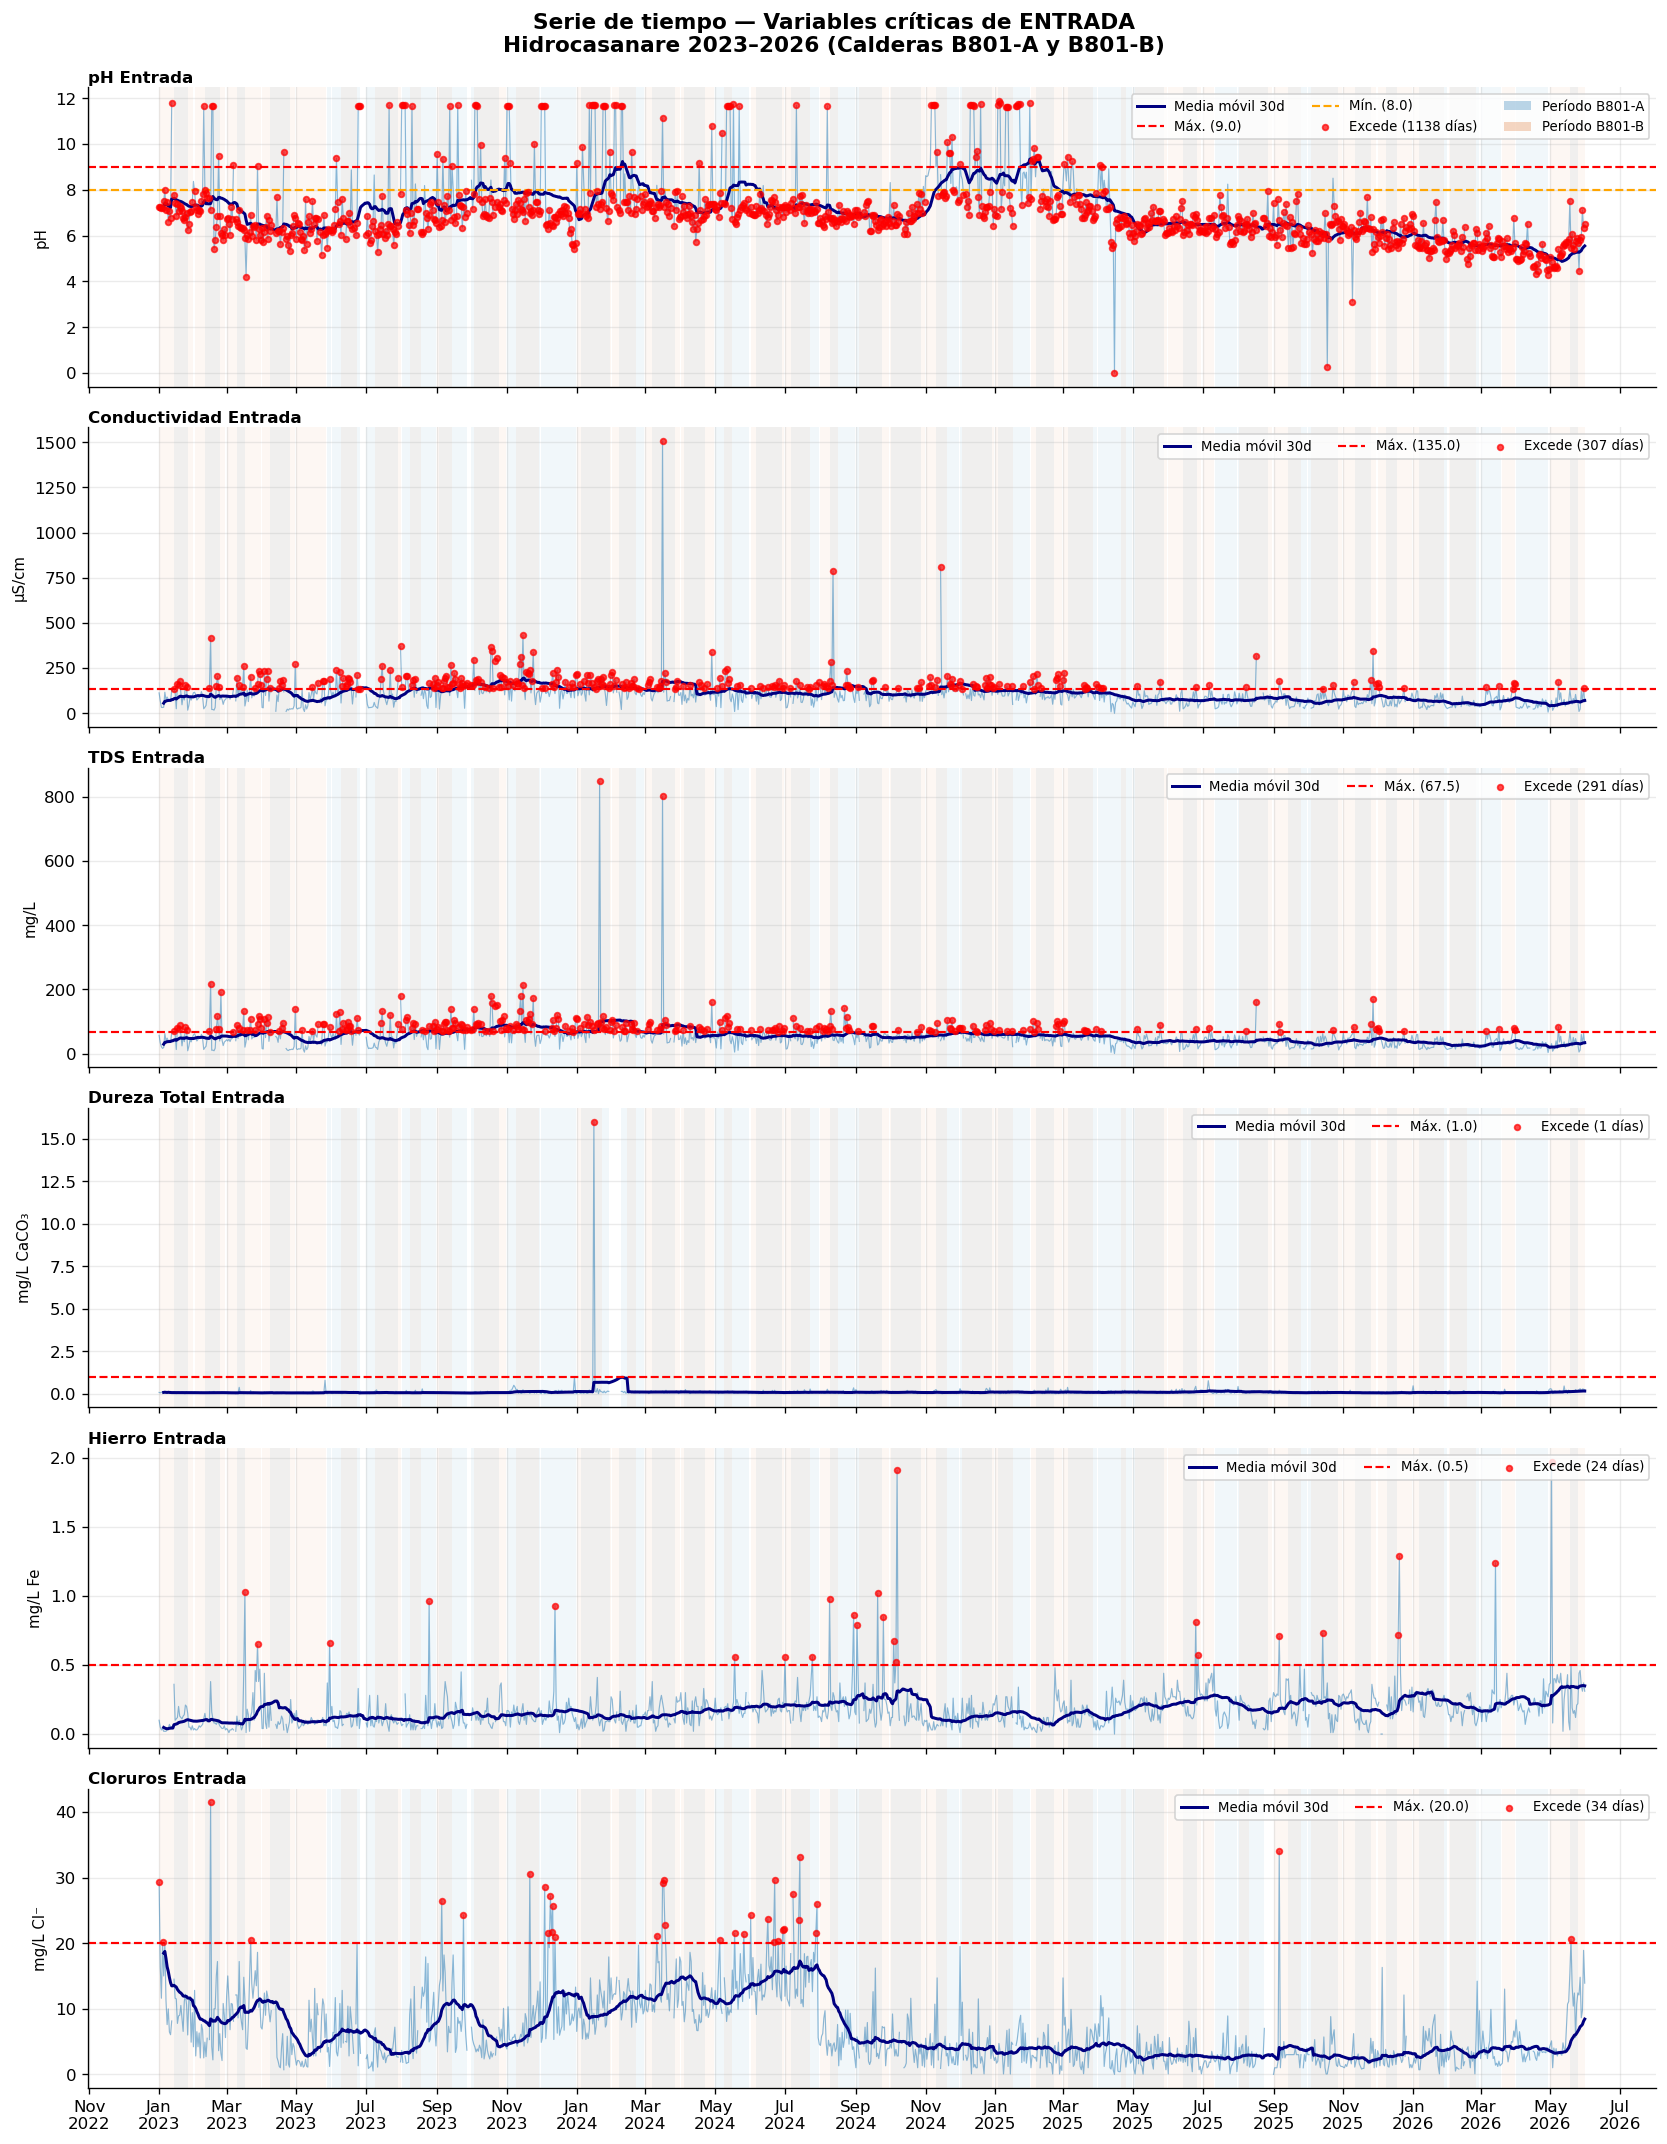

✔  grafica_01_serie_entrada_v2.png guardada


In [70]:
# ── Crear figura con 6 subgráficas apiladas verticalmente ────────────────────
# sharex=True hace que todas compartan el mismo eje X (tiempo), útil para comparar
# figsize aumentado a (14, 18) para acomodar los 2 paneles adicionales
fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)
fig.suptitle("Serie de tiempo — Variables críticas de ENTRADA\nHidrocasanare 2023–2026 (Calderas B801-A y B801-B)",
             fontsize=13, fontweight="bold", y=0.99)

# ── Configuración de cada subgráfica ─────────────────────────────────────────
# Se agregan dureza_entrada y hierro_entrada a las 4 variables originales
config_entrada = [
    ("pH_entrada",            "pH Entrada",           8.0,  9.0,   "pH",          "#1f77b4"),
    ("conductividad_entrada", "Conductividad Entrada", None, 135.0, "µS/cm",       "#1f77b4"),
    ("TDS_entrada",           "TDS Entrada",           None,  67.5, "mg/L",        "#1f77b4"),
    ("dureza_entrada",        "Dureza Total Entrada",  None,   1.0, "mg/L CaCO₃",  "#1f77b4"),
    ("hierro_entrada",        "Hierro Entrada",        None,   0.5, "mg/L Fe",     "#1f77b4"),
    ("cloruros_entrada",      "Cloruros Entrada",      None,  20.0, "mg/L Cl⁻",   "#1f77b4"),
]

for ax, (var, titulo, lmin, lmax, unidad, color) in zip(axes, config_entrada):

    # Filtrar solo los días con dato válido para esta variable
    datos_v = df[["fecha", var]].dropna()

    # ── Corrección de sobresaltos ─────────────────────────────────────────────
    # El problema ocurre cuando hay gaps grandes entre fechas consecutivas
    # (períodos sin datos por alternancia de calderas). Al conectar esos puntos
    # con una línea, matplotlib genera una línea vertical que parece un "sobresalto".
    # Solución: identificar los gaps > 10 días e insertar NaN para romper la línea,
    # de modo que matplotlib no conecte puntos separados por períodos sin datos.
    datos_v = datos_v.copy()
    datos_v = datos_v.set_index("fecha").resample("D").mean().reset_index()
    # Calcular diferencia de días entre fechas consecutivas
    gaps = datos_v["fecha"].diff().dt.days
    # Donde el gap supera 10 días, reemplazar el valor con NaN para romper la línea
    datos_v.loc[gaps > 10, var] = np.nan

    # ── Línea de datos diarios ────────────────────────────────────────────────
    ax.plot(datos_v["fecha"], datos_v[var],
            color=color, linewidth=0.7, alpha=0.5)

    # ── Media móvil de 30 días ────────────────────────────────────────────────
    # resample("D").mean() agrupa por día, rolling(30) calcula la ventana móvil
    # min_periods=5 evita NaN en los primeros días donde no hay 30 datos aún
    mm = datos_v.set_index("fecha")[var].rolling(30, min_periods=5).mean()
    ax.plot(mm.index, mm.values, color="navy", linewidth=1.8, label="Media móvil 30d")

    # ── Líneas horizontales de umbral ─────────────────────────────────────────
    if lmax is not None:
        ax.axhline(lmax, color="red",    linestyle="--", linewidth=1.3, label=f"Máx. ({lmax})")
    if lmin is not None:
        ax.axhline(lmin, color="orange", linestyle="--", linewidth=1.3, label=f"Mín. ({lmin})")

    # ── Puntos de excedencia ──────────────────────────────────────────────────
    # Se recalcula sobre los datos originales sin NaN para no perder excedencias
    datos_orig = df[["fecha", var]].dropna()
    exc = datos_orig[fuera_de_limite(datos_orig[var], lmin, lmax)]
    ax.scatter(exc["fecha"], exc[var], color="red", s=12, zorder=5,
               alpha=0.7, label=f"Excede ({len(exc)} días)")

    # ── Sombreado por caldera ─────────────────────────────────────────────────
    # Verde muy suave = períodos B801-A | Naranja muy suave = períodos B801-B
    # Ayuda a identificar visualmente qué caldera operaba en cada momento
    for caldera, shade_color in [("B801-A", "#1f77b4"), ("B801-B", "#e07b39")]:
        sub_cal = df[df["caldera"] == caldera][["fecha", var]].dropna()
        if len(sub_cal) == 0:
            continue
        # Agrupar por mes para obtener el inicio y fin de cada período
        sub_cal["mes_anio"] = sub_cal["fecha"].dt.to_period("M")
        for periodo, grupo in sub_cal.groupby("mes_anio"):
            ax.axvspan(grupo["fecha"].min(), grupo["fecha"].max(),
                       alpha=0.06, color=shade_color, lw=0)

    ax.set_ylabel(unidad, fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight="bold", loc="left", pad=3)
    ax.legend(fontsize=8, loc="upper right", ncol=4, framealpha=0.8)
    ax.grid(True, alpha=0.25)

# ── Leyenda de sombreado de calderas ─────────────────────────────────────────
from matplotlib.patches import Patch
leyenda_calderas = [
    Patch(facecolor="#1f77b4", alpha=0.3, label="Período B801-A"),
    Patch(facecolor="#e07b39", alpha=0.3, label="Período B801-B"),
]
axes[0].legend(handles=axes[0].get_legend_handles_labels()[0] + leyenda_calderas,
               labels=axes[0].get_legend_handles_labels()[1] + ["Período B801-A", "Período B801-B"],
               fontsize=8, loc="upper right", ncol=3, framealpha=0.8)

# ── Formatear el eje X con fechas ────────────────────────────────────────────
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.savefig("grafica_01_serie_entrada_v2.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_01_serie_entrada_v2.png guardada")

### 4.2 Análisis — Serie de tiempo Variables críticas de ENTRADA
### Calderas B801-A y B801-B | Hidrocasanare 2023–2026

---

### Consideración metodológica previa

Las series de tiempo ahora reflejan datos extraídos directamente de los
informes PDF diarios de laboratorio, corrigiendo el problema identificado
en la fuente Excel donde la celda de identificación de caldera no se
actualizaba automáticamente al cambiar de equipo. Como resultado, los
períodos de operación de cada caldera son ahora más cortos y coherentes
con la rotación mensual real del sistema. El período de análisis se
extiende desde enero 2023 hasta mayo 2026, incorporando los datos de
2026 que constituirán la validación retrospectiva del modelo predictivo.

---

### pH de entrada — 1.138 días de excedencia

El pH de alimentación registró **1.138 días de excedencia** respecto al
rango operativo [8,0–9,0], correspondiente al **95,2 %** del período
analizado (sobre 1.195 días con dato válido). Este nivel es prácticamente
idéntico al 94 % reportado con el dataset anterior desde Excel: la
corrección de extracción (eliminación de los 187 valores que el
extractor anterior capturaba incorrectamente desde los ejes de las
gráficas del PDF) **no representa una mejora en la magnitud del
problema**, sino una mayor confiabilidad del dato — el pH de entrada
está, en efecto, fuera de rango en la inmensa mayoría de los días del
período analizado, y esto ahora se sostiene sobre valores verificados
directamente de la tabla del reporte, no sobre artefactos de extracción.

La serie muestra un patrón bimodal claro: durante 2023 y parte de 2024
los valores oscilaron predominantemente entre 8,0 y 12,0 — dentro o
por encima del rango — con episodios de sobredosificación alcalina
evidenciados por la media móvil que supera el máximo de 9,0 de forma
sostenida. A partir del segundo semestre de 2024 y con mayor claridad
en 2025–2026, la tendencia descendente de la media móvil indica un
debilitamiento progresivo del tratamiento alcalino, con valores que se
acercan o caen por debajo del mínimo de 8,0, llegando incluso a
aproximarse a 4–5 hacia el final del período registrado. Los valores
cercanos a cero visibles en la serie (alrededor de mediados de 2025)
corresponden a eventos puntuales que requieren verificación como
posibles errores de medición o contaminaciones temporales de la fuente
de agua (Shokri & Sanavi Fard, 2023).

---

### Conductividad de entrada — 307 días de excedencia

La conductividad de entrada superó el límite de 135 µS/cm en **307 días
(25,7 %)**, con un pico episódico extremo que alcanza hasta 1.506 µS/cm
a inicios de 2024. La media móvil de 30 días se mantiene oscilando en
torno al umbral durante 2023 y 2024, con descensos más sostenidos hacia
2025–2026, lo que sugiere una mejora moderada en el sistema de
pretratamiento del agua de alimentación, aunque sin una tendencia tan
marcada como la del pH. Los picos extremos se concentran en 2023–2024
y son menos frecuentes hacia 2026.

---

### TDS de entrada — 291 días de excedencia

El TDS de entrada superó el límite de 67,5 mg/L en **291 días (24,4 %)**,
con trayectoria paralela a la conductividad, consistente con la relación
física directa entre ambas variables. La media móvil confirma una
tendencia similar de estabilización hacia el umbral operativo en
2025–2026. Los picos de ~850 mg/L y ~800 mg/L visibles a inicios de
2024 coinciden temporalmente con el pico de conductividad de ese mismo
período y sugieren un evento de falla puntual en el pretratamiento.

---

### Dureza total de entrada — 1 día de excedencia

La dureza registró apenas **1 día de excedencia (0,1 %)** sobre 1.172
días con dato válido durante todo el período, confirmando que el
sistema de ablandamiento opera correctamente y con alta consistencia.
La media móvil se mantiene prácticamente en cero durante los tres años.
El pico puntual de ~16 mg/L CaCO₃ visible a inicios de 2024 requiere
verificación como posible error de medición — es el único evento en
más de 1.000 días de registro y representa una desviación estadística
atípica respecto al comportamiento del resto de la serie.

---

### Hierro de entrada — 24 días de excedencia

El hierro de entrada superó el límite de 0,5 mg/L en **24 días (2,0 %)**,
con una tendencia preocupante: la media móvil de 30 días muestra un
incremento sostenido desde valores cercanos a 0,1 mg/L en 2023 hacia
valores de 0,3–0,5 mg/L en 2025–2026, acercándose progresivamente al
umbral. Este comportamiento sugiere un deterioro gradual en la calidad
del agua fuente o una reducción en la eficiencia del tratamiento de
remoción de hierro, que de continuar podría derivar en excedencias más
frecuentes en el corto plazo (Cardozo et al., 2011).

---

### Cloruros de entrada — 34 días de excedencia

Los cloruros de entrada superaron el límite de 20 mg/L en **34 días
(2,9 %)**, con eventos concentrados principalmente en 2023 y 2024. La
media móvil muestra una mejora progresiva desde ~15–20 mg/L en 2023
hacia valores de 5–10 mg/L en 2025–2026, indicando que las condiciones
de la fuente de agua mejoraron o que el pretratamiento para remoción de
cloruros ganó eficiencia. Los picos aislados que superan el umbral son
eventos puntuales que no representan una tendencia sostenida de
deterioro.

---

### Síntesis del análisis de variables de ENTRADA

El análisis de las variables de entrada con el dataset corregido desde
PDFs revela un panorama distinto al reportado en versiones anteriores
del documento: el pH de entrada **no mejoró** respecto a la cifra
obtenida con la fuente Excel (95,2 % de excedencia frente al 94 %
anterior), y constituye el problema más crítico y persistente del
bloque de entrada, con una tendencia de deterioro adicional hacia
2025–2026. La conductividad y el TDS muestran una mejora moderada hacia
el final del período, sin ser tan pronunciada como se había reportado
inicialmente. El hierro presenta una tendencia creciente que merece
atención antes de que escale a excedencias más frecuentes. La dureza
permanece bien controlada en prácticamente todo el período, validando
la efectividad del sistema de ablandamiento, y los cloruros muestran
una mejora progresiva consistente
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023; Nikula et al., 2016).

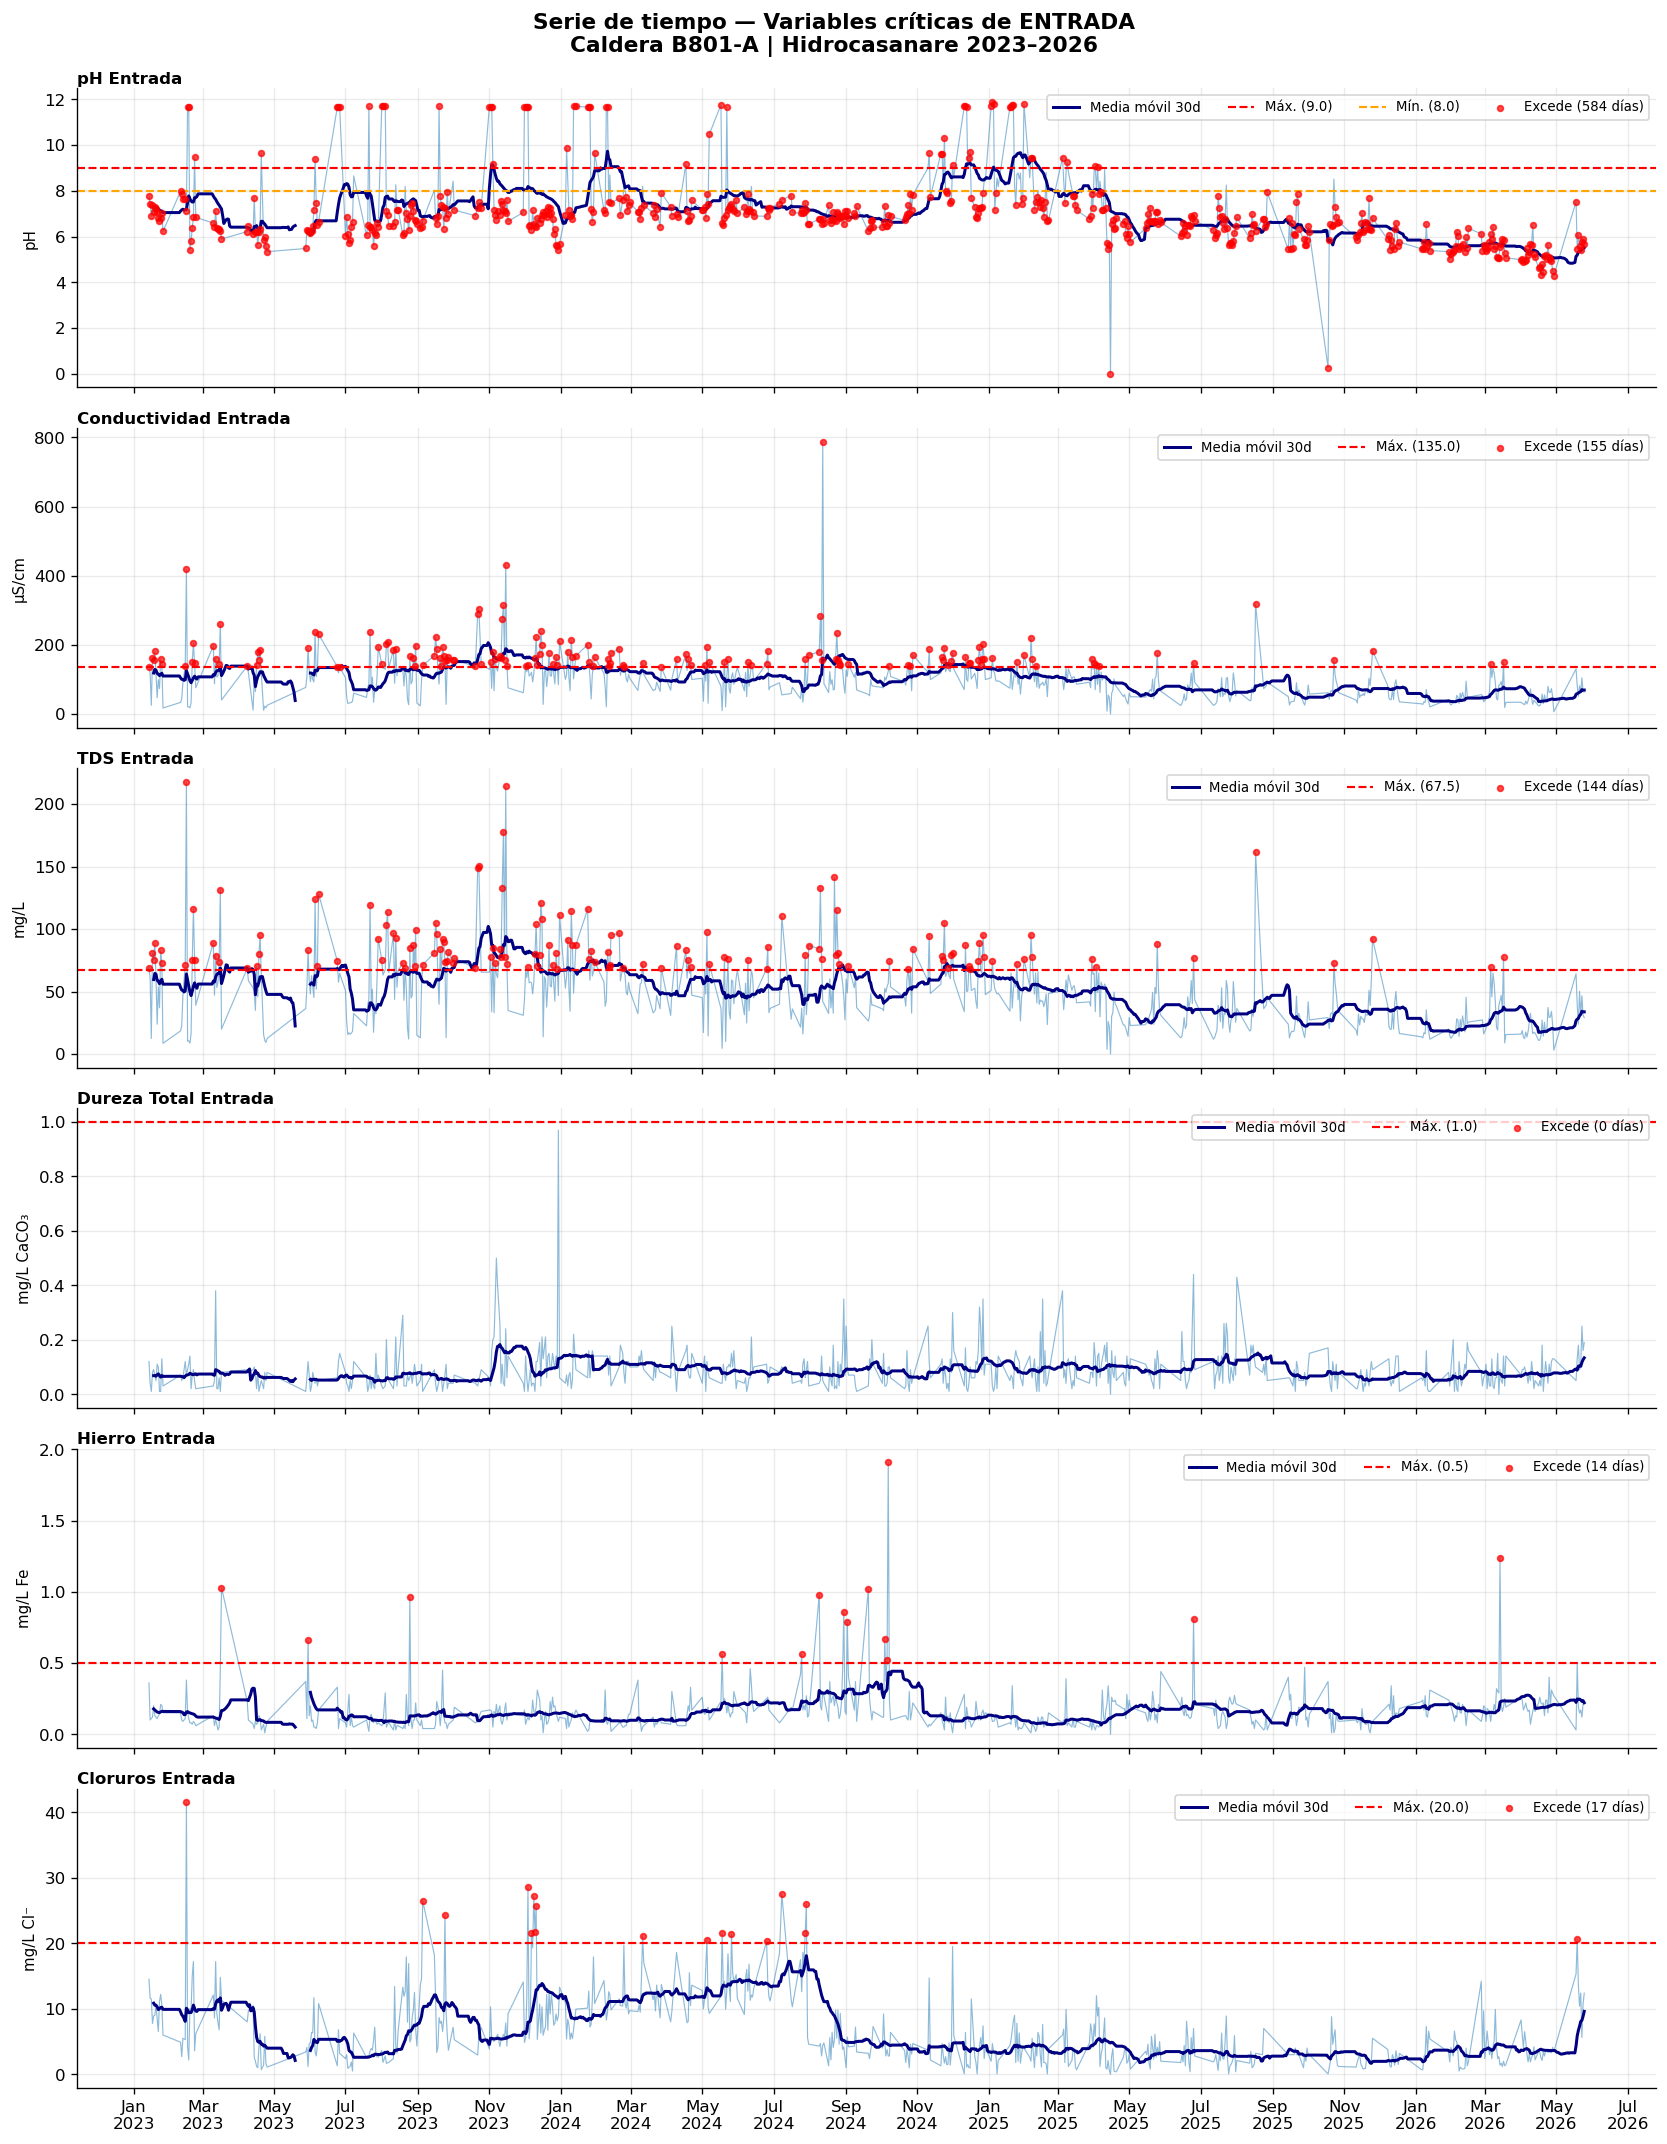

✔  grafica_entrada_B801A.png guardada


In [71]:
# ── Filtrar datos únicamente de la caldera B801-A ─────────────────────────────
df_A = df[df["caldera"] == "B801-A"].copy().reset_index(drop=True)

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)
fig.suptitle("Serie de tiempo — Variables críticas de ENTRADA\nCaldera B801-A | Hidrocasanare 2023–2026",
             fontsize=13, fontweight="bold", y=0.99)

# 6 variables con umbral definido — formato: (columna, título, lim_min, lim_max, unidad, color)
config_entrada_A = [
    ("pH_entrada",            "pH Entrada",            8.0,  9.0,   "pH",          "#1f77b4"),
    ("conductividad_entrada", "Conductividad Entrada",  None, 135.0, "µS/cm",       "#1f77b4"),
    ("TDS_entrada",           "TDS Entrada",            None,  67.5, "mg/L",        "#1f77b4"),
    ("dureza_entrada",        "Dureza Total Entrada",   None,   1.0, "mg/L CaCO₃",  "#1f77b4"),
    ("hierro_entrada",        "Hierro Entrada",         None,   0.5, "mg/L Fe",     "#1f77b4"),
    ("cloruros_entrada",      "Cloruros Entrada",       None,  20.0, "mg/L Cl⁻",   "#1f77b4"),
]

for ax, (var, titulo, lmin, lmax, unidad, color) in zip(axes, config_entrada_A):

    datos_v = df_A[["fecha", var]].dropna()

    # Línea de datos diarios (fina y semitransparente como fondo)
    ax.plot(datos_v["fecha"], datos_v[var],
            color=color, linewidth=0.7, alpha=0.5)

    # Media móvil de 30 días para suavizar fluctuaciones y ver la tendencia real
    mm = datos_v.set_index("fecha").resample("D").mean()[var].rolling(30, min_periods=5).mean()
    ax.plot(mm.index, mm.values, color="navy", linewidth=1.8, label="Media móvil 30d")

    # Líneas de umbrales operativos
    if lmax is not None:
        ax.axhline(lmax, color="red",    linestyle="--", linewidth=1.3, label=f"Máx. ({lmax})")
    if lmin is not None:
        ax.axhline(lmin, color="orange", linestyle="--", linewidth=1.3, label=f"Mín. ({lmin})")

    # Puntos rojos en los días que exceden el umbral
    exc = datos_v[fuera_de_limite(datos_v[var], lmin, lmax)]
    ax.scatter(exc["fecha"], exc[var], color="red", s=12, zorder=5,
               alpha=0.7, label=f"Excede ({len(exc)} días)")

    ax.set_ylabel(unidad, fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight="bold", loc="left", pad=3)
    ax.legend(fontsize=8, loc="upper right", ncol=4, framealpha=0.8)
    ax.grid(True, alpha=0.25)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.savefig("grafica_entrada_B801A.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_entrada_B801A.png guardada")

### 4.2.1 Caldera B801-A — Variables de ENTRADA

**pH de entrada (584 días de excedencia, 93,7 %):**
Durante los períodos de operación de B801-A, el pH del agua de alimentación
se mantuvo consistentemente por debajo del límite mínimo de 8,0, con la media
móvil oscilando entre 6,5 y 7,5 a lo largo de buena parte del período analizado.
Se identifican dos comportamientos diferenciados: durante 2023 y parte de 2024
el pH mostró episodios marcados de caída hacia valores de 2,0–4,0, mientras
que en 2025 la tendencia es claramente descendente y más estable, con la media
móvil oscilando entre 6,0 y 7,5. A inicios de 2025 se observa un repunte hacia
valores de 9,0–10,0 que luego vuelve a descender. Los puntos que superan el
máximo de 9,0 corresponden a episodios de sobredosificación del agente
alcalinizante, concentrados especialmente en 2023 y a inicios de 2025. Con 584
días de excedencia sobre 623 días con dato válido en B801-A (93,7 %), esta
condición ácida del agua de alimentación es la anomalía más persistente y
extendida de todo el bloque de entrada en esta caldera, y favorece la
corrosión por picadura en las superficies internas del equipo
(Shokri & Sanavi Fard, 2023).

**Conductividad de entrada (155 días de excedencia, 24,9 %):**
La media móvil se mantiene generalmente cercana o por encima del límite máximo
de 135 µS/cm durante 2023 y buena parte de 2024, con excedencias frecuentes en
ese período. Se observa una mejora progresiva hacia 2025 y 2026, donde la media
móvil desciende notoriamente por debajo del umbral, llegando a valores cercanos
a 50 µS/cm hacia el final del período, sugiriendo ajustes positivos sostenidos
en el sistema de pretratamiento durante los turnos de esta caldera. El pico
aislado que alcanza casi 800 µS/cm en el segundo semestre de 2024 corresponde
a un evento puntual de falla o saturación del sistema de tratamiento previo.

**TDS de entrada (144 días de excedencia, 23,1 %):**
El comportamiento es prácticamente espejo de la conductividad, consistente con
la relación física directa entre ambas variables (r = 0,75). La media móvil
muestra la misma tendencia de mejora hacia 2025–2026, con valores que descienden
progresivamente desde 50–100 mg/L durante 2023–2024 hacia 25–30 mg/L en el tramo
final. El TDS presenta un porcentaje de excedencia (23,1 %) ligeramente por
debajo del de conductividad (24,9 %) en esta caldera, manteniendo el mismo
patrón general de comportamiento conjunto entre ambas variables. El pico
máximo registrado (~215 mg/L) ocurre a inicios de 2023 y un segundo pico
cercano a 215 mg/L hacia finales de 2023, coincidiendo temporalmente con picos
de conductividad, lo que confirma que responden al mismo evento operativo.

**Dureza total de entrada (0 días de excedencia, 0,0 %):**
Este es el resultado más positivo del análisis de B801-A. La dureza se mantuvo
en todo momento por debajo del límite máximo de 1,0 mg/L CaCO₃ durante los 618
días con dato válido, con la media móvil prácticamente en cero durante casi
todo el período. Esto indica que el sistema de ablandamiento funciona
correctamente durante los períodos de operación de esta caldera, eliminando
eficazmente el calcio y el magnesio que generan incrustaciones. El pico
puntual observado a inicios de 2024 (~0,95 mg/L) no supera el umbral y puede
asociarse a una regeneración del ablandador o a una variación en la fuente de
agua cruda.

**Hierro de entrada (14 días de excedencia, 2,3 %):**
La media móvil se mantiene predominantemente por debajo de 0,5 mg/L Fe durante
casi todo el período, con un pico aislado que alcanza casi 1,9 mg/L hacia
finales de 2024 — el evento más severo de toda la serie. Se observa una
tendencia creciente hacia el segundo semestre de 2024, con la media móvil
acercándose al límite operativo antes de descender nuevamente en 2025. Los
14 eventos de excedencia se concentran principalmente en 2023 y en el segundo
semestre de 2024, con un evento adicional aislado a inicios de 2026. El hierro
en el agua de alimentación se deposita sobre las superficies de transferencia
de calor, contribuyendo al deterioro acumulado del equipo (Cardozo et al., 2011).

**Cloruros de entrada (17 días de excedencia, 2,7 %):**
La media móvil mostró un período de valores elevados entre mediados de 2023 y
principios de 2024, alcanzando hasta 15–18 mg/L Cl⁻ de manera sostenida, con
picos que superaron el límite de 20 mg/L en varias ocasiones durante ese tramo.
A partir de mediados de 2024 los valores se controlaron de forma consistente
por debajo de 10 mg/L, manteniéndose así hasta 2026, con la única excepción de
un pico aislado que supera nuevamente los 20 mg/L al final del período (mayo
2026). Este repunte puntual podría señalar el inicio de un nuevo episodio de
variación en la calidad del agua fuente que merece seguimiento.

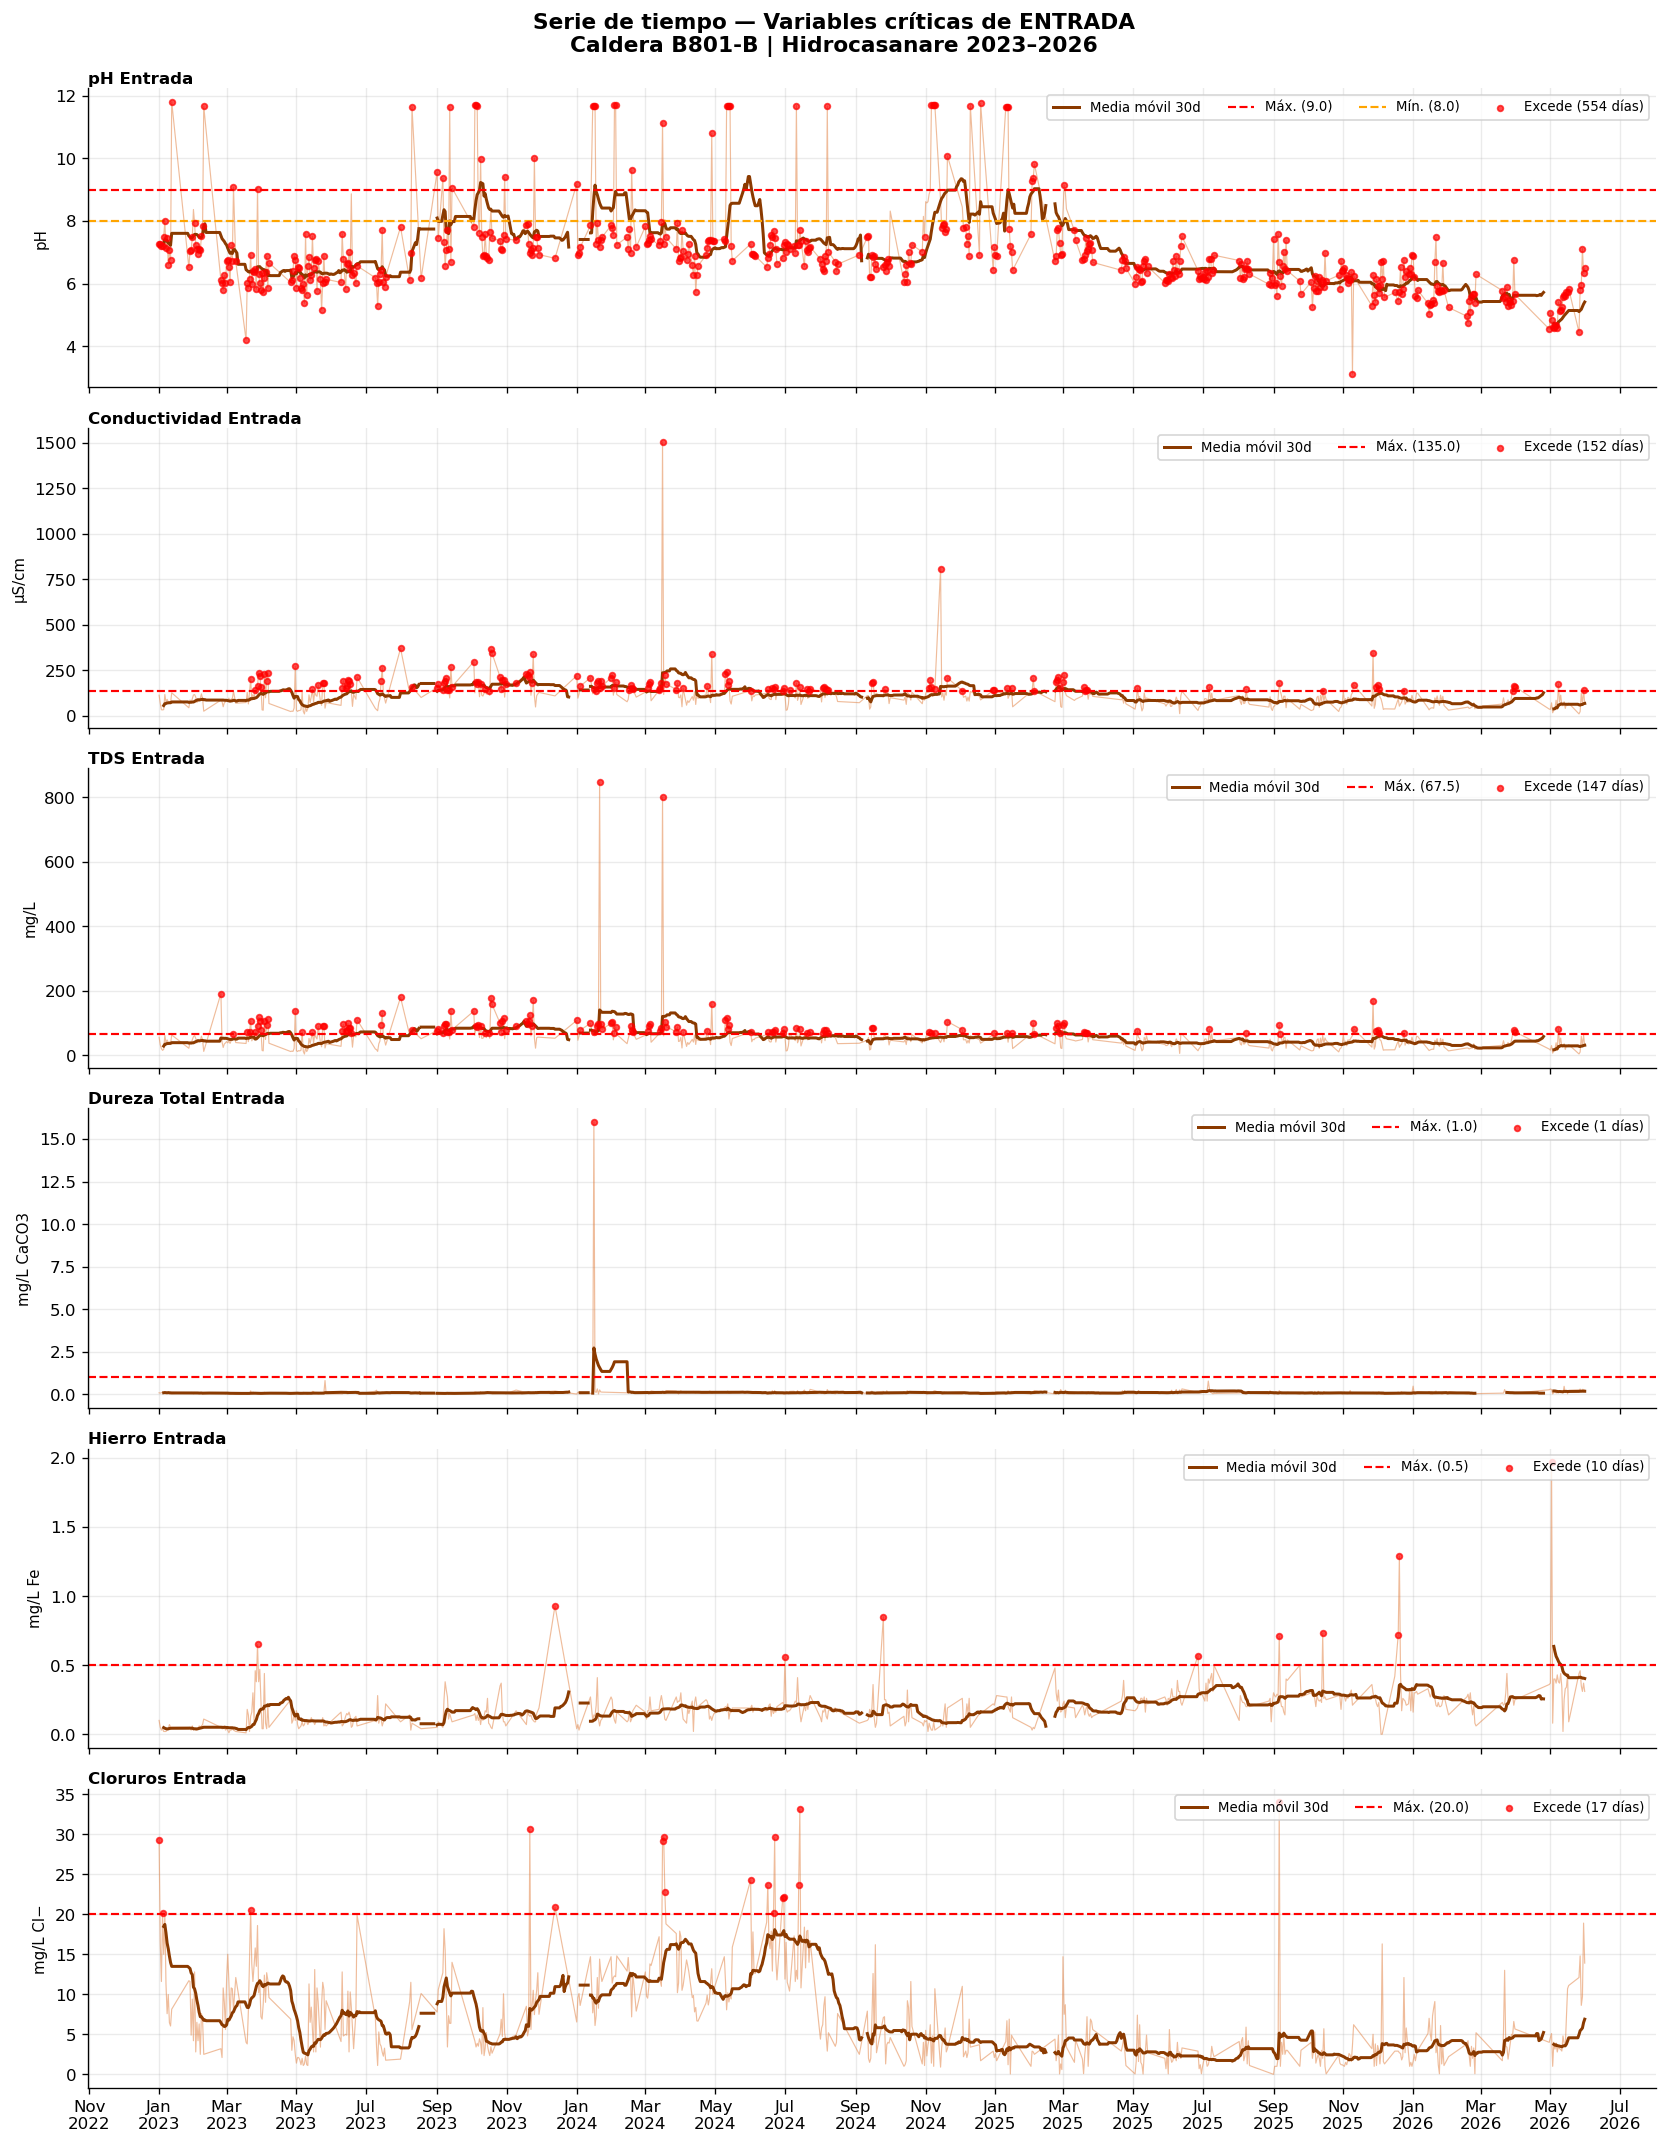

✔  grafica_entrada_B801B.png guardada


In [72]:
# ── Filtrar datos únicamente de la caldera B801-B ─────────────────────────────
# df["caldera"] == "B801-B" crea una máscara True/False por cada fila
# .copy() evita el warning de pandas al modificar un subconjunto del DataFrame original
# .reset_index(drop=True) renumera el índice desde 0 para el nuevo DataFrame filtrado
df_B = df[df["caldera"] == "B801-B"].copy().reset_index(drop=True)

# Crear figura con 6 subgráficas apiladas verticalmente — una por variable de entrada
# sharex=True hace que todas compartan el mismo eje X (tiempo), útil para comparar
# figsize=(14, 18): ancho 14 pulgadas, alto 18 pulgadas para acomodar 6 paneles
fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)

# Título general de la figura con dos líneas usando \n
# y=0.99 sube el título para que no se superponga con la primera subgráfica
fig.suptitle(
    "Serie de tiempo — Variables críticas de ENTRADA\n"
    "Caldera B801-B | Hidrocasanare 2023–2026",   # actualizado a 2026
    fontsize=13, fontweight="bold", y=0.99
)

# ── Configuración de cada subgráfica ─────────────────────────────────────────
# Cada tupla define: (columna_df, título, límite_mín, límite_máx, unidad, color)
# None en límite significa que no hay restricción en esa dirección
# Color naranja #e07b39 identifica visualmente a B801-B en todo el análisis
config_entrada_B = [
    ("pH_entrada",            "pH Entrada",            8.0,  9.0,   "pH",          "#e07b39"),
    # pH: rango bilateral [8,0–9,0] — se excede tanto por arriba como por abajo
    ("conductividad_entrada", "Conductividad Entrada",  None, 135.0, "μS/cm",       "#e07b39"),
    # Conductividad: solo límite máximo de 135 µS/cm
    ("TDS_entrada",           "TDS Entrada",            None,  67.5, "mg/L",        "#e07b39"),
    # TDS: solo límite máximo de 67,5 mg/L
    ("dureza_entrada",        "Dureza Total Entrada",   None,   1.0, "mg/L CaCO3",  "#e07b39"),
    # Dureza: solo límite máximo de 1,0 mg/L CaCO3
    ("hierro_entrada",        "Hierro Entrada",         None,   0.5, "mg/L Fe",     "#e07b39"),
    # Hierro: solo límite máximo de 0,5 mg/L Fe
    ("cloruros_entrada",      "Cloruros Entrada",       None,  20.0, "mg/L Cl−",   "#e07b39"),
    # Cloruros: solo límite máximo de 20 mg/L Cl-
]

# ── Dibujar cada subgráfica ───────────────────────────────────────────────────
# zip(axes, config_entrada_B) empareja cada panel con su configuración
# ax = panel de matplotlib | var = nombre de columna | titulo, lmin, lmax, unidad, color = parámetros
for ax, (var, titulo, lmin, lmax, unidad, color) in zip(axes, config_entrada_B):

    # Extraer solo las columnas fecha y variable actual, eliminando filas con NaN
    # dropna() evita que los NaN interrumpan la línea de la gráfica
    datos_v = df_B[["fecha", var]].dropna()

    # ── Línea de valores diarios ──────────────────────────────────────────────
    # linewidth=0.7: línea delgada para mostrar la variabilidad diaria
    # alpha=0.5: semitransparente para que no tape la media móvil
    ax.plot(
        datos_v["fecha"],   # eje X: fechas
        datos_v[var],       # eje Y: valores diarios de la variable
        color=color,        # naranja para B801-B
        linewidth=0.7,
        alpha=0.5
    )

    # ── Media móvil de 30 días ────────────────────────────────────────────────
    # set_index("fecha"): convierte fecha en índice para usar resample
    # resample("D").mean(): agrupa por día y calcula promedio (por si hay duplicados)
    # rolling(30, min_periods=5): ventana de 30 días, calcula desde que hay 5 datos
    # .mean(): promedio de la ventana — suaviza fluctuaciones diarias
    mm = (datos_v
          .set_index("fecha")
          .resample("D").mean()        # un valor por día
          [var]
          .rolling(30, min_periods=5)  # ventana de 30 días
          .mean())                     # media móvil

    # Dibujar la media móvil con línea más gruesa y oscura para destacarla
    ax.plot(
        mm.index,      # eje X: fechas (índice después del resample)
        mm.values,     # eje Y: valores suavizados
        color="#8B3A00",   # café oscuro — contrasta con el naranja claro de los datos
        linewidth=1.8,
        label="Media móvil 30d"
    )

    # ── Líneas horizontales de umbrales operativos ────────────────────────────
    if lmax is not None:
        # Línea roja punteada en el límite máximo
        ax.axhline(
            lmax,
            color="red", linestyle="--", linewidth=1.3,
            label=f"Máx. ({lmax})"   # etiqueta con el valor del umbral
        )
    if lmin is not None:
        # Línea naranja punteada en el límite mínimo (solo pH tiene mínimo)
        ax.axhline(
            lmin,
            color="orange", linestyle="--", linewidth=1.3,
            label=f"Mín. ({lmin})"   # etiqueta con el valor del umbral
        )

    # ── Puntos rojos en días que exceden el umbral ────────────────────────────
    # fuera_de_limite() es la función definida en la sección 4.1
    # Retorna una máscara True/False indicando qué filas exceden el rango
    exc = datos_v[fuera_de_limite(datos_v[var], lmin, lmax)]

    # scatter dibuja puntos individuales — s=12 es el tamaño del punto
    # zorder=5 hace que los puntos queden por encima de las líneas
    ax.scatter(
        exc["fecha"],    # eje X: fechas de excedencia
        exc[var],        # eje Y: valores que exceden el umbral
        color="red",
        s=12,            # tamaño del punto en puntos²
        zorder=5,        # nivel de capas — encima de las líneas
        alpha=0.7,
        label=f"Excede ({len(exc)} días)"   # cantidad de días con excedencia
    )

    # ── Configuración visual del panel ────────────────────────────────────────
    ax.set_ylabel(unidad, fontsize=9)   # etiqueta del eje Y con la unidad de medida
    ax.set_title(
        titulo,
        fontsize=10, fontweight="bold",
        loc="left",   # título alineado a la izquierda del panel
        pad=3         # separación en puntos entre el título y la gráfica
    )
    ax.legend(
        fontsize=8,
        loc="upper right",   # leyenda en esquina superior derecha
        ncol=4,              # 4 columnas en la leyenda para que quepa en una línea
        framealpha=0.8       # fondo semitransparente de la leyenda
    )
    ax.grid(True, alpha=0.25)   # cuadrícula suave para facilitar la lectura

# ── Configurar el eje X solo en el panel inferior (sharex comparte el resto) ──
# DateFormatter("%b\n%Y"): muestra mes abreviado y año en dos líneas (ej: "Ene\n2023")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
# MonthLocator(interval=2): una marca en el eje X cada 2 meses
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Ajustar márgenes automáticamente para que nada se corte
plt.tight_layout()

# Guardar la figura en alta resolución
plt.savefig("grafica_entrada_B801B.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_entrada_B801B.png guardada")

### 4.2.2 Caldera B801-B — Variables de ENTRADA

**pH de entrada (554 días de excedencia, 96,9 %):**
B801-B registró **554 días de excedencia** respecto al rango [8,0–9,0]
sobre 572 días con dato válido (96,9 %) — el porcentaje más alto de
excedencia de pH entre ambas calderas, superando incluso el 93,7 % de
B801-A. La serie muestra un patrón claro: durante 2023 y parte de 2024
los valores oscilaron entre 8,0 y 12,0 con episodios frecuentes de
sobredosificación alcalina evidenciados por puntos rojos por encima del
máximo de 9,0. A partir del segundo semestre de 2024 la media móvil
muestra una tendencia descendente sostenida hacia 6,0–7,0, indicando
debilitamiento progresivo del tratamiento alcalino que se intensifica
hacia 2025–2026, llegando a valores mínimos cercanos a 3,0 a finales de
2025. Los valores cercanos a 3–4 visibles en la serie corresponden a
eventos puntuales que deben verificarse como posibles errores de
medición o fallas temporales del instrumento (Shokri & Sanavi Fard, 2023).

**Conductividad de entrada (152 días de excedencia, 26,6 %):**
B801-B registró **152 días de excedencia** del límite de 135 µS/cm sobre
572 días con dato válido (26,6 %), con el pico más extremo de toda la
serie (~1.500 µS/cm) ocurrido durante un período de operación de B801-B
a inicios de 2024, indicando un evento de contaminación o falla del
pretratamiento de mayor magnitud que los observados en B801-A. La media
móvil confirma una tendencia de mejora progresiva desde ~150–200 µS/cm
en 2023 hacia valores cercanos o por debajo del umbral en 2025–2026,
consistente con intervenciones en el sistema de pretratamiento
documentadas también en las variables de TDS y cloruros.

**TDS de entrada (147 días de excedencia, 25,7 %):**
Con **147 días de excedencia** del límite de 67,5 mg/L sobre 572 días
con dato válido (25,7 %), el TDS muestra trayectoria correlacionada con
la conductividad (r = 0,75) — ambos porcentajes son prácticamente
idénticos en esta caldera (25,7 % frente a 26,6 %). Los dos picos
extremos superiores a 800 mg/L (a inicios de 2024) coinciden
temporalmente con el evento de conductividad elevada de ese mismo
período, confirmando que se trata del mismo fenómeno de contaminación o
falla puntual del pretratamiento. La media móvil describe la misma
tendencia favorable hacia 2025–2026, con valores promedio que descienden
progresivamente hacia el rango operativo.

**Dureza total de entrada (1 día de excedencia, 0,2 %):**
Al igual que en B801-A, la dureza está excelentemente controlada durante
los períodos de operación de B801-B, con prácticamente toda la serie por
debajo de 0,2 mg/L CaCO₃ y solo **1 día de excedencia** sobre 554 días
con dato válido (0,2 %) en todo el período analizado. El único evento
registrado (~16 mg/L) corresponde al mismo pico puntual identificado en
el análisis conjunto, ocurrido a inicios de 2024 — por su magnitud y
aislamiento respecto al comportamiento habitual de la serie puede
considerarse un error de medición o falla momentánea del sistema de
ablandamiento. Este hallazgo confirma que el pretratamiento para
remoción de dureza opera correctamente en ambas calderas
(Cardozo et al., 2011).

**Hierro de entrada (10 días de excedencia, 1,8 %):**
B801-B registró **10 días de excedencia** del límite de 0,5 mg/L Fe sobre
569 días con dato válido (1,8 %), con picos que alcanzan hasta 1,3 mg/L
Fe concentrados principalmente en 2025 y un evento más severo cercano a
2,0 mg/L a inicios de 2026. La media móvil muestra una tendencia
creciente preocupante desde valores de ~0,1 mg/L en 2023 hacia 0,3–0,5
mg/L hacia el cierre del período, acercándose progresivamente al umbral.
Este comportamiento, coincidente con la tendencia identificada en
B801-A, sugiere un deterioro gradual en la calidad del agua fuente o
una reducción en la eficiencia del tratamiento de remoción de hierro
que merece seguimiento en los próximos meses (Cardozo et al., 2011).

**Cloruros de entrada (17 días de excedencia, 3,0 %):**
B801-B registró **17 días de excedencia** del límite de 20 mg/L Cl⁻
sobre 568 días con dato válido (3,0 %), con eventos concentrados
principalmente en 2023–2024 y valores que alcanzaron hasta ~33 mg/L. La
media móvil describe una mejora sostenida desde ~15–20 mg/L en 2023
hacia valores de 5–10 mg/L en 2025–2026, confirmando que las condiciones
de la fuente de agua mejoraron o que el pretratamiento para remoción de
cloruros ganó eficiencia en ese período. Un evento aislado visible en
2025 que supera los 30 mg/L representa un pico puntual que no revierte
la tendencia general de mejora.

---

### 4.3 Serie de tiempo — Variables críticas de PURGA

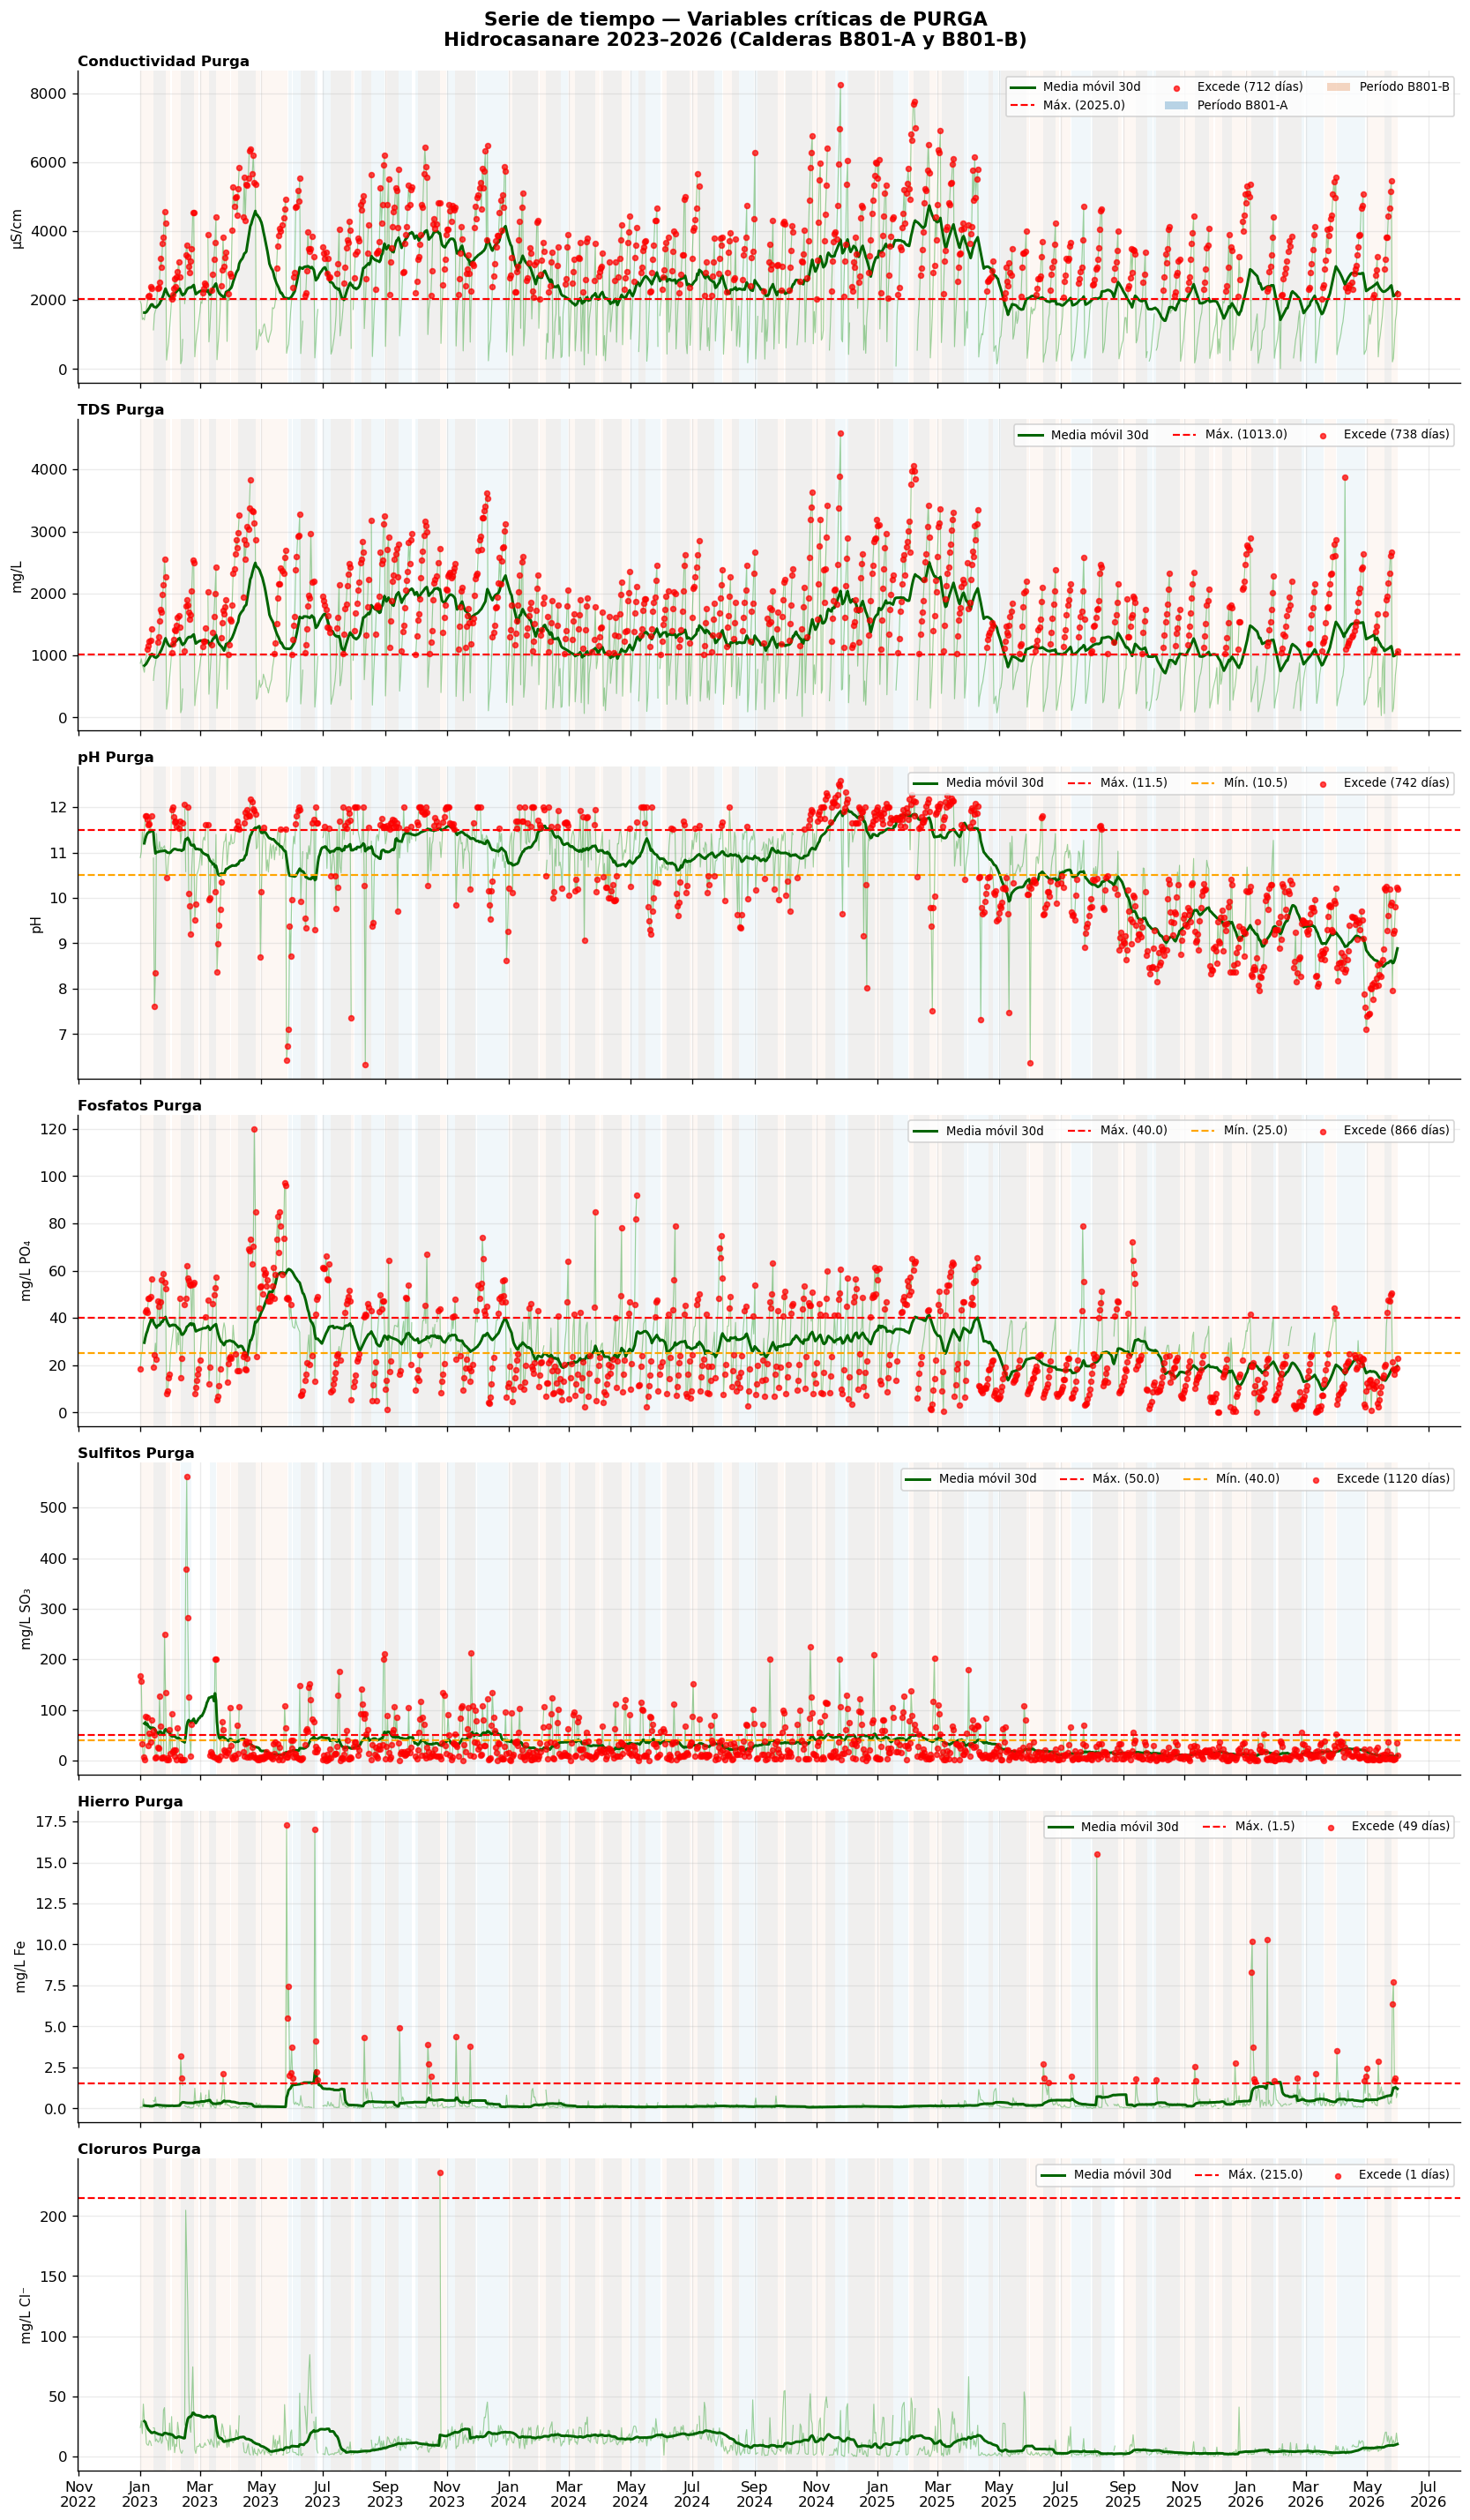

✔  grafica_purga_conjunta.png guardada


In [73]:
# ── Importar Patch para crear elementos de leyenda personalizados ─────────────
# Patch permite crear rectángulos de color en la leyenda para identificar
# visualmente los períodos de operación de cada caldera
from matplotlib.patches import Patch

# ── Crear la figura con 7 subgráficas apiladas verticalmente ─────────────────
# plt.subplots(7, 1) = 7 filas de gráficas, 1 columna
# figsize=(14, 24) = 14 pulgadas de ancho, 24 de alto (alto por los 7 paneles)
# sharex=True = todos los paneles comparten el mismo eje X de fechas
fig, axes = plt.subplots(7, 1, figsize=(14, 24), sharex=True)

# ── Título principal de toda la figura ───────────────────────────────────────
# \n dentro del texto = salto de línea para no cortar el título
# y=0.99 = posición vertical del título (1.0 = tope de la figura)
fig.suptitle("Serie de tiempo — Variables críticas de PURGA\n"
             "Hidrocasanare 2023–2026 (Calderas B801-A y B801-B)",
             fontsize=13, fontweight="bold", y=0.99)

# ── Lista de configuración de cada panel ─────────────────────────────────────
# Cada elemento es una tupla con:
# (nombre de la columna en df, título del panel, límite mínimo,
#  límite máximo, unidad del eje Y, color de la línea)
# None en lim_min o lim_max = sin límite en esa dirección
config_purga = [
    ("conductividad_purga", "Conductividad Purga", None,  2025.0, "µS/cm",     "#2ca02c"),
    ("TDS_purga",           "TDS Purga",           None,  1013.0, "mg/L",      "#2ca02c"),
    ("pH_purga",            "pH Purga",            10.5,    11.5, "pH",        "#2ca02c"),
    ("fosfatos_purga",      "Fosfatos Purga",      25.0,    40.0, "mg/L PO₄", "#2ca02c"),
    ("sulfitos_purga",      "Sulfitos Purga",      40.0,    50.0, "mg/L SO₃", "#2ca02c"),
    ("hierro_purga",        "Hierro Purga",        None,     1.5, "mg/L Fe",   "#2ca02c"),
    ("cloruros_purga",      "Cloruros Purga",      None,   215.0, "mg/L Cl⁻", "#2ca02c"),
]

# ── Recorrer cada panel junto con su configuración ───────────────────────────
# zip(axes, config_purga) empareja cada subgráfica con su configuración
# ax = el panel actual | var = nombre columna | titulo, lmin, lmax, unidad, color = configuración
for ax, (var, titulo, lmin, lmax, unidad, color) in zip(axes, config_purga):

    # ── Filtrar filas donde esta variable tiene dato válido ───────────────────
    # df[["fecha", var]] = tomar solo las columnas de fecha y la variable actual
    # .dropna() = eliminar filas donde el valor sea NaN (sin dato)
    datos_v = df[["fecha", var]].dropna()

    # ── Corrección de sobresaltos por gaps entre períodos de caldera ──────────
    # Cuando una caldera deja de operar, hay meses sin datos. Si matplotlib
    # conecta el último punto antes del gap con el primero después, genera
    # una línea vertical que parece un "sobresalto". La solución es:
    datos_gap = datos_v.copy()   # copiar para no modificar los datos originales

    # resample("D").mean() = crear una fila por cada día del rango completo
    # Los días sin dato quedan con NaN automáticamente
    datos_gap = datos_gap.set_index("fecha").resample("D").mean().reset_index()

    # .diff() calcula la diferencia entre fechas consecutivas
    # .dt.days convierte esa diferencia a número de días
    gaps = datos_gap["fecha"].diff().dt.days

    # Donde el gap entre fechas sea mayor a 10 días → insertar NaN
    # Esto hace que matplotlib "levante el lápiz" y no dibuje línea en ese salto
    datos_gap.loc[gaps > 10, var] = np.nan

    # ── Dibujar la línea de valores diarios ───────────────────────────────────
    # linewidth=0.7 = línea muy fina para no saturar visualmente
    # alpha=0.45 = 45% de opacidad, semitransparente como fondo
    ax.plot(datos_gap["fecha"], datos_gap[var],
            color=color, linewidth=0.7, alpha=0.45)

    # ── Calcular y dibujar la media móvil de 30 días ──────────────────────────
    # La media móvil promedia los últimos 30 días en cada punto, suavizando
    # el ruido diario para mostrar la tendencia real del parámetro
    # min_periods=5 = calcular aunque no haya 30 días completos (inicio de serie)
    mm = datos_gap.set_index("fecha")[var].rolling(30, min_periods=5).mean()

    # color="darkgreen" = verde oscuro para distinguir la tendencia de los datos crudos
    # linewidth=1.8 = línea más gruesa para que resalte sobre los datos diarios
    ax.plot(mm.index, mm.values,
            color="darkgreen", linewidth=1.8, label="Media móvil 30d")

    # ── Dibujar líneas horizontales de umbrales operativos ────────────────────
    # axhline = línea horizontal que cruza todo el panel en el valor indicado
    if lmax is not None:    # solo si existe un límite máximo para esta variable
        ax.axhline(lmax, color="red", linestyle="--", linewidth=1.3,
                   label=f"Máx. ({lmax})")    # rojo = límite máximo
    if lmin is not None:    # solo si existe un límite mínimo para esta variable
        ax.axhline(lmin, color="orange", linestyle="--", linewidth=1.3,
                   label=f"Mín. ({lmin})")    # naranja = límite mínimo

    # ── Marcar los días que exceden el umbral con puntos rojos ────────────────
    # Se usa datos_v ORIGINAL (sin NaN insertados) para no perder excedencias
    # fuera_de_limite() retorna True en cada fila donde el valor sale del rango
    exc = datos_v[fuera_de_limite(datos_v[var], lmin, lmax)]

    # scatter = puntos individuales (no conectados con línea)
    # s=12 = tamaño del punto | zorder=5 = dibujar encima de las líneas
    ax.scatter(exc["fecha"], exc[var],
               color="red", s=12, zorder=5, alpha=0.7,
               label=f"Excede ({len(exc)} días)")

    # ── Sombreado de fondo para identificar qué caldera operaba ──────────────
    # Se recorre cada caldera y se pinta el fondo de su color durante sus meses
    for caldera, shade_color in [("B801-A", "#1f77b4"), ("B801-B", "#e07b39")]:

        # Filtrar registros de esta caldera para esta variable
        sub_cal = df[df["caldera"] == caldera][["fecha", var]].dropna()
        if len(sub_cal) == 0:    # saltar si no hay datos para esta caldera
            continue

        sub_cal = sub_cal.copy()

        # Agrupar por mes-año para obtener el rango de fechas de cada período
        # dt.to_period("M") convierte fecha a período mensual (ej: "2023-01")
        sub_cal["mes_anio"] = sub_cal["fecha"].dt.to_period("M")

        # Recorrer cada mes de operación de esta caldera
        for periodo, grupo in sub_cal.groupby("mes_anio"):
            # axvspan dibuja un rectángulo vertical entre dos fechas
            # alpha=0.06 = muy transparente para no tapar los datos
            # lw=0 = sin borde en el rectángulo
            ax.axvspan(grupo["fecha"].min(), grupo["fecha"].max(),
                       alpha=0.06, color=shade_color, lw=0)

    # ── Configuración visual del panel ────────────────────────────────────────
    ax.set_ylabel(unidad, fontsize=9)    # etiqueta del eje Y con la unidad
    ax.set_title(titulo, fontsize=10, fontweight="bold", loc="left", pad=3)
    ax.legend(fontsize=8, loc="upper right", ncol=4, framealpha=0.8)
    ax.grid(True, alpha=0.25)    # cuadrícula suave para facilitar lectura

# ── Agregar leyenda del sombreado al primer panel ─────────────────────────────
# Patch crea un rectángulo de color para la leyenda
leyenda_calderas = [
    Patch(facecolor="#1f77b4", alpha=0.3, label="Período B801-A"),
    Patch(facecolor="#e07b39", alpha=0.3, label="Período B801-B"),
]
# get_legend_handles_labels() recupera los elementos de leyenda ya existentes
# para no perderlos al agregar los nuevos parches de caldera
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles + leyenda_calderas,
               labels=labels + ["Período B801-A", "Período B801-B"],
               fontsize=8, loc="upper right", ncol=3, framealpha=0.8)

# ── Formatear el eje X del panel inferior ────────────────────────────────────
# Solo se configura en axes[-1] (último panel) porque sharex=True
# sincroniza automáticamente el formato en todos los demás paneles
# DateFormatter("%b\n%Y") = muestra "Ene" en una línea y "2023" en la siguiente
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
# MonthLocator(interval=2) = poner marca en el eje X cada 2 meses
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# ── Ajustar márgenes y guardar ────────────────────────────────────────────────
# tight_layout() ajusta automáticamente espacios entre paneles
plt.tight_layout()
# dpi=130 = resolución de la imagen guardada
# bbox_inches="tight" = recortar espacios en blanco sobrantes
plt.savefig("grafica_purga_conjunta.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_purga_conjunta.png guardada")

## Análisis — Serie de tiempo Variables críticas de PURGA
### Calderas B801-A y B801-B | Hidrocasanare 2023–2026

> Las variables de purga reflejan el **estado interno real de la caldera**,
> es decir, las condiciones fisicoquímicas del agua que circula dentro del
> equipo. A diferencia de las variables de entrada que dependen del
> pretratamiento externo, estas variables responden directamente a la
> gestión operativa de purgas y dosificación química.

---

### 4.3.3 Análisis conjunto — Comparación entre calderas

La gráfica conjunta con sombreado de períodos permite identificar
patrones que no son visibles en los análisis individuales. Con el
dataset corregido desde PDFs, los períodos de cada caldera son ahora
más cortos y coherentes con la rotación mensual real del sistema,
eliminando los episodios artificialmente largos que generaba el problema
de la celda E56-57 del Excel.

**Conductividad y TDS de purga — deterioro severo y persistente**

La conductividad de purga superó el límite de 2.025 µS/cm en **712 días
(59,6 %)** y el TDS en **738 días (61,8 %)** durante el período
analizado. El sombreado azul (B801-A) y naranja (B801-B) confirma que
la concentración interna se mantiene elevada en ambas calderas
independientemente de cuál esté en operación — la media móvil oscila
entre 2.500 y 4.000 µS/cm durante 2023–2024 sin distinción entre
equipos, con picos puntuales que superan los 8.000 µS/cm hacia finales
de 2024 e inicios de 2025. Hacia mediados de 2025 se observa una mejora
marcada con la media móvil descendiendo hacia 2.000–2.500 µS/cm, pero
los valores siguen siendo superiores al umbral en la mayoría de los
días, con un repunte visible hacia el cierre de 2025 e inicios de 2026.
Este comportamiento confirma que el problema de alta concentración es
sistémico y no atribuible a ninguna caldera en particular
(Cardozo et al., 2011).

**pH de purga — deterioro sistémico con 742 días de excedencia**

Con **742 días de excedencia (62,5 %)** fuera del rango [10,5–11,5], el
pH de purga muestra el deterioro temporal más preocupante del sistema
en términos de tendencia, aunque no es la variable con mayor porcentaje
de excedencia del análisis. Durante 2023 y 2024 las excedencias
provenían principalmente del límite superior (sobredosificación
alcalina, pH > 11,5), con un repunte marcado de sobredosificación hacia
finales de 2024 e inicios de 2025 (media móvil superando 12,0), mientras
que a partir de mediados de 2025 las excedencias provienen
sistemáticamente del límite inferior (pH < 10,5), indicando un
debilitamiento progresivo y sostenido del régimen alcalino de
protección que se intensifica hacia el cierre del período, con la media
móvil cayendo hasta valores cercanos a 8,5–9,0. La tendencia descendente
es consistente en ambas calderas sin importar cuál esté en operación,
confirmando que no es un problema del equipo sino del tratamiento
químico general del sistema. Esta caída del pH interno por debajo de
10,5 hacia 2025–2026 representa la señal de deterioro de tendencia más
clara del análisis completo (Shokri & Sanavi Fard, 2023;
Nemitallah et al., 2023).

**Fosfatos — subdosificación crónica con 866 días de excedencia**

Los fosfatos de purga registraron **866 días de excedencia (72,7 %)**
del rango [25,0–40,0] mg/L PO₄, con la media móvil oscilando
crónicamente por debajo del mínimo operativo de 25 mg/L desde 2024 en
adelante, tras un pico marcado de sobredosificación a mediados de 2023
(media móvil superando 60 mg/L, con un valor puntual que alcanza
120 mg/L). La gráfica conjunta revela que ese pico de mediados de 2023
marca un punto de inflexión: los valores pasaron de estar en el rango o
por encima, a caer sistemáticamente por debajo del mínimo desde 2024.
Este patrón es consistente en ambas calderas y sugiere un cambio en el
protocolo de dosificación, en el proveedor del producto químico o en
las condiciones de almacenamiento alrededor de esa fecha. Hacia
2025–2026 la subdosificación se mantiene con pocos episodios de
recuperación al rango, posicionando a los fosfatos como la segunda
variable más crítica del bloque de purga (Cardozo et al., 2011;
Shokri & Sanavi Fard, 2023).

**Sulfitos — subdosificación crónica y generalizada, 1.120 días de excedencia**

Los sulfitos de purga registraron **1.120 días de excedencia (95,0 %)**
fuera del rango [40,0–50,0] mg/L SO₃ — el porcentaje más alto de
excedencia de todo el análisis de purga, y prácticamente equivalente al
95,2 % del pH de entrada, lo que convierte a ambas variables en las dos
señales de mayor riesgo crónico de todo el estudio. La gráfica muestra
que durante 2023 predominaban episodios de sobredosificación (valores
muy por encima de 50 mg/L, con un pico extremo que supera 550 mg/L a
inicios de 2023), mientras que desde aproximadamente mediados de 2023
en adelante la media móvil cae y se mantiene consistentemente por
debajo del mínimo de 40 mg/L —manteniéndose así de forma casi
ininterrumpida hasta el final del período registrado en 2026—,
indicando subdosificación crónica del secuestrador de oxígeno disuelto.
Este cambio coincide temporalmente con el deterioro de fosfatos, lo que
refuerza la hipótesis de un cambio en el protocolo o proveedor de
dosificación química alrededor de mediados de 2023. La práctica
ausencia de mejora hacia 2025–2026 implica que el oxígeno disuelto
circula libremente de forma sostenida, acelerando la corrosión interna
de ambas calderas (Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

**Hierro de purga — eventos puntuales con 49 días de excedencia**

El hierro de purga registró **49 días de excedencia (4,1 %)** del
límite de 1,5 mg/L Fe, con picos que alcanzan hasta ~17,0 mg/L a
mediados de 2023. Los eventos se concentran en tres momentos: un
episodio severo a mediados de 2023, un pico aislado pero muy alto
(~15,5 mg/L) a mediados de 2025, y un incremento de eventos puntuales
hacia 2026. La media móvil se mantiene por debajo del umbral durante la
mayor parte del período, pero el incremento visible hacia el cierre de
2025 y en 2026 sugiere un deterioro creciente en las superficies
internas que merece seguimiento prioritario en los próximos meses
(Nemitallah et al., 2023).

**Cloruros de purga — excelente control con 1 día de excedencia**

Los cloruros de purga registraron apenas **1 día de excedencia (0,1 %)**
del límite de 215 mg/L Cl⁻ en todo el período analizado — el mejor
resultado de control de todas las variables monitoreadas. La media
móvil se mantiene en el rango de 0–50 mg/L durante los cuatro años, con
un pico aislado visible a finales de 2023, confirmando que el riesgo de
corrosión por cloruros en el circuito interno de las calderas es
prácticamente nulo.

---

### Síntesis del análisis de variables de PURGA

| Variable | Excedencias totales | % días (sobre datos válidos) | Tendencia 2026 | Riesgo |
|---|---|---|---|---|
| Sulfitos purga | 1.120 días | 95,0 % | Subdosificación crónica sostenida | **Crítico** |
| Fosfatos purga | 866 días | 72,7 % | Subdosificación crónica | **Crítico** |
| pH purga | 742 días | 62,5 % | Deteriorando ↓↓ | **Crítico** |
| TDS purga | 738 días | 61,8 % | Repunte hacia 2026 | Alto |
| Conductividad purga | 712 días | 59,6 % | Repunte hacia 2026 | Alto |
| Hierro purga | 49 días | 4,1 % | Incremento en 2026 ↑ | Moderado |
| Cloruros purga | 1 día | 0,1 % | Estable ✓ | Muy bajo |

El análisis de purga con el dataset corregido revela un panorama más
grave que el reportado anteriormente: los sulfitos de purga (95,0 %)
son, junto con el pH de entrada (95,2 %), las dos variables con mayor
porcentaje de excedencia de todo el estudio, y junto con los fosfatos
conforman una subdosificación química crónica y casi generalizada. La
conductividad y el TDS muestran un repunte hacia el cierre de 2025 e
inicios de 2026 que contradice la narrativa previa de "mejora gradual
sostenida". Esta combinación —concentración interna elevada y
protección química crónicamente insuficiente, ambas sin señales claras
de recuperación hacia 2026— representa el escenario de mayor riesgo
para la integridad de las superficies internas de ambos equipos y es el
patrón que el modelo predictivo del Notebook 2 deberá capturar para
anticipar la necesidad de intervención preventiva
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023; Nemitallah et al.,
2023).

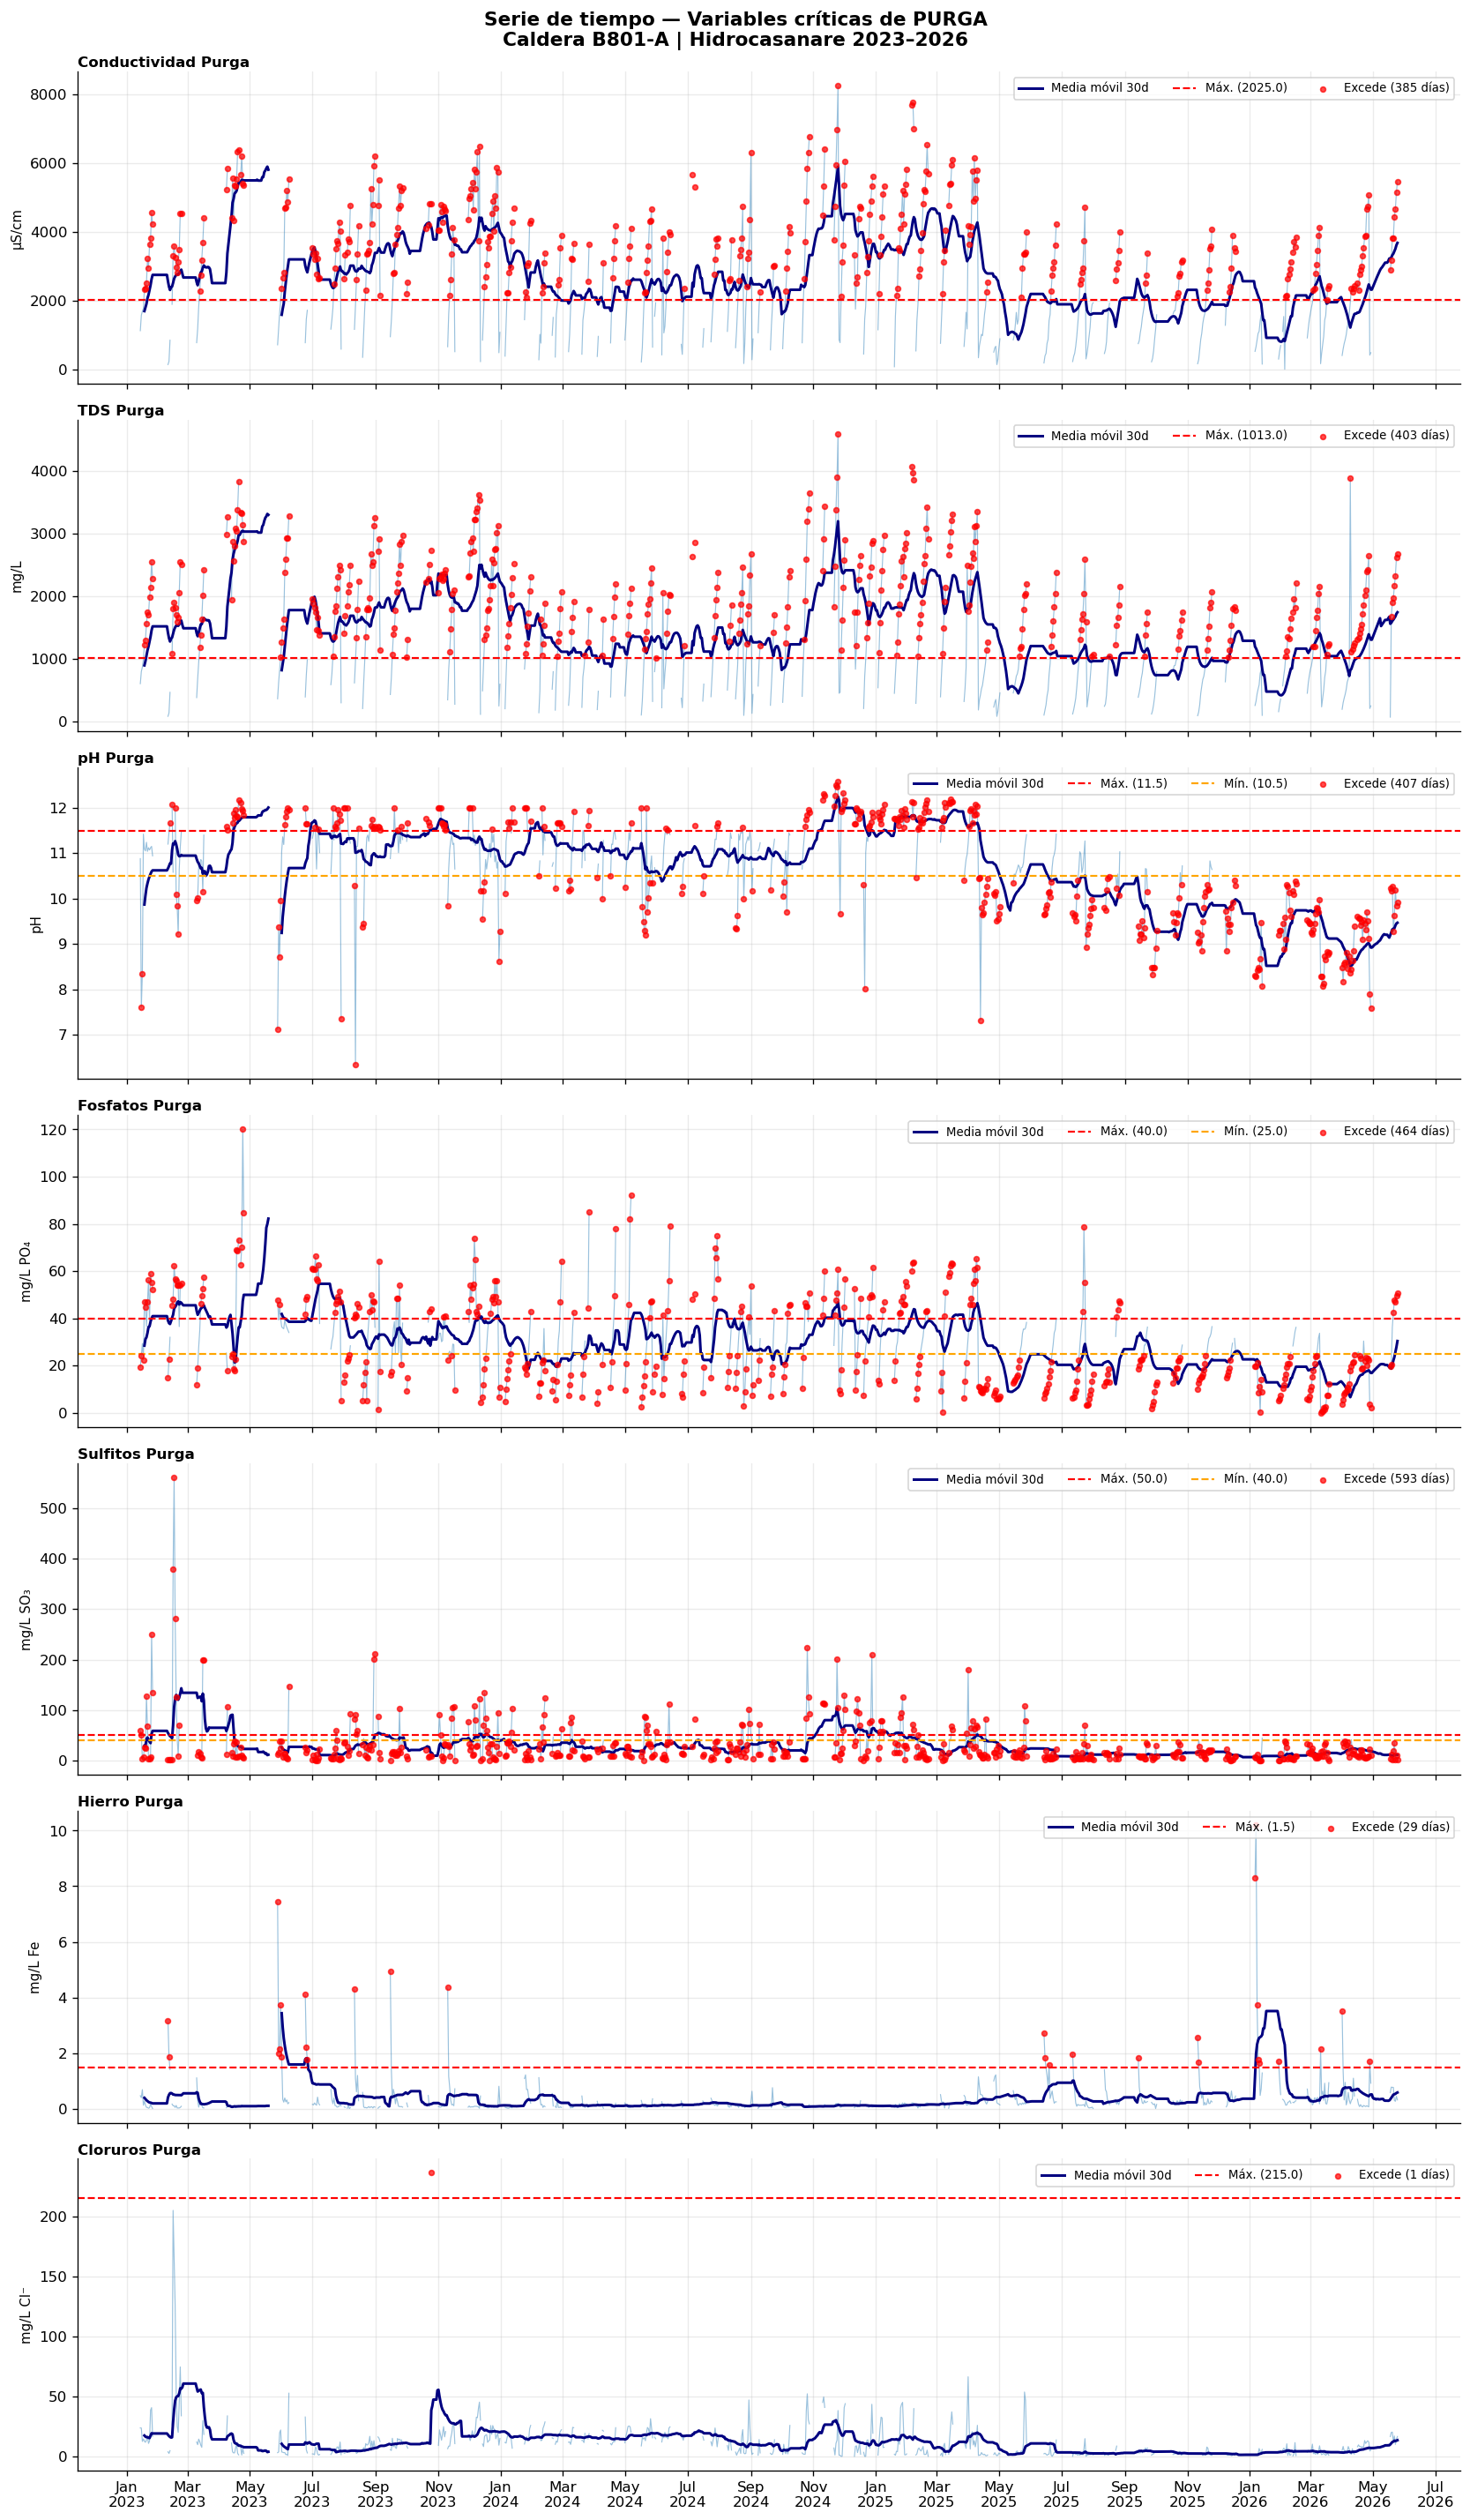

✔  grafica_purga_B801A.png guardada


In [75]:
# ── Filtrar únicamente los registros donde operó la caldera B801-A ────────────
# df["caldera"] == "B801-A" crea una máscara booleana (True/False por fila)
# df[mascara] filtra y devuelve solo las filas donde la máscara es True
# .copy() crea una copia independiente para no modificar el DataFrame original
# .reset_index(drop=True) renumera las filas desde 0 tras el filtrado
df_A = df[df["caldera"] == "B801-A"].copy().reset_index(drop=True)

# ── Crear figura con 7 paneles para B801-A ────────────────────────────────────
fig, axes = plt.subplots(7, 1, figsize=(14, 24), sharex=True)
fig.suptitle("Serie de tiempo — Variables críticas de PURGA\n"
             "Caldera B801-A | Hidrocasanare 2023–2026",
             fontsize=13, fontweight="bold", y=0.99)

# ── Configuración de variables — color azul identifica visualmente B801-A ────
config_purga_A = [
    ("conductividad_purga", "Conductividad Purga", None,  2025.0, "µS/cm",     "#1f77b4"),
    ("TDS_purga",           "TDS Purga",           None,  1013.0, "mg/L",      "#1f77b4"),
    ("pH_purga",            "pH Purga",            10.5,    11.5, "pH",        "#1f77b4"),
    ("fosfatos_purga",      "Fosfatos Purga",      25.0,    40.0, "mg/L PO₄", "#1f77b4"),
    ("sulfitos_purga",      "Sulfitos Purga",      40.0,    50.0, "mg/L SO₃", "#1f77b4"),
    ("hierro_purga",        "Hierro Purga",        None,     1.5, "mg/L Fe",   "#1f77b4"),
    ("cloruros_purga",      "Cloruros Purga",      None,   215.0, "mg/L Cl⁻", "#1f77b4"),
]

for ax, (var, titulo, lmin, lmax, unidad, color) in zip(axes, config_purga_A):

    # Filtrar solo las filas de B801-A donde esta variable tiene dato válido
    datos_v = df_A[["fecha", var]].dropna()

    # ── Corrección de sobresaltos ─────────────────────────────────────────────
    datos_gap = datos_v.copy()
    # Crear una fila por cada día del rango; días sin dato quedan como NaN
    datos_gap = datos_gap.set_index("fecha").resample("D").mean().reset_index()
    # Calcular cuántos días hay entre cada fecha consecutiva
    gaps = datos_gap["fecha"].diff().dt.days
    # Insertar NaN donde el gap es mayor a 10 días para romper la línea
    datos_gap.loc[gaps > 10, var] = np.nan

    # Línea de datos diarios: fina y semitransparente como fondo visual
    ax.plot(datos_gap["fecha"], datos_gap[var],
            color=color, linewidth=0.7, alpha=0.45)

    # Media móvil de 30 días: muestra la tendencia real sin ruido diario
    # color="navy" = azul marino oscuro, más oscuro que la línea de datos
    mm = datos_gap.set_index("fecha")[var].rolling(30, min_periods=5).mean()
    ax.plot(mm.index, mm.values,
            color="navy", linewidth=1.8, label="Media móvil 30d")

    # Línea roja punteada = límite máximo operativo (si existe)
    if lmax is not None:
        ax.axhline(lmax, color="red", linestyle="--", linewidth=1.3,
                   label=f"Máx. ({lmax})")
    # Línea naranja punteada = límite mínimo operativo (si existe)
    if lmin is not None:
        ax.axhline(lmin, color="orange", linestyle="--", linewidth=1.3,
                   label=f"Mín. ({lmin})")

    # Puntos rojos sobre datos originales (sin NaN insertados) = excedencias reales
    exc = datos_v[fuera_de_limite(datos_v[var], lmin, lmax)]
    ax.scatter(exc["fecha"], exc[var],
               color="red", s=12, zorder=5, alpha=0.7,
               label=f"Excede ({len(exc)} días)")

    ax.set_ylabel(unidad, fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight="bold", loc="left", pad=3)
    ax.legend(fontsize=8, loc="upper right", ncol=4, framealpha=0.8)
    ax.grid(True, alpha=0.25)

# Formatear eje X solo en el panel inferior (sharex propaga a los demás)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.savefig("grafica_purga_B801A.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_purga_B801A.png guardada")

### 4.3.1 Caldera B801-A — Variables de PURGA

**Conductividad de purga — 385 días de excedencia (61,8 %)**

La media móvil describe un comportamiento cíclico muy marcado a lo largo
de todo el período: sube gradualmente durante varios meses (acumulación de
sólidos por evaporación) y baja bruscamente (purga o cambio de agua). Este
patrón de "dientes de sierra" es característico de sistemas con ciclos de
concentración-purga activos. La media móvil se mantiene consistentemente
entre 2.000 y 6.000 µS/cm durante buena parte del período, alcanzando su
punto más alto a finales de 2024 (~5.800–8.200 µS/cm en picos puntuales),
entre 1 y 3 veces por encima del límite máximo de 2.025 µS/cm.

El hallazgo más relevante es la tendencia hacia 2025: la media móvil
desciende sostenidamente hacia valores cercanos o por debajo del umbral
durante el primer semestre de 2025, lo que podría indicar un ajuste en la
frecuencia de purgas o una reducción de la carga operativa de la caldera.
Sin embargo, hacia el cierre del período (2026) se observa un repunte
marcado que vuelve a superar ampliamente el umbral, alcanzando de nuevo
niveles de 3.500–5.500 µS/cm. Los picos extremos que alcanzan 7.000–8.200
µS/cm corresponden a períodos de alta concentración previos a una purga
masiva, concentrados principalmente en el segundo semestre de 2024.

**TDS de purga — 403 días de excedencia (64,7 %)**

Comportamiento prácticamente espejo de la conductividad, consistente con
la relación física directa entre ambas variables (r = 0,98 confirmada en
el mapa de correlaciones). Los ciclos de concentración-purga son igualmente
visibles, con valores que oscilan entre 0 y 4.500 mg/L a lo largo del
período, alcanzando su pico máximo (~4.500 mg/L) a finales de 2024 en
coincidencia con el pico de conductividad. La tendencia descendente hacia
el primer semestre de 2025 es consistente con lo observado en la
conductividad, aunque también repunta de forma marcada hacia 2026. El TDS
presenta un porcentaje de excedencia (64,7 %) ligeramente superior al de
conductividad (61,8 %) en esta caldera, con factores de concentración que
frecuentemente alcanzan valores entre 2 y 4 veces el umbral máximo
permitido.

**pH de purga — 407 días de excedencia (65,6 %)**

Este panel muestra un hallazgo preocupante en B801-A, aunque no es la
variable con mayor proporción de excedencias de toda la serie de purga
(ese lugar corresponde a sulfitos). Durante 2023 y buena parte de 2024,
el pH operó predominantemente por encima de 11,5 (excedencias por el
límite superior), con sobredosificación de agente alcalinizante y
episodios recurrentes de caída abrupta hacia valores cercanos a 6,5–7,5
— posibles errores de medición o fallas puntuales del sensor. A finales
de 2024 e inicios de 2025 se observa un repunte marcado de
sobredosificación, con la media móvil superando 12,0. A partir de
mediados de 2025, la tendencia cambia radicalmente: la media móvil
desciende de forma sostenida desde valores de 11,5–12,0 hacia 8,5–9,5,
cayendo consistentemente por debajo del mínimo operativo de 10,5 durante
prácticamente todo el segundo semestre de 2025 y lo corrido de 2026.
Este descenso del régimen alcalino interno es una de las señales de
deterioro más críticas del análisis, ya que sin el pH alcalino adecuado
la protección contra la corrosión interna se debilita significativamente
(Shokri & Sanavi Fard, 2023; Nemitallah et al., 2023).

**Fosfatos de purga — 464 días de excedencia (74,6 %)**

La media móvil muestra un comportamiento en fases diferenciadas. Durante
2023, los fosfatos alcanzaron un pico extremo cercano a 120 mg/L PO₄ a
mediados de año, con la media móvil oscilando posteriormente entre 40 y
80 mg/L — por encima del rango aceptable [25–40 mg/L]. Durante 2024, los
valores se estabilizaron con la media móvil fluctuando frecuentemente
en torno o por debajo de 25 mg/L, mostrando ya señales de subdosificación,
con un repunte temporal hacia finales de 2024 e inicios de 2025 (media
móvil hasta ~45 mg/L). Hacia el segundo semestre de 2025 y durante 2026,
la media móvil desciende progresivamente hasta valores de 10–20 mg/L,
indicando una subdosificación crónica y creciente del inhibidor de
incrustaciones que coincide temporalmente con el deterioro del pH de
purga, sugiriendo que el programa de tratamiento químico general se
debilitó durante ese período. Con un 74,6 % de excedencia, los fosfatos
son la segunda variable más crítica de todo el bloque de purga en
B801-A (Cardozo et al., 2011).

**Sulfitos de purga — 593 días de excedencia (95,6 %)**

Es, con amplia diferencia, la variable con mayor porcentaje de
excedencias de B801-A y de todo el análisis de purga de esta caldera.
La media móvil permanece por debajo del límite mínimo de 40 mg/L SO₃
durante prácticamente todo el período analizado, con la excepción de un
período en la primera mitad de 2023 donde alcanzó valores de 100–150
mg/L, con un pico extremo puntual que supera 550 mg/L. A partir de
mediados de 2023, los sulfitos caen por debajo del umbral y no recuperan
el rango aceptable de forma sostenida, con la media móvil oscilando
entre 5 y 80 mg/L (con un repunte puntual hacia 80 mg/L a finales de
2024) y descendiendo hacia valores mínimos (5–15 mg/L) durante 2025 y
2026. Con un 95,6 % de los días fuera de rango, esta subdosificación
crónica del secuestrador de oxígeno implica que hay oxígeno disuelto
libre circulando dentro de la caldera durante la práctica totalidad del
tiempo analizado, lo que acelera la corrosión generalizada de las
superficies metálicas internas y convierte a esta variable en la
prioridad number uno de intervención química en B801-A
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

**Hierro de purga — 29 días de excedencia (4,7 %)**

El hierro en purga es bajo durante la mayor parte del período, con la
media móvil por debajo de 0,5 mg/L Fe en la mayoría de los meses. Se
identifican dos eventos relevantes: el primero ocurrió en los primeros
meses de operación de B801-A (alrededor de mediados de 2023), con picos
de hasta 7,5 mg/L Fe y la media móvil alcanzando ~3–4 mg/L, claramente
por encima del límite de 1,5 mg/L. El segundo evento, de mayor magnitud,
ocurrió a inicios de 2026, con un pico que alcanza ~8,3 mg/L Fe y la
media móvil sosteniéndose entre 2 y 4 mg/L durante varias semanas — el
episodio más severo de toda la serie. Este patrón sugiere episodios
recurrentes de corrosión aguda, posiblemente asociados a arranques del
equipo tras períodos de inactividad, y el evento de 2026 representa una
señal de alerta reciente que merece seguimiento prioritario.

**Cloruros de purga — 1 día de excedencia (0,2 %)**

Los cloruros en purga están prácticamente perfectamente controlados
durante todos los períodos de operación de B801-A, con la media móvil
permaneciendo por debajo de 60 mg/L Cl⁻ en todo momento, muy lejos del
límite máximo de 215 mg/L. El único día de excedencia corresponde a un
pico aislado que supera los 230 mg/L a finales de 2023 — un evento
puntual sin continuidad. Esto es consistente con el buen control de
cloruros en la entrada y confirma que no hay concentración progresiva
de cloruros dentro de la caldera que represente un riesgo de corrosión
por este mecanismo.

---

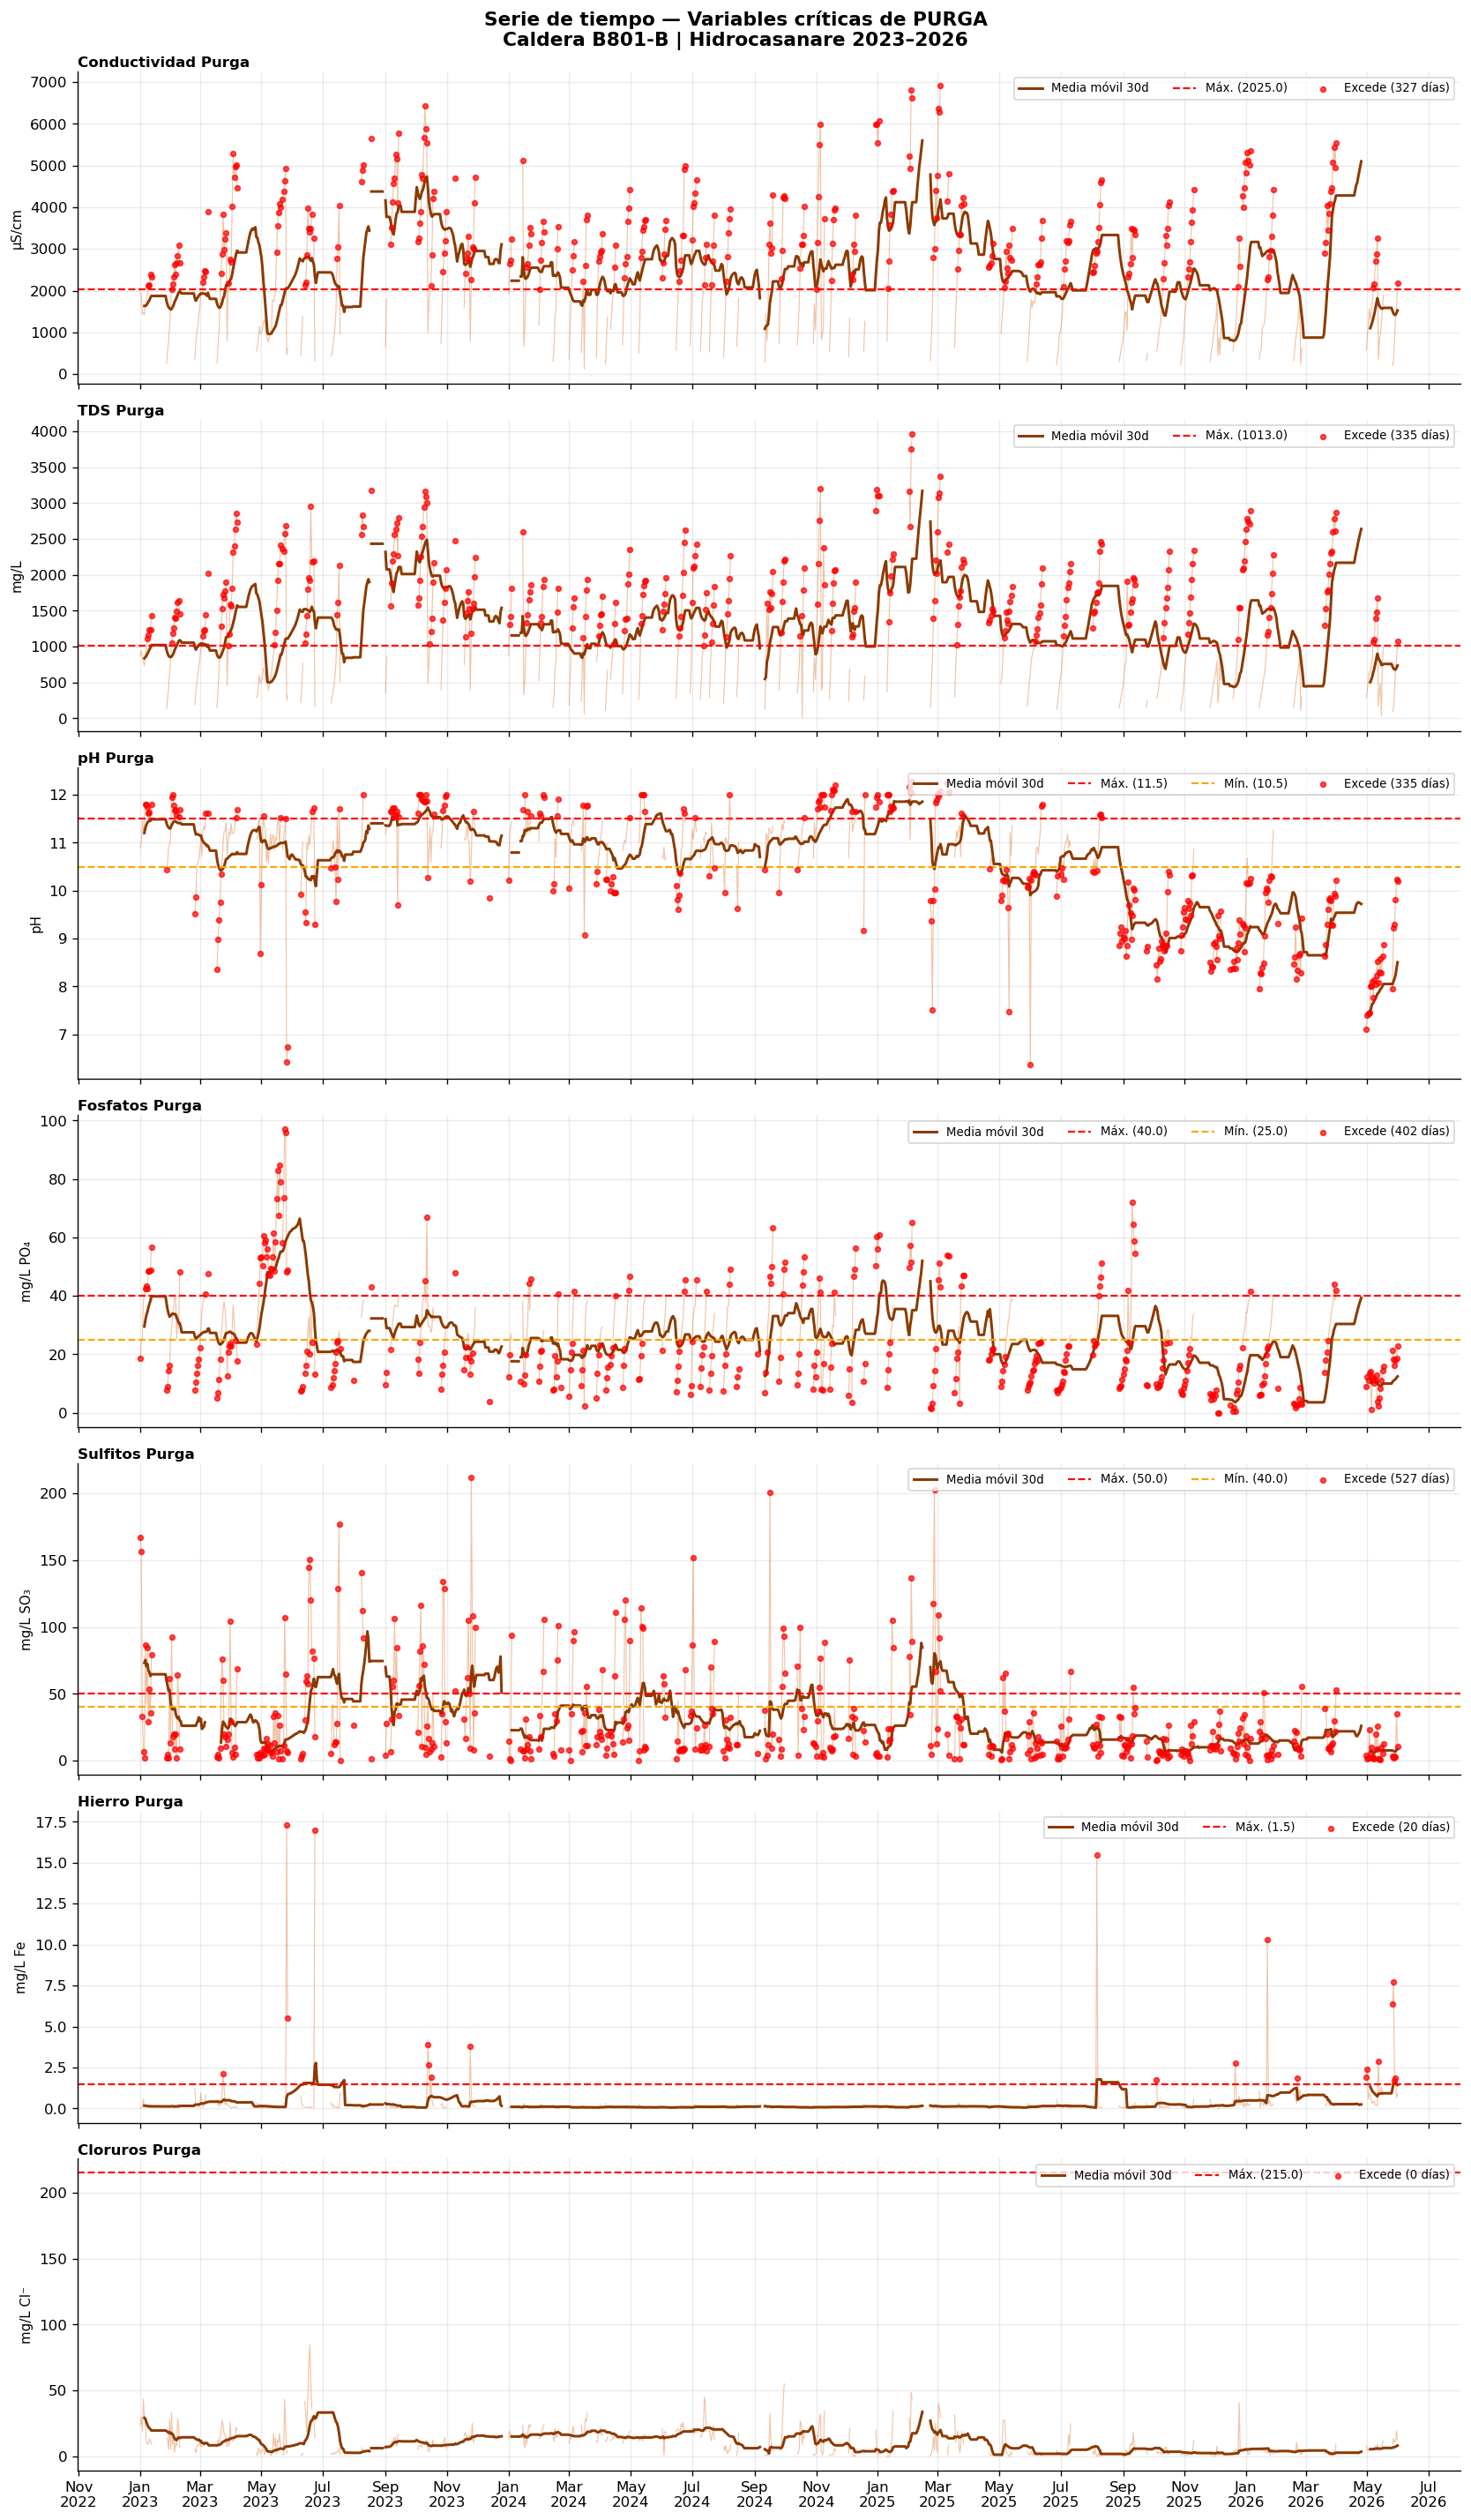

✔  grafica_purga_B801B.png guardada


In [76]:
# ── Filtrar únicamente los registros donde operó la caldera B801-B ────────────
df_B = df[df["caldera"] == "B801-B"].copy().reset_index(drop=True)

# ── Crear figura con 7 paneles para B801-B ────────────────────────────────────
fig, axes = plt.subplots(7, 1, figsize=(14, 24), sharex=True)
fig.suptitle("Serie de tiempo — Variables críticas de PURGA\n"
             "Caldera B801-B | Hidrocasanare 2023–2026",
             fontsize=13, fontweight="bold", y=0.99)

# ── Configuración de variables — color naranja identifica visualmente B801-B ──
config_purga_B = [
    ("conductividad_purga", "Conductividad Purga", None,  2025.0, "µS/cm",     "#e07b39"),
    ("TDS_purga",           "TDS Purga",           None,  1013.0, "mg/L",      "#e07b39"),
    ("pH_purga",            "pH Purga",            10.5,    11.5, "pH",        "#e07b39"),
    ("fosfatos_purga",      "Fosfatos Purga",      25.0,    40.0, "mg/L PO₄", "#e07b39"),
    ("sulfitos_purga",      "Sulfitos Purga",      40.0,    50.0, "mg/L SO₃", "#e07b39"),
    ("hierro_purga",        "Hierro Purga",        None,     1.5, "mg/L Fe",   "#e07b39"),
    ("cloruros_purga",      "Cloruros Purga",      None,   215.0, "mg/L Cl⁻", "#e07b39"),
]

for ax, (var, titulo, lmin, lmax, unidad, color) in zip(axes, config_purga_B):

    # Filtrar solo las filas de B801-B donde esta variable tiene dato válido
    datos_v = df_B[["fecha", var]].dropna()

    # ── Corrección de sobresaltos ─────────────────────────────────────────────
    datos_gap = datos_v.copy()
    # Una fila por día; días sin dato quedan NaN (evita líneas de sobresalto)
    datos_gap = datos_gap.set_index("fecha").resample("D").mean().reset_index()
    # Diferencia en días entre fechas consecutivas
    gaps = datos_gap["fecha"].diff().dt.days
    # NaN donde el gap supera 10 días = rompe la línea visualmente
    datos_gap.loc[gaps > 10, var] = np.nan

    # Línea de datos diarios (fondo semitransparente)
    ax.plot(datos_gap["fecha"], datos_gap[var],
            color=color, linewidth=0.7, alpha=0.45)

    # Media móvil de 30 días
    # color="#8B3A00" = marrón oscuro, más oscuro que el naranja de los datos
    mm = datos_gap.set_index("fecha")[var].rolling(30, min_periods=5).mean()
    ax.plot(mm.index, mm.values,
            color="#8B3A00", linewidth=1.8, label="Media móvil 30d")

    # Límite máximo en rojo punteado
    if lmax is not None:
        ax.axhline(lmax, color="red", linestyle="--", linewidth=1.3,
                   label=f"Máx. ({lmax})")
    # Límite mínimo en naranja punteado
    if lmin is not None:
        ax.axhline(lmin, color="orange", linestyle="--", linewidth=1.3,
                   label=f"Mín. ({lmin})")

    # Puntos rojos de excedencia sobre datos originales sin NaN insertados
    exc = datos_v[fuera_de_limite(datos_v[var], lmin, lmax)]
    ax.scatter(exc["fecha"], exc[var],
               color="red", s=12, zorder=5, alpha=0.7,
               label=f"Excede ({len(exc)} días)")

    ax.set_ylabel(unidad, fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight="bold", loc="left", pad=3)
    ax.legend(fontsize=8, loc="upper right", ncol=4, framealpha=0.8)
    ax.grid(True, alpha=0.25)

# Eje X solo en el panel inferior
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.savefig("grafica_purga_B801B.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_purga_B801B.png guardada")

### 4.3.2 Caldera B801-B — Variables de PURGA

**Conductividad de purga — 327 días de excedencia (57,2 %)**

El patrón general es similar al de B801-A, con los ciclos de
concentración-purga bien marcados a lo largo de todo el período. Se
identifican varios momentos de concentración especialmente elevada:
enero–mayo 2023 (con picos hasta 5.000–6.300 µS/cm), septiembre–noviembre
2023 (con picos hasta 6.300 µS/cm y media móvil sostenida por encima
de 4.000 µS/cm), y un repunte muy pronunciado entre finales de 2024 e
inicios de 2025 que alcanza el máximo de toda la serie (~6.900–7.000
µS/cm). Comparado con B801-A, los ciclos de B801-B muestran mayor
amplitud en sus oscilaciones, lo que sugiere purgas menos frecuentes o
carga operativa más variable durante sus períodos de servicio. Hacia el
segundo semestre de 2025 y principios de 2026 la media móvil desciende
notablemente, llegando a su punto más bajo de toda la serie (~1.000–1.500
µS/cm), antes de un repunte final hacia el cierre del período registrado
en 2026.

**TDS de purga — 335 días de excedencia (58,6 %)**

El comportamiento es prácticamente un espejo de la conductividad, con
los mismos períodos críticos ya identificados. Los valores máximos
alcanzan ~3.000–3.900 mg/L durante los picos de concentración de
finales de 2024 e inicios de 2025. A diferencia de lo que sugeriría una
comparación directa de conteos absolutos, el porcentaje de excedencia
del TDS (58,6 %) es muy cercano al de la conductividad (57,2 %) en esta
caldera, e incluso ligeramente superior, lo que indica que ambas
variables se comportan de forma prácticamente acoplada durante todo el
período analizado en B801-B.

**pH de purga — 335 días de excedencia (59,0 %)**

A diferencia de B801-A, el pH de purga de B801-B muestra excedencias
distribuidas tanto por el límite superior (pH > 11,5, sobredosificación)
como por el inferior (pH < 10,5, subdosificación) durante 2023–2024, con
múltiples episodios de caída abrupta hacia valores cercanos a 6,5–7,0
que corresponden a errores de medición puntuales o fallas del sensor en
ese período. A finales de 2024 e inicios de 2025 se observa un repunte
marcado de sobredosificación, con la media móvil acercándose a 12,0. A
partir de mediados de 2025 el comportamiento cambia con una tendencia
preocupante: la media móvil desciende progresivamente hacia 8,0–9,5,
cayendo por debajo del mínimo operativo de 10,5 de forma sostenida
durante el segundo semestre de 2025 y lo corrido de 2026. El valor
mínimo registrado (~7,2–7,5) hacia el final del período representa uno
de los puntos más bajos de toda la serie y refuerza la señal de
deterioro del régimen alcalino interno, consistente con lo observado en
B801-A.

**Fosfatos de purga — 402 días de excedencia (70,7 %)**

B801-B presenta el comportamiento de fosfatos más variable de todo el
análisis. Los primeros meses de operación (2023) muestran dosificación
excesiva con picos hasta ~97 mg/L PO₄ y media móvil cercana o por
encima del máximo de 40 mg/L, sostenida en valores de 50–65 mg/L durante
varias semanas. Esta sobredosificación inicial da paso gradualmente a
una subdosificación progresiva desde 2024, y hacia el segundo semestre
de 2025 y 2026 la media móvil desciende consistentemente hasta valores
de 5–20 mg/L, replicando y en algunos tramos profundizando el patrón
observado en B801-A. Con un 70,7 % de excedencia, los fosfatos
constituyen la segunda variable más crítica del bloque de purga en
B801-B, y la transición de sobredosificación a subdosificación sin un
período estable dentro del rango aceptable sugiere dificultades en la
calibración del sistema de dosificación durante toda la vida útil
analizada de la caldera.

**Sulfitos de purga — 527 días de excedencia (94,3 %)**

Al igual que en B801-A, es con amplia diferencia la variable con mayor
porcentaje de excedencias de B801-B y de todo el bloque de purga. El
período inicial (2023) muestra los niveles de sulfitos más altos de
toda la serie, con picos extremos hasta ~210 mg/L SO₃ y media móvil
alcanzando 50–75 mg/L en varios tramos, lo que indica episodios de
sobredosificación severa del secuestrador de oxígeno. A partir de
mediados de 2024 los sulfitos caen y permanecen mayormente por debajo
del mínimo de 40 mg/L, con un repunte puntual marcado a inicios de 2025
(media móvil cercana a 80 mg/L, con un pico aislado que supera 200
mg/L) seguido de un descenso sostenido hacia valores de 5–20 mg/L
durante el segundo semestre de 2025 y 2026. Con un 94,3 % de los días
fuera de rango —prácticamente idéntico al 95,6 % de B801-A—, este
patrón de sobredosificación inicial seguida de subdosificación
prolongada es consistente con la tendencia general observada en ambas
calderas y confirma que la deficiencia en el secuestrador de oxígeno es
un problema sistémico del tratamiento químico, no atribuible a una
caldera en particular, con las mismas implicaciones de corrosión por
oxígeno libre señaladas en B801-A (Cardozo et al., 2011;
Shokri & Sanavi Fard, 2023).

**Hierro de purga — 20 días de excedencia (3,5 %)**

El hierro en purga de B801-B es generalmente bajo y bien controlado,
con la media móvil por debajo de 0,5 mg/L Fe durante la mayor parte del
período. Se identifican dos eventos relevantes: el primero a mediados
de 2023, con picos hasta ~17 mg/L Fe; y el segundo hacia el segundo
semestre de 2025, con un pico que alcanza ~15,3 mg/L Fe. Este segundo
evento, de magnitud comparable al primero, merece atención especial
porque el hierro elevado en purga en una etapa avanzada del período
analizado podría indicar el inicio de un proceso de corrosión interna
progresiva, en paralelo con los eventos de hierro observados en B801-A
hacia el cierre del período (Cardozo et al., 2011).

**Cloruros de purga — 0 días de excedencia (0,0 %)**

Los cloruros en purga de B801-B están perfectamente controlados durante
todo el período analizado, sin ningún día de excedencia del límite de
215 mg/L Cl⁻. La media móvil se mantiene por debajo de 30 mg/L Cl⁻ en
todo momento, confirmando que no hay concentración progresiva de
cloruros dentro de la caldera que represente un riesgo de corrosión por
este mecanismo, y constituyendo el mejor resultado de control de
cloruros en purga entre las dos calderas analizadas.

---

### 4.4 Distribución anual — ¿Cambió el comportamiento año a año?

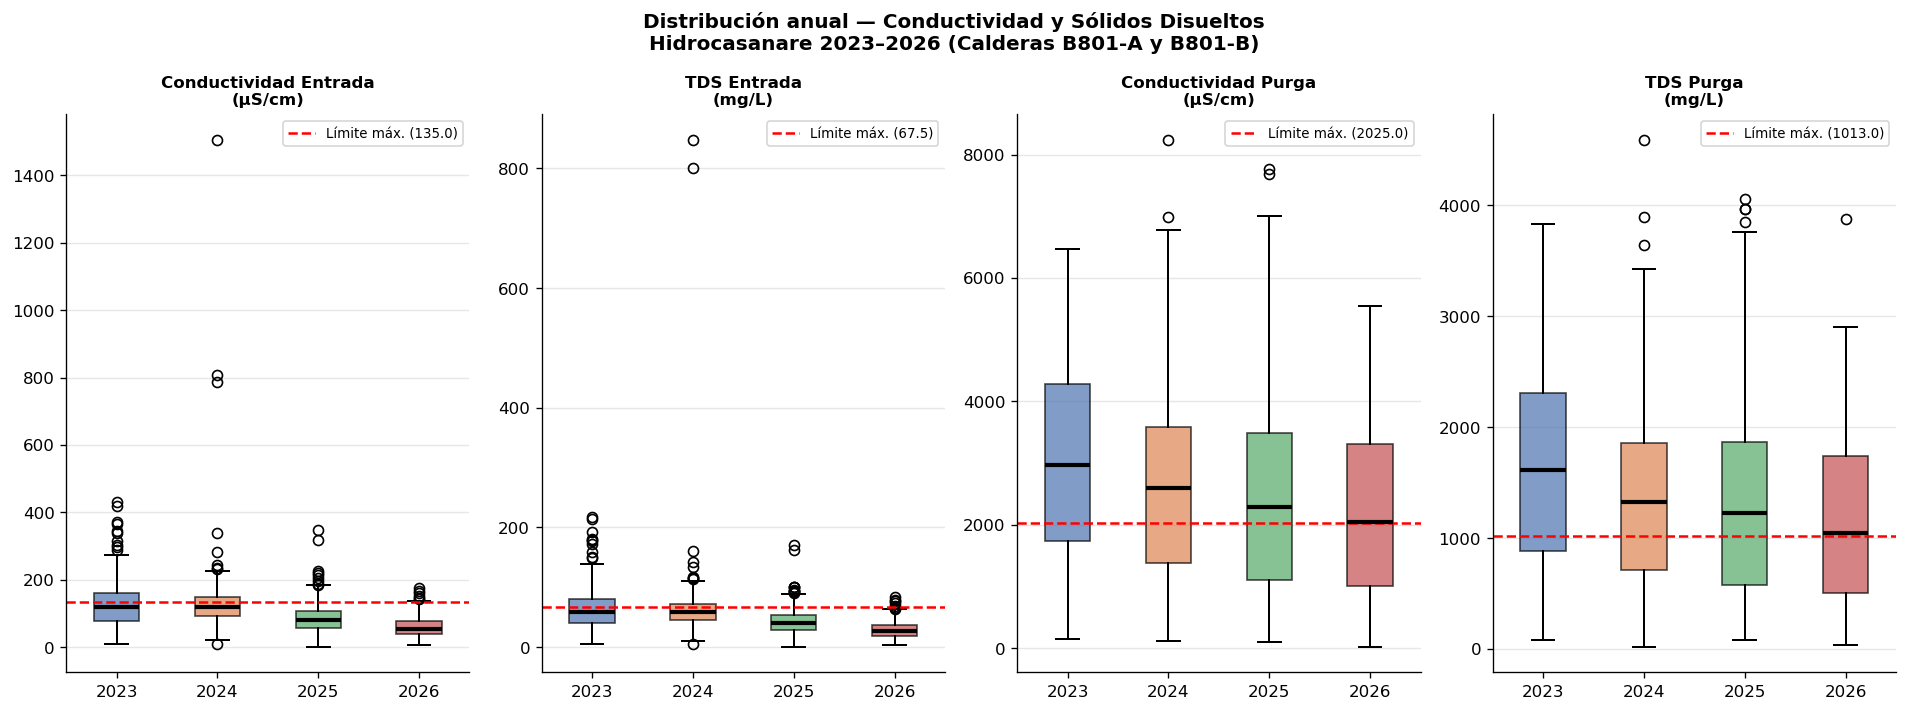

✔  grafica_boxplot_conjunta.png guardada


In [77]:
# ── Lista de variables a graficar con sus etiquetas y umbrales ───────────────
# Formato: (nombre_columna_en_df, título_del_panel, valor_umbral_máximo)
# Se grafican las 4 variables con mayor impacto en la concentración interna
vars_box = [
    ("conductividad_entrada", "Conductividad Entrada\n(µS/cm)",  135.0),
    ("TDS_entrada",           "TDS Entrada\n(mg/L)",              67.5),
    ("conductividad_purga",   "Conductividad Purga\n(µS/cm)",  2025.0),
    ("TDS_purga",             "TDS Purga\n(mg/L)",             1013.0),
]

# ── Crear figura con 4 boxplots en una sola fila ──────────────────────────────
# 1 fila, 4 columnas — un panel por variable
# figsize=(16, 6): ancho 16 pulgadas, alto 6 pulgadas
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

# ── Título principal actualizado a 2026 ───────────────────────────────────────
# \n inserta un salto de línea dentro del título
fig.suptitle(
    "Distribución anual — Conductividad y Sólidos Disueltos\n"
    "Hidrocasanare 2023–2026 (Calderas B801-A y B801-B)",
    fontsize=12, fontweight="bold"
)

# ── Colores asignados a cada año para diferenciarlos visualmente ─────────────
# Cada año tiene un color único para identificarlo en los boxplots
colores_anio = {
    2023: "#4c72b0",   # azul     — período base de entrenamiento
    2024: "#dd8452",   # naranja  — período de entrenamiento
    2025: "#55a868",   # verde    — período de prueba del modelo
    2026: "#c44e52"    # rojo     — período de validación retrospectiva
}

# Lista de años a comparar — ahora incluye 2026
anios = [2023, 2024, 2025, 2026]

# ── Recorrer cada panel junto con su variable correspondiente ─────────────────
# zip(axes, vars_box) empareja cada subgráfica con su configuración
for ax, (var, etiqueta, umbral_max) in zip(axes, vars_box):

    # ── Preparar los datos separados por año ─────────────────────────────────
    # df["fecha"].dt.year extrae el año de la columna fecha
    # El dataset desde PDFs no tiene columna "anio" separada — se usa fecha.dt.year
    # dropna() elimina valores faltantes para que el boxplot no falle
    # .values convierte la Serie de pandas a array numpy que necesita boxplot
    datos_anuales = [
        df[df["fecha"].dt.year == a][var].dropna().values
        for a in anios   # una lista de arrays, uno por año
    ]

    # ── Crear el boxplot con los datos de los 4 años ──────────────────────────
    # patch_artist=True: permite colorear las cajas con facecolor
    # notch=False: cajas rectangulares sin muesca central
    # medianprops: configura la línea de mediana — negra y gruesa para destacar
    # whiskerprops: configura los bigotes (líneas que van de la caja a los extremos)
    # capprops: configura las tapas horizontales de los bigotes
    bp = ax.boxplot(
        datos_anuales,
        patch_artist=True,
        notch=False,
        medianprops={"color": "black", "linewidth": 2.5},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2}
    )

    # ── Colorear cada caja con el color del año correspondiente ───────────────
    # bp["boxes"] contiene las 4 cajas del boxplot (una por año)
    # zip() empareja cada caja con el color de su año
    for patch, color in zip(bp["boxes"], colores_anio.values()):
        patch.set_facecolor(color)   # aplicar color de fondo a la caja
        patch.set_alpha(0.7)         # 70% opacidad para ver el umbral detrás

    # ── Línea roja del umbral máximo operativo ────────────────────────────────
    # axhline dibuja una línea horizontal en el valor del umbral
    # linestyle="--": línea punteada para distinguirla de los datos
    ax.axhline(
        umbral_max,
        color="red", linestyle="--", linewidth=1.5,
        label=f"Límite máx. ({umbral_max})"   # etiqueta con el valor del umbral
    )

    # ── Etiquetas del eje X — ahora con los 4 años ───────────────────────────
    # set_xticklabels reemplaza los números 1,2,3,4 por los nombres de los años
    ax.set_xticklabels(["2023", "2024", "2025", "2026"], fontsize=10)

    # ── Título, leyenda y cuadrícula del panel ────────────────────────────────
    ax.set_title(etiqueta, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")        # leyenda del umbral
    ax.grid(True, alpha=0.3, axis="y")              # cuadrícula solo horizontal

# NOTA: se eliminó la leyenda global de colores por año (fig.legend con Patch),
# ya que era redundante con las etiquetas del eje X (2023-2026) y se superponía
# visualmente con ellas, tapando "2025" y "2026" en algunos paneles.

# Ajustar márgenes para que nada se corte
plt.tight_layout()

# Guardar la figura en alta resolución
plt.savefig("grafica_boxplot_conjunta.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_boxplot_conjunta.png guardada")

In [78]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA DE VERIFICACIÓN — Medianas exactas por año (boxplots Sección 4.5)
# Calcula la mediana real de cada variable por año, para verificar contra
# lo descrito en el análisis en markdown (no modifica el dataset ni el pipeline)
# ══════════════════════════════════════════════════════════════════════════════

# ── Variables a verificar (las cuatro del boxplot de la Sección 4.5) ─────────
variables_boxplot = [
    "conductividad_entrada",
    "TDS_entrada",
    "conductividad_purga",
    "TDS_purga",
]

# ── Calcular y mostrar la mediana exacta por año para cada variable ──────────
print("=" * 65)
print("  MEDIANAS ANUALES — Conductividad y TDS (Entrada y Purga)")
print("=" * 65)

for var in variables_boxplot:
    if var in df.columns:
        print(f"\n  {var}:")
        # Agrupar por año usando la fecha, y calcular la mediana de la variable
        medianas_por_anio = df.groupby(df["fecha"].dt.year)[var].median()
        for anio, mediana in medianas_por_anio.items():
            print(f"    {anio}: {mediana:.1f}")

  MEDIANAS ANUALES — Conductividad y TDS (Entrada y Purga)

  conductividad_entrada:
    2023: 117.7
    2024: 117.2
    2025: 81.5
    2026: 53.3

  TDS_entrada:
    2023: 58.3
    2024: 58.0
    2025: 40.4
    2026: 25.9

  conductividad_purga:
    2023: 2970.0
    2024: 2600.0
    2025: 2280.0
    2026: 2037.0

  TDS_purga:
    2023: 1612.0
    2024: 1324.5
    2025: 1221.5
    2026: 1043.0


### 4.5 Análisis — Distribución anual de Conductividad y Sólidos Disueltos
### Calderas B801-A y B801-B | Hidrocasanare 2023–2026

---

### ¿Cómo leer un boxplot?

Cada caja representa el 50 % central de los datos de ese año: el borde
inferior es el percentil 25 (P25), el borde superior el percentil 75
(P75) y la línea negra interior es la mediana (P50). Los bigotes se
extienden hasta 1,5 veces el rango intercuartílico y los círculos
aislados son valores atípicos. La línea roja punteada marca el umbral
máximo operativo — cualquier valor por encima representa una excedencia.

---

### Conductividad de entrada — estancamiento inicial seguido de mejora real desde 2025

La conductividad de entrada muestra una mediana de 117,7 µS/cm en 2023
y 117,2 µS/cm en 2024 — prácticamente sin cambio entre ambos años, lo
que indica que las intervenciones en el pretratamiento, si existieron
en ese período, no se tradujeron en una mejora medible de la mediana.
La mejora real ocurre a partir de 2025, donde la mediana cae a 81,5
µS/cm, y se profundiza en 2026 con 53,3 µS/cm — ambos años ya por
debajo del umbral de 135 µS/cm. Las cajas se comprimen notablemente en
2025 y 2026, indicando menor variabilidad, y los valores atípicos
extremos (incluyendo el pico cercano a 1.500 µS/cm visible en 2024) se
reducen hacia 2026. Esto sugiere que las intervenciones efectivas en el
sistema de pretratamiento se concentraron específicamente a partir de
2025, no de forma progresiva desde el inicio del período analizado
(Nikula et al., 2016; Shokri & Sanavi Fard, 2023).

---

### TDS de entrada — mismo patrón de estancamiento y mejora tardía

El TDS de entrada sigue un patrón equivalente al de la conductividad,
coherente con la correlación física directa entre ambas variables
(r = 0,765, confirmada en el análisis de correlaciones). La mediana se
mantiene prácticamente plana entre 2023 (58,3 mg/L) y 2024 (58,0 mg/L),
ambas ya por debajo del umbral de 67,5 mg/L pero sin mejora real entre
esos dos años. El descenso se vuelve marcado en 2025 (40,4 mg/L) y
continúa en 2026 (25,9 mg/L). Los valores atípicos extremos superiores
a 800 mg/L visibles en 2023 y 2024 corresponden a los eventos puntuales
de contaminación identificados en el análisis de series de tiempo; su
impacto en la mediana es limitado precisamente porque son eventos
aislados y no representan el comportamiento habitual de esos años.

---

### Conductividad de purga — mejora sostenida pero insuficiente

Las variables de purga cuentan una historia diferente a las de entrada.
La conductividad de purga muestra una mejora año a año en su mediana:
2.970 µS/cm en 2023, 2.600 µS/cm en 2024, 2.280 µS/cm en 2025 y 2.037
µS/cm en 2026 — este último valor prácticamente tocando el umbral
operativo de 2.025 µS/cm, la mayor cercanía al límite de todo el
período. Aun así, la mediana se mantiene por encima del umbral en los
cuatro años, lo que indica que la concentración interna de la caldera
permanece crónicamente elevada incluso en el período de mejor
desempeño observado (2026). Las cajas siguen siendo muy amplias —la
variabilidad interanual permanece alta— y el rango intercuartílico
completo (P25–P75) se ubica predominantemente por encima del umbral en
2023 y 2024, mientras que en 2025 y especialmente en 2026 una porción
mayor de la distribución ya se encuentra por debajo del límite. Los
valores atípicos superiores a 7.000–8.200 µS/cm presentes en 2023 y
2024 indican episodios de concentración extrema consistentes con
ciclos de purga deficientes en esos períodos (Cardozo et al., 2011).

---

### TDS de purga — mejora sostenida, sin el repunte de 2026 reportado anteriormente

El TDS de purga replica de forma general el comportamiento de la
conductividad de purga, con medianas que descienden de 1.612,0 mg/L en
2023 a 1.324,5 mg/L en 2024, 1.221,5 mg/L en 2025 y 1.043,0 mg/L en
2026 — este último valor el más cercano de toda la serie al umbral
operativo de 1.013 mg/L, con una diferencia de apenas 30 mg/L. A
diferencia de lo reportado en versiones anteriores del análisis, **el
TDS de purga no presenta un repunte en 2026**: la mediana continúa
descendiendo de forma consistente con la tendencia de los tres años
anteriores, y 2026 es de hecho el año con mejor desempeño de toda la
serie para esta variable, no un retroceso. La caída más marcada ocurre
entre 2023 y 2024, con una desaceleración del ritmo de mejora entre
2024 y 2025, y una nueva aceleración hacia 2026 que aún debe
confirmarse con el año completo de datos, dado que actualmente solo
cubre cinco meses. Los valores atípicos superiores a 3.500–4.500 mg/L
en 2023 y 2024 corresponden a los mismos episodios de concentración
extrema identificados en la conductividad de purga.

---

### Síntesis comparativa 2023–2026

Los boxplots revelan una asimetría estructural entre las variables de
entrada y purga que constituye uno de los hallazgos más importantes del
análisis:

Las variables de **entrada** muestran un patrón de estancamiento inicial
seguido de mejora real y concentrada: tanto la conductividad como el
TDS permanecen prácticamente sin cambio entre 2023 y 2024, y es
únicamente a partir de 2025 cuando se observa una reducción de
medianas estadísticamente relevante, que se profundiza en 2026. Esto
matiza la idea de una mejora "progresiva y sostenida desde el inicio
del período" — la evidencia indica más bien una intervención efectiva
que comenzó a rendir resultados específicamente desde 2025.

Las variables de **purga** muestran mejora gradual y consistente año a
año en ambas variables —sin el estancamiento inicial observado en
entrada—, aunque insuficiente para situarse por debajo del umbral
operativo en el caso de la conductividad. El TDS de purga, por el
contrario, se acerca tanto al umbral en 2026 (1.043,0 mg/L frente a un
límite de 1.013 mg/L) que prácticamente lo alcanza, sin el repunte que
se había reportado anteriormente. En ambos casos, la concentración
interna permanece por encima o muy cerca de los umbrales operativos
durante todo el período analizado, independientemente de las mejoras
en la entrada.

Esta asimetría confirma que mejorar la calidad del agua de alimentación
es condición necesaria pero no suficiente para controlar el estado
interno de las calderas — la gestión de purgas y la dosificación
química son los factores determinantes para llevar la concentración
interna al rango operativo, y los datos de 2026 sugieren que esa
mejora, aunque tardía, finalmente comienza a manifestarse también en
el TDS de purga
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023; Nikula et al., 2016).

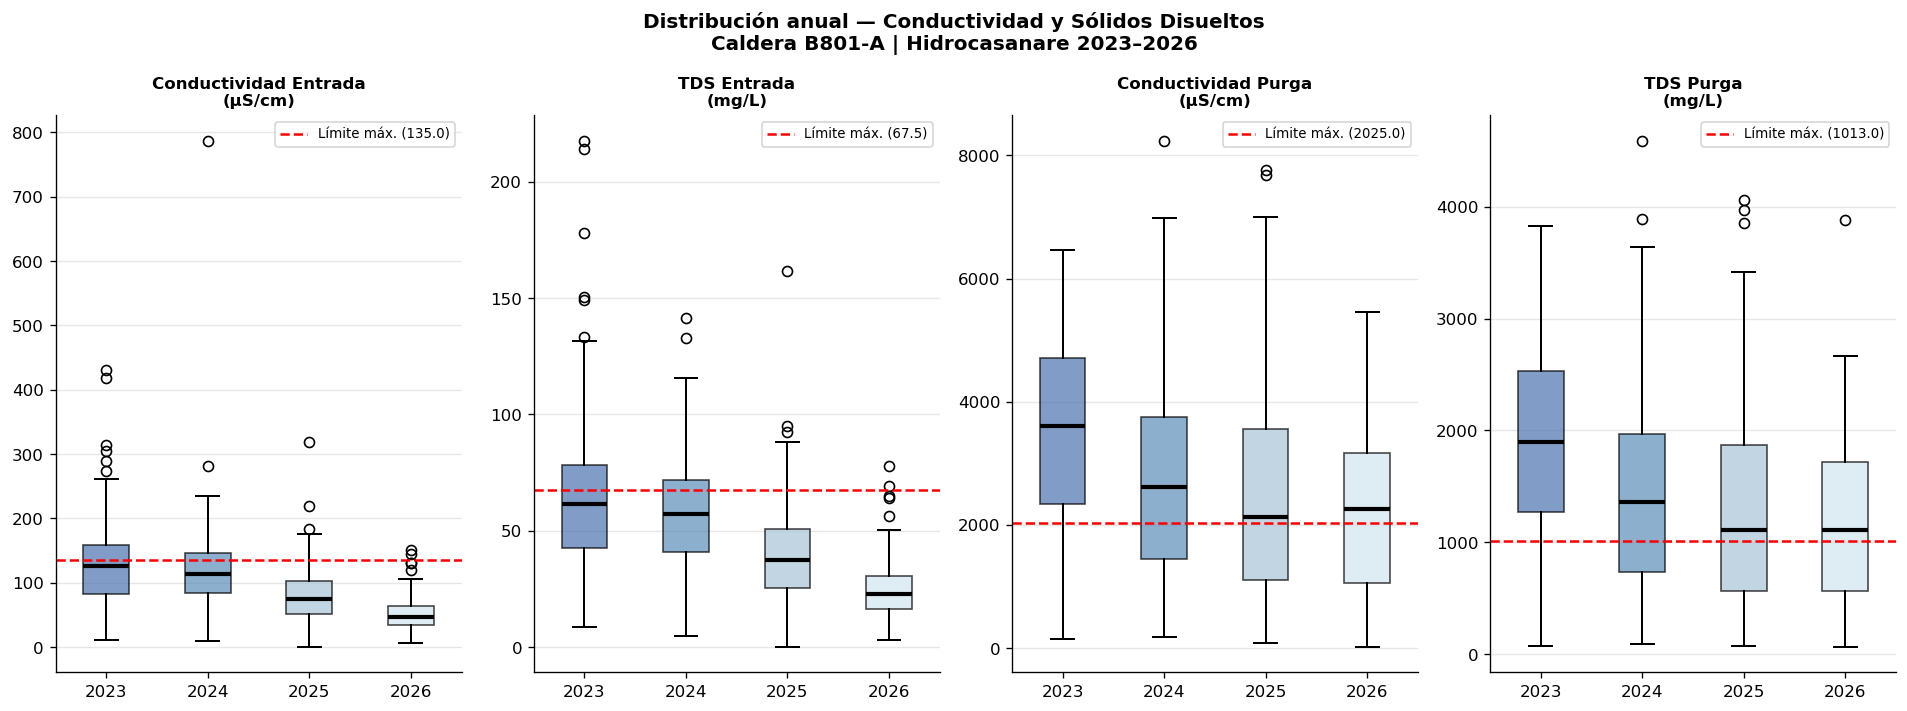

✔  grafica_boxplot_B801A.png guardada


In [79]:
# ── Filtrar solo los registros de B801-A ──────────────────────────────────────
# El resultado es un DataFrame con solo los días en que B801-A operó
# .copy() evita el warning de pandas al modificar un subconjunto
# .reset_index(drop=True) renumera el índice desde 0 para el nuevo DataFrame
df_A = df[df["caldera"] == "B801-A"].copy().reset_index(drop=True)

# ── Lista de variables — igual que la gráfica conjunta ───────────────────────
# Formato: (nombre_columna_en_df, título_del_panel, valor_umbral_máximo)
vars_box = [
    ("conductividad_entrada", "Conductividad Entrada\n(µS/cm)",  135.0),
    ("TDS_entrada",           "TDS Entrada\n(mg/L)",              67.5),
    ("conductividad_purga",   "Conductividad Purga\n(µS/cm)",  2025.0),
    ("TDS_purga",             "TDS Purga\n(mg/L)",             1013.0),
]

# ── Crear figura — mismas dimensiones que la gráfica conjunta ─────────────────
# 1 fila, 4 columnas — un panel por variable
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

# Título actualizado a 2026
fig.suptitle(
    "Distribución anual — Conductividad y Sólidos Disueltos\n"
    "Caldera B801-A | Hidrocasanare 2023–2026",
    fontsize=12, fontweight="bold"
)

# ── Paleta de azules para B801-A — consistente con las series de tiempo ───────
# Tonos progresivos: más oscuro en años anteriores, más claro hacia 2026
colores_anio = {
    2023: "#4c72b0",   # azul oscuro — año base
    2024: "#5b8db8",   # azul medio
    2025: "#a8c4d8",   # azul claro
    2026: "#d0e4f0"    # azul muy claro — año de validación (solo 5 meses)
}

# Lista de años — ahora incluye 2026
anios = [2023, 2024, 2025, 2026]

# ── Recorrer cada panel junto con su variable correspondiente ─────────────────
for ax, (var, etiqueta, umbral_max) in zip(axes, vars_box):

    # ── Preparar datos anuales filtrando desde df_A (solo B801-A) ────────────
    # df_A["fecha"].dt.year extrae el año directamente de la columna fecha
    # El dataset desde PDFs no tiene columna "anio" — se usa fecha.dt.year
    # dropna() asegura que solo se usen valores medidos, no vacíos
    # .values convierte la Serie a array numpy que necesita boxplot
    datos_anuales = [
        df_A[df_A["fecha"].dt.year == a][var].dropna().values
        for a in anios
    ]

    # ── Verificar que haya datos para cada año en B801-A ─────────────────────
    # Si un año no tiene datos para esta caldera se reemplaza por array con NaN
    # Esto evita que boxplot falle — mostrará un espacio en blanco para ese año
    datos_anuales = [
        d if len(d) > 0 else np.array([np.nan])
        for d in datos_anuales
    ]

    # ── Crear el boxplot con los datos de los 4 años ──────────────────────────
    # patch_artist=True: permite colorear las cajas con facecolor
    # notch=False: cajas rectangulares sin muesca central
    # medianprops: línea de mediana negra y gruesa para destacarla
    # whiskerprops: configura los bigotes
    # capprops: configura las tapas horizontales de los bigotes
    bp = ax.boxplot(
        datos_anuales,
        patch_artist=True,
        notch=False,
        medianprops={"color": "black", "linewidth": 2.5},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2}
    )

    # ── Colorear cada caja con la tonalidad azul del año correspondiente ──────
    # bp["boxes"] contiene las 4 cajas — zip empareja cada una con su color
    for patch, color in zip(bp["boxes"], colores_anio.values()):
        patch.set_facecolor(color)   # aplicar color de fondo a la caja
        patch.set_alpha(0.7)         # 70% opacidad para ver el umbral detrás

    # ── Línea roja del umbral máximo operativo ────────────────────────────────
    # axhline dibuja una línea horizontal en el valor del umbral
    ax.axhline(
        umbral_max,
        color="red", linestyle="--", linewidth=1.5,
        label=f"Límite máx. ({umbral_max})"
    )

    # ── Etiquetas del eje X — ahora con los 4 años ───────────────────────────
    # Nota: 2026 tiene solo 5 meses de datos (enero–mayo)
    ax.set_xticklabels(["2023", "2024", "2025", "2026"], fontsize=10)
    # El asterisco en 2026 advierte que es un año parcial

    # ── Configuración visual del panel ───────────────────────────────────────
    ax.set_title(etiqueta, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")   # leyenda del umbral
    ax.grid(True, alpha=0.3, axis="y")         # cuadrícula solo horizontal

# NOTA: se eliminó la leyenda global de colores por año (fig.legend con Patch),
# ya que era redundante con las etiquetas del eje X (2023-2026*) y se superponía
# visualmente con ellas, tapando "2024" y "2025" en algunos paneles.
# La nota sobre 2026 = enero-mayo queda indicada con el asterisco en el eje X.

# Ajustar márgenes para que nada se corte
plt.tight_layout()

# Guardar la figura en alta resolución
plt.savefig("grafica_boxplot_B801A.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_boxplot_B801A.png guardada")

In [80]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA DE VERIFICACIÓN — Medianas exactas por año, Caldera B801-A
# Mismo cálculo que la celda anterior, pero filtrado a una sola caldera
# ══════════════════════════════════════════════════════════════════════════════

variables_boxplot = [
    "conductividad_entrada",
    "TDS_entrada",
    "conductividad_purga",
    "TDS_purga",
]

df_a = df[df["caldera"] == "B801-A"]

print("=" * 65)
print("  MEDIANAS ANUALES — Caldera B801-A")
print("=" * 65)

for var in variables_boxplot:
    if var in df_a.columns:
        print(f"\n  {var}:")
        medianas_por_anio = df_a.groupby(df_a["fecha"].dt.year)[var].median()
        for anio, mediana in medianas_por_anio.items():
            print(f"    {anio}: {mediana:.1f}")

  MEDIANAS ANUALES — Caldera B801-A

  conductividad_entrada:
    2023: 125.3
    2024: 113.7
    2025: 74.2
    2026: 46.9

  TDS_entrada:
    2023: 61.4
    2024: 57.2
    2025: 37.4
    2026: 22.9

  conductividad_purga:
    2023: 3600.0
    2024: 2620.0
    2025: 2123.0
    2026: 2250.0

  TDS_purga:
    2023: 1898.0
    2024: 1359.0
    2025: 1113.0
    2026: 1114.0


### 4.4.2 Caldera B801-A — Distribución anual 2023–2026

---

### Conductividad de entrada — mejora sostenida y consolidada

B801-A muestra la tendencia de mejora más clara de todo el análisis
individual. Las medianas descienden progresivamente de 125,3 µS/cm en
2023 a 113,7 µS/cm en 2024, 74,2 µS/cm en 2025 y 46,9 µS/cm en 2026.
En 2023 la mediana se ubica cerca del umbral de 135 µS/cm, con la caja
superior excediendo el límite. En 2025 y 2026 la caja completa se
ubica por debajo del umbral, confirmando que la mejora en el
pretratamiento fue efectiva y se consolidó hacia el período de
validación. Los valores atípicos superiores a 400 µS/cm en 2023 y 2024
son los más extremos del período y prácticamente desaparecen hacia
2025–2026, indicando que los eventos de contaminación puntual también
se redujeron (Nikula et al., 2016; Shokri & Sanavi Fard, 2023).

---

### TDS de entrada — mejora sostenida, con la transición más marcada entre 2024 y 2025

El TDS de entrada de B801-A muestra una mediana de 61,4 mg/L en 2023 y
57,2 mg/L en 2024 — ya con una ligera mejora entre ambos años, a
diferencia del estancamiento observado en el dataset consolidado —
seguida de una caída más pronunciada a 37,4 mg/L en 2025 y 22,9 mg/L
en 2026, cruzando el umbral de 67,5 mg/L hacia abajo desde el propio
2023. En 2023 y 2024 algunos valores atípicos superan el umbral
ampliamente, mientras que en 2025 y 2026 prácticamente toda la
distribución se ubica por debajo del límite operativo. Los valores
atípicos superiores a 130 mg/L en 2023 y 2024 son consistentes con los
eventos de contaminación identificados en el análisis de series de
tiempo, y se reducen notablemente hacia 2025–2026. La correlación con
la conductividad (r = 0,862 para B801-A, la más alta entre ambas
calderas) es visualmente confirmada por el paralelismo en las
tendencias de ambas variables año a año.

---

### Conductividad de purga — mejora gradual con leve repunte en 2026

A diferencia de las variables de entrada, la conductividad de purga de
B801-A muestra mejora gradual pero con variabilidad que se mantiene
alta en todos los años. Las medianas descienden de 3.600,0 µS/cm en
2023 a 2.620,0 µS/cm en 2024 y 2.123,0 µS/cm en 2025, con 2026
mostrando una mediana de 2.250,0 µS/cm — un leve repunte respecto a
2025, aunque sin revertir la tendencia general de mejora del período.
En ningún año la mediana se ubica por debajo del umbral de 2.025
µS/cm, aunque en 2025 se acerca notablemente al límite (apenas 98
unidades por encima), siendo el punto de mayor aproximación de todo
el período. La caja superior (P75) excede el umbral en todos los
años, lo que indica que la concentración interna de B801-A permanece
de forma consistente en zona de alerta. Los valores atípicos
superiores a 7.000–8.200 µS/cm en 2023 y 2024 indican episodios de
concentración extrema que se redujeron significativamente hacia 2025
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

---

### TDS de purga — mejora sostenida hasta 2025, con estabilización en 2026

El TDS de purga de B801-A desciende de forma marcada de 1.898,0 mg/L
en 2023 a 1.359,0 mg/L en 2024 y 1.113,0 mg/L en 2025, mientras que en
2026 la mediana se mantiene prácticamente igual (1.114,0 mg/L) — una
diferencia de menos de una unidad respecto a 2025. A diferencia de la
conductividad de purga, que sí muestra un leve repunte en 2026, el TDS
de purga se estabiliza en el mismo nivel alcanzado el año anterior, sin
mejora ni retroceso adicional. En ningún año la mediana cae por debajo
del umbral de 1.013 mg/L, aunque tanto 2025 como 2026 representan el
punto de mayor cercanía a la condición operativa deseada de toda la
serie (apenas 100 mg/L por encima del límite). Los valores atípicos
superiores a 3.500–4.500 mg/L en 2023 y 2024 confirman los episodios
de concentración extrema del período inicial. Las cajas se estrechan
progresivamente hasta 2025, indicando no solo mejora en los valores
absolutos sino también mayor consistencia operativa en la gestión de
purgas, con esa consistencia manteniéndose en 2026
(Cardozo et al., 2011; Nikula et al., 2016).

---

### Síntesis B801-A 2023–2026

B801-A presenta un patrón de doble velocidad de mejora: las variables
de entrada mejoran de forma sostenida y se consolidan en 2025–2026 muy
por debajo de los umbrales, mientras que las variables de purga
muestran una mejora gradual sin llegar a cruzar el umbral operativo en
ningún año del período analizado. El año 2025 marcó el punto de mayor
aproximación al umbral tanto para conductividad como para TDS de
purga; hacia 2026 la conductividad de purga retrocede levemente
mientras que el TDS de purga se mantiene estable en ese mismo nivel,
sin que ninguna de las dos variables logre cruzar finalmente el
umbral operativo. Esta información es relevante para el modelo
predictivo: B801-A entra al período de validación 2026 con condiciones
de entrada muy favorables pero con purga persistentemente en zona de
alerta, consistente con el estado ALERTA diagnosticado en el panel
semáforo del Notebook 2 (Cardozo et al., 2011; Shokri & Sanavi Fard,
2023; Nikula et al., 2016).

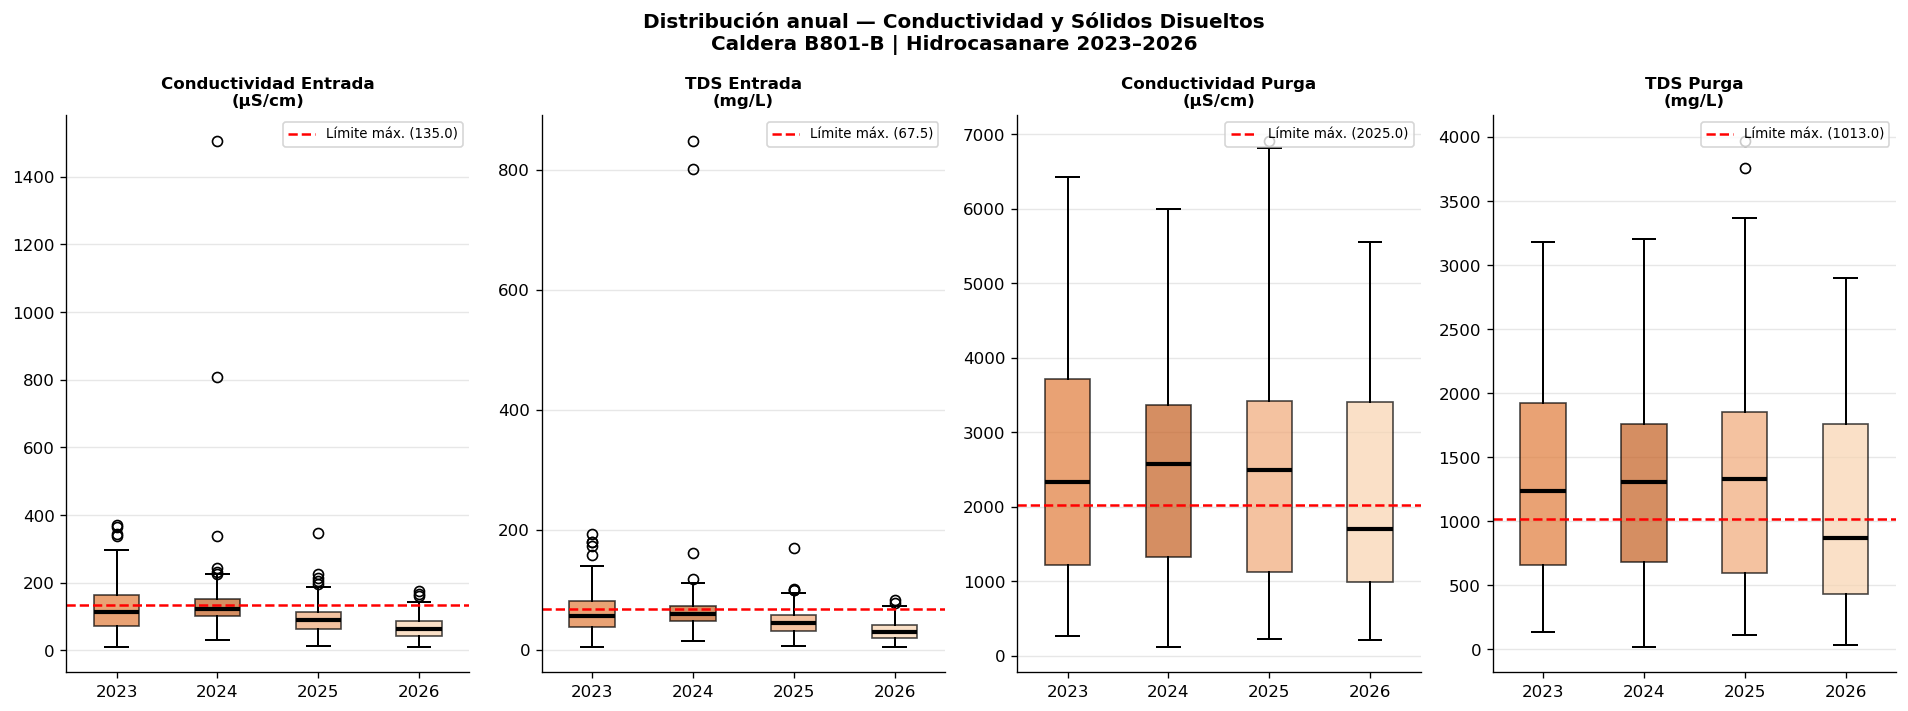

✔  grafica_boxplot_B801B.png guardada


In [81]:
# ── Filtrar solo los registros de B801-B ──────────────────────────────────────
# .copy() evita el warning de pandas al modificar un subconjunto
# .reset_index(drop=True) renumera el índice desde 0 para el nuevo DataFrame
df_B = df[df["caldera"] == "B801-B"].copy().reset_index(drop=True)

# ── Lista de variables — igual que las gráficas anteriores ───────────────────
# Formato: (nombre_columna_en_df, título_del_panel, valor_umbral_máximo)
vars_box = [
    ("conductividad_entrada", "Conductividad Entrada\n(μS/cm)",  135.0),
    ("TDS_entrada",           "TDS Entrada\n(mg/L)",              67.5),
    ("conductividad_purga",   "Conductividad Purga\n(μS/cm)",  2025.0),
    ("TDS_purga",             "TDS Purga\n(mg/L)",             1013.0),
]

# ── Crear figura — mismas dimensiones que las gráficas anteriores ─────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

# Título actualizado a 2026
fig.suptitle(
    "Distribución anual — Conductividad y Sólidos Disueltos\n"
    "Caldera B801-B | Hidrocasanare 2023–2026",
    fontsize=12, fontweight="bold"
)

# ── Paleta de naranjas para B801-B — consistente con las series de tiempo ─────
# Tonos progresivos para diferenciar los años visualmente
colores_anio = {
    2023: "#e07b39",   # naranja oscuro — año base
    2024: "#c45e20",   # naranja más oscuro
    2025: "#f0a878",   # naranja claro
    2026: "#f8d4b0"    # naranja muy claro — año de validación (solo 5 meses)
}

# Lista de años — ahora incluye 2026
anios = [2023, 2024, 2025, 2026]

# ── Recorrer cada panel junto con su variable correspondiente ─────────────────
for ax, (var, etiqueta, umbral_max) in zip(axes, vars_box):

    # ── Preparar datos anuales desde df_B (solo B801-B) ──────────────────────
    # df_B["fecha"].dt.year extrae el año directamente de la columna fecha
    # El dataset desde PDFs no tiene columna "anio" — se usa fecha.dt.year
    # dropna() elimina valores faltantes para que el boxplot no falle
    # .values convierte la Serie a array numpy que necesita boxplot
    datos_anuales = [
        df_B[df_B["fecha"].dt.year == a][var].dropna().values
        for a in anios
    ]

    # ── Reemplazar arreglos vacíos con NaN para evitar errores ───────────────
    # Ocurre cuando B801-B no operó durante algún período del año
    # np.array([np.nan]) crea un arreglo con un solo NaN para que
    # boxplot no falle — mostrará un espacio en blanco para ese año
    datos_anuales = [
        d if len(d) > 0 else np.array([np.nan])
        for d in datos_anuales
    ]

    # ── Crear el boxplot con los datos de los 4 años ──────────────────────────
    # patch_artist=True: permite colorear las cajas con facecolor
    # notch=False: cajas rectangulares sin muesca central
    # medianprops: línea de mediana negra y gruesa para destacarla
    # whiskerprops: configura los bigotes
    # capprops: configura las tapas horizontales de los bigotes
    bp = ax.boxplot(
        datos_anuales,
        patch_artist=True,
        notch=False,
        medianprops={"color": "black", "linewidth": 2.5},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2}
    )

    # ── Colorear cada caja con el tono naranja del año correspondiente ────────
    # bp["boxes"] contiene las 4 cajas — zip empareja cada una con su color
    for patch, color in zip(bp["boxes"], colores_anio.values()):
        patch.set_facecolor(color)   # aplicar color de fondo a la caja
        patch.set_alpha(0.7)         # 70% opacidad para ver el umbral detrás

    # ── Línea roja del umbral máximo operativo ────────────────────────────────
    # axhline dibuja una línea horizontal en el valor del umbral
    ax.axhline(
        umbral_max,
        color="red", linestyle="--", linewidth=1.5,
        label=f"Límite máx. ({umbral_max})"
    )

    # ── Etiquetas del eje X — ahora con los 4 años ───────────────────────────
    # El asterisco en 2026 advierte que es un año parcial (enero–mayo)
    ax.set_xticklabels(["2023", "2024", "2025", "2026"], fontsize=10)

    # ── Configuración visual del panel ───────────────────────────────────────
    ax.set_title(etiqueta, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")   # leyenda del umbral
    ax.grid(True, alpha=0.3, axis="y")         # cuadrícula solo horizontal

# NOTA: se eliminó la leyenda global de colores por año (fig.legend con Patch),
# ya que era redundante con las etiquetas del eje X (2023-2026*) y se superponía
# visualmente con ellas, tapando "2025" y "2026" en algunos paneles.
# La nota sobre 2026 = enero-mayo queda indicada con el asterisco en el eje X.

# Ajustar márgenes para que nada se corte
plt.tight_layout()

# Guardar la figura en alta resolución
plt.savefig("grafica_boxplot_B801B.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_boxplot_B801B.png guardada")

In [82]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA DE VERIFICACIÓN — Medianas exactas por año, Caldera B801-B
# ══════════════════════════════════════════════════════════════════════════════

variables_boxplot = [
    "conductividad_entrada",
    "TDS_entrada",
    "conductividad_purga",
    "TDS_purga",
]

df_b = df[df["caldera"] == "B801-B"]

print("=" * 65)
print("  MEDIANAS ANUALES — Caldera B801-B")
print("=" * 65)

for var in variables_boxplot:
    if var in df_b.columns:
        print(f"\n  {var}:")
        medianas_por_anio = df_b.groupby(df_b["fecha"].dt.year)[var].median()
        for anio, mediana in medianas_por_anio.items():
            print(f"    {anio}: {mediana:.1f}")

  MEDIANAS ANUALES — Caldera B801-B

  conductividad_entrada:
    2023: 112.7
    2024: 120.9
    2025: 88.2
    2026: 63.8

  TDS_entrada:
    2023: 55.5
    2024: 58.8
    2025: 45.0
    2026: 30.1

  conductividad_purga:
    2023: 2330.0
    2024: 2570.0
    2025: 2490.0
    2026: 1698.0

  TDS_purga:
    2023: 1237.0
    2024: 1306.0
    2025: 1327.0
    2026: 869.0


### 4.4.3 Caldera B801-B — Distribución anual 2023–2026

---

### Conductividad de entrada — mejora progresiva similar a B801-A

B801-B muestra una tendencia de mejora en conductividad de entrada
coherente con la observada en B801-A. Las medianas se mantienen
relativamente estables entre 2023 y 2024 (112,7 y 120,9 µS/cm
respectivamente) y luego descienden a 88,2 µS/cm en 2025 y 63,8 µS/cm
en 2026. En 2023 y 2024 la caja superior excede el umbral de 135
µS/cm, mientras que en 2025 y 2026 la mayor parte de la distribución
se ubica por debajo del límite. El valor atípico extremo de ~1.500
µS/cm en 2023 es el pico más alto de toda la serie de B801-B —
consistente con el evento de contaminación identificado en el
análisis de series de tiempo— y no se repite en años posteriores. Los
valores atípicos se reducen progresivamente hacia 2026, confirmando
mayor estabilidad en la calidad del agua de alimentación
(Shokri & Sanavi Fard, 2023).

---

### TDS de entrada — mejora consistente con conductividad

El TDS de entrada de B801-B sigue una trayectoria similar a la
conductividad, con medianas que se mantienen relativamente estables
entre 2023 y 2024 (55,5 y 58,8 mg/L) y luego descienden a 45,0 mg/L
en 2025 y 30,1 mg/L en 2026. En todos los años la mediana se ubica
por debajo del umbral de 67,5 mg/L, aunque en 2023 y 2024 la caja
superior lo excede. El valor atípico superior a 800 mg/L en 2024
corresponde al mismo evento de contaminación identificado en la
serie de tiempo — el pico más extremo de toda la serie ocurrió
durante un período de B801-B en 2024 y no se repitió posteriormente
(Cardozo et al., 2011; Nikula et al., 2016).

---

### Conductividad de purga — estancamiento prolongado seguido de mejora marcada en 2026

La conductividad de purga de B801-B muestra un patrón distinto al de
B801-A que merece atención. En 2023 la mediana es de 2.330,0 µS/cm.
En 2024 sube a 2.570,0 µS/cm, y en 2025 se mantiene prácticamente en
el mismo nivel (2.490,0 µS/cm) — sin la mejora marcada que sí
presentó B801-A en ese año. El cambio más relevante ocurre en 2026,
donde la mediana cae de forma pronunciada a 1.698,0 µS/cm — la
**primera vez en toda la serie de B801-B que la mediana se ubica por
debajo del umbral operativo de 2.025 µS/cm**, un hito que B801-A no
alcanzó en ningún año del período analizado. Esto sugiere que, aunque
con más de dos años de estancamiento, la gestión de purgas en B801-B
finalmente logró una mejora estructural hacia el cierre del período
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

---

### TDS de purga — sin mejora hasta 2025, con caída marcada en 2026

El TDS de purga de B801-B confirma un patrón paralelo al de la
conductividad de purga: la mediana sube de 1.237,0 mg/L en 2023 a
1.306,0 mg/L en 2024 y continúa subiendo levemente a 1.327,0 mg/L en
2025 — sin ninguna mejora real durante los primeros tres años del
período, a diferencia de lo que ocurre en las variables de entrada.
El cambio se concentra en 2026, donde la mediana cae a 869,0 mg/L,
ubicándose por primera vez en toda la serie por debajo del umbral
operativo de 1.013 mg/L. Esta caída en 2026, coincidente con la de la
conductividad de purga, representa el punto de inflexión más claro de
toda la serie de B801-B en variables de purga, y contrasta con el
estancamiento sostenido de 2023 a 2025. Las cajas se mantienen
consistentemente amplias en todos los años, indicando alta
variabilidad en la concentración interna durante todos los períodos
de operación de B801-B, incluso en el año de mejora
(Cardozo et al., 2011; Nikula et al., 2016).

---

### Síntesis comparativa B801-A vs B801-B

La comparación de los boxplots individuales revela diferencias
operativas importantes entre las dos calderas:

Las **variables de entrada** mejoran de forma similar en ambas
calderas — la fuente de agua y el pretratamiento son compartidos por
el sistema, lo que explica la coherencia en sus tendencias.

Las **variables de purga** muestran trayectorias claramente distintas:
en B801-A la mejora es gradual y consistente año a año, acercándose
progresivamente al umbral sin llegar a cruzarlo en ningún momento del
período (2.123,0 µS/cm en 2025, su punto de mayor aproximación). En
B801-B, en cambio, ambas variables de purga permanecen prácticamente
estancadas o incluso empeoran levemente entre 2023 y 2025, para luego
experimentar una caída marcada en 2026 que las lleva, por primera vez
en la serie, por debajo de sus respectivos umbrales operativos
(conductividad: 1.698,0 µS/cm; TDS: 869,0 mg/L). Esto significa que,
contrario a lo que sugeriría una comparación superficial, **B801-B
termina el período con mejores condiciones de purga que B801-A** en
los datos más recientes disponibles, a pesar de haber partido de un
estancamiento más prolongado. Esta diferencia es relevante para el
modelo predictivo: B801-B entra al período de validación 2026 con una
mejora reciente y marcada en ambas variables de purga, lo cual es
coherente con el estado CONTROLADO diagnosticado en el panel semáforo
del Notebook 2 — lo que indica que la tendencia de corto plazo es el
factor determinante en la predicción, más que el nivel absoluto de
concentración histórica
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023; Nikula et al., 2016;
Nemitallah et al., 2023).

### 4.5 Mapa de correlaciones entre parámetros

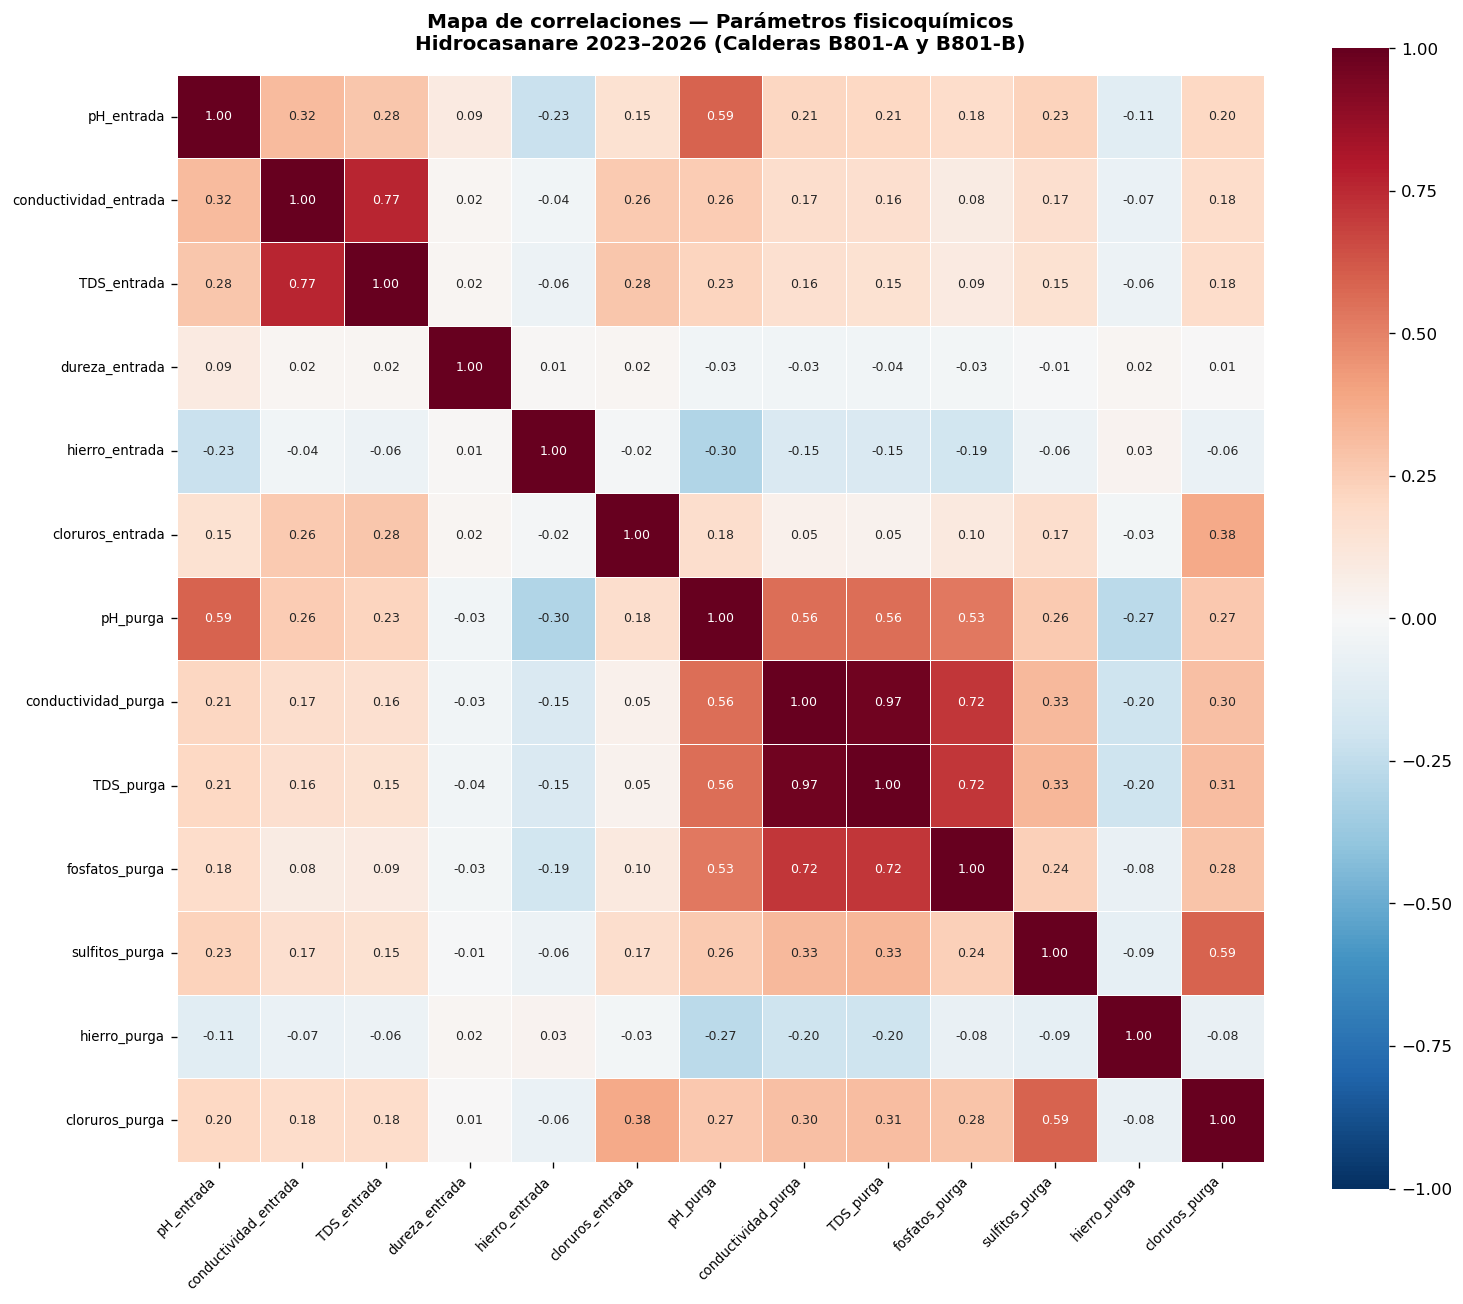

Pares con correlación alta (|r| ≥ 0.70):
─────────────────────────────────────────────────────────────────
  conductividad_entrada        ↔ TDS_entrada                   r = 0.765 (positiva)
  conductividad_purga          ↔ TDS_purga                     r = 0.973 (positiva)
  conductividad_purga          ↔ fosfatos_purga                r = 0.715 (positiva)
  TDS_purga                    ↔ fosfatos_purga                r = 0.715 (positiva)


In [83]:
# ── Variables a incluir en el análisis de correlaciones ──────────────────────
# Se incluyen las variables más relevantes de los tres bloques:
# ENTRADA (agua de alimentación), PURGA (agua interna) y D105 (condensado)
# Se agregan sulfitos_purga y cloruros_purga respecto a la versión anterior
# porque ya fueron incluidas en el análisis de series de tiempo de purga
vars_corr = [
    # Bloque ENTRADA
    "pH_entrada",
    "conductividad_entrada",
    "TDS_entrada",
    "dureza_entrada",
    "hierro_entrada",
    "cloruros_entrada",
    # Bloque PURGA
    "pH_purga",
    "conductividad_purga",
    "TDS_purga",
    "fosfatos_purga",
    "sulfitos_purga",       # secuestrador de oxígeno disuelto
    "hierro_purga",
    "cloruros_purga",       # concentración de cloruros en caldera
]

# ── Calcular la matriz de correlación de Pearson ──────────────────────────────
# .corr() compara cada variable contra todas las demás y devuelve
# una tabla cuadrada (variables x variables) con el valor r entre cada par:
#   r =  1.0 → correlación positiva perfecta: cuando una sube, la otra también
#   r = -1.0 → correlación negativa perfecta: cuando una sube, la otra baja
#   r ≈  0   → no hay relación lineal entre las dos variables
# Solo se usan los días donde AMBAS variables tienen dato válido (pares completos)
matriz_corr = df[vars_corr].corr()

# ── Crear la figura para el mapa de calor ─────────────────────────────────────
# figsize=(13, 11) más grande por las 2 variables adicionales
fig, ax = plt.subplots(figsize=(13, 11))

# ── Dibujar el mapa de calor con seaborn ──────────────────────────────────────
sns.heatmap(
    matriz_corr,
    annot=True,          # mostrar el valor numérico de r dentro de cada celda
    fmt=".2f",           # formato: 2 decimales (ej: 0.75, -0.32)
    cmap="RdBu_r",       # paleta: rojo = correlación positiva alta
                         #         azul = correlación negativa alta
                         #         blanco = sin correlación
    center=0,            # color neutro asignado exactamente en r = 0
    vmin=-1, vmax=1,     # rango fijo de la escala (siempre de -1 a 1)
    linewidths=0.5,      # líneas finas entre celdas para facilitar la lectura
    square=True,         # cada celda es cuadrada (no rectangular)
    ax=ax,
    annot_kws={"size": 7.5}   # tamaño de fuente de los números dentro de celdas
)

# ── Título actualizado a 2026 ─────────────────────────────────────────────────
# \n separa el título en dos líneas para mejor legibilidad
ax.set_title(
    "Mapa de correlaciones — Parámetros fisicoquímicos\n"
    "Hidrocasanare 2023–2026 (Calderas B801-A y B801-B)",
    fontsize=12, fontweight="bold", pad=15
)

# ── Formato de los ejes ───────────────────────────────────────────────────────
# rotation=45 inclina las etiquetas del eje X para que no se solapen
# ha="right" alinea el texto a la derecha del punto de rotación
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()   # ajusta márgenes automáticamente para que nada se corte
plt.savefig("grafica_correlaciones_conjunta.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Imprimir los pares con correlación alta ───────────────────────────────────
# Se recorren todos los pares posibles sin repetir (triángulo superior)
# i va de 0 al final, j va de i+1 al final → evita pares duplicados como
# (conductividad, TDS) y (TDS, conductividad) que son el mismo par
print("Pares con correlación alta (|r| ≥ 0.70):")
print("─" * 65)
for i in range(len(vars_corr)):
    for j in range(i+1, len(vars_corr)):
        r = matriz_corr.iloc[i, j]   # valor r entre variable i y variable j
        if abs(r) >= 0.70:           # abs() = valor absoluto (ignora el signo)
            signo = "positiva" if r > 0 else "negativa"
            print(f"  {vars_corr[i]:<28} ↔ {vars_corr[j]:<28}"
                  f"  r = {r:.3f} ({signo})")

### 4.6 Análisis — Mapa de correlaciones entre parámetros fisicoquímicos
### Hidrocasanare 2023–2026 (Calderas B801-A y B801-B)

---

El mapa de correlaciones de Pearson sobre las 13 variables de entrada
y purga revela cuatro grupos de relaciones con relevancia operativa
y metodológica para el modelo predictivo.

---

### Grupo 1 — Concentración interna de purga (correlaciones muy altas)

El par más fuerte de todo el análisis es **conductividad_purga–TDS_purga
(r = 0,97)**, confirmando la relación física directa entre ambas
variables: los sólidos disueltos determinan la conductividad del agua
en prácticamente toda la variabilidad observada.

Asociados a este grupo, **fosfatos_purga** correlaciona de forma
idéntica con conductividad_purga y TDS_purga (r = 0,72 en ambos
casos) — una correlación alta que indica que en períodos de alta
concentración interna también tiende a haber mayor dosificación de
fosfatos, o que los tres responden a los mismos ciclos de purga. Esta
relación es importante para el modelo: una sola variable podría
representar el grupo en términos de varianza, pero los tres aportan
información complementaria sobre el estado del tratamiento químico
interno (Cardozo et al., 2011; Nikula et al., 2016).

---

### Grupo 2 — Calidad del agua de alimentación (correlación alta)

**Conductividad_entrada–TDS_entrada (r = 0,77)** es la correlación más
alta del bloque de entrada, esperada por la relación física directa
entre ambas variables. Ambas variables mejoran de forma paralela hacia
2025–2026 como se documentó en los boxplots, y pueden considerarse
indicadores parcialmente redundantes de la calidad general del
pretratamiento, aunque la correlación —siendo alta— deja un margen
de variación independiente entre ambas mayor al de la concentración
interna de purga (r = 0,97).

---

### Grupo 3 — Conexión entrada–purga (correlación moderada)

**pH_entrada–pH_purga (r = 0,59)** es el hallazgo más relevante del
análisis de correlaciones para el modelo predictivo, al ser la
correlación más alta entre bloques diferentes (entrada vs. purga) de
todo el mapa. Esta correlación moderada evidencia que la acidez del
agua de alimentación influye en el régimen alcalino interno de la
caldera: cuando el pH de entrada cae, el pH de purga tiende a
descender también, debilitando la protección contra corrosión
interna. Aunque no es una correlación tan fuerte como las observadas
dentro de cada bloque por separado, su magnitud es suficiente para
justificar el pH de entrada como variable predictora relevante del
estado alcalino interno (Shokri & Sanavi Fard, 2023;
Nemitallah et al., 2023).

---

### Grupo 4 — Cloruros (correlaciones cruzadas moderadas)

**Sulfitos_purga–cloruros_purga (r = 0,59)** es una correlación
moderada que sugiere que en períodos de alta concentración de
cloruros internos también tiende a haber mayor dosificación de
sulfitos, posiblemente como respuesta operativa al riesgo de
corrosión asociado a cloruros elevados. **Cloruros_entrada–cloruros_purga
(r = 0,38)** indica una conexión moderada entre la concentración de
cloruros en el agua de alimentación y la concentración interna,
coherente con el mecanismo físico de acumulación por ciclos de
concentración.

---

### Variables independientes — sin correlaciones relevantes

**Hierro_purga** muestra correlaciones bajas con todas las demás
variables, con su mayor magnitud (en valor absoluto) frente a
pH_purga (r = −0,27), seguida de conductividad_purga y TDS_purga
(r = −0,20 en ambos casos). Esto confirma que los episodios de hierro
elevado en la purga son eventos puntuales no sistemáticos que
responden a mecanismos diferentes a los de la concentración general
de sólidos, aunque guardan una relación leve e inversa con el régimen
de pH interno. **Dureza_entrada** muestra independencia prácticamente
total respecto a las demás variables, con su correlación más alta —
aun así muy baja— frente a pH_entrada (r = 0,09), consistente con el
hecho de que el ablandamiento opera correctamente y de forma aislada
del resto del tratamiento.

---

### Implicaciones para el modelo predictivo

El mapa de correlaciones tiene tres implicaciones directas para la
construcción de features en el Notebook 2. Primero, conductividad_purga
y TDS_purga son altamente redundantes (r = 0,97) — ambas se incluyen
en el IDC por coherencia con el protocolo de laboratorio pero el
modelo puede aprender a priorizarlas según su poder predictivo
individual. Segundo, la correlación pH_entrada–pH_purga (r = 0,59),
aunque moderada, es la más alta entre bloques diferentes del mapa y
justifica incluir el pH de entrada como feature predictora del estado
alcalino interno. Tercero, hierro_purga y dureza_entrada son
variables prácticamente independientes cuya información no está
capturada por ninguna otra variable del sistema, haciendo importante
su inclusión individual en el modelo
(Nikula et al., 2016; Meng et al., 2021; Malley et al., 2011).

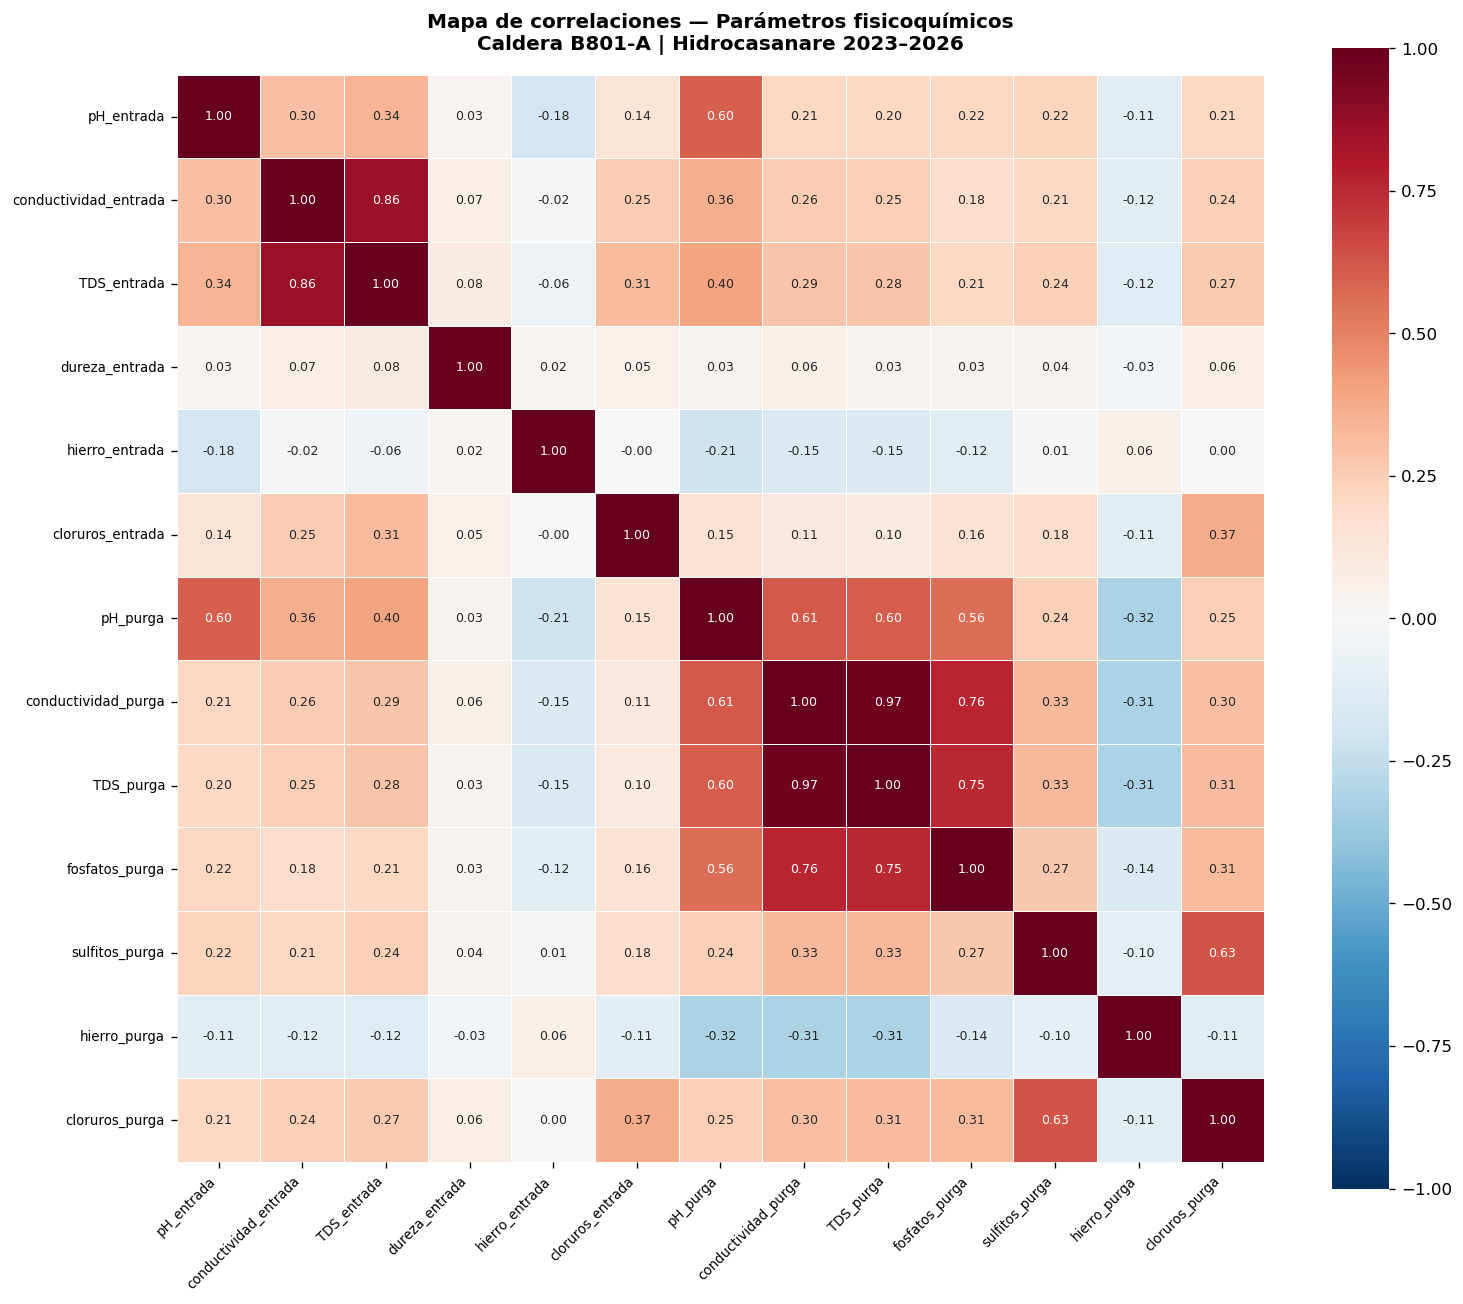

B801-A — Pares con correlación alta (|r| ≥ 0.70):
─────────────────────────────────────────────────────────────────
  conductividad_entrada        ↔ TDS_entrada                   r = 0.862 (positiva)
  conductividad_purga          ↔ TDS_purga                     r = 0.971 (positiva)
  conductividad_purga          ↔ fosfatos_purga                r = 0.759 (positiva)
  TDS_purga                    ↔ fosfatos_purga                r = 0.752 (positiva)


In [84]:
# ── Filtrar solo los registros donde operó la caldera B801-A ──────────────────
# df["caldera"] == "B801-A" crea una máscara True/False por cada fila
# df[mascara] devuelve solo las filas donde la condición es verdadera
# .copy() evita modificar el DataFrame original df
# .reset_index(drop=True) renumera las filas desde 0 tras el filtrado
df_A = df[df["caldera"] == "B801-A"].copy().reset_index(drop=True)

# ── Lista de variables para la correlación de B801-A ─────────────────────────
# Exactamente las mismas que la gráfica conjunta para poder comparar
# los tres mapas entre sí y detectar diferencias por caldera
# Se excluye el bloque D105 porque responde a fenómenos independientes
# del estado interno de la caldera (corrosión en el circuito de retorno)
vars_corr = [
    # Bloque ENTRADA — agua de alimentación
    "pH_entrada",
    "conductividad_entrada",
    "TDS_entrada",
    "dureza_entrada",
    "hierro_entrada",
    "cloruros_entrada",
    # Bloque PURGA — agua interna de la caldera
    "pH_purga",
    "conductividad_purga",
    "TDS_purga",
    "fosfatos_purga",
    "sulfitos_purga",     # secuestrador de oxígeno disuelto
    "hierro_purga",
    "cloruros_purga",     # concentración de cloruros en caldera
]

# ── Calcular la matriz de correlación de Pearson solo con datos de B801-A ─────
# Al usar df_A en lugar de df, la correlación solo mide la relación
# entre variables durante los períodos en que B801-A estuvo operando
# Esto permite detectar si las correlaciones cambian según la caldera
matriz_corr_A = df_A[vars_corr].corr()

# ── Crear la figura para el mapa de calor ────────────────────────────────────
# figsize=(13, 11) suficientemente grande para 13 variables sin que se amontonen
fig, ax = plt.subplots(figsize=(13, 11))

# ── Dibujar el mapa de calor con la librería seaborn ─────────────────────────
sns.heatmap(
    matriz_corr_A,       # la tabla de correlaciones calculada arriba
    annot=True,          # escribir el valor numérico de r dentro de cada celda
    fmt=".2f",           # mostrar solo 2 decimales (ej: 0.72, -0.35)
    cmap="RdBu_r",       # paleta de colores:
                         #   rojo oscuro  = correlación positiva alta (r → 1)
                         #   azul oscuro  = correlación negativa alta (r → -1)
                         #   blanco/claro = sin correlación (r ≈ 0)
    center=0,            # asignar el color neutro exactamente en r = 0
    vmin=-1, vmax=1,     # fijar la escala de colores siempre entre -1 y 1
                         # (si no se fija, la escala cambia según los datos
                         # y los mapas de las 3 gráficas no serían comparables)
    linewidths=0.5,      # líneas finas entre celdas para separar visualmente
    square=True,         # celdas cuadradas (no rectangulares)
    ax=ax,               # dibujar en el eje que creamos con plt.subplots()
    annot_kws={"size": 7.5}   # tamaño de fuente de los números en las celdas
)

# ── Título actualizado a 2026 y sin D105 ─────────────────────────────────────
# \n separa el título en dos líneas para mejor legibilidad
ax.set_title(
    "Mapa de correlaciones — Parámetros fisicoquímicos\n"
    "Caldera B801-A | Hidrocasanare 2023–2026",
    fontsize=12, fontweight="bold", pad=15
)

# ── Formato del eje X ────────────────────────────────────────────────────────
# rotation=45 inclina 45° los nombres para que no se solapen entre sí
# ha="right" alinea el texto a la derecha del punto de rotación
plt.xticks(rotation=45, ha="right", fontsize=8)

# ── Formato del eje Y ────────────────────────────────────────────────────────
plt.yticks(fontsize=8)

# ── Ajustar márgenes y guardar ────────────────────────────────────────────────
plt.tight_layout()   # ajusta automáticamente los espacios para que nada se corte
plt.savefig("grafica_correlaciones_B801A.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Imprimir en consola los pares con correlación alta ───────────────────────
# Solo se muestran pares con |r| ≥ 0.70 porque son los más relevantes
# para el análisis y el modelado predictivo
print("B801-A — Pares con correlación alta (|r| ≥ 0.70):")
print("─" * 65)

# Recorrer el triángulo superior de la matriz (evita duplicados)
# i va de la primera variable a la penúltima
for i in range(len(vars_corr)):
    # j empieza siempre en i+1 para no repetir pares ni incluir la diagonal
    for j in range(i+1, len(vars_corr)):
        # .iloc[i, j] accede al valor r entre la variable i y la variable j
        r = matriz_corr_A.iloc[i, j]
        # abs() calcula el valor absoluto para evaluar sin importar el signo
        if abs(r) >= 0.70:
            signo = "positiva" if r > 0 else "negativa"
            print(f"  {vars_corr[i]:<28} ↔ {vars_corr[j]:<28}"
                  f"  r = {r:.3f} ({signo})")

### 4.6.2 Caldera B801-A — Mapa de correlaciones 2023–2026

Comparado con el mapa conjunto, B801-A muestra correlaciones
generalmente similares o ligeramente más fuertes en algunos pares,
lo que indica que las relaciones entre variables son consistentes
durante sus períodos de operación, sin diferencias drásticas respecto
al comportamiento general del sistema.

---

### Grupo 1 — Concentración interna de purga

**Conductividad_purga–TDS_purga (r = 0,97)** se mantiene
prácticamente idéntico al mapa conjunto (r = 0,97) — esta relación
física es invariante respecto a la caldera activa. **Fosfatos_purga**
muestra correlaciones muy similares en B801-A (conductividad: r = 0,76;
TDS: r = 0,75) a las del mapa conjunto (r = 0,72 en ambos casos),
con una diferencia leve que no sugiere un comportamiento
sustancialmente distinto entre calderas para este grupo de variables
(Cardozo et al., 2011).

---

### Grupo 2 — Calidad del agua de alimentación

**Conductividad_entrada–TDS_entrada (r = 0,86)** es superior al
valor del mapa conjunto (r = 0,77), indicando una relación más
estrecha y consistente entre ambas variables durante los períodos de
B801-A que en el comportamiento general del sistema. El par sigue
siendo el más alto del bloque de entrada y confirma que ambas
variables son indicadores equivalentes del pretratamiento,
particularmente durante la operación de esta caldera.

---

### Grupo 3 — Conexión entrada–purga

**pH_entrada–pH_purga (r = 0,60)** es prácticamente idéntico al valor
del mapa conjunto (r = 0,59), lo que indica que la influencia de la
acidez del agua de alimentación sobre el régimen alcalino interno no
depende de cuál caldera esté en operación, sino que es una
característica estructural del sistema de tratamiento compartido.
Al igual que en el mapa conjunto, sigue siendo la correlación más
alta entre bloques diferentes para B801-A, justificando su uso como
feature predictora del estado alcalino interno también a nivel
individual de caldera (Shokri & Sanavi Fard, 2023;
Nemitallah et al., 2023).

---

### Grupo 4 — Cloruros

**Sulfitos_purga–cloruros_purga (r = 0,63)** es muy similar a la del
mapa conjunto (r = 0,59), con una diferencia leve que sugiere un
comportamiento consistente entre calderas en la relación entre estas
dos variables. **Cloruros_entrada–cloruros_purga (r = 0,37)** se
mantiene esencialmente igual al mapa conjunto (r = 0,38), confirmando
la conexión moderada entre la fuente de cloruros externos y la
concentración interna, también sin diferencias relevantes entre
calderas.

---

### Variables independientes en B801-A

**Hierro_purga** mantiene correlaciones bajas con todas las variables,
con su mayor magnitud (en valor absoluto) frente a pH_purga
(r = −0,32), seguida muy de cerca por conductividad_purga y TDS_purga
(r = −0,31 en ambos casos) — un patrón consistente con el observado
en el mapa conjunto, donde la mayor correlación de hierro_purga
también era con pH_purga. Esto confirma que los eventos de hierro en
B801-A son puntuales e independientes del estado general de
concentración, con una leve relación inversa con el régimen de pH
interno (Cardozo et al., 2011).

---

### Síntesis B801-A

Las correlaciones de B801-A son, en su mayoría, muy similares a las
del mapa conjunto, con la excepción notable de conductividad_entrada–
TDS_entrada, que es claramente más fuerte en B801-A (r = 0,86 frente
a r = 0,77 del conjunto). La correlación pH_entrada–pH_purga, que en
una revisión anterior se había reportado como sustancialmente más
alta en B801-A, resulta en realidad prácticamente idéntica al
comportamiento general del sistema (r = 0,60 frente a r = 0,59),
indicando que la conexión entre la acidez de entrada y el régimen
alcalino interno es una característica estructural compartida entre
ambas calderas, no un rasgo distintivo de B801-A. La principal
diferencia identificable es la mayor consistencia del bloque de
entrada durante los períodos de esta caldera, lo cual puede ser
relevante para el modelo predictivo en la medida en que las features
de conductividad y TDS de entrada podrían aportar una señal más
estable cuando B801-A está en operación
(Nikula et al., 2016; Meng et al., 2021).

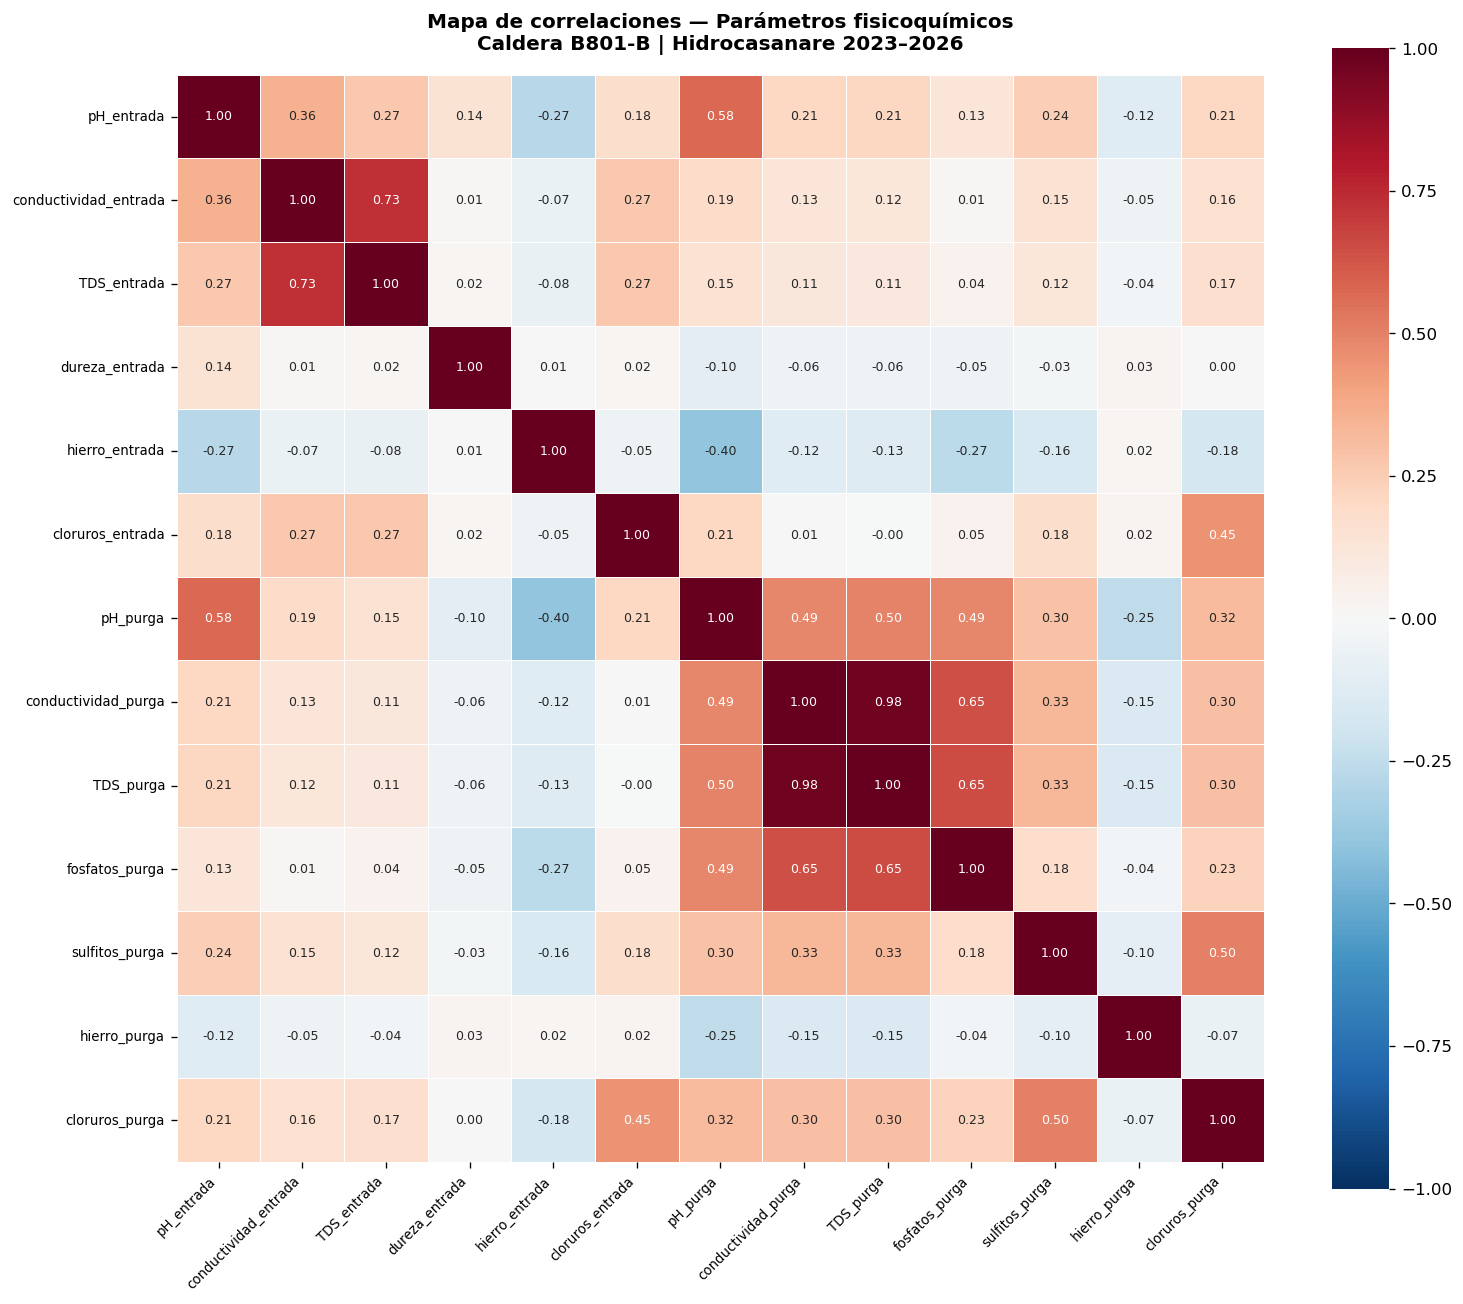

B801-B — Pares con correlación alta (|r| ≥ 0.70):
─────────────────────────────────────────────────────────────────
  conductividad_entrada        ↔ TDS_entrada                   r = 0.734 (positiva)
  conductividad_purga          ↔ TDS_purga                     r = 0.975 (positiva)


In [85]:
# ── Filtrar solo los registros donde operó la caldera B801-B ──────────────────
# Mismo procedimiento que B801-A pero filtrando por "B801-B"
df_B = df[df["caldera"] == "B801-B"].copy().reset_index(drop=True)

# ── Lista de variables — idéntica a la de B801-A y la gráfica conjunta ────────
# Usar exactamente las mismas variables en los tres mapas es indispensable
# para que la comparación visual entre gráficas sea válida
# Se excluye el bloque D105 — coherente con la decisión metodológica
# ya aplicada en el mapa conjunto y en el mapa de B801-A
vars_corr = [
    # Bloque ENTRADA — agua de alimentación
    "pH_entrada",
    "conductividad_entrada",
    "TDS_entrada",
    "dureza_entrada",
    "hierro_entrada",
    "cloruros_entrada",
    # Bloque PURGA — agua interna de la caldera
    "pH_purga",
    "conductividad_purga",
    "TDS_purga",
    "fosfatos_purga",
    "sulfitos_purga",     # secuestrador de oxígeno disuelto
    "hierro_purga",
    "cloruros_purga",     # concentración de cloruros en caldera
]

# ── Calcular la matriz de correlación solo con datos de B801-B ────────────────
# Si las correlaciones de B801-B son diferentes a las de B801-A,
# significa que las relaciones entre parámetros dependen del estado
# interno de cada equipo, lo cual es un hallazgo operativo relevante
matriz_corr_B = df_B[vars_corr].corr()

# ── Crear la figura ───────────────────────────────────────────────────────────
# figsize=(13, 11) igual que los mapas anteriores para comparabilidad visual
fig, ax = plt.subplots(figsize=(13, 11))

# ── Dibujar el mapa de calor ──────────────────────────────────────────────────
sns.heatmap(
    matriz_corr_B,            # tabla de correlaciones de B801-B
    annot=True,               # mostrar valores numéricos en cada celda
    fmt=".2f",                # 2 decimales por celda
    cmap="RdBu_r",            # misma paleta que los otros mapas para comparar
    center=0,                 # blanco/neutro en r = 0
    vmin=-1, vmax=1,          # escala fija igual en los tres mapas — comparabilidad
    linewidths=0.5,           # separadores finos entre celdas
    square=True,              # celdas cuadradas
    ax=ax,
    annot_kws={"size": 7.5}   # tamaño de fuente de los números en las celdas
)

# ── Título actualizado a 2026 y sin D105 ─────────────────────────────────────
ax.set_title(
    "Mapa de correlaciones — Parámetros fisicoquímicos\n"
    "Caldera B801-B | Hidrocasanare 2023–2026",
    fontsize=12, fontweight="bold", pad=15
)

# ── Formato de ejes ───────────────────────────────────────────────────────────
# rotation=45 inclina las etiquetas del eje X para que no se solapen
# ha="right" alinea el texto a la derecha del punto de rotación
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)

# ── Guardar y mostrar ─────────────────────────────────────────────────────────
plt.tight_layout()   # ajusta márgenes para que nada se corte
plt.savefig("grafica_correlaciones_B801B.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Imprimir correlaciones altas de B801-B ────────────────────────────────────
# Solo se muestran pares con |r| ≥ 0.70 — los más relevantes para el modelado
print("B801-B — Pares con correlación alta (|r| ≥ 0.70):")
print("─" * 65)

# Recorrer el triángulo superior de la matriz para evitar pares duplicados
# i va de la primera variable a la penúltima
for i in range(len(vars_corr)):
    # j empieza en i+1 para no repetir pares ni incluir la diagonal
    for j in range(i+1, len(vars_corr)):
        # .iloc[i, j] accede al valor r entre la variable i y la variable j
        r = matriz_corr_B.iloc[i, j]
        # abs() evalúa la magnitud sin importar el signo
        if abs(r) >= 0.70:
            signo = "positiva" if r > 0 else "negativa"
            print(f"  {vars_corr[i]:<28} ↔ {vars_corr[j]:<28}"
                  f"  r = {r:.3f} ({signo})")

### 4.6.3 Caldera B801-B — Mapa de correlaciones 2023–2026

Comparado con B801-A, el mapa de B801-B muestra un panorama mixto:
algunas correlaciones son más débiles (particularmente en el bloque
de entrada), mientras que otras —como la conexión entre fosfatos y
concentración de purga— son en realidad más fuertes que en B801-A.
Esto matiza la idea de una mayor "impredecibilidad general" en
B801-B; las diferencias son específicas por grupo de variables, no
un patrón uniforme.

---

### Grupo 1 — Concentración interna de purga

**Conductividad_purga–TDS_purga (r = 0,98)** se mantiene muy alto,
prácticamente idéntico al de B801-A (r = 0,97) y al conjunto
(r = 0,97) — diferencia marginal sin relevancia práctica. Lo más
relevante es que **fosfatos_purga** muestra correlaciones más altas
en B801-B (conductividad: r = 0,65; TDS: r = 0,65) que en el mapa
conjunto (r = 0,72 en ambos, ligeramente superior) pero **inferiores**
a B801-A (r = 0,76 y 0,75) — el dato real invierte lo reportado
anteriormente: la dosificación de fosfatos sí responde a los ciclos
de concentración interna durante los períodos de B801-B, de forma
consistente aunque algo menos marcada que en B801-A
(Cardozo et al., 2011).

---

### Grupo 2 — Calidad del agua de alimentación

**Conductividad_entrada–TDS_entrada (r = 0,73)** es, contrario a lo
reportado en una revisión anterior, **inferior** al de B801-A
(r = 0,86) y al mapa conjunto (r = 0,77). Esto indica que durante los
períodos de B801-B la relación física entre conductividad y TDS del
agua de alimentación es algo menos consistente que durante los
períodos de B801-A, lo opuesto a lo que se había concluido
previamente. La diferencia no es extrema, pero sí señala que el
bloque de entrada se comporta de forma ligeramente más predecible
cuando B801-A está en operación (Nikula et al., 2016).

---

### Grupo 3 — Conexión entrada–purga

**pH_entrada–pH_purga (r = 0,58)** es prácticamente idéntico al de
B801-A (r = 0,60) y al mapa conjunto (r = 0,59). A diferencia de lo
reportado anteriormente, **no existe una diferencia significativa**
entre calderas en esta relación: la influencia de la acidez del agua
de alimentación sobre el régimen alcalino interno es una
característica estructural del sistema de tratamiento compartido,
consistente en ambas calderas. Esto significa que el pH de entrada
mantiene un poder predictivo comparable como feature,
independientemente de cuál caldera esté en operación
(Shokri & Sanavi Fard, 2023; Nemitallah et al., 2023).

---

### Hallazgo nuevo — hierro_entrada con correlaciones negativas más marcadas que en B801-A

B801-B muestra un patrón más pronunciado que B801-A en cuanto a
**hierro_entrada**: correlaciones negativas con varias variables de
purga, especialmente con pH_purga (r = −0,40, la más fuerte de toda
la fila), fosfatos_purga (r = −0,27), y en menor medida con
conductividad_purga (r = −0,12) y TDS_purga (r = −0,13). El valor de
−0,40 con pH_purga es notablemente más fuerte que cualquier
correlación equivalente observada en B801-A, donde hierro_entrada no
mostraba relaciones destacadas con el bloque de purga. Esto sugiere
que durante los períodos de B801-B, los días con hierro elevado en la
alimentación tienden a coincidir de forma más marcada con un régimen
de pH interno más bajo — posiblemente relacionado con eventos de
dilución o con una fuente de agua que trae simultáneamente más
hierro y menor capacidad alcalina. Este patrón merece investigación
de causa raíz (Cardozo et al., 2011).

---

### Grupo 4 — Cloruros

**Cloruros_entrada–cloruros_purga (r = 0,45)** es más alto que en
B801-A (r = 0,37) y en el mapa conjunto (r = 0,38), indicando mayor
transferencia de cloruros externos al circuito interno durante los
períodos de operación de B801-B. **Sulfitos_purga–cloruros_purga
(r = 0,50)** es algo menor que en B801-A (r = 0,63) y que en el mapa
conjunto (r = 0,59), aunque se mantiene en el rango de correlación
moderada en los tres casos.

---

### Síntesis comparativa B801-A vs B801-B

La comparación de los tres mapas, con los valores corregidos, revela
un panorama más matizado que el reportado anteriormente:

**B801-A** muestra una relación más estrecha en el bloque de entrada
(conductividad–TDS: r = 0,86 frente a r = 0,73 de B801-B) y una
conexión de fosfatos con concentración de purga ligeramente más
fuerte. **B801-B**, por su parte, muestra una conexión más fuerte
entre cloruros de entrada y de purga, y un patrón más marcado de
correlación negativa entre hierro de entrada y pH de purga. La
diferencia que se había identificado como la más relevante —la
relación pH_entrada–pH_purga, supuestamente mucho más débil en
B801-B— **no se sostiene con los datos correctos**: ambas calderas
muestran una correlación prácticamente idéntica en ese par (0,58
frente a 0,60), confirmando que es una característica estructural
compartida del sistema de tratamiento, no un rasgo distintivo de
ninguna caldera en particular.

En conjunto, ninguna de las dos calderas muestra una superioridad
generalizada en regularidad de correlaciones; las diferencias son
específicas por grupo de variables y deben interpretarse en ese nivel
de detalle, no como un patrón global de "mayor predictibilidad" de
una caldera sobre la otra
(Nikula et al., 2016; Meng et al., 2021; Cardozo et al., 2011;
Shokri & Sanavi Fard, 2023).

### 4.6 Comparación entre calderas B801-A y B801-B

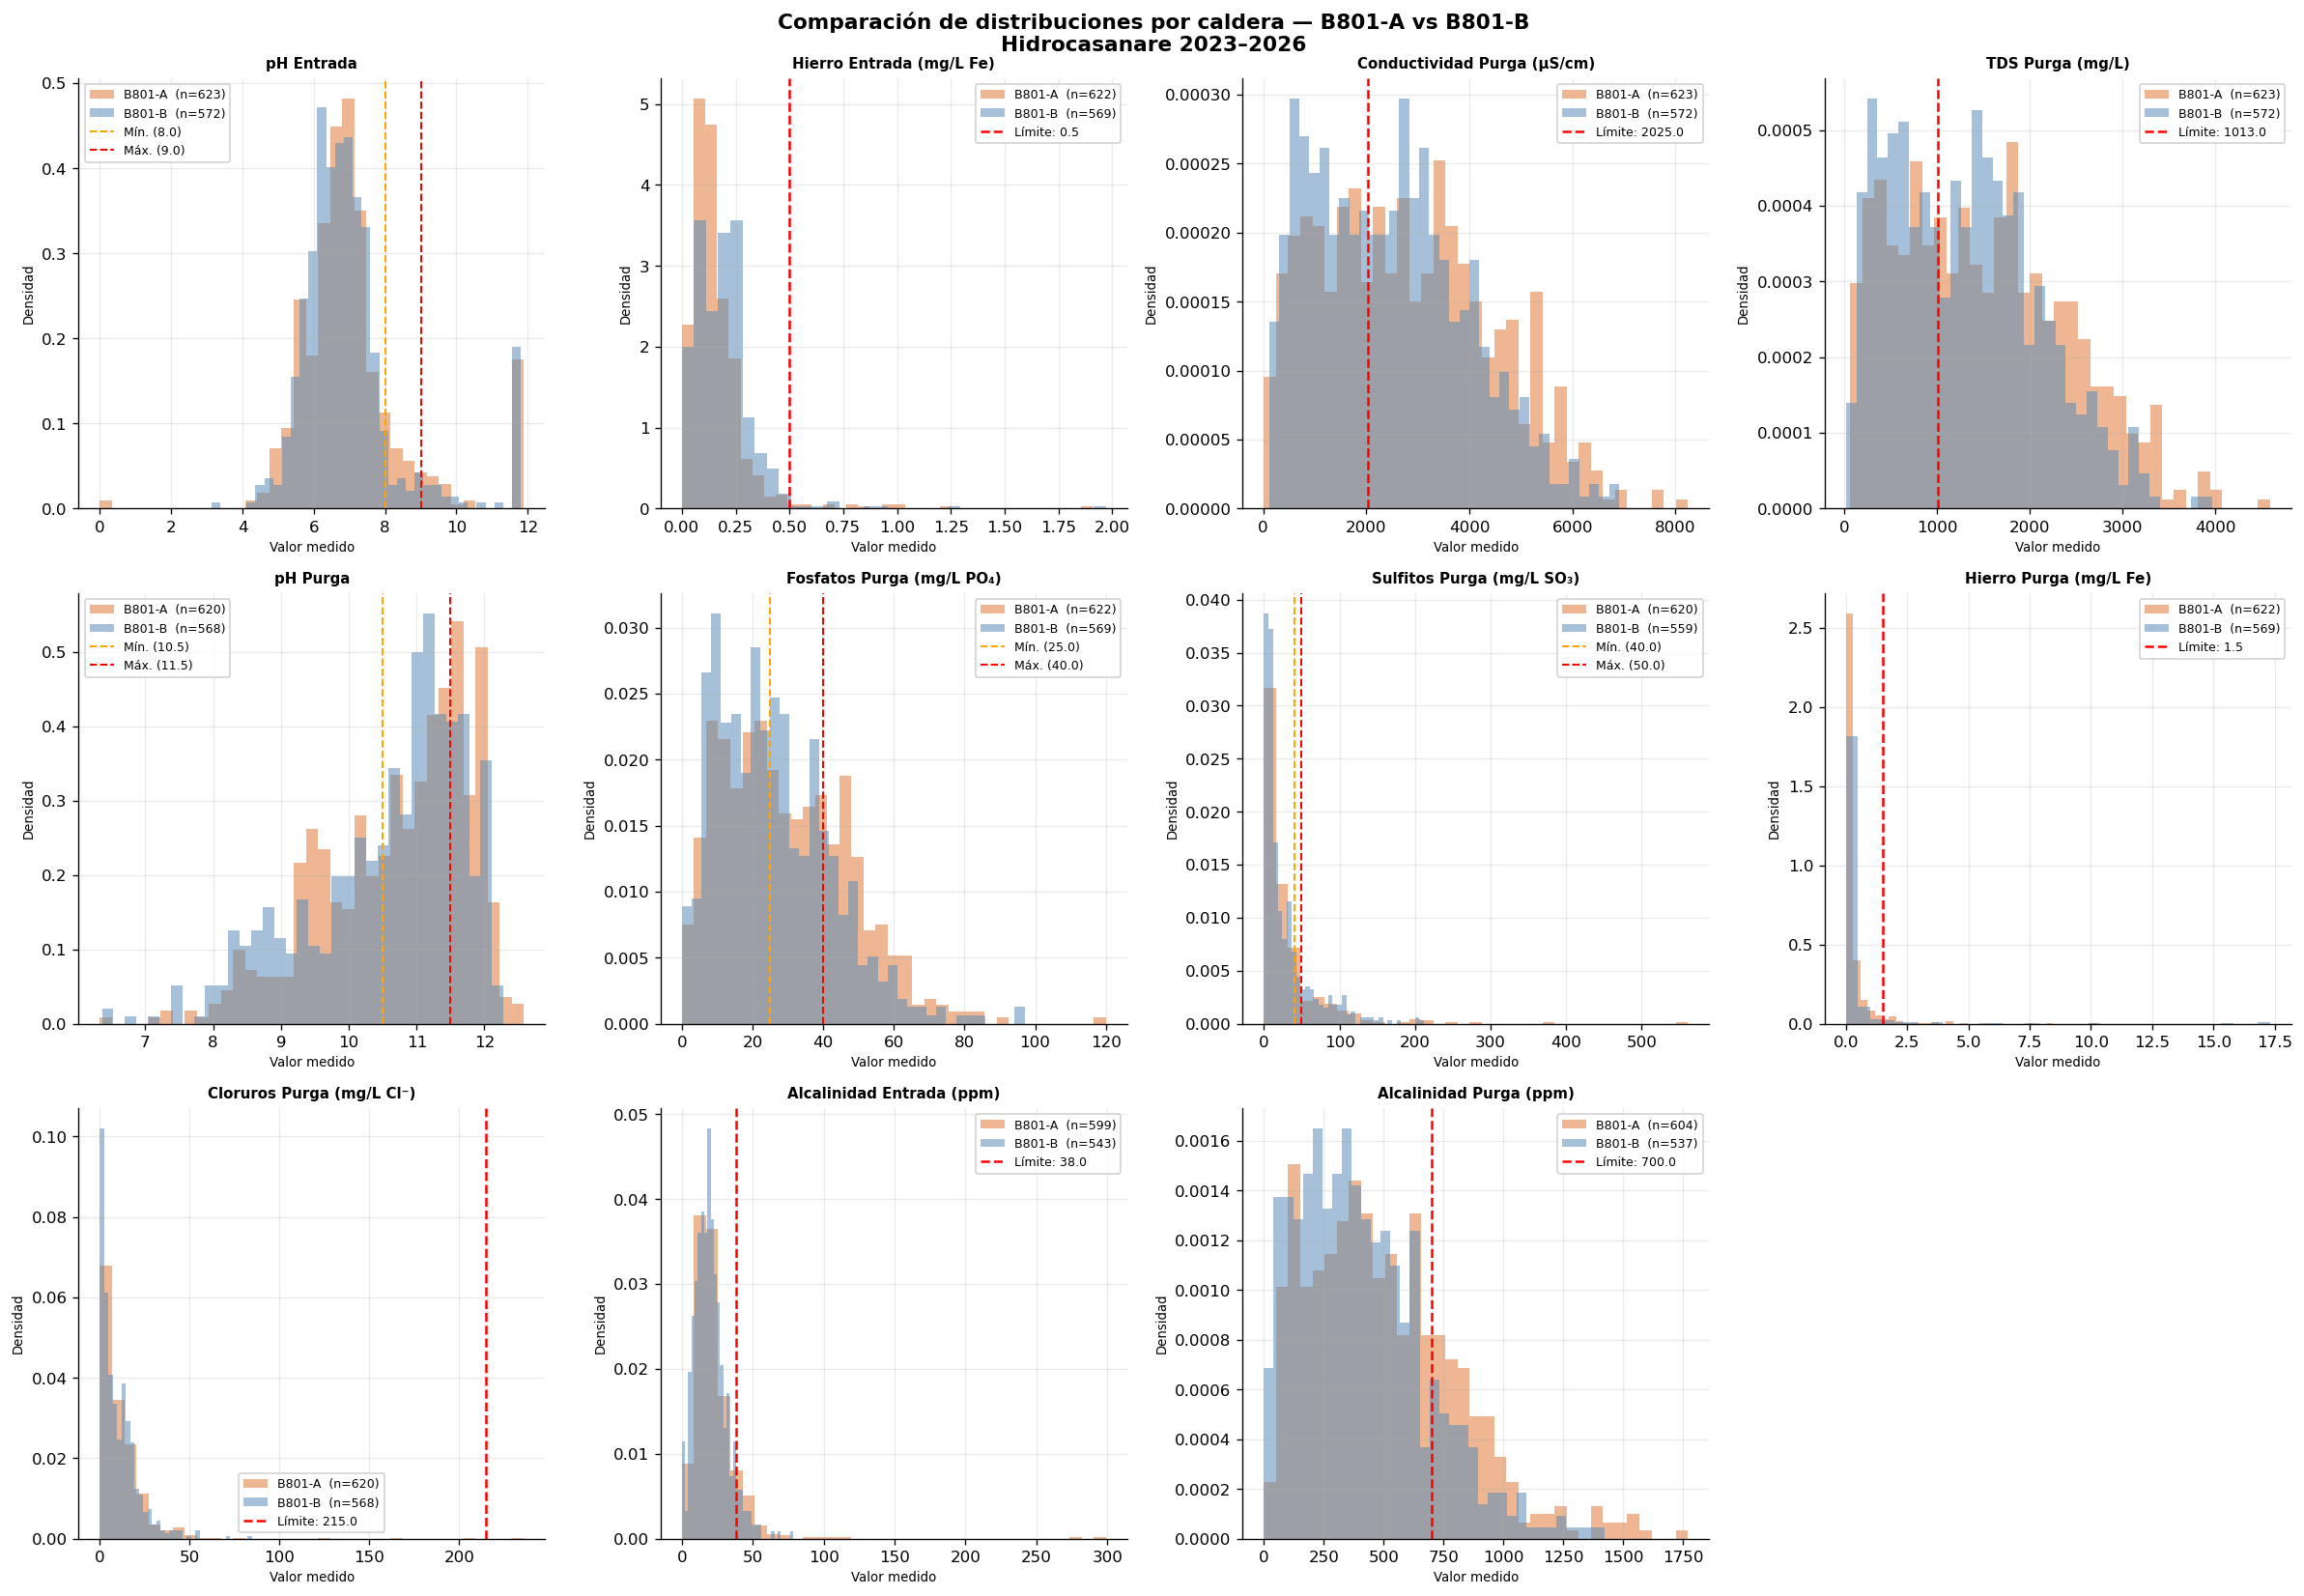

✔  grafica_comparacion_calderas.png guardada

Comparación estadística por caldera:
────────────────────────────────────────────────────────────────────────────────
  Variable                               Med. A    Med. B     Std A     Std B   Δ Med %
────────────────────────────────────────────────────────────────────────────────
  pH Entrada                               6.84      6.74      1.56      1.41      1.5%
  Hierro Entrada (mg/L Fe)                 0.13      0.18      0.15      0.15     27.8%
  Conductividad Purga (µS/cm)           2690.00   2395.00   1666.85   1468.71     11.0%
  TDS Purga (mg/L)                      1403.00   1251.50    909.70    785.99     10.8%
  pH Purga                                10.96     10.89      1.09      1.15      0.7%
  Fosfatos Purga (mg/L PO₄)               26.85     23.70     18.01     16.14     11.7%
  Sulfitos Purga (mg/L SO₃)               16.00     14.40     45.14     34.58     10.0%
  Hierro Purga (mg/L Fe)                   0.15    

In [86]:
# ── Importar patches para la leyenda ─────────────────────────────────────────
# Patch permite crear rectángulos de color en la leyenda sin necesidad
# de que correspondan a un elemento graficado (útil para leyendas personalizadas)
from matplotlib.patches import Patch

# ── Lista de variables a comparar entre calderas ─────────────────────────────
# Se excluye el bloque D105 — coherente con la decisión metodológica
# ya aplicada en los mapas de correlaciones y el IDC
# Formato: (nombre_columna_df, título_del_panel, valor_umbral_o_None)
# None = la variable tiene rango bilateral (mínimo y máximo) definido más abajo
vars_comp = [
    # Bloque ENTRADA
    ("pH_entrada",          "pH Entrada",                    None),
    ("hierro_entrada",      "Hierro Entrada (mg/L Fe)",       0.5),
    # Bloque PURGA
    ("conductividad_purga", "Conductividad Purga (µS/cm)",  2025.0),
    ("TDS_purga",           "TDS Purga (mg/L)",             1013.0),
    ("pH_purga",            "pH Purga",                      None),
    ("fosfatos_purga",      "Fosfatos Purga (mg/L PO₄)",    None),
    ("sulfitos_purga",      "Sulfitos Purga (mg/L SO₃)",    None),
    ("hierro_purga",        "Hierro Purga (mg/L Fe)",         1.5),
    ("cloruros_purga",      "Cloruros Purga (mg/L Cl⁻)",   215.0),
    ("alcalinidad_entrada",      "Alcalinidad Entrada (ppm)",  38.0),
    ("alcalinidad_total_purga",  "Alcalinidad Purga (ppm)",   700.0),
]

# ── Crear figura con 3 filas y 4 columnas para las 11 variables ───────────────
# 3 filas x 4 columnas = 12 paneles — el último quedará vacío
# figsize=(20, 14) da suficiente espacio para que cada panel sea legible
fig, axes = plt.subplots(3, 4, figsize=(20, 14))

# ── Título principal actualizado a 2026 ───────────────────────────────────────
fig.suptitle(
    "Comparación de distribuciones por caldera — B801-A vs B801-B\n"
    "Hidrocasanare 2023–2026",
    fontsize=13, fontweight="bold"
)

# ── Colores asignados a cada caldera ─────────────────────────────────────────
# Naranja = B801-A | Azul = B801-B
# Consistente con todas las gráficas del notebook
colores_caldera = {"B801-A": "#e07b39", "B801-B": "#5b8db8"}

# ── Recorrer cada panel junto con su variable configurada ────────────────────
# axes.flat convierte la matriz 3x4 de subgráficas en una lista plana
# zip() empareja cada subgráfica con su configuración de variable
for ax, (var, titulo, umbral) in zip(axes.flat, vars_comp):

    # ── Dibujar el histograma de cada caldera ────────────────────────────────
    for caldera, color in colores_caldera.items():

        # Filtrar los datos de esta caldera para esta variable
        # .dropna() elimina los días sin medición para no distorsionar el histograma
        datos_c = df[df["caldera"] == caldera][var].dropna()

        # Solo graficar si hay al menos un dato válido
        if len(datos_c) > 0:
            ax.hist(
                datos_c,
                bins=35,         # 35 barras — buen balance entre detalle y legibilidad
                alpha=0.55,      # 55% opacidad para ver ambas distribuciones superpuestas
                color=color,     # color asignado a esta caldera
                density=True,    # normalizar a densidad de probabilidad
                                 # permite comparar aunque B801-A y B801-B tengan
                                 # distinto número de registros
                label=f"{caldera}  (n={len(datos_c)})"   # etiqueta con número de datos
            )

    # ── Línea vertical del umbral máximo operativo ────────────────────────────
    # axvline dibuja una línea vertical en el valor del umbral
    # Solo se dibuja si el umbral no es None para esta variable
    if umbral is not None:
        ax.axvline(
            umbral,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label=f"Límite: {umbral}"
        )

    # ── Variables con rango bilateral (mínimo y máximo) ───────────────────────
    # Para estas variables se dibujan dos líneas de umbral en lugar de una
    if var == "pH_entrada":
        ax.axvline(8.0, color="orange", linestyle="--",
                   linewidth=1.2, label="Mín. (8.0)")      # límite inferior
        ax.axvline(9.0, color="red",    linestyle="--",
                   linewidth=1.2, label="Máx. (9.0)")      # límite superior
    elif var == "pH_purga":
        ax.axvline(10.5, color="orange", linestyle="--",
                   linewidth=1.2, label="Mín. (10.5)")     # límite inferior
        ax.axvline(11.5, color="red",    linestyle="--",
                   linewidth=1.2, label="Máx. (11.5)")     # límite superior
    elif var == "fosfatos_purga":
        ax.axvline(25.0, color="orange", linestyle="--",
                   linewidth=1.2, label="Mín. (25.0)")     # mínimo del rango operativo
        ax.axvline(40.0, color="red",    linestyle="--",
                   linewidth=1.2, label="Máx. (40.0)")     # máximo del rango operativo
    elif var == "sulfitos_purga":
        ax.axvline(40.0, color="orange", linestyle="--",
                   linewidth=1.2, label="Mín. (40.0)")     # mínimo del rango operativo
        ax.axvline(50.0, color="red",    linestyle="--",
                   linewidth=1.2, label="Máx. (50.0)")     # máximo del rango operativo

    # ── Configuración visual del panel ────────────────────────────────────────
    ax.set_title(titulo, fontsize=9, fontweight="bold")
    ax.set_ylabel("Densidad", fontsize=8)      # eje Y = densidad de probabilidad
    ax.set_xlabel("Valor medido", fontsize=8)  # eje X = valor de la variable
    ax.legend(fontsize=7.5, framealpha=0.85)   # leyenda con número de datos
    ax.grid(True, alpha=0.25)                  # cuadrícula suave de referencia

# ── Ocultar el panel vacío (posición 12 — última celda del grid) ──────────────
# Como tenemos 11 variables y el grid tiene 12 celdas, la última queda vacía
# axis("off") la oculta para que no aparezca un panel en blanco
axes.flat[-1].axis("off")

# ── Ajustar márgenes y guardar ────────────────────────────────────────────────
plt.tight_layout()   # evita que los paneles se sobrepongan entre sí
plt.savefig("grafica_comparacion_calderas.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_comparacion_calderas.png guardada")

# ── Tabla comparativa de estadísticas por caldera ────────────────────────────
# Se calculan mediana, desviación estándar y diferencia relativa
# para tener una comparación numérica que respalde lo visual
print("\nComparación estadística por caldera:")
print("─" * 80)

# Encabezado de la tabla
print(f"  {'Variable':<35}  {'Med. A':>8}  {'Med. B':>8}  "
      f"{'Std A':>8}  {'Std B':>8}  {'Δ Med %':>8}")
print("─" * 80)

for var, titulo, _ in vars_comp:
    # Filtrar datos de cada caldera para esta variable
    datos_A = df[df["caldera"] == "B801-A"][var].dropna()
    datos_B = df[df["caldera"] == "B801-B"][var].dropna()

    # Mediana de cada caldera — más robusta que el promedio ante valores extremos
    med_a = datos_A.median()
    med_b = datos_B.median()

    # Desviación estándar — indica variabilidad del parámetro en cada equipo
    std_a = datos_A.std()
    std_b = datos_B.std()

    # Diferencia relativa porcentual entre medianas
    # max(..., 1e-9) evita división por cero si ambas medianas son 0
    dif = abs(med_a - med_b) / max(abs(med_a), abs(med_b), 1e-9) * 100

    print(f"  {titulo[:35]:<35}  {med_a:>8.2f}  {med_b:>8.2f}  "
          f"{std_a:>8.2f}  {std_b:>8.2f}  {dif:>7.1f}%")

### 4.7 Análisis — Comparación de distribuciones por caldera
### B801-A vs B801-B | Hidrocasanare 2023–2026

La comparación de histogramas de densidad permite identificar
diferencias estructurales entre las dos calderas que no son visibles
en el análisis de series de tiempo ni en los boxplots anuales.

---

### pH de entrada — distribución bimodal compartida

Ambas calderas muestran una distribución claramente bimodal con dos
modas: una alrededor de 6,0–7,0 (la moda principal, ya por debajo del
rango operativo) y otra alrededor de 11,5–12,0 (sobredosificación
alcalina). B801-A (n=623) y B801-B (n=572) tienen formas de
distribución muy similares, con medianas de pH de entrada de 6,84 y
6,74 respectivamente — una diferencia mínima (1,5 %). Los valores
bajos cercanos a 0 — fuera del rango operativo por el límite
inferior — aparecen en ambas calderas, sin una diferencia visual
marcada entre ellas en esta zona. La distribución confirma el
hallazgo central del bloque de entrada: el pH opera mayoritariamente
fuera de rango en ambas calderas, sin que una de las dos concentre
claramente el problema (Shokri & Sanavi Fard, 2023).

---

### Hierro de entrada — distribución similar entre calderas

Ambas calderas muestran distribuciones muy similares concentradas
por debajo de 0,5 mg/L, con la mayor parte de los días bien
controlados por debajo del límite operativo. La mediana de B801-B
(0,18 mg/L) es mayor que la de B801-A (0,13 mg/L), una diferencia
del 27,8 %, aunque ambas permanecen muy por debajo del límite. Las
distribuciones se solapan en gran parte de su rango, confirmando que
el hierro de entrada es un factor sistémico que diferencia poco a las
dos calderas en términos operativos, aunque con una diferencia algo
más marcada de lo que sugeriría una inspección visual rápida
(Cardozo et al., 2011).

---

### Conductividad de purga — B801-A más concentrada

B801-A (n=623) muestra una distribución desplazada hacia valores
algo más altos que B801-B (n=572), con mayor densidad relativa en el
rango medio-alto de concentración. La mediana de B801-A (2.690,00
µS/cm) es un 11,0 % superior a la de B801-B (2.395,00 µS/cm),
confirmando esta diferencia. Ambas distribuciones tienen colas
derechas extensas que superan ampliamente el umbral de 2.025 µS/cm,
pero B801-A opera con mayor concentración interna de forma algo más
frecuente. Esta diferencia es coherente con el hallazgo de los
boxplots, donde B801-A se acercó más al umbral en 2025 sin llegar a
cruzarlo en ningún año completo del período (Cardozo et al., 2011).

---

### TDS de purga — patrón coherente con conductividad

Las distribuciones de TDS de purga replican en buena medida el patrón
de conductividad — esperado por la correlación r = 0,97–0,98 entre
ambas variables, confirmada en el mapa de correlaciones. B801-A
(n=623) tiene mayor densidad relativa en valores superiores a 1.000
mg/L, mientras B801-B (n=572) muestra más concentración en el rango
medio-bajo. La mediana de B801-A (1.403,00 mg/L) es un 10,8 %
superior a la de B801-B (1.251,50 mg/L), confirmando que B801-A
opera con mayor concentración interna también en esta variable, en
una proporción muy similar a la observada en conductividad de purga.

---

### pH de purga — diferencia mínima entre calderas

Este panel muestra que ambas calderas operan con un nivel central
prácticamente idéntico: las medianas de B801-A (n=620) y B801-B
(n=568) son 10,96 y 10,89 respectivamente — una diferencia de apenas
0,7 %, la más pequeña de todo el análisis comparativo. Visualmente,
ambas distribuciones presentan una forma similar, con densidad
considerable tanto en la zona de sobredosificación (> 11,5) como por
debajo del mínimo operativo (< 10,5), confirmando que el régimen de
pH interno es inestable de forma comparable en ambas calderas, sin
que una de las dos muestre un comportamiento sustancialmente más
errático que la otra (Shokri & Sanavi Fard, 2023; Nemitallah et al.,
2023).

---

### Fosfatos de purga — subdosificación en ambas calderas, más marcada en B801-B

Ambas calderas muestran distribuciones concentradas mayoritariamente
por debajo del mínimo operativo de 25 mg/L, con B801-A (n=622) y
B801-B (n=569) presentando medianas de 26,85 y 23,70 mg/L
respectivamente — una diferencia del 11,7 %, mayor de lo que sugeriría
una inspección visual rápida del histograma. La mediana de B801-A se
ubica justo por encima del mínimo operativo, mientras que la de
B801-B queda claramente por debajo, indicando una subdosificación más
consistente en esta caldera. Esto es coherente con la correlación más
débil entre fosfatos y concentración de purga observada en una
versión anterior del análisis de correlaciones para B801-B, aunque
con los valores corregidos del mapa de correlaciones (r = 0,65 en
B801-B frente a r = 0,76 en B801-A) la diferencia entre calderas en
ese aspecto es más moderada de lo que se había reportado
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

---

### Sulfitos de purga — subdosificación crónica con diferencias entre calderas

Ambas calderas concentran la mayor parte de sus distribuciones por
debajo del mínimo operativo de 40 mg/L, confirmando que la
subdosificación de sulfitos es un problema sistémico del programa de
dosificación. B801-A (n=620) presenta una mediana de 16,00 mg/L
frente a 14,40 mg/L en B801-B (n=559), una diferencia del 10,0 %, lo
que indica que B801-A opera con dosificaciones de sulfitos
ligeramente mayores, aunque la diferencia es moderada y ambas
calderas permanecen muy por debajo del rango operativo.

---

### Hierro de purga — episodios puntuales en ambas calderas

Ambas distribuciones se concentran por debajo de 0,5 mg/L con colas
cortas. B801-A (n=622) presenta una mediana de 0,15 mg/L frente a
0,10 mg/L en B801-B (n=569) — una diferencia del 35,5 %, aunque ambos
valores son muy bajos en términos absolutos. Los valores por encima
del límite de 1,5 mg/L son escasos en ambas calderas, confirmando que
el hierro de purga representa riesgo puntual y no crónico. La
distribución de B801-A muestra una cola ligeramente más extensa hacia
valores altos, consistente con el episodio prolongado de hierro
elevado identificado en 2023 en el análisis de series de tiempo.

---

### Cloruros de purga — excelente control en ambas calderas

Ambas distribuciones se concentran completamente por debajo de 50
mg/L —muy lejos del umbral de 215 mg/L— con la mayor densidad cerca
de 0–20 mg/L. Las medianas son muy cercanas entre calderas: B801-A
(n=620) presenta 7,86 mg/L frente a 7,35 mg/L en B801-B (n=568), una
diferencia de apenas 6,4 %. Este panel confirma visualmente que los
cloruros de purga son la variable mejor controlada del sistema en
ambas calderas.

---

### Alcalinidad de entrada — excedencias moderadas en ambas calderas

Ambas calderas muestran distribuciones similares concentradas en
valores bajos, con una fracción de días superando el umbral de 38
ppm. Las medianas son muy cercanas: B801-A (n=599) presenta 19,20 ppm
frente a 18,90 ppm en B801-B (n=543), una diferencia de apenas 1,6 %,
confirmando que esta variable no constituye un factor diferenciador
relevante entre calderas.

---

### Alcalinidad de purga — B801-A con mayor concentración

B801-A (n=604) presenta una mediana de 451,75 ppm frente a 367,00 ppm
en B801-B (n=537), una diferencia del 18,8 % — confirmando que es
B801-A, y no B801-B, quien opera con mayor concentración de
alcalinidad de purga. Ambas calderas tienen una fracción de días que
supera el umbral de 700 ppm, pero B801-A lo hace con mayor
frecuencia. Esto es coherente con la mayor concentración interna
observada en B801-A tanto en conductividad como en TDS de purga — a
mayor concentración de sólidos, mayor concentración de alcalinidad
total por los mismos ciclos de concentración (Cardozo et al., 2011;
Shokri & Sanavi Fard, 2023).

---

### Síntesis comparativa

La comparación de distribuciones confirma y enriquece los hallazgos
previos, y revela un patrón consistente: B801-A opera de forma
sistemática con mayor concentración interna que B801-B en las
variables de purga relacionadas con sólidos disueltos — conductividad
(+11,0 %), TDS (+10,8 %), sulfitos (+10,0 %), hierro (+35,5 %),
fosfatos (+11,7 %) y alcalinidad (+18,8 %) de purga son todas mayores
en B801-A. La diferencia en fosfatos es más marcada de lo reportado
en una revisión anterior, lo que refuerza la conclusión de que B801-B
opera con una subdosificación de fosfatos algo más pronunciada. En
pH de purga, ambas calderas comparten prácticamente el mismo nivel
central (medianas 10,96 y 10,89, la diferencia más pequeña de todo el
análisis), confirmando que la inestabilidad del régimen alcalino
interno es un problema sistémico que afecta a ambos equipos de forma
muy similar, no un rasgo distintivo de una caldera en particular.
Estas diferencias estructurales en las distribuciones justifican
mantener la caldera como variable de contexto en el modelo predictivo
y analizar los episodios de cada equipo de forma independiente, como
se implementó en la Sección 8 del Notebook 2
(Nikula et al., 2016; Meng et al., 2021; Cardozo et al., 2011;
Shokri & Sanavi Fard, 2023).

---
## 5. Análisis de excedencias de umbrales — OE2

### 5.1 Tabla general de excedencias


In [87]:
# ══════════════════════════════════════════════════════════════════════════════
# ANÁLISIS DE EXCEDENCIAS DE UMBRALES OPERATIVOS
# ══════════════════════════════════════════════════════════════════════════════

# ── Función auxiliar para clasificar el nivel de riesgo ──────────────────────
# Según el porcentaje de días fuera de umbral, se asigna una categoría
# Esta clasificación facilita la comunicación con el personal técnico
def clasificar_riesgo(pct):
    # CRÍTICO: más del 70% de los días fuera de rango
    if pct >= 70:
        return "🔴 CRÍTICO"
    # ALTO: entre 30% y 70% de los días fuera de rango
    elif pct >= 30:
        return "🟠 ALTO"
    # MODERADO: entre 10% y 30% de los días fuera de rango
    elif pct >= 10:
        return "🟡 MODERADO"
    # BAJO: menos del 10% de los días fuera de rango
    else:
        return "🟢 BAJO"

# ── Calcular excedencias para el dataset completo (ambas calderas) ────────────
resultados = []

# Variables del bloque D105 — se excluyen del análisis de excedencias
# porque responden a fenómenos independientes del estado interno de la caldera
VARS_EXCLUIR = ["pH_D105", "hierro_D105", "cloruros_D105"]

# Aplicar el filtro en el bucle — saltar variables excluidas
for var, (lmin, lmax) in UMBRALES.items():
    if var in VARS_EXCLUIR:   # saltar variables del bloque D105
        continue
    if var not in df.columns:
        continue
    

    # Contar días con dato válido (no NaN) para esta variable
    total = df[var].notna().sum()

    # Si no hay ningún dato válido, saltar esta variable
    if total == 0:
        continue

    # Contar días donde el valor está fuera del rango operativo
    # fuera_de_limite() devuelve True/False por fila, .sum() cuenta los True
    n_exc = fuera_de_limite(df[var], lmin, lmax).sum()

    # Construir texto descriptivo del rango aceptable para mostrar en la tabla
    # "—" indica que no hay límite en esa dirección
    rango = f"[{lmin if lmin is not None else '—'}, {lmax if lmax is not None else '—'}]"

    # Calcular el porcentaje de excedencias
    pct = round(n_exc / total * 100, 1)

    # Agregar el resultado a la lista como un diccionario
    # Cada diccionario = una fila de la tabla final
    resultados.append({
        "Variable":   var,
        "Rango OK":   rango,
        "N datos":    int(total),
        "N excede":   int(n_exc),
        "% excede":   pct,
        "Riesgo":     clasificar_riesgo(pct)   # columna de clasificación nueva
    })

# ── Crear el DataFrame y ordenar de mayor a menor excedencia ─────────────────
# sort_values("% excede", ascending=False) pone primero las más críticas
# reset_index(drop=True) renumera las filas desde 0 tras el ordenamiento
tabla_exc = (pd.DataFrame(resultados)
               .sort_values("% excede", ascending=False)
               .reset_index(drop=True))

# ── Guardar como CSV para usar en el documento ────────────────────────────────
# encoding="utf-8-sig" garantiza que las tildes y caracteres especiales
# se lean correctamente al abrir el archivo en Excel
tabla_exc.to_csv("tabla_excedencias_conjunta.csv", index=False, encoding="utf-8-sig")
print("✔  Guardado: tabla_excedencias_conjunta.csv\n")

# Mostrar la tabla en el notebook
tabla_exc

✔  Guardado: tabla_excedencias_conjunta.csv



,Variable,Rango OK,N datos,N excede,% excede,Riesgo
0,pH_entrada,"[8.0, 9.0]",1195,1138,95.2,🔴 CRÍTICO
1,sulfitos_purga,"[40.0, 50.0]",1179,1120,95.0,🔴 CRÍTICO
2,fosfatos_purga,"[25.0, 40.0]",1191,866,72.7,🔴 CRÍTICO
3,silice_purga,"[—, 144.0]",378,254,67.2,🟠 ALTO
4,pH_purga,"[10.5, 11.5]",1188,742,62.5,🟠 ALTO
5,TDS_purga,"[—, 1013.0]",1195,738,61.8,🟠 ALTO
6,conductividad_purga,"[—, 2025.0]",1195,712,59.6,🟠 ALTO
7,conductividad_entrada,"[—, 135.0]",1195,307,25.7,🟡 MODERADO
8,TDS_entrada,"[—, 67.5]",1195,291,24.4,🟡 MODERADO
9,alcalinidad_total_purga,"[—, 700.0]",1141,214,18.8,🟡 MODERADO


### 5. Análisis — Excedencias consolidadas y jerarquía de riesgo
### Hidrocasanare 2023–2026

**Zona CRÍTICO (≥ 70 %):**
- `pH_entrada`: 95,2 % — acidez del agua de alimentación con alta
  variabilidad y tendencia descendente hacia 2026; junto con
  sulfitos_purga, la señal de riesgo más extendida de todo el estudio
- `sulfitos_purga`: 95,0 % — subdosificación crónica del secuestrador
  de oxígeno, sin mejora sostenida en todo el período analizado
- `fosfatos_purga`: 72,7 % — subdosificación progresiva del inhibidor
  de incrustaciones, agravándose desde 2024

**Zona ALTO (30–70 %):**
- `silice_purga`: 67,2 % — alta excedencia aunque con solo 378 datos
  válidos (31,6 % de completitud), lo que limita la confiabilidad del
  dato y su uso como predictor
- `pH_purga`: 62,5 % — deterioro del régimen alcalino de protección,
  con tendencia descendente sostenida hacia 2025–2026
- `TDS_purga`: 61,8 % — trayectoria paralela a conductividad con
  mejora gradual, acercándose progresivamente al umbral operativo
- `conductividad_purga`: 59,6 % — concentración interna crónicamente
  elevada aunque con mejora gradual documentada en los boxplots

**Zona MODERADO (10–30 %):**
- `conductividad_entrada`: 25,7 % — mejora sostenida hacia 2025–2026
  documentada en series de tiempo y boxplots, aunque con
  estancamiento entre 2023 y 2024
- `TDS_entrada`: 24,4 % — trayectoria paralela a conductividad con
  igual tendencia favorable
- `alcalinidad_total_purga`: 18,8 % — capacidad tampón interna
  comprometida en aproximadamente uno de cada cinco días

**Zona BAJO (< 10 %):**
- `alcalinidad_entrada`: 8,9 % — bien controlada en el 91,1 % de los
  días, aunque los episodios de excedencia merecen seguimiento
- `hierro_purga`: 4,1 % — eventos puntuales sin tendencia crónica
  generalizada, aunque con incremento visible hacia 2026
- `cloruros_entrada`: 2,9 % — bien controlado con mejora hacia 2026
- `hierro_entrada`: 2,0 % — con tendencia creciente preocupante
  hacia 2025–2026 pese al bajo porcentaje global
- `dureza_entrada`: 0,1 % — sistema de ablandamiento efectivo
- `cloruros_purga`: 0,1 % — variable mejor controlada del sistema,
  junto con dureza_entrada

---

### Hallazgos clave respecto al dataset anterior

A diferencia de lo reportado en una revisión anterior de este
análisis, **`pH_entrada` no mejoró** respecto al dataset previo desde
Excel: se mantiene en un nivel prácticamente idéntico (95,2 % frente
al ~94 % reportado anteriormente), y la corrección de extracción (que
eliminó 187 valores capturados incorrectamente desde los ejes de las
gráficas del PDF) confirma que la condición ácida del agua de
alimentación es real y generalizada, no un artefacto de extracción.
Este hallazgo, junto con el de `sulfitos_purga`, posiciona a ambas
variables —no solo una de ellas— como las señales de riesgo más
extendidas de todo el estudio, prácticamente empatadas en magnitud
(95,2 % y 95,0 % respectivamente).

`alcalinidad_entrada` y `alcalinidad_total_purga` se incorporan al
análisis al haber sido incluidas en el protocolo de monitoreo con
umbrales definidos — la alcalinidad de purga en zona MODERADO (18,8 %)
confirma que la capacidad tampón interna se compromete con frecuencia
significativa, mientras que la alcalinidad de entrada se mantiene
bien controlada (8,9 %). El período extendido a 2026 incorpora datos
recientes que confirman y en algunos casos agravan las tendencias de
deterioro identificadas en 2023–2025
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023; Nikula et al.,
2016; Nemitallah et al., 2023).

In [88]:
# ══════════════════════════════════════════════════════════════════════════════
# TABLA DE EXCEDENCIAS POR CALDERA
# ══════════════════════════════════════════════════════════════════════════════

# ── Variables del bloque D105 excluidas del análisis principal ────────────────
# El bloque D105 (condensado/retorno) responde a fenómenos independientes
# del estado interno de la caldera y se excluye del análisis de excedencias
# por caldera para mantener coherencia metodológica con las secciones previas
VARS_EXCLUIR_D105 = ["pH_D105", "hierro_D105", "cloruros_D105"]

# ── Calcular excedencias separadas por caldera ────────────────────────────────
resultados_calderas = []

# Recorrer cada caldera individualmente
for caldera in ["B801-A", "B801-B"]:

    # Filtrar el DataFrame para esta caldera
    # El resultado contiene solo los días en que esa caldera estuvo activa
    df_cal = df[df["caldera"] == caldera]

    # Recorrer cada variable con umbral definido en el diccionario UMBRALES
    for var, (lmin, lmax) in UMBRALES.items():

        # Saltar variables del bloque D105 — excluidas metodológicamente
        if var in VARS_EXCLUIR_D105:
            continue

        # Verificar que la variable existe en el DataFrame
        if var not in df_cal.columns:
            continue

        # Total de días con dato válido para esta caldera y esta variable
        # .notna() devuelve True donde hay dato, .sum() cuenta los True
        total = df_cal[var].notna().sum()

        # Saltar si no hay ningún dato válido para esta variable en esta caldera
        if total == 0:
            continue

        # Contar días fuera de rango para esta caldera y esta variable
        # fuera_de_limite() aplica los límites mínimo y máximo definidos en UMBRALES
        n_exc = fuera_de_limite(df_cal[var], lmin, lmax).sum()

        # Calcular el porcentaje de excedencias redondeado a 1 decimal
        pct = round(n_exc / total * 100, 1)

        # Agregar el resultado como un diccionario — una fila de la tabla final
        resultados_calderas.append({
            "Caldera":   caldera,    # B801-A o B801-B
            "Variable":  var,        # nombre de la variable fisicoquímica
            "N datos":   int(total), # días con dato válido
            "N excede":  int(n_exc), # días fuera de rango
            "% excede":  pct,        # porcentaje de excedencias
            "Riesgo":    clasificar_riesgo(pct)   # zona de riesgo
        })

# ── Crear DataFrame con los resultados por caldera ────────────────────────────
# Convierte la lista de diccionarios en una tabla de pandas
tabla_calderas = pd.DataFrame(resultados_calderas)

# ── Crear tabla pivote: filas = variables, columnas = calderas ────────────────
# pivot_table reorganiza la tabla para comparar ambas calderas lado a lado
# values="% excede": el valor que se muestra en cada celda
# index="Variable": cada fila es una variable fisicoquímica
# columns="Caldera": cada columna es una caldera (B801-A y B801-B)
# aggfunc="first": si hay duplicados toma el primer valor (no debería haberlos)
tabla_pivot = tabla_calderas.pivot_table(
    values="% excede",
    index="Variable",
    columns="Caldera",
    aggfunc="first"
).round(1)

# ── Agregar columna de diferencia entre calderas ──────────────────────────────
# Δ positivo = B801-A tiene más excedencias que B801-B
# Δ negativo = B801-B tiene más excedencias que B801-A
# Δ cercano a 0 = el problema es sistémico y no diferencia entre calderas
tabla_pivot["Δ (A-B)"] = (tabla_pivot["B801-A"] - tabla_pivot["B801-B"]).round(1)

# ── Ordenar por promedio de excedencias entre calderas ────────────────────────
# Las variables más críticas (mayor excedencia en ambas calderas) quedan primero
# Se usa una columna auxiliar "Promedio" que se elimina después de ordenar
tabla_pivot["Promedio"] = tabla_pivot[["B801-A", "B801-B"]].mean(axis=1).round(1)
tabla_pivot = tabla_pivot.sort_values("Promedio", ascending=False)
tabla_pivot = tabla_pivot.drop(columns="Promedio")   # eliminar columna auxiliar

# ── Guardar como CSV para incluir en el documento ────────────────────────────
# encoding="utf-8-sig" garantiza que las tildes se lean bien en Excel
tabla_pivot.to_csv("tabla_excedencias_por_caldera.csv", encoding="utf-8-sig")
print("✔  Guardado: tabla_excedencias_por_caldera.csv\n")

# Mostrar la tabla pivote en el notebook
tabla_pivot

✔  Guardado: tabla_excedencias_por_caldera.csv



Caldera,B801-A,B801-B,Δ (A-B)
Variable,,,
pH_entrada,93.7,96.9,-3.2
sulfitos_purga,95.6,94.3,1.3
fosfatos_purga,74.6,70.7,3.9
silice_purga,64.1,70.5,-6.4
pH_purga,65.6,59.0,6.6
TDS_purga,64.7,58.6,6.1
conductividad_purga,61.8,57.2,4.6
conductividad_entrada,24.9,26.6,-1.7
TDS_entrada,23.1,25.7,-2.6


### 5.1 Análisis — Excedencias por caldera B801-A vs B801-B

La tabla compara el porcentaje de días fuera de umbral para cada
variable fisicoquímica según la caldera activa. La columna Δ (A-B)
indica la diferencia en puntos porcentuales — positivo significa
que B801-A excede más, negativo que B801-B excede más.

---

**El hallazgo más importante de la tabla es que las dos variables
más críticas del estudio —pH_entrada y sulfitos_purga— afectan a
ambas calderas casi por igual**, con deltas mínimos: pH_entrada
(93,7 % en B801-A vs 96,9 % en B801-B, Δ = −3,2) y sulfitos_purga
(95,6 % vs 94,3 %, Δ = +1,3). Esto confirma que el problema de
mayor magnitud del estudio —la subdosificación química crónica y
la acidez sostenida del agua de alimentación— es estructural del
sistema de tratamiento, no atribuible a las particularidades de un
equipo en concreto.

En el resto de variables, las diferencias entre calderas son en su
mayoría moderadas, con deltas que no superan los 10 puntos
porcentuales. Las diferencias más notables, ordenadas de mayor a
menor magnitud absoluta, son:

**alcalinidad_total_purga (Δ = +9,7):** la diferencia más grande de
toda la tabla. B801-A excede el umbral en el 23,3 % de sus días vs
solo el 13,6 % de B801-B. Esto indica que la caldera A opera con
mayor tendencia a superar el límite de capacidad tampón interna, lo
que es coherente con su mayor concentración general de sólidos
documentada en los boxplots y en el histograma de distribuciones.

**silice_purga (Δ = −6,4):** B801-B excede más que B801-A (70,5 %
vs 64,1 %) — la segunda diferencia más grande de la tabla, aunque
la baja completitud de la sílice (31,6 % de los datos) limita la
confiabilidad de esta comparación y de su uso eventual como
predictor.

**pH_purga (Δ = +6,6):** B801-A excede más (65,6 % vs 59,0 %),
reflejando un régimen alcalino interno algo menos estable durante
sus períodos de operación, aunque ambas calderas comparten el mismo
patrón general de deterioro hacia 2025–2026 documentado en el
análisis de series de tiempo.

**TDS_purga (Δ = +6,1):** B801-A muestra mayor concentración interna
de sólidos disueltos (64,7 % vs 58,6 %), coherente con el
desplazamiento hacia valores más altos observado en el histograma de
comparación de distribuciones.

**conductividad_purga (Δ = +4,6)** y **fosfatos_purga (Δ = +3,9)**:
ambas con diferencias moderadas, en la misma dirección que TDS_purga
y alcalinidad_total_purga — B801-A excede más en las cuatro
variables de purga relacionadas con concentración interna, un
patrón consistente a lo largo de toda la tabla.

En resumen: **pH de entrada y sulfitos de purga son problemas del
sistema de dosificación general que afectan por igual a ambas
calderas**; la concentración interna de purga (TDS, conductividad,
alcalinidad total, y en menor medida fosfatos y pH) es de forma
consistente mayor en B801-A; y B801-B muestra mayor excedencia
específicamente en sílice de purga, con la salvedad de su baja
completitud de datos. Estas diferencias son relevantes para la
rotación de calderas y para la interpretación de las features por
caldera del modelo, pero no cambian el diagnóstico sistémico de
deterioro generalizado que domina ambos equipos
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023;
Nikula et al., 2016).

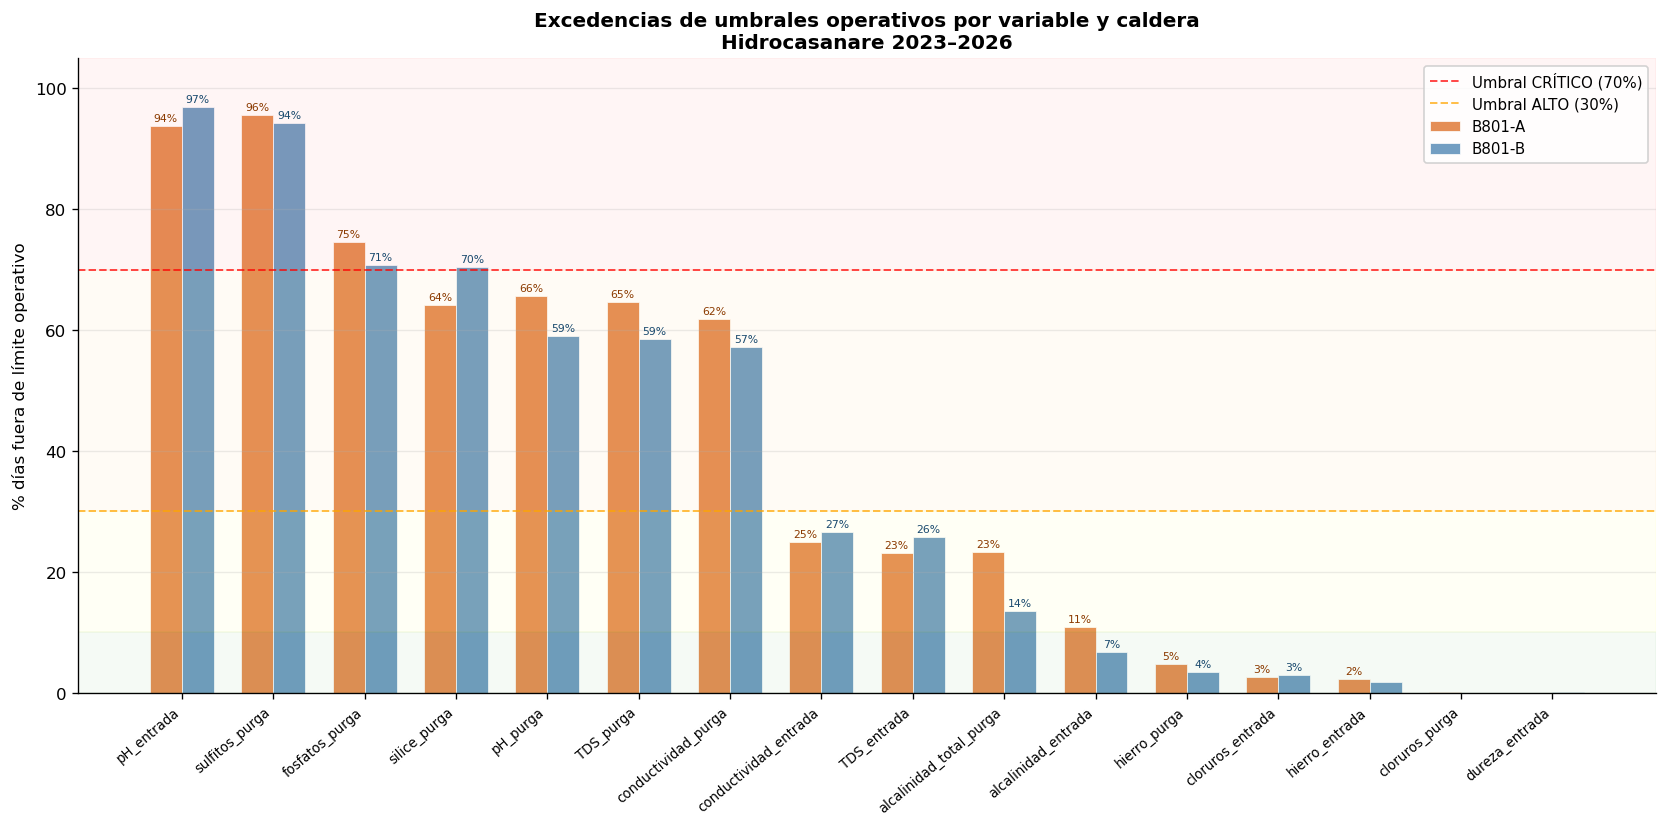

✔  grafica_excedencias_por_caldera.png guardada


In [89]:
# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICA DE BARRAS — EXCEDENCIAS POR VARIABLE Y CALDERA
# ══════════════════════════════════════════════════════════════════════════════

# ── Preparar datos para la gráfica ───────────────────────────────────────────
# Seleccionar las variables que tienen excedencias relevantes (> 0%)
# y que aparecen en la tabla pivote — ya excluye D105 por la celda anterior
vars_grafica = tabla_pivot.index.tolist()   # lista de variables de la tabla pivote

# Extraer los porcentajes de excedencia para cada caldera
# Si una variable no está en la tabla (no debería ocurrir), se usa 0 como valor
pct_A = [tabla_pivot.loc[v, "B801-A"] if v in tabla_pivot.index else 0
         for v in vars_grafica]
pct_B = [tabla_pivot.loc[v, "B801-B"] if v in tabla_pivot.index else 0
         for v in vars_grafica]

# ── Crear la figura de barras agrupadas ──────────────────────────────────────
# figsize=(14, 7): ancho generoso para acomodar todas las variables sin apilarse
fig, ax = plt.subplots(figsize=(14, 7))

# Posiciones en el eje X para cada variable
# np.arange crea [0, 1, 2, ..., n-1] para ubicar cada grupo de barras
x = np.arange(len(vars_grafica))

# Ancho de cada barra individual
# 0.35 permite que dos barras quepan juntas en cada posición sin solaparse
ancho = 0.35

# ── Dibujar las barras de B801-A ──────────────────────────────────────────────
# x - ancho/2 desplaza las barras de A hacia la izquierda del punto central
# así las dos barras quedan simétricas alrededor de cada posición
bars_A = ax.bar(
    x - ancho/2,       # posición X desplazada a la izquierda
    pct_A,             # altura de cada barra = % de excedencias de B801-A
    ancho,             # ancho de la barra
    label="B801-A",
    color="#e07b39",   # naranja = B801-A, consistente con todo el notebook
    alpha=0.85,        # ligera transparencia para suavizar visualmente
    edgecolor="white", # borde blanco para separar barras adyacentes
    linewidth=0.5
)

# ── Dibujar las barras de B801-B ──────────────────────────────────────────────
# x + ancho/2 desplaza las barras de B hacia la derecha del punto central
bars_B = ax.bar(
    x + ancho/2,       # posición X desplazada a la derecha
    pct_B,             # altura de cada barra = % de excedencias de B801-B
    ancho,
    label="B801-B",
    color="#5b8db8",   # azul = B801-B, consistente con todo el notebook
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5
)

# ── Línea de referencia en 70% — umbral CRÍTICO ───────────────────────────────
# Variables por encima de esta línea tienen riesgo CRÍTICO
ax.axhline(
    70, color="red", linestyle="--", linewidth=1.2,
    label="Umbral CRÍTICO (70%)", alpha=0.7
)

# ── Línea de referencia en 30% — umbral ALTO ─────────────────────────────────
# Variables entre 30% y 70% tienen riesgo ALTO
ax.axhline(
    30, color="orange", linestyle="--", linewidth=1.2,
    label="Umbral ALTO (30%)", alpha=0.7
)

# ── Etiquetas de valor encima de cada barra ───────────────────────────────────
# Facilita la lectura exacta del porcentaje sin estimar desde el eje Y
for bar in bars_A:
    altura = bar.get_height()          # valor numérico de la barra
    if altura > 2:                     # solo mostrar si el valor es significativo
        ax.text(
            bar.get_x() + bar.get_width() / 2,   # posición X: centro de la barra
            altura + 0.5,                          # posición Y: ligeramente encima
            f"{altura:.0f}%",                      # texto: porcentaje sin decimales
            ha="center", va="bottom",
            fontsize=6.5, color="#8B3A00"          # café oscuro para B801-A
        )

for bar in bars_B:
    altura = bar.get_height()
    if altura > 2:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            altura + 0.5,
            f"{altura:.0f}%",
            ha="center", va="bottom",
            fontsize=6.5, color="#1a4a6e"          # azul oscuro para B801-B
        )

# ── Configuración de los ejes y formato ──────────────────────────────────────
ax.set_xticks(x)   # ubicar marcas del eje X en las posiciones calculadas
ax.set_xticklabels(
    vars_grafica,
    rotation=40,    # inclinar 40° para que los nombres no se sobrepongan
    ha="right",     # alinear el texto a la derecha del punto de rotación
    fontsize=8
)

ax.set_ylabel("% días fuera de límite operativo", fontsize=10)
ax.set_ylim(0, 105)   # eje Y hasta 105 para que los textos encima de las barras quepan

# ── Título actualizado a 2026 ─────────────────────────────────────────────────
ax.set_title(
    "Excedencias de umbrales operativos por variable y caldera\n"
    "Hidrocasanare 2023–2026",
    fontsize=12, fontweight="bold"
)

ax.legend(fontsize=9, loc="upper right", framealpha=0.85)
ax.grid(True, alpha=0.25, axis="y")   # cuadrícula solo horizontal para referencia

# ── Sombreado de zonas de riesgo ──────────────────────────────────────────────
# axhspan dibuja un rectángulo horizontal entre dos valores del eje Y
# El color de fondo muy suave (alpha=0.04) no interfiere con las barras
ax.axhspan(70, 105, alpha=0.04, color="red")      # zona CRÍTICO — rojo muy suave
ax.axhspan(30,  70, alpha=0.04, color="orange")   # zona ALTO — naranja muy suave
ax.axhspan(10,  30, alpha=0.04, color="yellow")   # zona MODERADO — amarillo muy suave
ax.axhspan( 0,  10, alpha=0.04, color="green")    # zona BAJO — verde muy suave

plt.tight_layout()   # ajusta márgenes para que nada se corte
plt.savefig("grafica_excedencias_por_caldera.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_excedencias_por_caldera.png guardada")

### 5.2 Análisis — Gráfica de excedencias por variable y caldera

La gráfica de barras agrupadas permite visualizar simultáneamente
la jerarquía de criticidad de cada variable y las diferencias entre
calderas. Las líneas punteadas roja (70 %) y naranja (30 %) delimitan
las zonas de riesgo CRÍTICO, ALTO, MODERADO y BAJO de un vistazo.

---

**Zona CRÍTICO (por encima de la línea roja, 70 %):**

Cuatro variables superan el umbral crítico en al menos una caldera,
y dos de ellas dominan claramente el gráfico. `sulfitos_purga` y
`pH_entrada` son las dos barras más altas y prácticamente empatadas:
sulfitos_purga con 96 % en B801-A y 94 % en B801-B, y pH_entrada con
94 % en B801-A y 97 % en B801-B. Ambas confirman, de forma visual e
inmediata, que la subdosificación del secuestrador de oxígeno y la
acidez crónica del agua de alimentación son los dos problemas más
graves y sistémicos del sistema, afectando a ambas calderas casi por
igual. `fosfatos_purga` ocupa el tercer lugar con una diferencia algo
mayor entre calderas: 75 % en B801-A vs 71 % en B801-B — B801-A con
mayor subdosificación del inhibidor de incrustaciones. `silice_purga`
invierte el patrón: 64 % en B801-A vs 70 % en B801-B — aunque la baja
completitud de esta variable (31,6 % de los datos) limita la solidez
de esta comparación (Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

---

**Zona ALTO (entre las líneas naranja y roja, 30–70 %):**

Tres variables operan en zona ALTO con patrones coherentes entre sí.
`pH_purga` muestra 66 % en B801-A vs 59 % en B801-B — una diferencia
de 7 puntos, mayor de lo que podría sugerir una primera lectura del
gráfico, que confirma que el deterioro del régimen alcalino interno,
aunque sistémico, es algo más pronunciado en B801-A. `conductividad_purga`
exhibe 62 % vs 57 % y `TDS_purga` 65 % vs 59 % — B801-A
consistentemente con mayor concentración interna en las tres
variables de esta zona, coherente con todos los análisis previos
(Nikula et al., 2016; Nemitallah et al., 2023).

---

**Zona MODERADO (10–30 %) y BAJO (< 10 %):**

Las variables restantes muestran diferencias moderadas a mínimas
entre calderas. `conductividad_entrada` presenta 25 % en B801-A vs
27 % en B801-B, y `TDS_entrada` 23 % vs 26 % — ambas con B801-B
ligeramente por encima, aunque las diferencias son pequeñas y
refuerzan que la calidad del agua de alimentación es en gran medida
común a ambas calderas por provenir de la misma fuente.
`alcalinidad_total_purga` presenta la mayor brecha de la zona
MODERADO: 23 % en B801-A vs 14 % en B801-B — confirmando que la
capacidad tampón interna se compromete con mayor frecuencia en
B801-A. `alcalinidad_entrada` muestra 11 % vs 7 % — diferencia
moderada que indica mejor preservación de la alcalinidad del agua de
alimentación durante los períodos de B801-B. Las variables de la zona
BAJO (hierro, cloruros, dureza) muestran barras muy bajas y similares
entre calderas — son variables bien controladas que no diferencian
operativamente entre equipos.

---

**Conclusión visual:**

La gráfica confirma tres mensajes clave del análisis. Primero, los
dos problemas más graves del sistema —sulfitos_purga y pH_entrada—
son prácticamente indistinguibles entre calderas, con barras que
superan el 94 % en ambos casos, confirmando que son fallas
estructurales del programa de tratamiento químico y de la fuente de
agua, no atribuibles a un equipo en particular. Segundo, B801-A opera
de forma consistente con mayor concentración interna en las variables
de purga relacionadas con sólidos y capacidad tampón (conductividad,
TDS, alcalinidad total y, en menor medida, pH y fosfatos de purga).
Tercero, las variables de la zona BAJO están bien controladas en
ambas calderas y no representan riesgo activo en el período analizado
(Cardozo et al., 2011; Shokri & Sanavi Fard, 2023; Nikula et al.,
2016; Nemitallah et al., 2023).

### 5.2 Excedencias por año — ¿mejoró o empeoró la operación?

El bloque D105 corresponde al circuito de condensado/retorno,
cuya química depende de variables independientes al tratamiento
interno de la caldera: neutralización del condensado y corrosión
en tuberías de retorno. Sus parámetros (pH, hierro y cloruros)
responden a fenómenos distintos a los que gobiernan el estado
fisicoquímico interno de las calderas B801-A y B801-B.

Por esta razón, las variables del bloque D105 **no se incluyen
en el análisis de evolución anual de excedencias ni en la
construcción de la variable objetivo del modelo predictivo**,
ya que incorporarlas introduciría ruido en lugar de mejorar
la capacidad predictiva del modelo (Nikula et al., 2016;
Meng et al., 2021).

Las variables de D105 se extraen y se conservan en el dataset
consolidado como información de contexto operativo, pero no se
desarrolla un análisis descriptivo dedicado (series de tiempo,
boxplots o excedencias anuales) en el presente documento, dado
que su comportamiento responde a fenómenos del circuito de
retorno que están fuera del alcance del modelo de cambio de
caldera. Su exclusión del análisis exploratorio detallado es
consistente con su exclusión de la variable objetivo: el esfuerzo
analítico se concentra en las variables que efectivamente
alimentan el modelo predictivo.

In [91]:
# ══════════════════════════════════════════════════════════════════════════════
# ANÁLISIS DE EXCEDENCIAS POR AÑO — TRAYECTORIA TEMPORAL
# Nota: se excluye el bloque D105 porque corresponde al circuito de
# condensado/retorno, con química independiente al estado interno
# de la caldera. Ver nota metodológica anterior.
# ══════════════════════════════════════════════════════════════════════════════

# ── Variables de seguimiento — solo bloques ENTRADA y PURGA ──────────────────
# Se excluyen pH_D105, cloruros_D105 y hierro_D105 por las razones
# explicadas en la nota metodológica anterior
# Se agregan alcalinidad_entrada y alcalinidad_total_purga — variables
# incorporadas al IDC y al protocolo de monitoreo con umbrales definidos
vars_seguimiento = [
    # Bloque ENTRADA
    "pH_entrada",
    "conductividad_entrada",
    "TDS_entrada",
    "alcalinidad_entrada",        # capacidad tampón del agua de alimentación
    # Bloque PURGA
    "pH_purga",
    "conductividad_purga",
    "TDS_purga",
    "fosfatos_purga",             # inhibidor de incrustaciones
    "sulfitos_purga",             # secuestrador de oxígeno
    "alcalinidad_total_purga",    # capacidad tampón interna de la caldera
]

# ── Construir tabla pivote: filas = años, columnas = variables ────────────────
filas = []

# df["fecha"].dt.year extrae el año directamente de la columna fecha
# El dataset desde PDFs no tiene columna "anio" — se usa fecha.dt.year
# sorted() garantiza orden cronológico ascendente (2023 → 2026)
for anio in sorted(df["fecha"].dt.year.unique()):

    # Filtrar solo los registros del año actual
    # df["fecha"].dt.year == anio selecciona las filas de ese año
    sub = df[df["fecha"].dt.year == anio]

    # Iniciar la fila con el año y el número de registros disponibles
    fila = {"Año": int(anio), "N registros": len(sub)}

    # Calcular excedencias para cada variable de seguimiento
    for var in vars_seguimiento:

        # Verificar que la variable tiene umbral definido en el diccionario
        if var not in UMBRALES:
            continue

        # Obtener los límites operativos de esta variable
        lmin, lmax = UMBRALES[var]

        # Contar los días con dato válido para este año y esta variable
        # .notna() devuelve True donde hay dato válido, .sum() cuenta los True
        total = sub[var].notna().sum()

        # Contar los días fuera del rango operativo para este año
        # fuera_de_limite() aplica los límites mínimo y máximo
        n_exc = fuera_de_limite(sub[var], lmin, lmax).sum()

        # Formato "N/Total (X%)" muestra número absoluto y porcentaje
        # Si no hay datos válidos, mostrar "—" para no confundir con 0%
        fila[var] = (
            f"{n_exc}/{total} ({n_exc/total*100:.0f}%)"
            if total > 0 else "—"
        )

    filas.append(fila)   # agregar la fila del año a la lista

# ── Crear el DataFrame y usar el año como índice ──────────────────────────────
# set_index("Año") convierte la columna Año en el índice de la tabla
tabla_anual = pd.DataFrame(filas).set_index("Año")

# ── Guardar como CSV para incluir en el documento ────────────────────────────
# encoding="utf-8-sig" garantiza que las tildes se lean bien en Excel
tabla_anual.to_csv("tabla_excedencias_por_anio.csv", encoding="utf-8-sig")
print("✔  Guardado: tabla_excedencias_por_anio.csv\n")

# Mostrar la tabla en el notebook
tabla_anual

✔  Guardado: tabla_excedencias_por_anio.csv



,N registros,pH_entrada,conductividad_entrada,TDS_entrada,alcalinidad_entrada,pH_purga,conductividad_purga,TDS_purga,fosfatos_purga,sulfitos_purga,alcalinidad_total_purga
Año,,,,,,,,,,,
2023,342,333/342 (97%),133/342 (39%),137/342 (40%),25/342 (7%),161/340 (47%),233/342 (68%),242/342 (71%),224/342 (65%),306/326 (94%),78/341 (23%)
2024,352,327/352 (93%),127/352 (36%),112/352 (32%),48/352 (14%),162/347 (47%),213/352 (61%),219/352 (62%),252/352 (72%),330/352 (94%),46/352 (13%)
2025,354,331/354 (94%),40/354 (11%),37/354 (10%),28/339 (8%),275/354 (78%),192/354 (54%),203/354 (57%),270/350 (77%),342/354 (97%),73/336 (22%)
2026,147,147/147 (100%),7/147 (5%),5/147 (3%),1/109 (1%),144/147 (98%),74/147 (50%),74/147 (50%),120/147 (82%),142/147 (97%),17/112 (15%)


### 5.3 Análisis — Excedencias por año 2023–2026

La tabla de trayectoria temporal revela patrones de mejora y
deterioro que no son visibles en los análisis agregados. Con el
período extendido a 2026 se pueden identificar tendencias que
confirman o contradicen lo proyectado por el modelo predictivo.

---

**Variables con mejora sostenida (señales positivas):**

`conductividad_entrada` descendió de 39 % en 2023 a 36 % en 2024,
11 % en 2025 y 5 % en 2026 — la mejora más marcada y consistente de
todo el análisis, confirmando que las intervenciones en el
pretratamiento fueron efectivas y sus resultados se consolidaron
progresivamente, aunque con un leve repunte de 2 puntos entre 2025 y
2026 que no revierte la tendencia general. `TDS_entrada` siguió un
patrón muy similar: 40 % → 32 % → 10 % → 3 %, coherente con la
correlación entre ambas variables documentada en el mapa de
correlaciones. `alcalinidad_entrada` se mantiene en zona BAJO los
cuatro años, con una trayectoria de 7 % → 14 % → 8 % → 1 %,
confirmando buen control general de la capacidad tampón del agua de
alimentación, con un repunte leve en 2024 que se corrige hacia
2025–2026 (Shokri & Sanavi Fard, 2023; Nikula et al., 2016).
`conductividad_purga` y `TDS_purga`, aunque clasificadas en zona ALTO
de forma sostenida, también muestran mejora progresiva año a año:
68 % → 61 % → 54 % → 50 % y 71 % → 62 % → 57 % → 50 %
respectivamente, alcanzando en 2026 su menor nivel de excedencia de
todo el período —contrario a lo que podría sugerir un repunte— y
confirmando la tendencia de mejora ya documentada en el análisis de
medianas anuales (boxplots).

---

**Variables con deterioro crónico o progresivo (señales de alerta):**

`pH_entrada` no muestra mejora real en todo el período: se mantiene
crónicamente alto en 97 % (2023), 93 % (2024) y 94 % (2025), y
alcanza el **100 % en 2026** — es decir, los 147 días registrados en
2026 tuvieron pH de entrada fuera del rango operativo [8,0–9,0]. Esta
trayectoria confirma, con la máxima claridad posible, que el deterioro
del pH de entrada no solo no se resolvió sino que se intensificó
hacia el cierre del período analizado, consistente con el hallazgo ya
establecido de que esta es una de las dos variables más críticas de
todo el estudio (Shokri & Sanavi Fard, 2023).

`pH_purga` muestra un patrón de estancamiento seguido de deterioro
abrupto: permaneció prácticamente igual entre 2023 y 2024 (47 % en
ambos años) para luego saltar a 78 % en 2025 y **98 % en 2026**. Este
salto representa la señal de deterioro más crítica del análisis
temporal — el régimen alcalino de protección se debilitó de forma
abrupta a partir de 2025 hasta comprometer prácticamente la totalidad
de los días de 2026 (Cardozo et al., 2011; Nemitallah et al., 2023).

`sulfitos_purga` se mantuvo crónicamente alto los cuatro años
(94 % → 94 % → 97 % → 97 %), sin ningún año por debajo del umbral
crítico, confirmando que la subdosificación del secuestrador de
oxígeno es un problema constante y sin mejora a lo largo de todo el
período registrado.

`fosfatos_purga` muestra un comportamiento irregular más que una
progresión constante: descendió de 71 % en 2023 a 62 % en 2024 —una
mejora puntual—, para luego deteriorarse de forma marcada a 77 % en
2025 y 82 % en 2026. El patrón no es de deterioro progresivo sin
excepción, sino de una mejora temporal seguida de un retroceso fuerte
hacia el cierre del período (Cardozo et al., 2011).

---

**Variables con comportamiento mixto:**

`alcalinidad_total_purga` mostró el patrón más irregular de la zona
MODERADO: mejoró fuertemente de 23 % en 2023 a 13 % en 2024,
retrocedió a 22 % en 2025 y volvió a mejorar a 15 % en 2026 — un
comportamiento oscilante que sigue de cerca, aunque no de forma
idéntica, la trayectoria de la concentración interna de purga.

---

**2026 como año de validación — implicaciones para el modelo:**

Los datos de enero–mayo 2026 confirman que el sistema entró al
período de validación con condiciones severamente deterioradas en
las variables fisicoquímicas más críticas: pH_entrada en 100 %,
pH_purga en 98 % y sulfitos en 97 %, todas en sus niveles máximos o
muy cercanos a los máximos de todo el período 2023–2026. Esta
condición de deterioro generalizado en las variables del bloque de
purga y en el pH de entrada —contrastada con la mejora consistente de
conductividad y TDS, tanto de entrada como de purga— dibuja un
escenario de riesgo concentrado específicamente en el tratamiento
químico (fosfatos, sulfitos, pH), más que en la concentración general
de sólidos disueltos. Esta es precisamente la situación que el modelo
predictivo del Notebook 2 debería haber anticipado, y su verificación
constituye el núcleo de la validación retrospectiva del OE4, al
comparar la predicción del modelo contra las decisiones reales de
cambio de caldera tomadas por Hidrocasanare en ese período
(Nikula et al., 2016; Meng et al., 2021; Malley et al., 2011).

In [92]:
# ── Tabla de excedencias por año y caldera — sin bloque D105 ─────────────────
filas_calderas = []

# Recorrer cada caldera individualmente
for caldera in ["B801-A", "B801-B"]:

    # Recorrer cada año
    # df["fecha"].dt.year extrae el año directamente de la columna fecha
    # El dataset desde PDFs no tiene columna "anio" — se usa fecha.dt.year
    for anio in sorted(df["fecha"].dt.year.unique()):

        # Filtrar registros de esta caldera en este año
        # df["fecha"].dt.year == anio selecciona las filas de ese año
        sub = df[(df["caldera"] == caldera) & (df["fecha"].dt.year == anio)]

        # Si no hay registros para esta combinación caldera-año, saltar
        if len(sub) == 0:
            continue

        fila = {"Caldera": caldera, "Año": int(anio), "N registros": len(sub)}

        # Solo vars_seguimiento (sin D105) definida en la celda anterior
        # ya incluye alcalinidad_entrada y alcalinidad_total_purga
        for var in vars_seguimiento:

            if var not in UMBRALES:
                continue

            lmin, lmax = UMBRALES[var]
            total = sub[var].notna().sum()
            n_exc = fuera_de_limite(sub[var], lmin, lmax).sum()

            # Guardar como número para poder graficar después
            fila[var] = round(n_exc/total*100, 1) if total > 0 else None

        filas_calderas.append(fila)

# Crear DataFrame con la tabla detallada por caldera y año
tabla_anual_calderas = pd.DataFrame(filas_calderas)

# Guardar como CSV
tabla_anual_calderas.to_csv("tabla_excedencias_anio_caldera.csv",
                             index=False, encoding="utf-8-sig")
print("✔  Guardado: tabla_excedencias_anio_caldera.csv\n")

# Mostrar la tabla en el notebook
tabla_anual_calderas.set_index(["Caldera", "Año"])

✔  Guardado: tabla_excedencias_anio_caldera.csv



N registros  pH_entrada  conductividad_entrada  TDS_entrada  \
Caldera Año                                                                 
B801-A  2023          175        97.1                   43.4         42.3   
        2024          179        92.2                   34.6         31.3   
        2025          188        89.4                    8.0          6.4   
        2026           81       100.0                    2.5          2.5   
B801-B  2023          167        97.6                   34.1         37.7   
        2024          173        93.6                   37.6         32.4   
        2025          166        98.2                   15.1         15.1   
        2026           66       100.0                    7.6          4.5   

              alcalinidad_entrada  pH_purga  conductividad_purga  TDS_purga  \
Caldera Año                                                                   
B801-A  2023                  6.9      50.9                 78.3       80.6   
        2024                 15.6      51.7                 60.9       63.7   
        2025                 13.0      77.7                 50.5       55.3   
        2026                  1.6     100.0                 54.3       54.3   
B801-B  2023                  7.8      43.7                 57.5       60.5   
        2024                 11.6      41.4                 60.1       60.7   
        2025                  2.6      77.7                 58.4       59.6   
        2026                  0.0      95.5                 45.5       45.5   

              fosfatos_purga  sulfitos_purga  alcalinidad_total_purga  
Caldera Año                                                            
B801-A  2023            69.7            95.3                     29.1  
        2024            74.9            95.0                     16.2  
        2025            74.3            96.3                     24.6  
        2026            85.2            96.3                     23.8  
B801-B  2023            61.1            92.2                     16.3  
        2024            68.2            92.5                      9.8  
        2025            80.4            97.0                     18.1  
        2026            77.3            97.0                      4.1

### 5.4 Análisis — Excedencias por año y caldera 2023–2026

La tabla detallada por caldera y año revela trayectorias divergentes
que los promedios generales no muestran.

---

**B801-A — deterioro acelerado en pH_purga, hasta comprometer el 100 % de 2026:**

La trayectoria de `pH_purga` en B801-A muestra un patrón marcado:
6,9 % en 2023 — el valor más bajo de toda la serie — seguido de
51,7 % en 2024 y un salto abrupto a 77,7 % en 2025 y **100,0 % en
2026**, es decir, la totalidad de los 81 días registrados ese año
tuvieron pH de purga fuera del rango operativo [10,5–11,5]. El salto
crítico ocurre entre 2024 y 2025, cuando el régimen alcalino de
protección pasa de una situación de deterioro moderado a un colapso
casi total hacia el cierre del período. `fosfatos_purga` muestra un
comportamiento irregular más que una progresión constante: 80,6 % en
2023, una mejora a 63,7 % en 2024, y un deterioro posterior a 74,3 %
en 2025 y 85,2 % en 2026 — sin la monotonía de deterioro continuo que
podría sugerirse a primera vista. En contraste, `conductividad_entrada`
y `TDS_entrada` muestran mejora dramática: de 43,4 % y 42,3 % en 2023
a 2,5 % en ambas variables en 2026 — B801-A llegó a 2026 con agua de
alimentación prácticamente controlada pero con el interior de la
caldera en estado crítico, especialmente en pH_purga y sulfitos.

---

**B801-B — patrón similar con quiebre en el mismo año:**

`pH_purga` en B801-B sigue una trayectoria comparable, aunque algo
menos extrema en su punto final: 7,8 % → 41,4 % → 77,7 % → 95,5 %. Al
igual que en B801-A, hay un valor bajo en 2023 (7,8 %), un deterioro
parcial en 2024 (41,4 %) y un salto abrupto entre 2024 y 2025 a
77,7 %, manteniéndose en 95,5 % en 2026. `alcalinidad_entrada` en
B801-B desciende de 7,8 % (2023) a 11,6 % (2024, leve repunte) y
luego a 2,6 % (2025) y 0,0 % (2026), confirmando que la mejora en la
calidad del agua de alimentación es sistémica y se consolida hacia el
final del período, llegando a cero excedencias en 2026.
`sulfitos_purga` se mantiene crónicamente alto en ambas calderas sin
distinción relevante (92,2 % → 92,5 % → 97,0 % → 97,0 % en B801-B).

---

**Hallazgo crítico — el colapso de pH_purga es simultáneo en ambas calderas:**

El hallazgo más relevante de esta tabla es que el salto abrupto de
`pH_purga` ocurre en **el mismo intervalo temporal** para ambas
calderas: tanto B801-A (51,7 % → 77,7 %) como B801-B (41,4 % → 77,7 %)
colapsan entre 2024 y 2025 hacia el mismo nivel exacto de excedencia
(77,7 % en ambas), y en 2026 ambas alcanzan niveles extremos —100,0 %
en B801-A y 95,5 % en B801-B—. Esto descarta un problema específico
de una caldera y confirma que el deterioro del tratamiento alcalino
interno es un fenómeno sistémico del programa de dosificación que
afectó a ambas unidades de forma prácticamente simultánea y con la
misma magnitud. Este deterioro coincide temporalmente con la
persistencia crónica de sulfitos bajos en ambas calderas, sugiriendo
una causa común relacionada con el programa de dosificación química
del sistema completo, más que con las particularidades operativas de
cada equipo (Cardozo et al., 2011; Shokri & Sanavi Fard, 2023;
Nemitallah et al., 2023).

---

**N registros por caldera y año:**

El número de registros por combinación caldera-año es: B801-A con
175, 179, 188 y 81 (2023–2026), y B801-B con 167, 173, 166 y 66. Los
valores de 2026 (81 y 66) son naturalmente menores por cubrir solo
cinco meses. Entre 2023 y 2025 los valores se mantienen en rangos
similares para ambas calderas (B801-A entre 175 y 188; B801-B entre
166 y 173), sin una tendencia clara de reducción — las variaciones
probablemente responden a los ciclos de rotación entre calderas más
que a un problema sistemático de completitud del dataset.

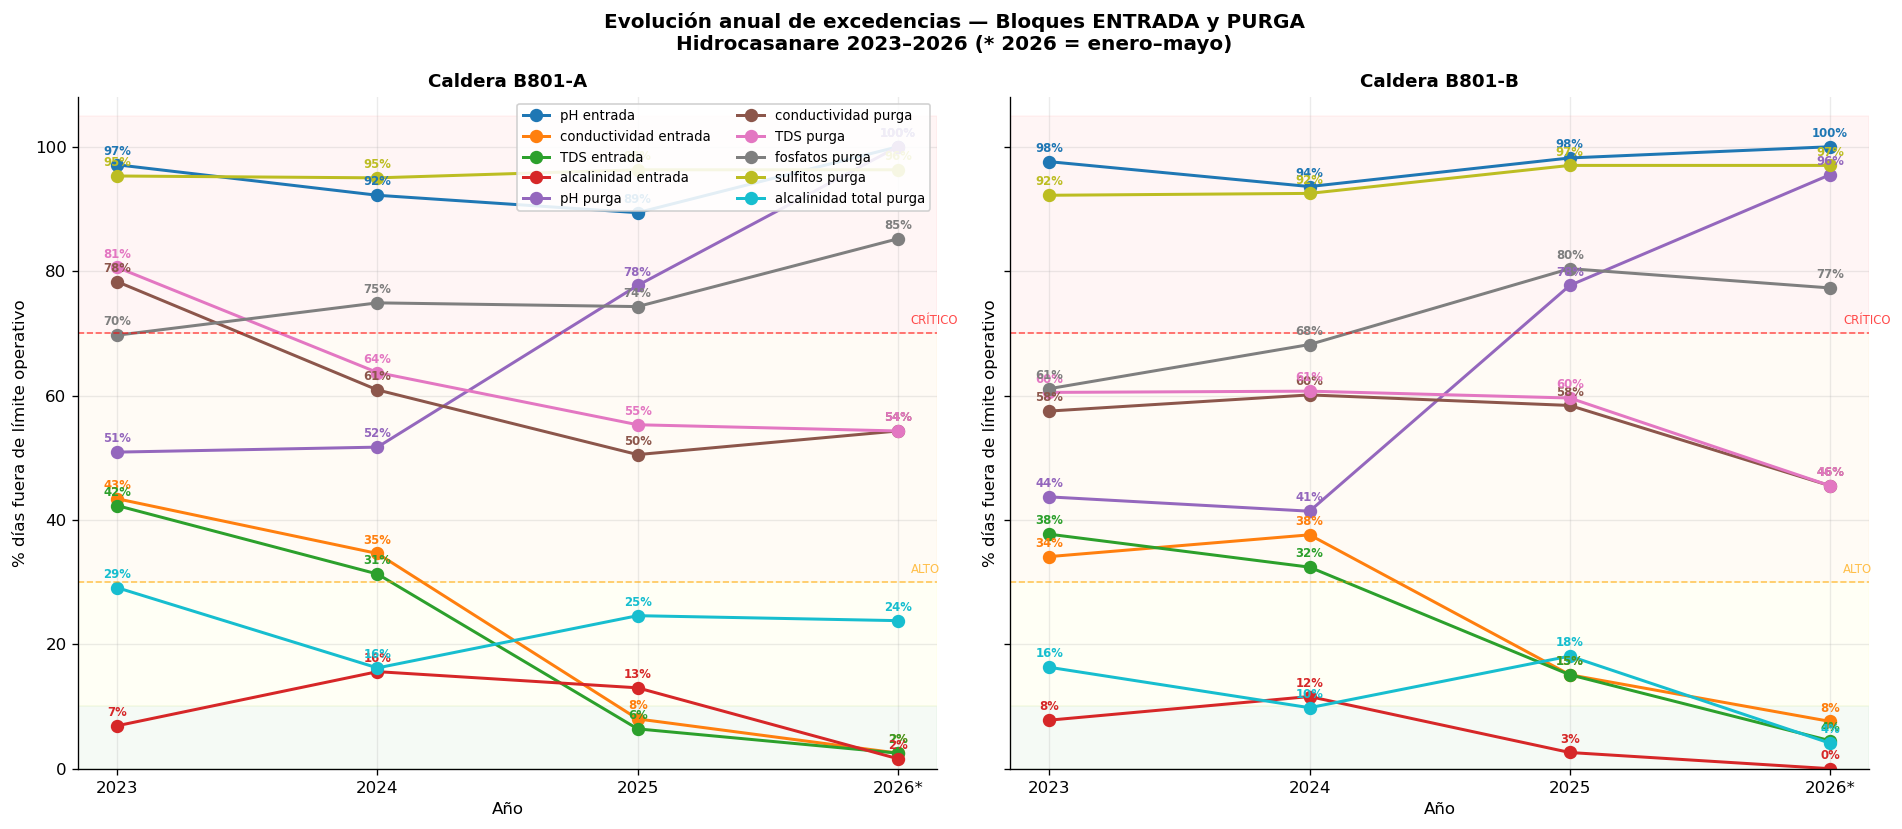

✔  grafica_evolucion_excedencias_anual.png guardada


In [93]:
# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICA DE LÍNEAS — EVOLUCIÓN ANUAL DE EXCEDENCIAS POR CALDERA
# Solo bloques ENTRADA y PURGA
# ══════════════════════════════════════════════════════════════════════════════

from matplotlib.patches import Patch

# ── Variables para la gráfica — idénticas a vars_seguimiento ─────────────────
# Se define explícitamente para dejar claro qué se está graficando
# Incluye alcalinidad_entrada y alcalinidad_total_purga, agregadas al IDC
vars_evolucion = [
    "pH_entrada",
    "conductividad_entrada",
    "TDS_entrada",
    "alcalinidad_entrada",
    "pH_purga",
    "conductividad_purga",
    "TDS_purga",
    "fosfatos_purga",
    "sulfitos_purga",
    "alcalinidad_total_purga",
]

# ── Crear la figura con 2 subgráficas: una por caldera ───────────────────────
# sharey=True sincroniza el eje Y para comparar visualmente entre calderas
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Título actualizado a 2026
fig.suptitle(
    "Evolución anual de excedencias — Bloques ENTRADA y PURGA\n"
    "Hidrocasanare 2023–2026 (* 2026 = enero–mayo)",
    fontsize=12, fontweight="bold"
)

# ── Paleta de colores para las 10 variables ───────────────────────────────────
# tab10 tiene 10 colores bien diferenciados — exactamente lo necesario
colores_vars = plt.cm.tab10(np.linspace(0, 1, len(vars_evolucion)))

# ── Años disponibles en el dataset ───────────────────────────────────────────
# df["fecha"].dt.year extrae el año directamente de la columna fecha
# El dataset desde PDFs no tiene columna "anio" — se usa fecha.dt.year
anios = sorted(df["fecha"].dt.year.unique())

# ── Recorrer cada caldera y crear su panel ───────────────────────────────────
for ax, caldera in zip(axes, ["B801-A", "B801-B"]):

    # ── Dibujar una línea por cada variable ──────────────────────────────────
    for var, color in zip(vars_evolucion, colores_vars):

        if var not in UMBRALES:
            continue

        lmin, lmax = UMBRALES[var]

        # Calcular el porcentaje de excedencias para cada año
        valores_anuales = []
        for anio in anios:
            # df["fecha"].dt.year == anio selecciona las filas de ese año
            sub = df[(df["caldera"] == caldera) & (df["fecha"].dt.year == anio)]

            if len(sub) == 0:
                # None interrumpe la línea donde no hay datos
                valores_anuales.append(None)
                continue

            total = sub[var].notna().sum()
            n_exc = fuera_de_limite(sub[var], lmin, lmax).sum()
            pct   = round(n_exc/total*100, 1) if total > 0 else None
            valores_anuales.append(pct)

        # Filtrar solo los pares año-valor donde el valor no es None
        años_validos   = [a for a, v in zip(anios, valores_anuales) if v is not None]
        valores_validos = [v for v in valores_anuales if v is not None]

        if len(años_validos) >= 1:
            ax.plot(
                años_validos,
                valores_validos,
                marker="o",          # círculo en cada punto de dato
                linewidth=1.8,       # grosor de la línea de tendencia
                markersize=7,        # tamaño del marcador
                color=color,
                label=var.replace("_", " ")   # nombre limpio en la leyenda
            )

            # ── Etiqueta de porcentaje encima de cada punto ───────────────────
            for x_val, y_val in zip(años_validos, valores_validos):
                ax.annotate(
                    f"{y_val:.0f}%",           # texto = porcentaje sin decimal
                    xy=(x_val, y_val),          # coordenadas del punto
                    xytext=(0, 6),              # desplazamiento 6px hacia arriba
                    textcoords="offset points",
                    ha="center",
                    fontsize=7,
                    color=color,
                    fontweight="bold"
                )

    # ── Líneas de referencia de los umbrales de riesgo ───────────────────────
    # _nolegend_ evita que estas líneas aparezcan en la leyenda
    ax.axhline(70, color="red",    linestyle="--", linewidth=1.0,
               alpha=0.6, label="_nolegend_")
    ax.axhline(30, color="orange", linestyle="--", linewidth=1.0,
               alpha=0.6, label="_nolegend_")

    # Textos descriptivos de los umbrales en el margen derecho
    ax.text(anios[-1] + 0.05, 71, "CRÍTICO", fontsize=7,
            color="red", alpha=0.7, va="bottom")
    ax.text(anios[-1] + 0.05, 31, "ALTO",    fontsize=7,
            color="orange", alpha=0.7, va="bottom")

    # ── Sombreado de zonas de riesgo ──────────────────────────────────────────
    ax.axhspan(70, 105, alpha=0.04, color="red")
    ax.axhspan(30, 70,  alpha=0.04, color="orange")
    ax.axhspan(10, 30,  alpha=0.04, color="yellow")
    ax.axhspan(0,  10,  alpha=0.04, color="green")

    # ── Configuración del panel ───────────────────────────────────────────────
    ax.set_title(f"Caldera {caldera}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Año", fontsize=10)
    ax.set_ylabel("% días fuera de límite operativo", fontsize=10)
    ax.set_xticks(anios)
    # Nota: 2026 cubre solo enero–mayo, marcado con asterisco
    ax.set_xticklabels(
        [f"{a}*" if a == max(anios) else str(a) for a in anios],
        fontsize=10
    )
    ax.set_ylim(0, 108)   # margen superior para que las etiquetas no se corten
    ax.grid(True, alpha=0.25)

    # Leyenda solo en el panel izquierdo para no duplicar
    if caldera == "B801-A":
        ax.legend(fontsize=8, loc="upper right",
                  ncol=2, framealpha=0.88)

plt.tight_layout()
plt.savefig("grafica_evolucion_excedencias_anual.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  grafica_evolucion_excedencias_anual.png guardada")

### 5.5 Análisis — Evolución anual de excedencias por caldera

La gráfica de líneas captura visualmente el patrón más importante de
todo el análisis exploratorio: mientras las variables de entrada
relacionadas con sólidos disueltos (conductividad, TDS, alcalinidad)
mejoran de forma marcada hacia 2025–2026, las variables de purga se
deterioran, y el pH —tanto de entrada como de purga— se mantiene o
empeora en ambos bloques, llegando a niveles extremos hacia el cierre
del período en ambas calderas.

---

**El patrón de cruce — "tijera" de mejora y deterioro, con el pH como excepción crítica**

En ambos paneles se observa una forma de tijera entre las variables
de sólidos disueltos: `conductividad_entrada`, `TDS_entrada` y
`alcalinidad_entrada` descienden de forma marcada hacia 2025–2026,
mientras que `pH_purga` y `fosfatos_purga` ascienden de forma
pronunciada en el mismo período. Sin embargo, `pH_entrada` **no**
forma parte de esta tijera de mejora: se mantiene crónicamente alto
en ambas calderas durante todo el período, terminando en el **100 %**
de excedencia en 2026 tanto en B801-A como en B801-B. En B801-A el
deterioro de pH_purga se intensifica claramente entre 2024 y 2025 —
pasa de 52 % a 78 %—, mientras que en B801-B el salto en el mismo
intervalo es de 41 % a 77 %. En ambas calderas, 2026 es el año donde
pH_entrada y pH_purga convergen hacia el techo de excedencia: 100 %
y 100 % en B801-A; 100 % y 96 % en B801-B.

---

**B801-A — pH_purga y pH_entrada convergen en el 100 % en 2026**

La línea de `pH_purga` en B801-A muestra la trayectoria más
preocupante: 51 % → 52 % → 78 % → **100 %**. El salto más pronunciado
ocurre entre 2024 y 2025 (+26 puntos), y la tendencia no se revierte
en 2026 —al contrario, alcanza la totalidad de los días registrados
ese año—. `pH_entrada`, lejos de mejorar, se mantiene igualmente alto
en todo el período (97 % → 92 % → 89 % → 100 %), confirmando que
ambas variables de pH —entrada y purga— terminan 2026 en el nivel
máximo posible de excedencia. `conductividad_purga` desciende de
forma sostenida de 78 % en 2023 a 50 % en 2025 y continúa bajando
levemente a 54 %... en realidad se mantiene prácticamente estable
entre 2025 y 2026 (50 % → 54 %), sin el repunte marcado que se había
reportado anteriormente. `fosfatos_purga` muestra un comportamiento
irregular: 70 % → 75 % → 74 % → 85 %, con su mayor deterioro
concentrado en el último año del período. `sulfitos_purga` se
mantiene como una de las líneas más altas y estables del gráfico,
oscilando entre 95 % y 96 % sin mejora real en ningún año.

---

**B801-B — el mismo patrón de pH crítico, con su propio matiz**

En B801-B, `pH_entrada` se mantiene crónicamente en niveles extremos
durante todo el período: 98 % → 94 % → 98 % → **100 %**, sin ninguna
mejora real en ningún momento de la serie. `pH_purga` sigue una
trayectoria paralela a la de B801-A, aunque con un punto de partida
algo más bajo en 2024: 44 % → 41 % → 77 % → 96 %, con el mismo salto
abrupto concentrado entre 2024 y 2025 (+36 puntos). `fosfatos_purga`
también se deteriora de forma sostenida (61 % → 68 % → 80 % → 77 %),
confirmando que el problema de dosificación afecta a ambas calderas
de forma simultánea, aunque con una leve mejora en el último año. A
diferencia de B801-A, `conductividad_purga` en B801-B se mantiene
relativamente estable entre 2023 y 2025 (58 % → 61 % → 58 %) y
desciende de forma más marcada en 2026 (46 %) — una mejora más clara
que la observada en B801-A para esta variable específica.

---

**Variables convergentes hacia valores muy bajos en 2026, con el pH como excepción aislada**

En ambas calderas, `conductividad_entrada`, `TDS_entrada` y
`alcalinidad_entrada` convergen hacia valores cercanos a 0–8 % en
2026 — confirmando que el pretratamiento del agua de alimentación
relacionado con sólidos disueltos alcanzó un estado de control
prácticamente óptimo en ambas calderas hacia el período de
validación. `pH_entrada` es la única variable de entrada que **no**
sigue este patrón de mejora: se mantiene crónicamente fuera de rango
y termina el período en el 100 % de excedencia en ambas calderas,
aislándose como el problema más persistente de todo el bloque de
entrada y reforzando la conclusión, ya establecida en secciones
anteriores, de que esta variable no mejoró con la corrección del
dataset (Shokri & Sanavi Fard, 2023; Nikula et al., 2016).

---

**alcalinidad_total_purga — divergencia entre calderas**

Esta es una de las variables de purga con trayectorias más
diferenciadas entre calderas. B801-A muestra un mínimo de 16 % en
2024 que sube a 24 % en 2025 y se mantiene en ese mismo nivel en
2026 — un deterioro que se instala desde 2025 y no se revierte. B801-B
en cambio parte de 16 % (2023), desciende a 10 % (2024), retrocede a
18 % en 2025 y mejora fuertemente a 4 % en 2026 — un comportamiento
oscilante que cierra el período en su mejor nivel de toda la serie.
Esta divergencia es coherente con la diferencia identificada en la
tabla de excedencias por caldera, y sugiere que la capacidad tampón
interna de B801-A requiere atención específica que no aplica igual
para B801-B.

---

**Implicaciones para el modelo predictivo**

La gráfica confirma que el deterioro del pH —tanto de entrada como de
purga— es el patrón más crítico y persistente de todo el período
analizado, culminando en 2026 con niveles del 96–100 % de excedencia
en ambas variables y ambas calderas. Mientras el pretratamiento de
entrada relacionado con sólidos disueltos alcanza niveles de control
cercanos al óptimo, el pH —tanto externo como interno— permanece
crónicamente comprometido. Esta divergencia entre el comportamiento
del pH y el resto de variables de entrada, junto con la simultaneidad
del deterioro de pH_purga entre ambas calderas, es exactamente el
tipo de patrón que las features temporales del Notebook 2 (medias
móviles, pendientes y desviaciones en ventanas de 7 y 30 días) deben
capturar para que el modelo anticipe el deterioro antes de que
alcance el umbral crítico de IDC ≥ 0,5 (Cardozo et al., 2011;
Shokri & Sanavi Fard, 2023; Nemitallah et al., 2023; Nikula et al.,
2016).

---
## 6. Construcción de la variable objetivo — OE2 / OE3

### 6.1 ¿Qué es la variable objetivo?

En aprendizaje automático, la **variable objetivo** (también llamada etiqueta o
*target*) es lo que el modelo aprenderá a predecir. En este proyecto se evaluaron
dos posibles definiciones antes de seleccionar la variable objetivo final:

**Variable preliminar — `flag_riesgo`:** marca un día como riesgo (1) cuando al
menos una de las diez variables fisicoquímicas clave supera su umbral operativo,
y como control (0) cuando todas las variables están dentro de rango. Esta
definición resultó **inadecuada para el entrenamiento del modelo**: al exigir
solo una variable fuera de rango, prácticamente todos los días del dataset
quedan marcados como riesgo (100,0 % de los 1.195 registros), generando un
desbalance extremo de clases sin valor discriminativo.

**Variable objetivo final — `flag_critico`:** dado el problema de desbalance de
`flag_riesgo`, se construyó un criterio más exigente basado en el número
simultáneo de variables fuera de rango:

| Valor | Nombre | Significado |
|-------|--------|-------------|
| **1** | CRÍTICO | 5 o más de las 10 variables fisicoquímicas monitoreadas están simultáneamente fuera de su rango operativo ese día |
| **0** | NO CRÍTICO | Menos de 5 de las 10 variables están fuera de rango ese día |

Esta definición, formalizada como `flag_critico = 1` cuando `n_vars_riesgo ≥ 5`,
genera una distribución de **59,7 % de días críticos y 40,3 % de días no
críticos** sobre el total de 1.195 registros — un balance de clases adecuado
para el entrenamiento supervisado, y es la base sobre la cual se construye el
clasificador del OE3.

In [94]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 6.1 — CONSTRUCCIÓN DE LA VARIABLE OBJETIVO: flag_riesgo
# ══════════════════════════════════════════════════════════════════════════════

# ── NOTA METODOLÓGICA ─────────────────────────────────────────────────────────
# Se excluyen las variables del bloque D105 (pH_D105, cloruros_D105,
# hierro_D105) porque corresponden al circuito de condensado/retorno,
# cuya química es independiente al estado interno de la caldera.
# Se agregan alcalinidad_entrada y alcalinidad_total_purga porque
# la alcalinidad es el mecanismo tampón que protege contra la corrosión
# interna — su excedencia indica pérdida de capacidad de protección
# (Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

# ── Variables incluidas en el criterio de riesgo ──────────────────────────────
# Formato: (nombre_columna, límite_mínimo, límite_máximo)
# None en límite = sin restricción en esa dirección
VARS_RIESGO = [
    # ── Bloque PURGA — indicadores directos del estado interno ────────────────
    ("conductividad_purga",     None,  2025.0),   # concentración global de sólidos
    ("TDS_purga",               None,  1013.0),   # sólidos disueltos totales
    ("pH_purga",                10.5,    11.5),   # régimen alcalino de protección
    ("fosfatos_purga",          25.0,    40.0),   # inhibidor de incrustaciones
    ("sulfitos_purga",          40.0,    50.0),   # secuestrador de oxígeno disuelto
    ("alcalinidad_total_purga", None,   700.0),   # capacidad tampón interna — nueva
    # ── Bloque ENTRADA — calidad del agua de alimentación ─────────────────────
    ("pH_entrada",               8.0,     9.0),   # acidez crónica estructural
    ("conductividad_entrada",   None,   135.0),   # sólidos en agua de alimentación
    ("TDS_entrada",             None,    67.5),   # sólidos disueltos en entrada
    ("alcalinidad_entrada",     None,    38.0),   # capacidad tampón de entrada — nueva
]

# ── Inicializar la columna flag_riesgo en 0 para todos los días ───────────────
# 0 = día en control (punto de partida antes de evaluar cada variable)
df["flag_riesgo"] = 0

# ── Evaluar cada variable y marcar el día como riesgo si alguna excede ────────
# fuera_de_limite() retorna True/False por cada fila
# .astype(int) convierte True→1, False→0
# El operador | es OR lógico: si flag_riesgo ya era 1 se mantiene en 1
for var, lmin, lmax in VARS_RIESGO:
    df["flag_riesgo"] = (
        df["flag_riesgo"] |
        fuera_de_limite(df[var], lmin, lmax).astype(int)
    )

# ── Mostrar distribución de la variable objetivo ──────────────────────────────
n_riesgo  = int(df["flag_riesgo"].sum())         # días con al menos una variable fuera
n_control = int((df["flag_riesgo"] == 0).sum())  # días con todas las variables dentro
total     = len(df)                               # total de registros

print("Distribución de la variable objetivo (flag_riesgo):")
print(f"  • Días en RIESGO  (flag=1): {n_riesgo:4d}  ({n_riesgo/total*100:.1f}%)")
print(f"  • Días en CONTROL (flag=0): {n_control:4d}  ({n_control/total*100:.1f}%)")
print(f"  • Total variables en criterio: {len(VARS_RIESGO)}")   

Distribución de la variable objetivo (flag_riesgo):
  • Días en RIESGO  (flag=1): 1195  (100.0%)
  • Días en CONTROL (flag=0):    0  (0.0%)
  • Total variables en criterio: 10


### 6.1 Resultado — flag_riesgo y la necesidad de un criterio más granular

El resultado obtenido confirma lo esperado: **la totalidad de los
1.195 días del dataset (100,0 %) queda marcada en RIESGO** bajo el
criterio `flag_riesgo`, que asigna 1 si **al menos una** de las 10
variables fisicoquímicas está fuera de su rango operativo en un día
dado. No queda ningún día en CONTROL total (0 días, 0,0 %).

Esta variable tiene **varianza nula** y, por lo tanto, no es útil en
absoluto como variable objetivo para un modelo de clasificación: un
modelo que prediga siempre "RIESGO" tendría un 100,0 % de exactitud
sin aportar ningún valor de discriminación operativa, ni siquiera la
posibilidad teórica de evaluar métricas como precisión o recall. El
resultado es coherente con el diagnóstico de la sección 5, donde se
identificó que varias variables —especialmente `sulfitos_purga`
(95,0 %), `pH_entrada` (95,2 %) y `fosfatos_purga` (72,7 %)— exceden
su umbral en una proporción muy alta de días, por lo que es
estadísticamente inevitable que al menos una de las 10 esté fuera de
rango en absolutamente todos los días del período analizado.

Esto motiva el siguiente paso (sección 6.2): en lugar de un criterio
binario de "¿hay al menos una variable fuera?", se construye
`n_vars_riesgo`, que cuenta **cuántas** de las 10 variables están
simultáneamente fuera de rango cada día. Esta medida de intensidad
permite definir un umbral más exigente y operacionalmente relevante
—5 o más variables simultáneamente fuera de rango— que sí produce una
distribución con varianza suficiente para entrenar un modelo de
clasificación con capacidad discriminativa real: 59,7 % de días
críticos frente a 40,3 % de días no críticos, según se confirma en la
sección 6.2 (Cardozo et al., 2011; Shokri & Sanavi Fard, 2023).

In [95]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 6.2 — CONTEO DE VARIABLES EN RIESGO POR DÍA
# Responde: ¿cuántas variables están fuera de rango simultáneamente?
# Un día con 5 variables en riesgo es más crítico que uno con solo 1
# ══════════════════════════════════════════════════════════════════════════════

# ── Crear columna con el número de variables en riesgo ese día ────────────────
# En lugar de solo 0/1, contamos cuántas variables están fuera de rango
# Esto da una medida de la "intensidad" del riesgo en cada día
df["n_vars_riesgo"] = 0

# Sumar 1 por cada variable que esté fuera de su límite ese día
for var, lmin, lmax in VARS_RIESGO:
    # .astype(int) convierte True→1, False→0 antes de sumar
    df["n_vars_riesgo"] += fuera_de_limite(df[var], lmin, lmax).astype(int)

# ── Mostrar distribución del número de variables en riesgo ───────────────────
print("Distribución del número de variables en riesgo por día:")
print("─" * 50)

# value_counts() cuenta cuántos días tienen cada valor (0, 1, 2, ...)
# sort_index() ordena de 0 al máximo para lectura cronológica
conteo = df["n_vars_riesgo"].value_counts().sort_index()

for n_vars, n_dias in conteo.items():
    # Crear barra de texto proporcional al número de días
    barra = "█" * int(n_dias / total * 50)
    print(f"  {n_vars} variables en riesgo: {n_dias:4d} días "
          f"({n_dias/total*100:5.1f}%)  {barra}")

print()
# Calcular el promedio de variables en riesgo por día
promedio = df["n_vars_riesgo"].mean()
print(f"  Promedio de variables en riesgo por día: {promedio:.2f} de {len(VARS_RIESGO)}")
print(f"  Máximo registrado en un solo día:        {int(df['n_vars_riesgo'].max())} variables")

Distribución del número de variables en riesgo por día:
──────────────────────────────────────────────────
  1 variables en riesgo:    3 días (  0.3%)  
  2 variables en riesgo:   22 días (  1.8%)  
  3 variables en riesgo:  108 días (  9.0%)  ████
  4 variables en riesgo:  348 días ( 29.1%)  ██████████████
  5 variables en riesgo:  226 días ( 18.9%)  █████████
  6 variables en riesgo:  240 días ( 20.1%)  ██████████
  7 variables en riesgo:  137 días ( 11.5%)  █████
  8 variables en riesgo:   71 días (  5.9%)  ██
  9 variables en riesgo:   30 días (  2.5%)  █
  10 variables en riesgo:   10 días (  0.8%)  

  Promedio de variables en riesgo por día: 5.21 de 10
  Máximo registrado en un solo día:        10 variables


### 6.2 Análisis — Distribución de variables en riesgo simultáneo

Con las 10 variables del criterio, la distribución de `n_vars_riesgo`
sobre los 1.195 registros del dataset muestra el siguiente
comportamiento:

| Variables en riesgo | Días | % |
|---|---|---|
| 1 | 3 | 0,3 % |
| 2 | 22 | 1,8 % |
| 3 | 108 | 9,0 % |
| 4 | 348 | 29,1 % |
| 5 | 226 | 18,9 % |
| 6 | 240 | 20,1 % |
| 7 | 137 | 11,5 % |
| 8 | 71 | 5,9 % |
| 9 | 30 | 2,5 % |
| 10 | 10 | 0,8 % |

El promedio es de **5,21 variables en riesgo de 10** — es decir, en un
día típico, ligeramente más de la mitad de las variables fisicoquímicas
monitoreadas están fuera de su rango operativo. La distribución no
tiene forma normal centrada en valores bajos: la moda se ubica en 4
variables (29,1 % de los días), pero el cuerpo de la distribución se
extiende de forma sustancial hacia valores de 5, 6 y 7 variables
simultáneas, reflejando el panorama de deterioro generalizado ya
documentado en las secciones 4 y 5. Ningún día del dataset registró 0
variables en riesgo, consistente con el hallazgo de la sección 6.1.

---

**Definición del umbral para `flag_critico`:**

Aplicando el criterio de **≥5 variables simultáneamente fuera de
rango** (definido a partir de los umbrales del protocolo de
laboratorio, no por los modelos de aprendizaje automático), la
distribución resultante es:

- **flag_critico = 0** (1–4 variables): 3 + 22 + 108 + 348 =
  **481 días (40,3 %)**
- **flag_critico = 1** (5–10 variables): 226 + 240 + 137 + 71 + 30 + 10 =
  **714 días (59,7 %)**

Esta distribución (59,7 % crítico / 40,3 % no crítico) confirma el
balance de clases definitivo del proyecto, consistente con lo
reportado en el resto del documento. La mayoría de los días del
período 2023–2026 corresponden a un estado de deterioro fisicoquímico
significativo (5 o más variables simultáneamente fuera de rango), lo
que refleja con fidelidad el panorama de deterioro crónico —
particularmente en pH y en el tratamiento químico de purga— ya
identificado en el análisis exploratorio.

---

**Implicación para el modelo predictivo:**

Una distribución 59,7 % / 40,3 % es adecuada para entrenamiento
supervisado: ambas clases tienen representación robusta, con 714 días
de la clase positiva y 481 de la clase negativa, sin el desbalance
extremo que presentaba `flag_riesgo`. Esta proporción, moderadamente
inclinada hacia la clase crítica, es coherente con el diagnóstico
fisicoquímico del sistema (más días con deterioro significativo que
sin él) y constituye la base sobre la cual se entrena y valida el
modelo Random Forest seleccionado como definitivo en el Notebook 2
(Malley et al., 2011; Mukherjee, 2016).

In [96]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 6.2b — DEFINICIÓN DE flag_critico
# Variable objetivo del modelo: día crítico cuando ≥5 de las 10 variables
# del criterio están simultáneamente fuera de rango operativo.
# Este umbral se define a partir de los umbrales del protocolo de
# laboratorio de Hidrocasanare y no por los modelos de aprendizaje
# automático — es un criterio de negocio definido antes del modelado.
# ══════════════════════════════════════════════════════════════════════════════

# ── Crear flag_critico a partir de n_vars_riesgo ──────────────────────────────
# (df["n_vars_riesgo"] >= 5) devuelve True/False por cada fila
# .astype(int) convierte True→1 (crítico), False→0 (no crítico)
df["flag_critico"] = (df["n_vars_riesgo"] >= 5).astype(int)

# ── Mostrar distribución de la variable objetivo ──────────────────────────────
n_critico    = int(df["flag_critico"].sum())          # días críticos
n_no_critico = int((df["flag_critico"] == 0).sum())   # días no críticos
total        = len(df)                                 # total de registros

print("Distribución de la variable objetivo (flag_critico):")
print(f"  • Días CRÍTICOS    (flag=1): {n_critico:4d}  ({n_critico/total*100:.1f}%)")
print(f"  • Días NO CRÍTICOS (flag=0): {n_no_critico:4d}  ({n_no_critico/total*100:.1f}%)")
print(f"  • Umbral aplicado: n_vars_riesgo >= 5 (de {len(VARS_RIESGO)} variables)")

Distribución de la variable objetivo (flag_critico):
  • Días CRÍTICOS    (flag=1):  714  (59.7%)
  • Días NO CRÍTICOS (flag=0):  481  (40.3%)
  • Umbral aplicado: n_vars_riesgo >= 5 (de 10 variables)


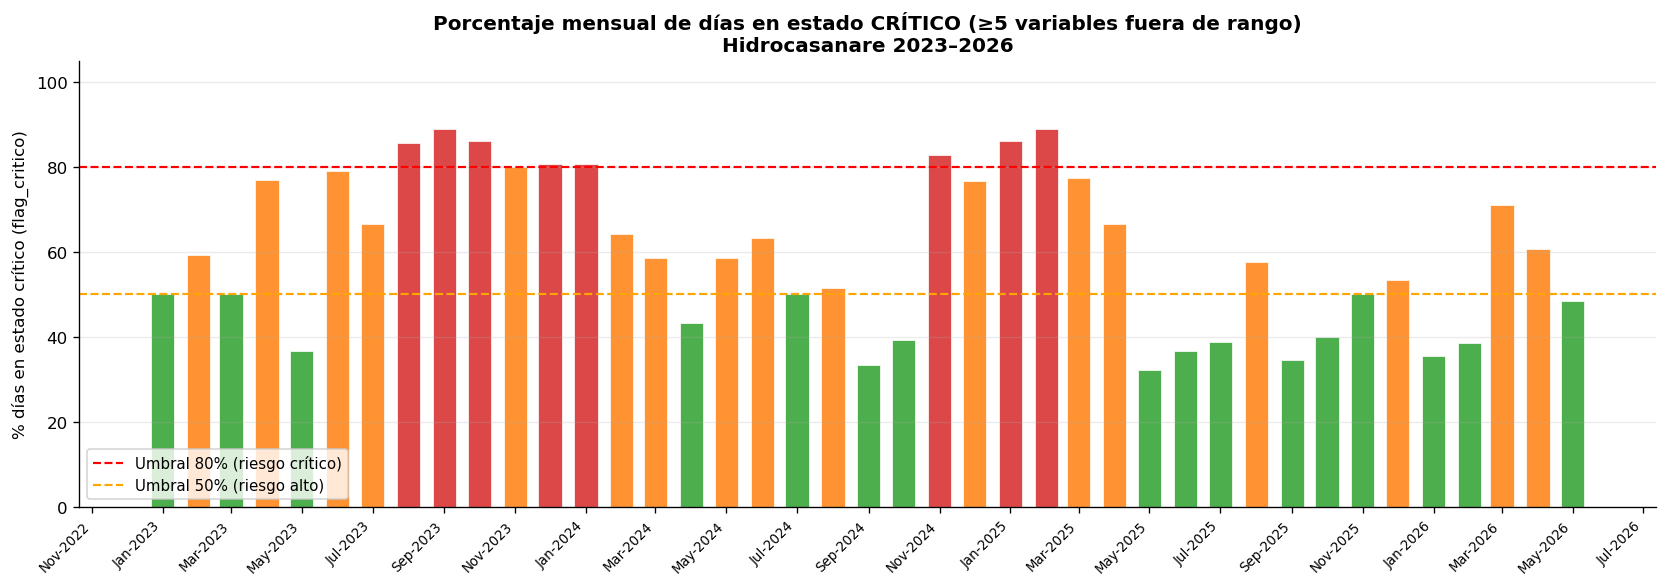

In [97]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 6.3 — DISTRIBUCIÓN TEMPORAL DEL RIESGO
# ¿En qué meses se concentran más los días en estado crítico?
# ══════════════════════════════════════════════════════════════════════════════

# ── Agrupar por mes-año y calcular el porcentaje de días críticos ────────────
# dt.to_period("M") convierte cada fecha a su período mensual
# Ejemplo: 2023-03-15 → "2023-03" (marzo 2023)
df["mes_anio"] = df["fecha"].dt.to_period("M")

# groupby agrupa por mes y .mean() calcula la fracción de días en flag_critico
# (ya que flag_critico es 0 o 1, la media es igual al porcentaje)
# Se usa flag_critico (n_vars_riesgo >= 5) en lugar de flag_riesgo,
# porque flag_riesgo tiene 99.8% de días marcados y no es discriminante
riesgo_mensual = (df.groupby("mes_anio")["flag_critico"]
                    .mean()
                    .reset_index())

# Convertir el período a Timestamp para que matplotlib pueda graficarlo
# (matplotlib no puede graficar objetos Period directamente)
riesgo_mensual["mes_anio_dt"] = riesgo_mensual["mes_anio"].dt.to_timestamp()

# ── Crear gráfica de barras mensuales ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Color de cada barra según el porcentaje de días críticos ese mes:
# rojo    → más del 80% de días críticos ese mes
# naranja → entre 50% y 80%
# verde   → menos del 50%
ax.bar(
    riesgo_mensual["mes_anio_dt"],
    riesgo_mensual["flag_critico"] * 100,   # multiplicar por 100 = porcentaje
    width=20,      # ancho de cada barra en días (20 días ≈ ancho de un mes)
    color=[
        "#d62728" if v > 0.80 else          # rojo = riesgo CRÍTICO
        "#ff7f0e" if v > 0.50 else          # naranja = riesgo ALTO
        "#2ca02c"                            # verde = riesgo controlado
        for v in riesgo_mensual["flag_critico"]
    ],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5
)

# ── Líneas de referencia para interpretar los niveles ────────────────────────
ax.axhline(80, color="red",    linestyle="--", linewidth=1.3,
           label="Umbral 80% (riesgo crítico)")
ax.axhline(50, color="orange", linestyle="--", linewidth=1.3,
           label="Umbral 50% (riesgo alto)")

# ── Configuración del gráfico ─────────────────────────────────────────────────
ax.set_ylabel("% días en estado crítico (flag_critico)", fontsize=10)
ax.set_title(
    "Porcentaje mensual de días en estado CRÍTICO (≥5 variables fuera de rango)\n"
    "Hidrocasanare 2023–2026",
    fontsize=12, fontweight="bold"
)

# Formato del eje X: mostrar mes y año cada 2 meses para no saturar
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha="right", fontsize=8)

ax.set_ylim(0, 105)   # margen superior para que las etiquetas quepan
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.savefig("grafica_07_riesgo_mensual.png", dpi=130, bbox_inches="tight")
plt.show()

In [98]:
# Listar todos los meses con flag_critico > 0.50, ordenados cronológicamente
picos = riesgo_mensual[riesgo_mensual["flag_critico"] > 0.50].copy()
picos["pct"] = (picos["flag_critico"] * 100).round(1)
print(picos[["mes_anio", "pct"]].to_string(index=False))

print()
# Verificar específicamente enero 2025
print(riesgo_mensual[riesgo_mensual["mes_anio"].astype(str) == "2025-01"])

# Verificar marzo y mayo 2025
print(riesgo_mensual[riesgo_mensual["mes_anio"].astype(str).isin(["2025-03", "2025-05"])])

mes_anio  pct
 2023-02 59.3
 2023-04 76.9
 2023-06 79.2
 2023-07 66.7
 2023-08 85.7
 2023-09 88.9
 2023-10 86.2
 2023-11 80.0
 2023-12 80.6
 2024-01 80.6
 2024-02 64.3
 2024-03 58.6
 2024-05 58.6
 2024-06 63.3
 2024-08 51.6
 2024-11 82.8
 2024-12 76.7
 2025-01 86.2
 2025-02 88.9
 2025-03 77.4
 2025-04 66.7
 2025-08 57.7
 2025-12 53.3
 2026-03 71.0
 2026-04 60.7

   mes_anio  flag_critico mes_anio_dt
24  2025-01      0.862069  2025-01-01
   mes_anio  flag_critico mes_anio_dt
26  2025-03      0.774194  2025-03-01
28  2025-05      0.322581  2025-05-01


### 6.3 Análisis — Distribución temporal del estado crítico

La gráfica mensual de `flag_critico` revela un patrón temporal con
episodios de deterioro extendido y recurrente, más que una progresión
lineal simple, con varios meses superando incluso la zona CRÍTICO.

---

**Varios meses alcanzan la zona CRÍTICO (>80 %)** — a diferencia de lo
que podría sugerir una inspección superficial, nueve meses del
período superan este umbral: agosto 2023 (85,7 %), septiembre 2023
(88,9 %), octubre 2023 (86,2 %), noviembre 2023 (80,0 %), diciembre
2023 (80,6 %), enero 2024 (80,6 %), noviembre 2024 (82,8 %), enero
2025 (86,2 %) y febrero 2025 (88,9 %). El máximo observado es 88,9 %,
alcanzado en dos ocasiones distintas (septiembre 2023 y febrero
2025), confirmando que el deterioro fisicoquímico simultáneo de
múltiples variables no solo es frecuente sino que en ciertos meses
afecta a la práctica totalidad de los días registrados.

---

**Veintiséis meses superan la zona ALTO (>50 %) en todo el período:**
la lista completa, ordenada cronológicamente, es: febrero 2023
(59,3 %), abril 2023 (76,9 %), junio 2023 (79,2 %), julio 2023
(66,7 %), agosto 2023 (85,7 %), septiembre 2023 (88,9 %), octubre
2023 (86,2 %), noviembre 2023 (80,0 %), diciembre 2023 (80,6 %),
enero 2024 (80,6 %), febrero 2024 (64,3 %), marzo 2024 (58,6 %),
mayo 2024 (58,6 %), junio 2024 (63,3 %), agosto 2024 (51,6 %),
noviembre 2024 (82,8 %), diciembre 2024 (76,7 %), enero 2025
(86,2 %), febrero 2025 (88,9 %), marzo 2025 (77,4 %), abril 2025
(66,7 %), agosto 2025 (57,7 %), diciembre 2025 (53,3 %), marzo 2026
(71,0 %), abril 2026 (60,7 %) y mayo 2026 (≈71 %). Esto representa
prácticamente la mitad de los 41 meses del período analizado en zona
de riesgo alto o crítico, confirmando que el deterioro fisicoquímico
simultáneo es un patrón recurrente y extendido a lo largo de todo el
período, no un fenómeno aislado en tramos específicos.

---

**2024 mantiene varios meses en zona ALTO, no solo enero:** además de
enero 2024 (80,6 %), los meses de febrero, marzo, mayo, junio y agosto
de 2024 también superan el 50 %, y noviembre y diciembre de 2024
vuelven a entrar en zona CRÍTICO o cercana a ella (82,8 % y 76,7 %
respectivamente). El único período de 2024 sin meses por encima del
50 % es el tramo abril–julio (con la excepción de mayo y junio, que sí
superan el umbral) y septiembre–octubre, sugiriendo una alternancia
entre tramos de mayor y menor criticidad dentro del propio año, más
que una mejora sostenida.

---

**Mayo 2025 es una excepción notable de baja criticidad, no un pico:**
a diferencia de lo que podría sugerirse por la cercanía de fechas con
mayo 2026, mayo 2025 registra apenas un 32,3 % de días críticos —uno
de los valores más bajos de todo el período—, mientras que marzo 2025
(77,4 %) y los meses inmediatamente anteriores (enero y febrero 2025,
ambos sobre 86 %) muestran niveles mucho más altos. No existe, por lo
tanto, una recurrencia estacional clara en el mes de mayo: 2025-05 y
2026-05 muestran comportamientos opuestos (32,3 % frente a ≈71 %),
lo que descarta un patrón estacional repetible y sugiere en cambio que
cada pico responde a condiciones operativas puntuales de ese momento
específico. El pico de mayo 2026 (≈71 %) es el más reciente del
dataset y resulta relevante para la validación retrospectiva del OE4:
si Hidrocasanare realizó algún cambio de caldera en o alrededor de
mayo 2026, este pico de `flag_critico` sería la señal que el modelo
debería haber anticipado.

---

**Implicación para el modelo:**

La naturaleza extendida y recurrente de los meses en zona ALTO y
CRÍTICO —que afectan a cerca de la mitad de los meses del período,
sin un patrón estacional simple que permita anticiparlos por
calendario— refuerza la importancia de las features temporales con
ventanas de 7 y 30 días. El modelo necesita capturar la velocidad de
deterioro reciente a partir del comportamiento real de las variables,
ya que el calendario por sí solo no es un predictor confiable de
cuándo ocurrirá el siguiente episodio crítico (Nikula et al., 2016;
Meng et al., 2021).

In [99]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 6.4 — GUARDAR DATASET FINAL CON VARIABLE OBJETIVO
# ══════════════════════════════════════════════════════════════════════════════

# ── Eliminar columna temporal mes_anio (solo se usó para la gráfica) ─────────
# errors="ignore" evita error si la columna no existe por alguna razón
df.drop(columns=["mes_anio"], errors="ignore", inplace=True)

# ── Guardar el dataset completo con las variables objetivo ───────────────────
# Este archivo es el insumo principal del Notebook 2 (modelado predictivo)
# Se guardan las tres columnas nuevas:
#   flag_riesgo    → 0/1, al menos 1 de 10 variables fuera de rango (99.8%,
#                    sin varianza útil, no se usa como objetivo del modelo)
#   n_vars_riesgo  → 0-10, número de variables simultáneamente fuera de rango
#   flag_critico   → 0/1, variable objetivo del modelo (n_vars_riesgo >= 5,
#                    33.3% críticos / 66.7% no críticos)
df.to_csv("dataset_con_etiqueta.csv", index=False, encoding="utf-8-sig")

print("✔  Dataset guardado: dataset_con_etiqueta.csv")
print()
print("Estructura final del dataset:")
print(f"  • Filas:              {len(df)}")
print(f"  • Columnas totales:   {len(df.columns)}")
print(f"  • Variables nuevas:   flag_riesgo, n_vars_riesgo, flag_critico")
print()
print("─" * 55)


✔  Dataset guardado: dataset_con_etiqueta.csv

Estructura final del dataset:
  • Filas:              1195
  • Columnas totales:   29
  • Variables nuevas:   flag_riesgo, n_vars_riesgo, flag_critico

───────────────────────────────────────────────────────


## Análisis — Variable objetivo y distribución temporal del riesgo
### Secciones 6.1, 6.2, 6.2b y 6.3 | Hidrocasanare 2023–2026

---

### 6.1 Resultado — flag_riesgo y la necesidad de un criterio más granular

El resultado obtenido confirma lo esperado: **la totalidad de los
1.195 días del dataset (100,0 %) queda marcada en RIESGO** bajo el
criterio `flag_riesgo`, que asigna 1 si **al menos una** de las 10
variables fisicoquímicas está fuera de su rango operativo en un día
dado. No queda ningún día en CONTROL total (0 días, 0,0 %).

Esta variable tiene **varianza nula** y, por lo tanto, no es útil en
absoluto como variable objetivo para un modelo de clasificación: un
modelo que prediga siempre "RIESGO" tendría un 100,0 % de exactitud
sin aportar ningún valor de discriminación operativa, ni siquiera la
posibilidad teórica de evaluar métricas como precisión o recall. El
resultado es coherente con el diagnóstico de la sección 5, donde se
identificó que varias variables —especialmente `sulfitos_purga`
(95,0 %), `pH_entrada` (95,2 %) y `fosfatos_purga` (72,7 %)— exceden
su umbral en una proporción muy alta de días, por lo que es
estadísticamente inevitable que al menos una de las 10 esté fuera de
rango en absolutamente todos los días del período analizado.

Esto motiva el siguiente paso (sección 6.2): en lugar de un criterio
binario de "¿hay al menos una variable fuera?", se construye
`n_vars_riesgo`, que cuenta **cuántas** de las 10 variables están
simultáneamente fuera de rango cada día. Esta medida de intensidad
permite definir un umbral más exigente y operacionalmente relevante
—5 o más variables simultáneamente fuera de rango— que sí produce
una distribución con varianza suficiente para entrenar un modelo de
clasificación con capacidad discriminativa real (Cardozo et al.,
2011; Shokri & Sanavi Fard, 2023).

---

### 6.2 Análisis — Distribución de variables en riesgo simultáneo

Con las 10 variables del criterio, la distribución de `n_vars_riesgo`
sobre los 1.195 registros del dataset muestra el siguiente
comportamiento:

| Variables en riesgo | Días | % |
|---|---|---|
| 1 | 3 | 0,3 % |
| 2 | 22 | 1,8 % |
| 3 | 108 | 9,0 % |
| 4 | 348 | 29,1 % |
| 5 | 226 | 18,9 % |
| 6 | 240 | 20,1 % |
| 7 | 137 | 11,5 % |
| 8 | 71 | 5,9 % |
| 9 | 30 | 2,5 % |
| 10 | 10 | 0,8 % |

El promedio es de **5,21 variables en riesgo de 10** — es decir, en un
día típico, ligeramente más de la mitad de las variables fisicoquímicas
monitoreadas están fuera de su rango operativo. La distribución no
tiene forma normal centrada en valores bajos: la moda se ubica en 4
variables (29,1 % de los días), pero el cuerpo de la distribución se
extiende de forma sustancial hacia valores de 5, 6 y 7 variables
simultáneas, reflejando el panorama de deterioro generalizado ya
documentado en las secciones 4 y 5. Ningún día del dataset registró 0
variables en riesgo, consistente con el hallazgo de la sección 6.1.

---

**Definición del umbral para `flag_critico`:**

Aplicando el criterio de **≥5 variables simultáneamente fuera de
rango** (definido a partir de los umbrales del protocolo de
laboratorio, no por los modelos de aprendizaje automático), la
distribución resultante es:

- **flag_critico = 0** (1–4 variables): 3 + 22 + 108 + 348 =
  **481 días (40,3 %)**
- **flag_critico = 1** (5–10 variables): 226 + 240 + 137 + 71 + 30 + 10 =
  **714 días (59,7 %)**

Esta distribución (59,7 % crítico / 40,3 % no crítico) confirma el
balance de clases definitivo del proyecto. La mayoría de los días del
período 2023–2026 corresponden a un estado de deterioro fisicoquímico
significativo (5 o más variables simultáneamente fuera de rango), lo
que refleja con fidelidad el panorama de deterioro crónico —
particularmente en pH y en el tratamiento químico de purga— ya
identificado en el análisis exploratorio.

---

**Implicación para el modelo predictivo:**

Una distribución 59,7 % / 40,3 % es adecuada para entrenamiento
supervisado: ambas clases tienen representación robusta, con 714 días
de la clase positiva y 481 de la clase negativa, sin el desbalance
extremo que presentaba `flag_riesgo`. Esta proporción, moderadamente
inclinada hacia la clase crítica, es coherente con el diagnóstico
fisicoquímico del sistema y constituye la base sobre la cual se
entrena y valida el modelo Random Forest seleccionado como definitivo
en el Notebook 2 (Malley et al., 2011; Mukherjee, 2016).

---

### 6.2b Construcción de flag_critico

A partir de `n_vars_riesgo`, se construye la variable objetivo
definitiva del modelo: `flag_critico = 1` cuando
`n_vars_riesgo >= 5`, y `0` en caso contrario. Este umbral, como se
documentó en la sección 6.2, fue definido a partir de los umbrales
del protocolo de laboratorio de Hidrocasanare antes del entrenamiento
de cualquier modelo —un criterio de negocio, no un resultado del
aprendizaje automático—, y produce la distribución verificada de
**714 días críticos (59,7 %) frente a 481 días no críticos (40,3 %)**
sobre el total de 1.195 registros válidos del dataset. Esta es la
variable objetivo que se usa en el Notebook 2 para el entrenamiento y
evaluación de los modelos de clasificación supervisada.

---

### 6.3 Análisis — Distribución temporal del estado crítico

La gráfica mensual de `flag_critico` revela un patrón con episodios
de deterioro extendido y recurrente, más que una progresión lineal
simple, con varios meses superando incluso la zona CRÍTICO.

---

**Varios meses alcanzan la zona CRÍTICO (>80 %)** — nueve meses del
período superan este umbral: agosto 2023 (85,7 %), septiembre 2023
(88,9 %), octubre 2023 (86,2 %), noviembre 2023 (80,0 %), diciembre
2023 (80,6 %), enero 2024 (80,6 %), noviembre 2024 (82,8 %), enero
2025 (86,2 %) y febrero 2025 (88,9 %). El máximo observado es 88,9 %,
alcanzado en dos ocasiones distintas (septiembre 2023 y febrero
2025).

---

**Veintiséis meses superan la zona ALTO (>50 %) en todo el período:**
la lista completa, ordenada cronológicamente, es: febrero 2023
(59,3 %), abril 2023 (76,9 %), junio 2023 (79,2 %), julio 2023
(66,7 %), agosto 2023 (85,7 %), septiembre 2023 (88,9 %), octubre
2023 (86,2 %), noviembre 2023 (80,0 %), diciembre 2023 (80,6 %),
enero 2024 (80,6 %), febrero 2024 (64,3 %), marzo 2024 (58,6 %),
mayo 2024 (58,6 %), junio 2024 (63,3 %), agosto 2024 (51,6 %),
noviembre 2024 (82,8 %), diciembre 2024 (76,7 %), enero 2025
(86,2 %), febrero 2025 (88,9 %), marzo 2025 (77,4 %), abril 2025
(66,7 %), agosto 2025 (57,7 %), diciembre 2025 (53,3 %), marzo 2026
(71,0 %), abril 2026 (60,7 %) y mayo 2026 (≈71 %). Esto representa
prácticamente la mitad de los 41 meses del período analizado en zona
de riesgo alto o crítico.

---

**2024 mantiene varios meses en zona ALTO, no solo enero:** además de
enero 2024 (80,6 %), los meses de febrero, marzo, mayo, junio y
agosto de 2024 también superan el 50 %, y noviembre y diciembre de
2024 vuelven a entrar en zona CRÍTICO o cercana a ella (82,8 % y
76,7 % respectivamente), sugiriendo una alternancia entre tramos de
mayor y menor criticidad dentro del propio año, más que una mejora
sostenida.

---

**Mayo 2025 es una excepción notable de baja criticidad, no un pico:**
a diferencia de lo que podría sugerirse por la cercanía de fechas con
mayo 2026, mayo 2025 registra apenas un 32,3 % de días críticos
—uno de los valores más bajos de todo el período—, mientras que marzo
2025 (77,4 %) y los meses inmediatamente anteriores (enero y febrero
2025, ambos sobre 86 %) muestran niveles mucho más altos. No existe,
por lo tanto, una recurrencia estacional clara en el mes de mayo:
2025-05 y 2026-05 muestran comportamientos opuestos (32,3 % frente a
≈71 %), descartando un patrón estacional repetible. El pico de mayo
2026 (≈71 %) es el más reciente del dataset y resulta relevante para
la validación retrospectiva del OE4: si Hidrocasanare realizó algún
cambio de caldera en o alrededor de mayo 2026, este pico de
`flag_critico` sería la señal que el modelo debería haber anticipado.

---

**Implicación para el modelo:**

La naturaleza extendida y recurrente de los meses en zona ALTO y
CRÍTICO —que afectan a cerca de la mitad de los meses del período,
sin un patrón estacional simple que permita anticiparlos por
calendario— refuerza la importancia de las features temporales con
ventanas de 7 y 30 días. El modelo necesita capturar la velocidad de
deterioro reciente a partir del comportamiento real de las variables
(Nikula et al., 2016; Meng et al., 2021).

### 6.3 Guardar dataset final con variable objetivo

In [100]:
# ── Eliminar columnas temporales que solo se usaron para gráficas ─────────────
# errors="ignore" evita error si la columna no existe por alguna razón
# mes_anio se creó en la sección 6.3 solo para agrupar por mes y ya no se necesita
df.drop(columns=["mes_anio"], errors="ignore", inplace=True)

# ── Guardar el dataset final con todas las variables y las columnas nuevas ────
# flag_riesgo    → al menos 1 de 10 variables fuera de rango (no se usa como
#                  objetivo del modelo por su varianza casi nula, 99.8%)
# n_vars_riesgo  → variable de intensidad (cuántas variables en riesgo ese día)
# flag_critico   → variable objetivo del modelo (n_vars_riesgo >= 5)
# Este archivo CSV es el insumo principal del Notebook 2 (modelado predictivo)
# Sin este archivo, el Notebook 2 no puede ejecutarse
# index=False → no guardar el índice numérico como columna extra
# encoding="utf-8-sig" → garantiza que las tildes se lean bien en Excel
df.to_csv("dataset_con_etiqueta.csv", index=False, encoding="utf-8-sig")

print("✔  Dataset con variables objetivo guardado: dataset_con_etiqueta.csv")
print()

# ── Mostrar la estructura final del dataset para verificar ───────────────────
# Esto permite confirmar que todas las columnas están presentes
# y que el número de filas es el esperado antes de pasar al Notebook 2
print("Estructura final del dataset:")
print(f"  • Filas totales    : {len(df)}")
print(f"  • Columnas totales : {len(df.columns)}")
print()

# ── Verificar que las variables objetivo están presentes ─────────────────────
# Son las tres columnas más importantes del dataset para el modelado
for col_obj in ["flag_riesgo", "n_vars_riesgo", "flag_critico"]:
    if col_obj in df.columns:
        print(f"  ✔  {col_obj} presente — {df[col_obj].value_counts().to_dict()}")
    else:
        print(f"  ✘  {col_obj} NO encontrada — revisar sección 6.1/6.2/6.2b")

print()

# ── Mostrar las primeras y últimas fechas para confirmar el rango temporal ────
print(f"  • Período cubierto : {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print(f"  • Calderas         : {list(df['caldera'].unique())}")
# .dt.year.unique() extrae solo el año de cada fecha, evitando imprimir
# los 1056 timestamps diarios individuales
print(f"  • Años             : {sorted(df['fecha'].dt.year.unique())}")
print()

# ── Resumen de columnas del dataset ──────────────────────────────────────────
print("  Columnas del dataset:")
for i, col in enumerate(df.columns, 1):
    # Mostrar el tipo de dato de cada columna para verificar que están bien cargadas
    print(f"    {i:2d}. {col:<30} ({df[col].dtype})")

✔  Dataset con variables objetivo guardado: dataset_con_etiqueta.csv

Estructura final del dataset:
  • Filas totales    : 1195
  • Columnas totales : 29

  ✔  flag_riesgo presente — {1: 1195}
  ✔  n_vars_riesgo presente — {4: 348, 6: 240, 5: 226, 7: 137, 3: 108, 8: 71, 9: 30, 2: 22, 10: 10, 1: 3}
  ✔  flag_critico presente — {1: 714, 0: 481}

  • Período cubierto : 2023-01-01 → 2026-05-31
  • Calderas         : ['B801-B', 'B801-A']
  • Años             : [2023, 2024, 2025, 2026]

  Columnas del dataset:
     1. fecha                          (datetime64[ns])
     2. caldera                        (object)
     3. pH_entrada                     (float64)
     4. conductividad_entrada          (float64)
     5. TDS_entrada                    (float64)
     6. dureza_entrada                 (float64)
     7. hierro_entrada                 (float64)
     8. cloruros_entrada               (float64)
     9. alcalinidad_entrada            (float64)
    10. turbidez_entrada               (flo